Univariate analysis for the FLT 7T tone learning dataset. Features of this notebook include:
- `grouped_runs`: Early vs. middle vs. final learning stages
- across striatal and cortical regions of interest
- for both `sound-vs-baseline` and `fb-correct-vs-incorrect` BOLD contrasts
- brain–behavior correlations for each analysis

# Imports and definitions

In [1]:
import os
import sys
import json
import argparse

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
import seaborn as sns

from glob import glob
from nilearn.glm.second_level import SecondLevelModel
from nilearn.glm.second_level import make_second_level_design_matrix
from nilearn.image import threshold_img, resample_to_img, binarize_img
from nilearn.glm import threshold_stats_img

In [2]:
from nilearn.masking import apply_mask
from scipy import stats

In [3]:
import statsmodels.api as sm
import pingouin as pg

from statsmodels.formula.api import ols
from statsmodels.stats.anova import AnovaRM

from statsmodels.stats.multitest import multipletests
from scipy.stats import ttest_1samp, ttest_rel

In [4]:
import sys
sys.path.insert(0, '..')   # where stats_fmt.py lives relative to the notebook
from stats_fmt import fmt_t, fmt_F, fmt_p, fmt_r, stat_str, stat_str_fdr, fmt_pingouin_anova
from stats_fmt import export_anova, export_posthoc, export_ttests


In [5]:
# print stats as human-readable
pd.set_option('display.float_format', '{:.4f}'.format)

In [6]:
from nilearn import plotting, datasets, surface

# for plotting slices
mni152_template = datasets.load_mni152_template(resolution=1)
# for plotting on surface
fsaverage = datasets.fetch_surf_fsaverage('fsaverage')

from roi_surface_plotting import plot_roi_surface_stat, build_mask_path_dict
from striatal_roi_plotting import plot_striatal_roi_stat


[fetch_surf_fsaverage] Dataset directory found: /ihome/bchandrasekaran/krs228/nilearn_data/fsaverage


In [7]:
task_label = 'tonecat'
fwhm = 0.00
space_label = 'T1w' # 'MNI152NLin2009cAsym'

# define data directories
bidsroot = os.path.join('/ix1/bchandrasekaran/krs228/data/', 
                        'FLT/',
                        'data_denoised', #'data_bids'
                       )
nilearn_dir = os.path.join(bidsroot, 'derivatives', 'nilearn')
# must match univariate_glm.py's _fmriprep_tag(fmriprep_dir) output for whichever
# fmriprep run produced the inputs -- keeps T1w-space outputs from different
# fmriprep versions (which are NOT the same space) from colliding on disk
fmriprep_tag = 'fmriprep-25.2.5'
masks_dir = os.path.join(nilearn_dir, 'masks')
# define first-level directory where group-level inputs will be pulled from
l1_dir = os.path.join(nilearn_dir, fmriprep_tag, 'bids-deriv_level-1_fwhm-%.02f'%fwhm)
print('level-1 output directory:', l1_dir)

# create output directory
group_out_dir = os.path.join(nilearn_dir, 'group_space-%s_fwhm-%.02f'%(space_label, fwhm))
if not os.path.exists(group_out_dir):
        os.makedirs(group_out_dir)
        
deriv_dir = group_out_dir

stats_out_dir = os.path.join(deriv_dir, 'stats_tables')
os.makedirs(stats_out_dir, exist_ok=True)

fig_out_dir = os.path.join(os.getcwd(), 'figures')
os.makedirs(fig_out_dir, exist_ok=True)

level-1 output directory: /ix1/bchandrasekaran/krs228/data/FLT/data_denoised/derivatives/nilearn/fmriprep-25.2.5/bids-deriv_level-1_fwhm-0.00


In [8]:
deriv_dir

'/ix1/bchandrasekaran/krs228/data/FLT/data_denoised/derivatives/nilearn/group_space-T1w_fwhm-0.00'

In [9]:
bidsroot

'/ix1/bchandrasekaran/krs228/data/FLT/data_denoised'

In [10]:
contrast_list = ['sound', 'resp', 'fbcorrectvswrong']

# 'sound'/'resp' come from univariate_glm.py's --event_type=sound runs;
# 'fbcorrectvswrong' comes from its --event_type=feedback runs. Both are
# needed to build the grouped_runs output path below, since univariate_glm.py
# now includes event_type in that path.
contrast_event_type = {'sound': 'sound', 'resp': 'sound', 'fbcorrectvswrong': 'feedback'}

Based on [nilearn documentation](https://nilearn.github.io/stable/auto_examples/05_glm_second_level/plot_thresholding.html#statistical-testing-of-a-second-level-analysis)

### Build the group-level design matrix

#### Read the `participants.tsv` file from the BIDS root directory

In [11]:
participants_fpath = os.path.join(bidsroot, 'participants.tsv')
participants_df = pd.read_csv(participants_fpath, sep='\t')

# subjects to ignore (not fully processed, etc.)
ignore_subs = ['sub-FLT27', # always leave out FLT27 – did not participate
               'sub-FLT07', # bad QA 11/14/23
               'sub-FLT20', # TO BE REINCLUDED once I figure out why L1 didn't generate
              ]
participants_df.drop(participants_df[participants_df.participant_id.isin(ignore_subs)].index, inplace=True)

# re-sort by participant ID
participants_df.sort_values(by=['participant_id'], ignore_index=True, inplace=True)

In [12]:
print(participants_df)

   participant_id  age sex         group    FFR_id
0       sub-FLT02   21   F  non-Mandarin 1002.0000
1       sub-FLT03   25   F      Mandarin 2002.0000
2       sub-FLT04   21   F  non-Mandarin 1003.0000
3       sub-FLT05   26   M      Mandarin 3010.0000
4       sub-FLT06   21   F  non-Mandarin 3001.0000
5       sub-FLT08   23   F      Mandarin 2005.0000
6       sub-FLT09   30   F  non-Mandarin 3002.0000
7       sub-FLT10   23   F      Mandarin 2006.0000
8       sub-FLT11   20   F  non-Mandarin 1005.0000
9       sub-FLT12   20   F  non-Mandarin 3004.0000
10      sub-FLT13   23   F  non-Mandarin 3005.0000
11      sub-FLT14   23   M  non-Mandarin 3006.0000
12      sub-FLT15   22   M      Mandarin 2010.0000
13      sub-FLT17   29   F      Mandarin       NaN
14      sub-FLT18   24   M      Mandarin 2016.0000
15      sub-FLT19   24   M      Mandarin 2018.0000
16      sub-FLT21   21   M      Mandarin 2011.0000
17      sub-FLT22   41   F      Mandarin 2017.0000
18      sub-FLT23   26   F     

In [13]:
participants_nman_df = participants_df[participants_df.group=='non-Mandarin'].reset_index(drop=True)
print(participants_nman_df)

   participant_id  age sex         group    FFR_id
0       sub-FLT02   21   F  non-Mandarin 1002.0000
1       sub-FLT04   21   F  non-Mandarin 1003.0000
2       sub-FLT06   21   F  non-Mandarin 3001.0000
3       sub-FLT09   30   F  non-Mandarin 3002.0000
4       sub-FLT11   20   F  non-Mandarin 1005.0000
5       sub-FLT12   20   F  non-Mandarin 3004.0000
6       sub-FLT13   23   F  non-Mandarin 3005.0000
7       sub-FLT14   23   M  non-Mandarin 3006.0000
8       sub-FLT25   19   F  non-Mandarin 1013.0000
9       sub-FLT28   23   F  non-Mandarin       NaN
10      sub-FLT30   25   M  non-Mandarin       NaN


In [14]:
# create group-specific lists of subject IDs
sub_list_mand = list(participants_df.participant_id[participants_df.group=='Mandarin'])
sub_list_nman = list(participants_df.participant_id[participants_df.group=='non-Mandarin'])

In [15]:
print(sub_list_nman)

['sub-FLT02', 'sub-FLT04', 'sub-FLT06', 'sub-FLT09', 'sub-FLT11', 'sub-FLT12', 'sub-FLT13', 'sub-FLT14', 'sub-FLT25', 'sub-FLT28', 'sub-FLT30']


### Define region dictionary

In [16]:
region_dict = {'auditory': [
                        'L-HG', 'L-PT',  'L-PP', 
                        'L-STGp', 'L-STGa', 
                        'L-ParsOp', 'L-ParsTri',
                        'R-HG', 'R-PT',  'R-PP', 
                        'R-STGp', 'R-STGa', 
                        'R-ParsOp', 'R-ParsTri', 
                          ],
                'tian-S2': [
                    #'pGP-rh', 'pGP-lh',
                    #'aGP-rh', 'aGP-lh',
                    'aCAU-lh',
                    'pCAU-lh',
                    'aPUT-lh',
                    'pPUT-lh',
                    'NAc-shell-lh',
                    'NAc-core-lh',
                    'aCAU-rh',
                    'pCAU-rh',
                    'aPUT-rh',
                    'pPUT-rh',
                    'NAc-shell-rh',
                    'NAc-core-rh',
                    ],
                'tian-S3': [
                        'CAU-DA-lh', 'CAU-DA-rh', 
                        'CAU-VA-lh', 'CAU-VA-rh', 
                        'pCAU-lh', 'pCAU-rh', 
                        'PUT-DA-lh', 'PUT-DA-rh', 
                        'PUT-DP-lh', 'PUT-DP-rh', 
                        'PUT-VA-lh', 'PUT-VA-rh', 
                        'PUT-VP-lh', 'PUT-VP-rh',
                        'NAc-core-lh',  'NAc-core-rh', 
                        'NAc-shell-lh', 'NAc-shell-rh', 
                         #'aGP-lh', 'pGP-lh', 
                         #'aGP-rh', 'pGP-rh',         
                               ],
                'pfc': [
                        'L-FP',    'R-FP',
                        'L-SFG',   'R-SFG',
                        'L-MFG',   'R-MFG',
                        'L-IFGt',  'R-IFGt',
                        'L-IFGo',  'R-IFGo',
                        'L-PreCG', 'R-PreCG',
                        'L-FMC',   'R-FMC',
                        'L-PCG',   'R-PCG',
                        'L-ACC',   'R-ACC',
                        'L-OFC',   'R-OFC',
                        'L-FO',    'R-FO',
                          ],
           }
network_list  = list(region_dict.keys())
print('network_list:', network_list)

network_list: ['auditory', 'tian-S2', 'tian-S3', 'pfc']


### define key processing functions

In [142]:
# mask stat maps
def mask_stat_maps(region_list, statmap_dict, masks_dir, network_name, space_label):
    roi_mean_dict = {}
    mask_path_list = []
    if network_name=='auditory':
        new_network_name = 'dseg'
    elif network_name == 'pfc':
        new_network_name = 'dseg' # -pfc'
    else:
        new_network_name = network_name
    
    for rx, region in enumerate(region_list):
        print(region)
        roi_mean_list = []

        for sub_id in statmap_dict:
            stat_fpath = statmap_dict[sub_id]
            mask_fpath = glob(masks_dir + f'/{sub_id}/space-{space_label}/masks-{new_network_name}/*{region}*.nii.gz')[0]
            print(mask_fpath)
            #print(nib.load(mask_fpath).get_fdata().shape)
            
            mask_img = resample_to_img(mask_fpath, stat_fpath, 
                                       interpolation='nearest',
                                       force_resample=True, 
                                       copy_header=True)
            mask_img = binarize_img(mask_img, two_sided=False, copy_header=True)
            masked_data = apply_mask(stat_fpath, mask_img)
            roi_mean_sub = masked_data.mean()
            

            roi_mean_list.append(roi_mean_sub)

        # save mask_fpaths for later
        mask_path_list.append(mask_fpath)
        
        
        roi_mean_dict[region] = roi_mean_list
    
    return roi_mean_dict, mask_path_list

In [18]:
# create ROI dataframe from dictionary
def make_stats_df(roi_mean_dict, participants_df, network_name):
    roi_df = pd.DataFrame.from_dict(roi_mean_dict)

    roi_df['participant_id'] = participants_df.participant_id
    roi_df['participant_group'] = participants_df.group

    roi_df_long = roi_df.melt(id_vars=["participant_id", "participant_group"], 
                              var_name="region", value_name="beta")

    # create new `hemisphere` column
    if network_name == 'auditory' or 'pfc':
        roi_df_long['region_hemi'] = roi_df_long.region
        roi_df_long['hemisphere'] = roi_df_long.region.str[0]
        roi_df_long['region'] = roi_df_long.region.str[2:]
    else: #if network_name == ('tian_subcortical_S3' or 'tian_subcortical_S2'):
        roi_df_long['region_hemi'] = roi_df_long.region
        roi_df_long['hemisphere'] = roi_df_long.region.str[-2:]
        roi_df_long['region'] = roi_df_long.region.str[:-3]

    # Filter for non-Mandarin participants
    #stats_df = roi_df_long[roi_df_long['participant_group'] == 'non-Mandarin']
    
    return roi_df_long # stats_df

In [19]:
# Calculate hemisphere-averaged ROI beta values and create a new dataframe
def bilateral_mean(df):
    return (df.groupby(['participant_id', 'participant_group', 'region', 'learning_stage'], 
                       as_index=False)
              ['beta']
              .mean())

In [20]:
# plot ROI box plots
def plot_roi_box_plots(stats_df):
    fig, ax = plt.subplots(1, 1, figsize=(6,4), dpi=300)
    yrange = [-6, 4.5]

    # Define a color palette
    #palette = ['#e66101', '#5e3c99']  # Example colors, adjust as needed

    # Create the swarm plot with transparent dots
    sns.stripplot(data=stats_df, 
                  x='region', y='beta', 
                  hue='hemisphere',
                  dodge=True,
                  linewidth=0.5,
                  size=3,
                  #alpha=0.6,
                  #palette=palette,  # Use the defined color palette
                  legend=None,
                  ax=ax,
                  zorder=2)  # Lower zorder for the strip plot

    # Make the swarm plot dots transparent
    for collection in ax.collections:
        collection.set_facecolor('none')

    # Create the box plot with colors
    sns.boxplot(data=stats_df, 
                x='region', y='beta', 
                hue='hemisphere',
                dodge=True,
                linewidth=1,
                fliersize=0,
                #palette=palette,  # Use the same color palette
                #legend=None,
                ax=ax,
                zorder=1)  # Higher zorder for the box plot

    #ax.set_ylim(yrange)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
    ax.set_title(f'{contrast_label}')

    # Extend the horizontal dashed line at y=0
    ax.axhline(y=0, color='0.5', linestyle='--', linewidth=0.5)

    fig.tight_layout()
    
    return fig

In [21]:
# plot ROI-mean values on the brain
def plot_roi_slices(roi_mean_dict, mask_path_list, network_name, space_label):
    from nilearn.image import new_img_like
    from nilearn import plotting

    roi_stat_data_list = []
    for rx, region in enumerate(roi_mean_dict):
        print('region:', region)
        mask_fpath = glob(masks_dir + f'/*/space-{space_label}/masks-{network_name}/*{region}*.nii.gz')[0]
        #mask_fpath = region
        #roi_img = nib.load(mask_fpath)
        #roi_data = roi_img.get_fdata()
        
        #roi_img = resample_to_img(mask_fpath, stat_fpath, 
        #                           interpolation='nearest',
        #                           force_resample=True, 
        #                           copy_header=True)
        roi_img = binarize_img(mask_fpath, two_sided=False)
        #roi_data = apply_mask(stat_fpath, roi_img)
        roi_data = roi_img.get_fdata()
        
        roi_stat = np.mean(roi_mean_dict[region])
        #roi_stat = roi_mean_dict.loc[roi_mean_dict['region_hemi'] == 'region', 'beta'].mean()
        roi_stat_data = roi_data * roi_stat

        roi_stat_data_list.append(roi_stat_data)
    
    # add maps together and make nifti img
    roi_stat_map_data = sum(roi_stat_data_list)
    roi_stat_map_img = new_img_like(roi_img, roi_stat_map_data)

    fig, ax = plt.subplots(figsize=(8,3), dpi=300)
    plotting.plot_stat_map(roi_stat_map_img,
                           bg_img=mni152_template,
                           black_bg=False,
                           annotate=False, draw_cross=False,
                           symmetric_cbar=True,
                           cmap='coolwarm',
                           axes=ax)
    #fig.suptitle(title);
    
    return fig

In [22]:
def plot_roi_slices_avg(roi_mean_dict_list, mask_path_list, network_name, space_label):
    from nilearn.image import new_img_like
    from nilearn import plotting

    roi_stat_data_list = []
    all_regions = roi_mean_dict_list[0].keys()  # assumes all dicts share the same regions

    for region in all_regions:
        print('region:', region)
        mask_fpath = glob(masks_dir + f'/*/space-{space_label}/masks-{network_name}/*{region}*.nii.gz')[0]
        roi_img = binarize_img(mask_fpath, two_sided=False)
        roi_data = roi_img.get_fdata()

        # Compute mean across all stages for this region
        roi_stat_values = [roi_dict[region] for roi_dict in roi_mean_dict_list]
        roi_stat = np.mean(roi_stat_values)

        roi_stat_data = roi_data * roi_stat
        roi_stat_data_list.append(roi_stat_data)

    # Combine all ROI maps
    roi_stat_map_data = sum(roi_stat_data_list)
    roi_stat_map_img = new_img_like(roi_img, roi_stat_map_data)

    fig, ax = plt.subplots(figsize=(8,3), dpi=300)
    plotting.plot_stat_map(roi_stat_map_img,
                           bg_img=mni152_template,
                           black_bg=False,
                           annotate=False, draw_cross=False,
                           symmetric_cbar=True,
                           cmap='coolwarm',
                           axes=ax)
    ax.set_title('Mean response across learning stages')
    return fig


In [23]:
def plot_roi_slices_diff(roi_mean_dict_stage1, roi_mean_dict_stage2, mask_path_list, network_name, space_label):
    from nilearn.image import new_img_like
    from nilearn import plotting

    roi_stat_data_list = []
    all_regions = roi_mean_dict_stage1.keys()  # assumes both dicts share the same regions

    for region in all_regions:
        print('region:', region)
        mask_fpath = glob(masks_dir + f'/*/space-{space_label}/masks-{network_name}/*{region}*.nii.gz')[0]
        roi_img = binarize_img(mask_fpath, two_sided=False)
        roi_data = roi_img.get_fdata()

        # Compute difference between stages
        roi_stat_stage1 = np.mean(roi_mean_dict_stage1[region])
        roi_stat_stage2 = np.mean(roi_mean_dict_stage2[region])
        roi_stat_diff = roi_stat_stage2 - roi_stat_stage1


        roi_stat_data = roi_data * roi_stat_diff
        roi_stat_data_list.append(roi_stat_data)

    # Combine all ROI maps
    roi_stat_map_data = sum(roi_stat_data_list)
    roi_stat_map_img = new_img_like(roi_img, roi_stat_map_data)

    fig, ax = plt.subplots(figsize=(8,3), dpi=300)
    plotting.plot_stat_map(roi_stat_map_img,
                           bg_img=mni152_template,
                           black_bg=False,
                           annotate=False, draw_cross=False,
                           symmetric_cbar=True,
                           cmap='coolwarm',
                           axes=ax)
    ax.set_title('Response difference across learning stages')
    return fig


## Load behavioral accuracy outputs for brain-behavior correlations

In [24]:
beh_out_dir = os.path.join(bidsroot, 'derivatives', 'behavior')
acc_df = pd.read_csv(os.path.join(beh_out_dir, 'run_accuracies.tsv'), sep='\t')

In [25]:
acc_df.sort_values(by=['participant_id', 'run'], inplace=True)
acc_df.head(10)

,participant_id,run,accuracy
78,sub-FLT02,run-01,0.4028
79,sub-FLT02,run-02,0.8636
80,sub-FLT02,run-03,0.8500
81,sub-FLT02,run-04,0.8250
82,sub-FLT02,run-05,0.9129
83,sub-FLT02,run-06,0.8958
0,sub-FLT03,run-01,0.9792
1,sub-FLT03,run-02,1.0000
2,sub-FLT03,run-03,0.9792
3,sub-FLT03,run-04,1.0000


mean accuracy = 0.7959


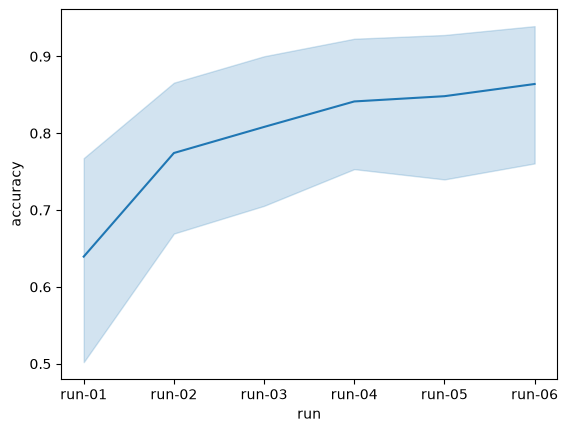

In [26]:
print(f'mean accuracy = {acc_df.accuracy.mean():.04f}')
sns.lineplot(acc_df, x='run', y='accuracy');

## `contrast-sound` for striatal network

In [27]:
# get the beta map for the contrast of interest for each subject
network_name = network_list[1]
contrast_label = contrast_list[0]
event_type = contrast_event_type[contrast_label]

statmap_earlythird_dict = {}
for sub_id in sub_list_nman:
    statmap_earlythird_dict[sub_id] = sorted(glob(l1_dir+f'/{sub_id}_space-{space_label}/early_event-{event_type}/{sub_id}/*{contrast_label}_stat-effect_statmap.nii.gz'))[0]
    
statmap_middlethird_dict = {}
for sub_id in sub_list_nman:
    statmap_middlethird_dict[sub_id] = sorted(glob(l1_dir+f'/{sub_id}_space-{space_label}/middle_event-{event_type}/{sub_id}/*{contrast_label}_stat-effect_statmap.nii.gz'))[0]
    
statmap_latethird_dict = {}
for sub_id in sub_list_nman:
    statmap_latethird_dict[sub_id] = sorted(glob(l1_dir+f'/{sub_id}_space-{space_label}/final_event-{event_type}/{sub_id}/*{contrast_label}_stat-effect_statmap.nii.gz'))[0]

In [28]:
sub_id

'sub-FLT30'

In [29]:
network_name

'tian-S2'

In [30]:
# define filepath for saving (once) or loading (afterward)
out_fname = f'univariate-results_network-{network_name}_contrast-{contrast_label}.tsv'
combined_roi_df_fpath = os.path.join(group_out_dir, out_fname)

In [31]:
# mask the stat maps per learning stage by region - ONLY RUN ONCE
'''
print(f'masking {contrast_label} stat maps for the {network_name} network')

print(f'creating dictionary for early learning stage')
roi_earlythird_mean_dict, mask_path_list = mask_stat_maps(region_dict[network_name], 
                                               statmap_earlythird_dict, 
                                               masks_dir, 
                                               network_name,
                                               space_label)

print(f'creating dictionary for middle learning stage')
roi_middlethird_mean_dict, mask_path_list = mask_stat_maps(region_dict[network_name], 
                                               statmap_middlethird_dict, 
                                               masks_dir, 
                                               network_name,
                                               space_label)

print(f'creating dictionary for final learning stage')
roi_latethird_mean_dict, mask_path_list = mask_stat_maps(region_dict[network_name], 
                                               statmap_latethird_dict, 
                                               masks_dir, 
                                               network_name,
                                               space_label)

# add `learning_stage` column and combine into single dataframe
roi_earlythird_df_long = make_stats_df(roi_earlythird_mean_dict, participants_nman_df, network_name)
roi_earlythird_df_long['learning_stage'] = 'early'
roi_middlethird_df_long = make_stats_df(roi_middlethird_mean_dict, participants_nman_df, network_name)
roi_middlethird_df_long['learning_stage'] = 'middle'
roi_latethird_df_long = make_stats_df(roi_latethird_mean_dict, participants_nman_df, network_name)
roi_latethird_df_long['learning_stage'] = 'final'

# combine into a single long dataframe
roi_df_long = pd.concat([roi_earlythird_df_long, roi_middlethird_df_long, roi_latethird_df_long],)

# had to manually fix these for some reason TBD - 6/6/26
roi_df_long['hemisphere'] = roi_df_long.region_hemi.str[-2:]
roi_df_long['region'] = roi_df_long.region_hemi.str[:-3]

# save the DataFrame for easier access
roi_df_long.to_csv(combined_roi_df_fpath, sep='\t', index=False)
'''

"\nprint(f'masking {contrast_label} stat maps for the {network_name} network')\n\nprint(f'creating dictionary for early learning stage')\nroi_earlythird_mean_dict, mask_path_list = mask_stat_maps(region_dict[network_name], \n                                               statmap_earlythird_dict, \n                                               masks_dir, \n                                               network_name,\n                                               space_label)\n\nprint(f'creating dictionary for middle learning stage')\nroi_middlethird_mean_dict, mask_path_list = mask_stat_maps(region_dict[network_name], \n                                               statmap_middlethird_dict, \n                                               masks_dir, \n                                               network_name,\n                                               space_label)\n\nprint(f'creating dictionary for final learning stage')\nroi_latethird_mean_dict, mask_path_list = mask_stat_map

In [32]:
# load the DataFrame if already exists
roi_df_long = pd.read_csv(combined_roi_df_fpath, sep='\t')

# create a bilateral-averaged dataframe (for across-contrast analysis)
sound_striatum_df = bilateral_mean(roi_df_long)


In [33]:
roi_df_long.participant_id.unique()

<StringArray>
['sub-FLT02', 'sub-FLT04', 'sub-FLT06', 'sub-FLT09', 'sub-FLT11', 'sub-FLT12',
 'sub-FLT13', 'sub-FLT14', 'sub-FLT25', 'sub-FLT28', 'sub-FLT30']
Length: 11, dtype: str

In [34]:
roi_df_long.region.unique()

<StringArray>
['aCAU', 'pCAU', 'aPUT', 'pPUT', 'NAc-shell', 'NAc-core']
Length: 6, dtype: str

In [35]:
print(network_name)
non_mandarin_df = roi_df_long.copy()

# create a new column based on rostral–caudal axis
non_mandarin_df['Axis'] = ''

if network_name == 'tian-S3':
    non_mandarin_df.loc[(non_mandarin_df['region']=='pCAU'),   'Axis'] = 'Caudal'
    non_mandarin_df.loc[(non_mandarin_df['region']=='PUT-VP'), 'Axis'] = 'Caudal'
    non_mandarin_df.loc[(non_mandarin_df['region']=='PUT-DP'), 'Axis'] = 'Caudal'

    non_mandarin_df.loc[non_mandarin_df['region']=='CAU-DA', 'Axis'] = 'Rostral'
    non_mandarin_df.loc[non_mandarin_df['region']=='CAU-VA', 'Axis'] = 'Rostral'
    non_mandarin_df.loc[non_mandarin_df['region']=='CAU-DP', 'Axis'] = 'Rostral'
    non_mandarin_df.loc[non_mandarin_df['region']=='CAU-VP', 'Axis'] = 'Rostral'

    non_mandarin_df.loc[non_mandarin_df['region']=='PUT-VA', 'Axis'] = 'Rostral'
    non_mandarin_df.loc[non_mandarin_df['region']=='PUT-DA', 'Axis'] = 'Rostral'

    non_mandarin_df.loc[non_mandarin_df['region']=='NAc-shell', 'Axis'] = 'Ventral'
    non_mandarin_df.loc[non_mandarin_df['region']=='NAc-core', 'Axis'] = 'Ventral'

elif network_name == 'tian-S2':
    non_mandarin_df.loc[(non_mandarin_df['region']=='pCAU'), 'Axis'] = 'Caudal'
    non_mandarin_df.loc[(non_mandarin_df['region']=='pPUT'), 'Axis'] = 'Caudal'    
    
    non_mandarin_df.loc[(non_mandarin_df['region']=='aCAU'), 'Axis'] = 'Rostral'
    non_mandarin_df.loc[(non_mandarin_df['region']=='aPUT'), 'Axis'] = 'Rostral'    

    non_mandarin_df.loc[non_mandarin_df['region']=='NAc-shell', 'Axis'] = 'Ventral'
    non_mandarin_df.loc[non_mandarin_df['region']=='NAc-core', 'Axis'] = 'Ventral'

non_mandarin_df.head()

tian-S2


,participant_id,participant_group,region,beta,region_hemi,hemisphere,learning_stage,Axis
0,sub-FLT02,non-Mandarin,aCAU,-0.2102,aCAU-lh,lh,early,Rostral
1,sub-FLT04,non-Mandarin,aCAU,-1.9723,aCAU-lh,lh,early,Rostral
2,sub-FLT06,non-Mandarin,aCAU,-3.8047,aCAU-lh,lh,early,Rostral
3,sub-FLT09,non-Mandarin,aCAU,2.6634,aCAU-lh,lh,early,Rostral
4,sub-FLT11,non-Mandarin,aCAU,1.1982,aCAU-lh,lh,early,Rostral


In [36]:
non_mandarin_df.region_hemi.unique()

<StringArray>
[     'aCAU-lh',      'pCAU-lh',      'aPUT-lh',      'pPUT-lh',
 'NAc-shell-lh',  'NAc-core-lh',      'aCAU-rh',      'pCAU-rh',
      'aPUT-rh',      'pPUT-rh', 'NAc-shell-rh',  'NAc-core-rh']
Length: 12, dtype: str

In [37]:
non_mandarin_df.participant_id.unique()

<StringArray>
['sub-FLT02', 'sub-FLT04', 'sub-FLT06', 'sub-FLT09', 'sub-FLT11', 'sub-FLT12',
 'sub-FLT13', 'sub-FLT14', 'sub-FLT25', 'sub-FLT28', 'sub-FLT30']
Length: 11, dtype: str

In [38]:
# right now, requires separate dictionaries per learning stage
# could be re-written to take roi_df_long or similar
'''
fig = plot_roi_slices_avg([roi_earlythird_mean_dict, roi_middlethird_mean_dict, roi_latethird_mean_dict],
                          mask_path_list, network_name, space_label)
'''

'\nfig = plot_roi_slices_avg([roi_earlythird_mean_dict, roi_middlethird_mean_dict, roi_latethird_mean_dict],\n                          mask_path_list, network_name, space_label)\n'

In [39]:
plot_order = ['aCAU', 'pCAU', 'aPUT', 'pPUT', 'NAc-core', 'NAc-shell']

/scratch/slurm-10971702/ipykernel_1708492/4213364461.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')


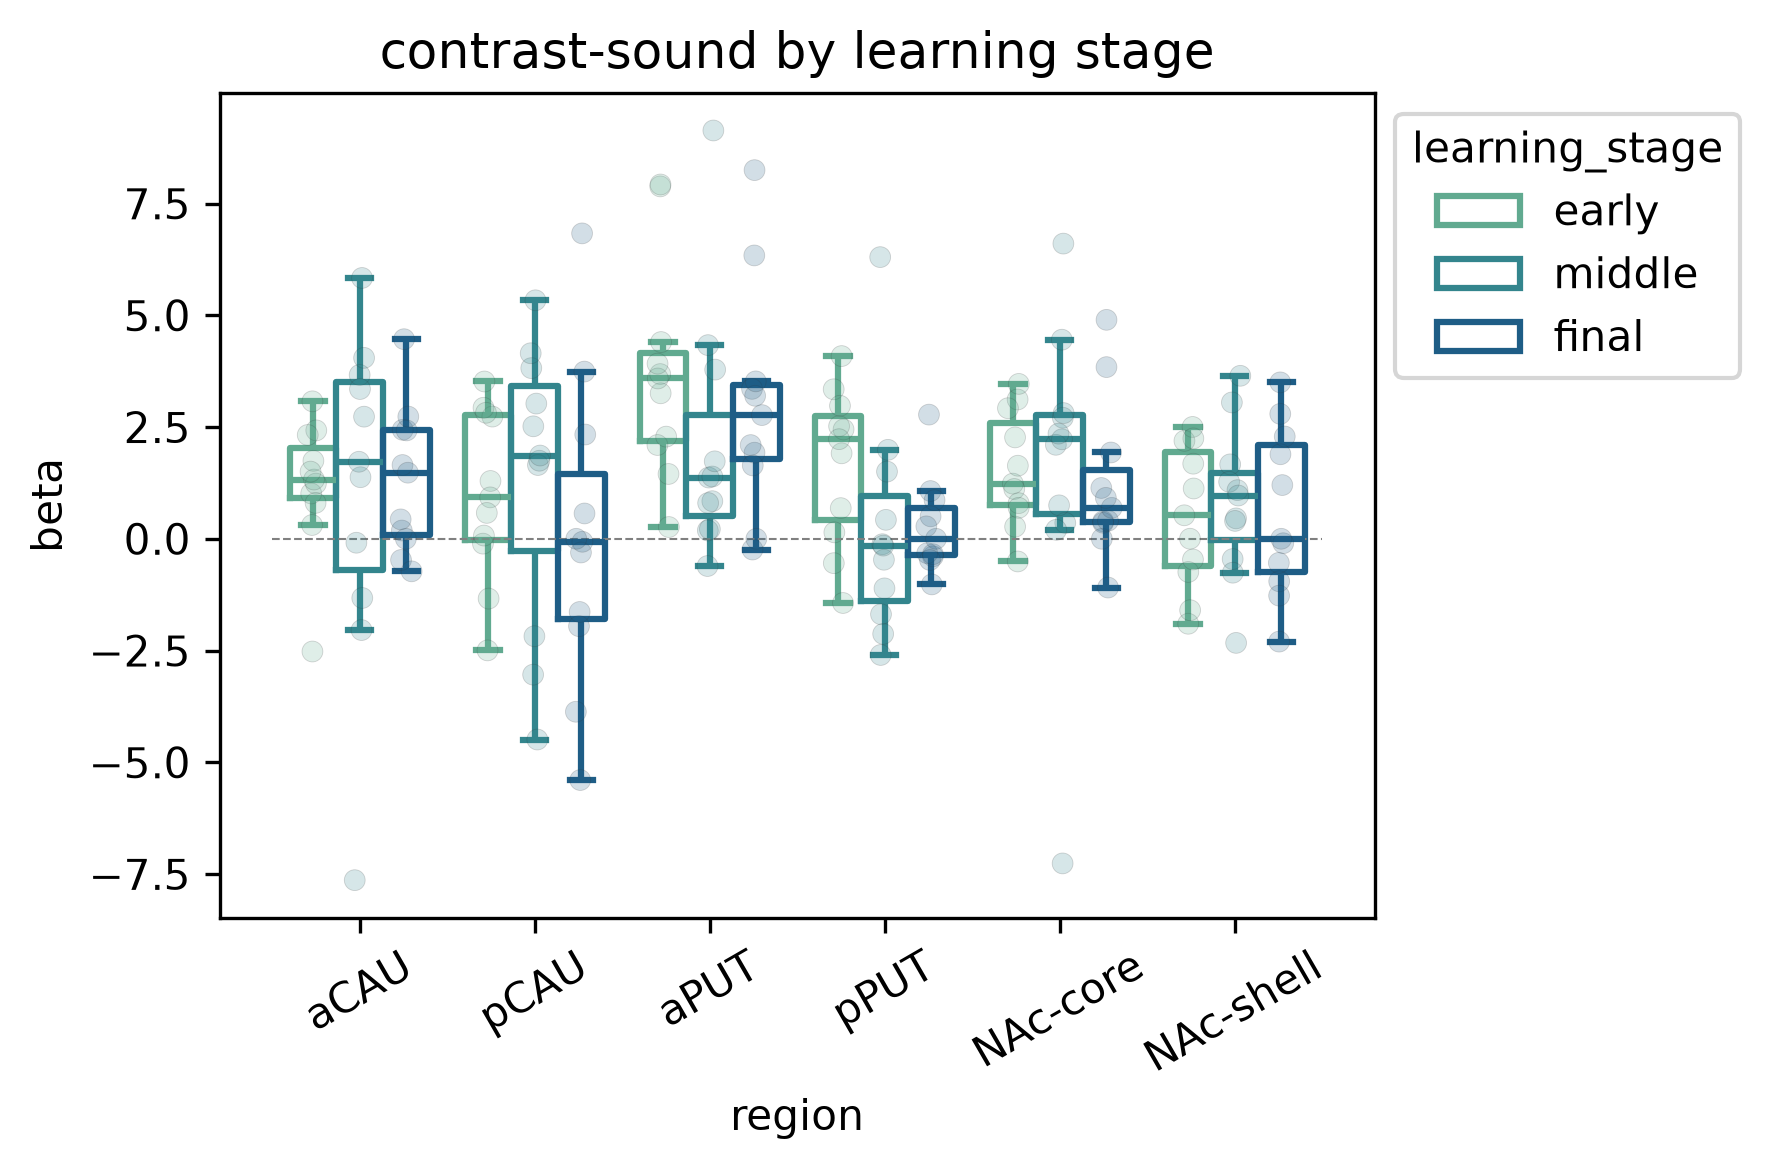

In [40]:
fig, ax = plt.subplots(1, 1, figsize=(6,4), dpi=300)

roi_df_collapsed = roi_df_long.groupby(["participant_id", "region", 'learning_stage'], 
                                       as_index=False).agg({"beta": "mean"})

sns.boxplot(data=roi_df_collapsed, 
              x='region', y='beta', 
              hue='learning_stage', hue_order=['early', 'middle', 'final'],
              order=plot_order,
              palette='crest',
              fliersize = 0,            
              linewidth=1.5,
              fill=False,
              #legend=None,
              ax=ax);
sns.stripplot(data=roi_df_collapsed, 
              x='region', y='beta', 
              hue='learning_stage', hue_order=['early', 'middle', 'final'],
              order=plot_order,
              palette='crest',
              dodge=True,
              linewidth=0.2,
              alpha=.2,
              legend=None,
              ax=ax);


xmin, xmax = ax.get_xlim()
ax.hlines(y=0, xmin=xmin, xmax=xmax, color='0.5', linestyle='--', linewidth=0.5)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title(f'contrast-{contrast_label} by learning stage');
#ax.set_ylim([-5, 5])

fig.tight_layout()
fig.savefig(os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_boxplot-stage.svg'))
fig.savefig(os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_boxplot-stage.png'))

/scratch/slurm-10971702/ipykernel_1708492/3292222178.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')


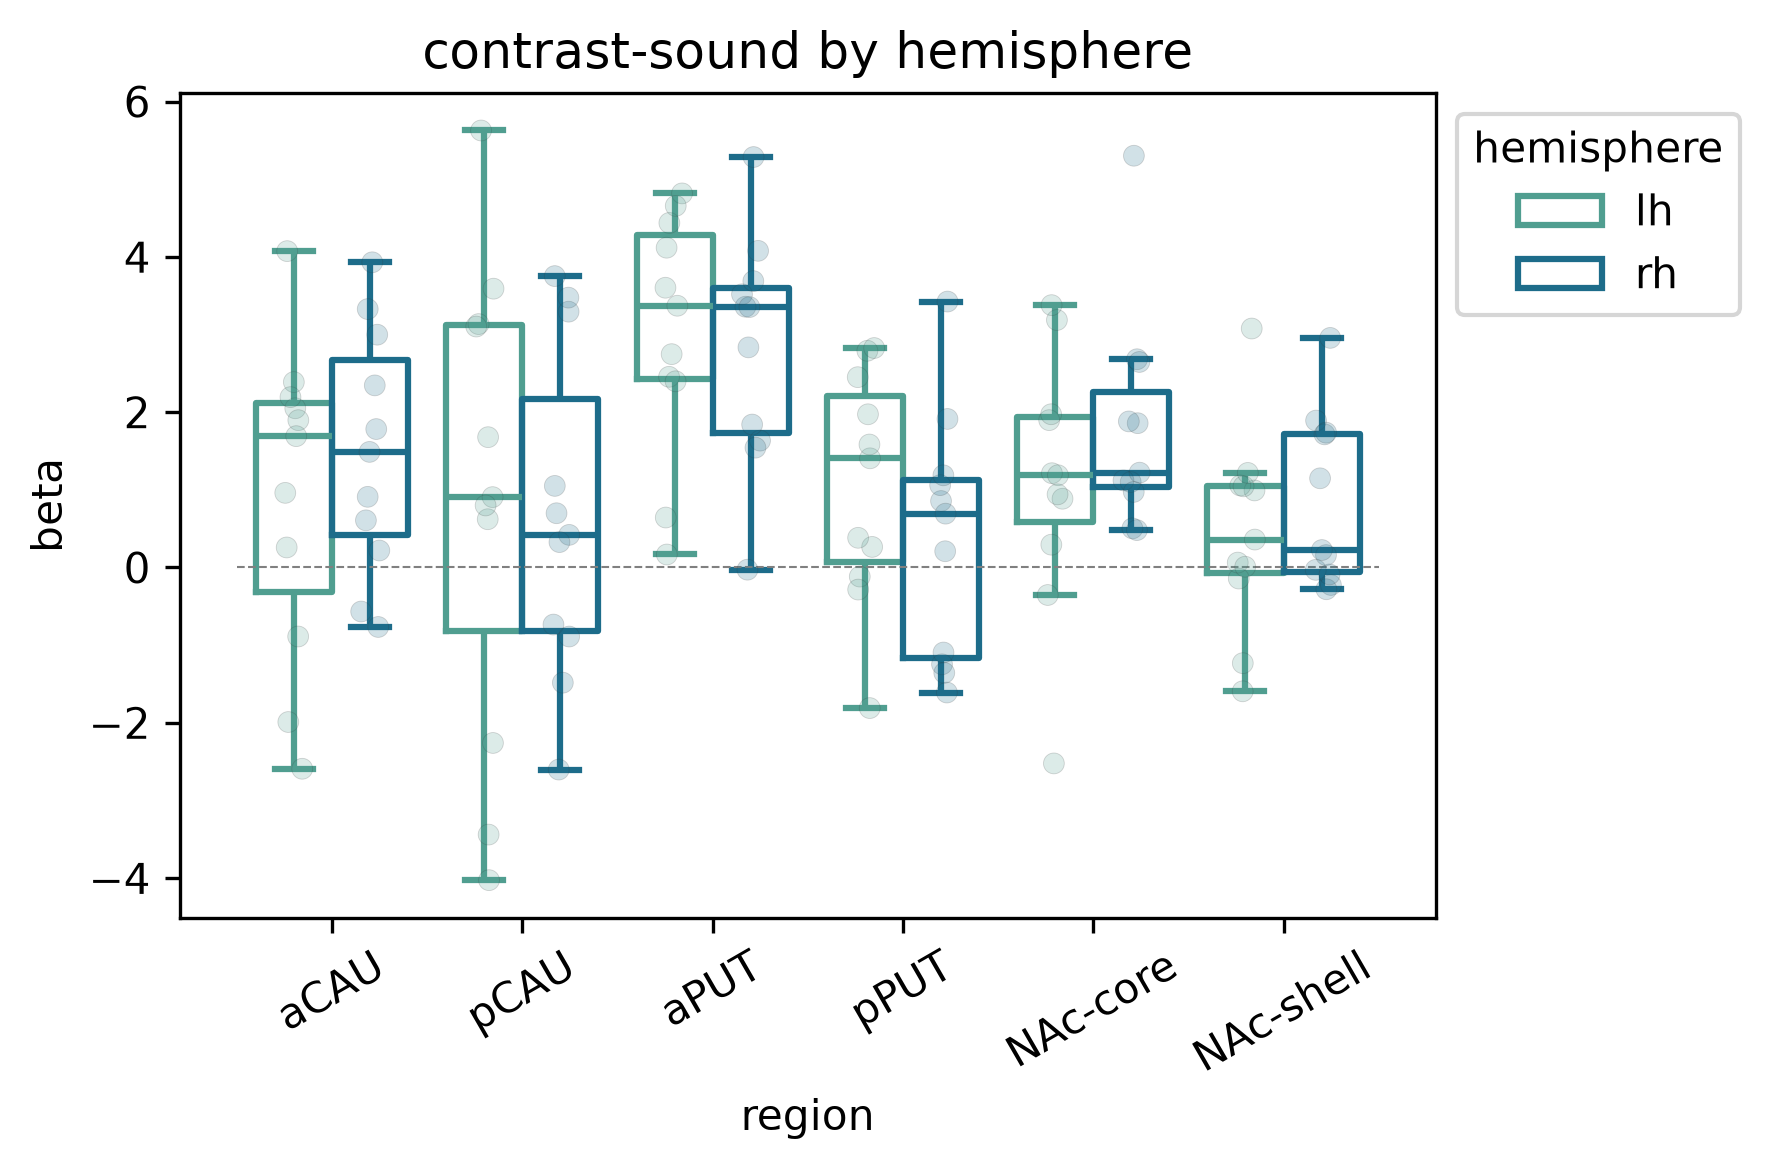

In [41]:
fig, ax = plt.subplots(1, 1, figsize=(6,4), dpi=300)

roi_df_collapsed = roi_df_long.groupby(["participant_id", "region", 'hemisphere'], 
                                       as_index=False).agg({"beta": "mean"})

sns.boxplot(data=roi_df_collapsed, 
              x='region', y='beta', 
              hue='hemisphere', #hue_order=['early', 'middle', 'final'],
              order=plot_order,
              palette='crest',
              fliersize = 0,            
              linewidth=1.5,
              fill=False,
              #legend=None,
              ax=ax);
sns.stripplot(data=roi_df_collapsed, 
              x='region', y='beta', 
              hue='hemisphere', #hue_order=['early', 'middle', 'final'],
              order=plot_order,
              palette='crest',
              dodge=True,
              linewidth=0.2,
              alpha=.2,
              legend=None,
              ax=ax);


xmin, xmax = ax.get_xlim()
ax.hlines(y=0, xmin=xmin, xmax=xmax, color='0.5', linestyle='--', linewidth=0.5)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title(f'contrast-{contrast_label} by hemisphere');
#ax.set_ylim([-5, 5])

fig.tight_layout()

fig.savefig(os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_boxplot-hemisphere.svg'))
fig.savefig(os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_boxplot-hemisphere.png'))

### Brain-behavior correlations

In [42]:
# map runs to learning stages matching your thirds
stage_map = {'run-01': 'early', 'run-02': 'early',
             'run-03': 'middle', 'run-04': 'middle',
             'run-05': 'final', 'run-06': 'final'}

acc_df['learning_stage'] = acc_df['run'].map(stage_map)
acc_stage_df = acc_df.groupby(['participant_id', 'learning_stage'])['accuracy'].mean().reset_index()

In [43]:
# merge into roi_df_long — assumes participant_id and learning_stage columns exist in both
roi_df_bilateral = (roi_df_long.groupby(['participant_id', 'region', 'learning_stage'], as_index=False)['beta'].mean())
roi_behav_df = roi_df_bilateral.merge(acc_stage_df, on=['participant_id', 'learning_stage'])

# verify
roi_behav_df.groupby(['region', 'learning_stage']).size().unique()  # should be array([12])


array([11])

In [44]:
roi_behav_df.columns

Index(['participant_id', 'region', 'learning_stage', 'beta', 'accuracy'], dtype='str')

In [45]:
roi_behav_df.participant_id.unique()

<StringArray>
['sub-FLT02', 'sub-FLT04', 'sub-FLT06', 'sub-FLT09', 'sub-FLT11', 'sub-FLT12',
 'sub-FLT13', 'sub-FLT14', 'sub-FLT25', 'sub-FLT28', 'sub-FLT30']
Length: 11, dtype: str

In [46]:
roi_behav_df.groupby(['region','learning_stage']).size().unique()


array([11])

In [47]:
results = []
for stage in ['early', 'middle', 'final']:
    stage_df = roi_behav_df[roi_behav_df['learning_stage'] == stage]
    for roi in stage_df['region'].unique():
        sub_df = stage_df[stage_df['region'] == roi]
        r = pg.corr(sub_df['accuracy'], sub_df['beta'], method='pearson')
        results.append({
            'roi': roi,
            'learning_stage': stage,
            'r': r['r'].values[0],
            'p': r['p_val'].values[0],
            'n': r['n'].values[0],
            'stat_str': stat_str('r', r['r'].values[0], r['p_val'].values[0])
        })

behav_corr_df = pd.DataFrame(results)

In [48]:
behav_corr_df

,roi,learning_stage,r,p,n,stat_str
0,NAc-core,early,0.6949,0.0176,11,"r = .69, p = .018"
1,NAc-shell,early,0.3281,0.3246,11,"r = .33, p = .325"
2,aCAU,early,0.5836,0.0594,11,"r = .58, p = .059"
3,aPUT,early,0.3702,0.2624,11,"r = .37, p = .262"
4,pCAU,early,-0.1580,0.6426,11,"r = -.16, p = .643"
5,pPUT,early,0.0950,0.7811,11,"r = .10, p = .781"
6,NAc-core,middle,-0.4140,0.2056,11,"r = -.41, p = .206"
7,NAc-shell,middle,-0.2519,0.4549,11,"r = -.25, p = .455"
8,aCAU,middle,-0.2695,0.4229,11,"r = -.27, p = .423"
9,aPUT,middle,-0.3414,0.3041,11,"r = -.34, p = .304"


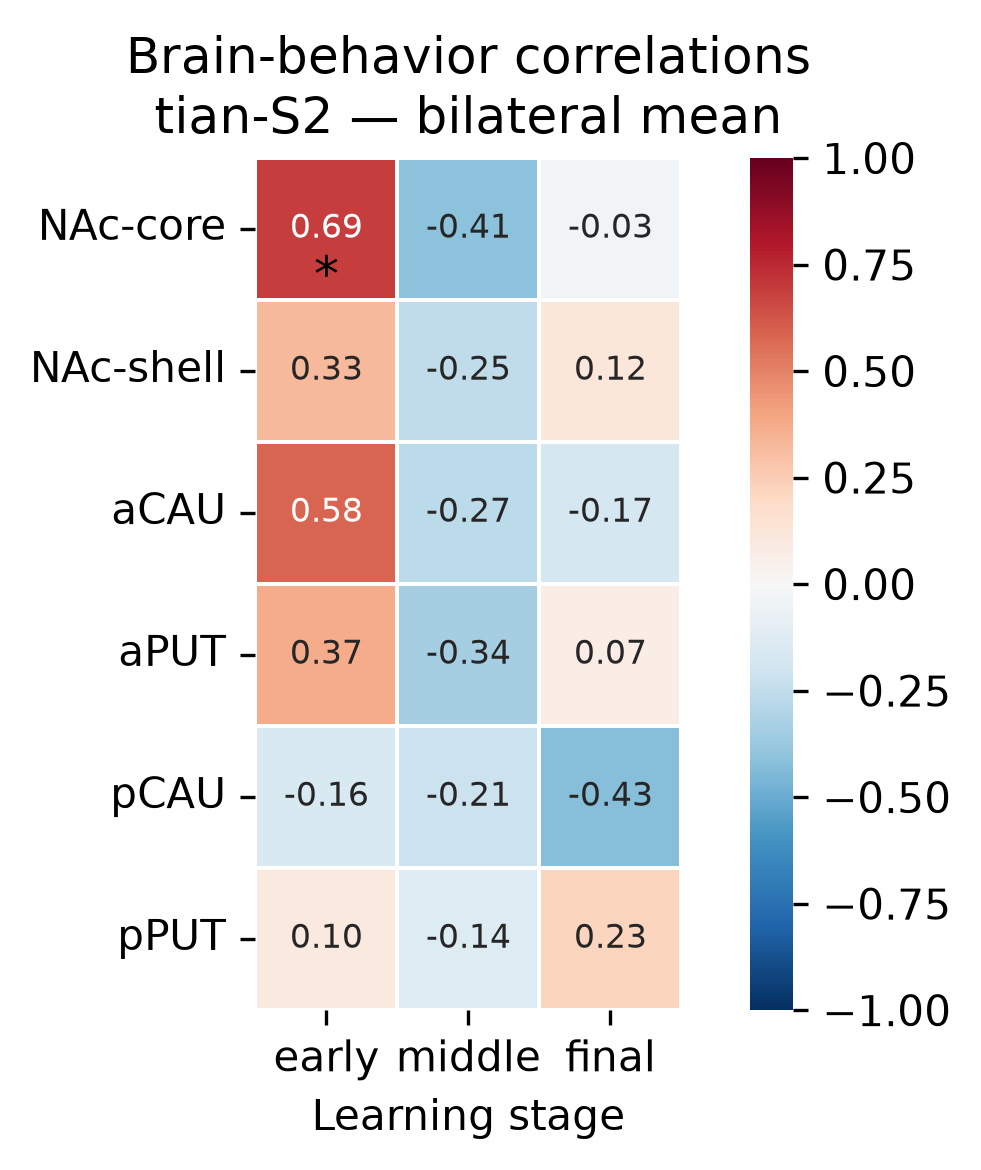

In [49]:
# pivot to ROI × stage matrix
r_matrix = behav_corr_df.pivot(index='roi', columns='learning_stage', values='r')[['early', 'middle', 'final']]
p_matrix = behav_corr_df.pivot(index='roi', columns='learning_stage', values='p')[['early', 'middle', 'final']]

fig, ax = plt.subplots(figsize=(5, len(r_matrix) * 0.5 + 1), dpi=300)
sns.heatmap(r_matrix, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, annot=True, fmt='.2f', annot_kws={'size': 8},
            square=True)

# mark significant cells with an asterisk
for i, roi in enumerate(r_matrix.index):
    for j, stage in enumerate(['early', 'middle', 'final']):
        p = p_matrix.loc[roi, stage]
        if p < 0.05:
            ax.text(j + 0.5, i + 0.85, '*', ha='center', va='center',
                    fontsize=12, color='black')

ax.set_title(f'Brain-behavior correlations\n{network_name} — bilateral mean')
ax.set_ylabel('')
ax.set_xlabel('Learning stage')
plt.tight_layout()
plt.savefig(os.path.join(fig_out_dir, f'brain-behav-corr_contrast-{contrast_label}_network-{network_name}_heatmap.svg'))

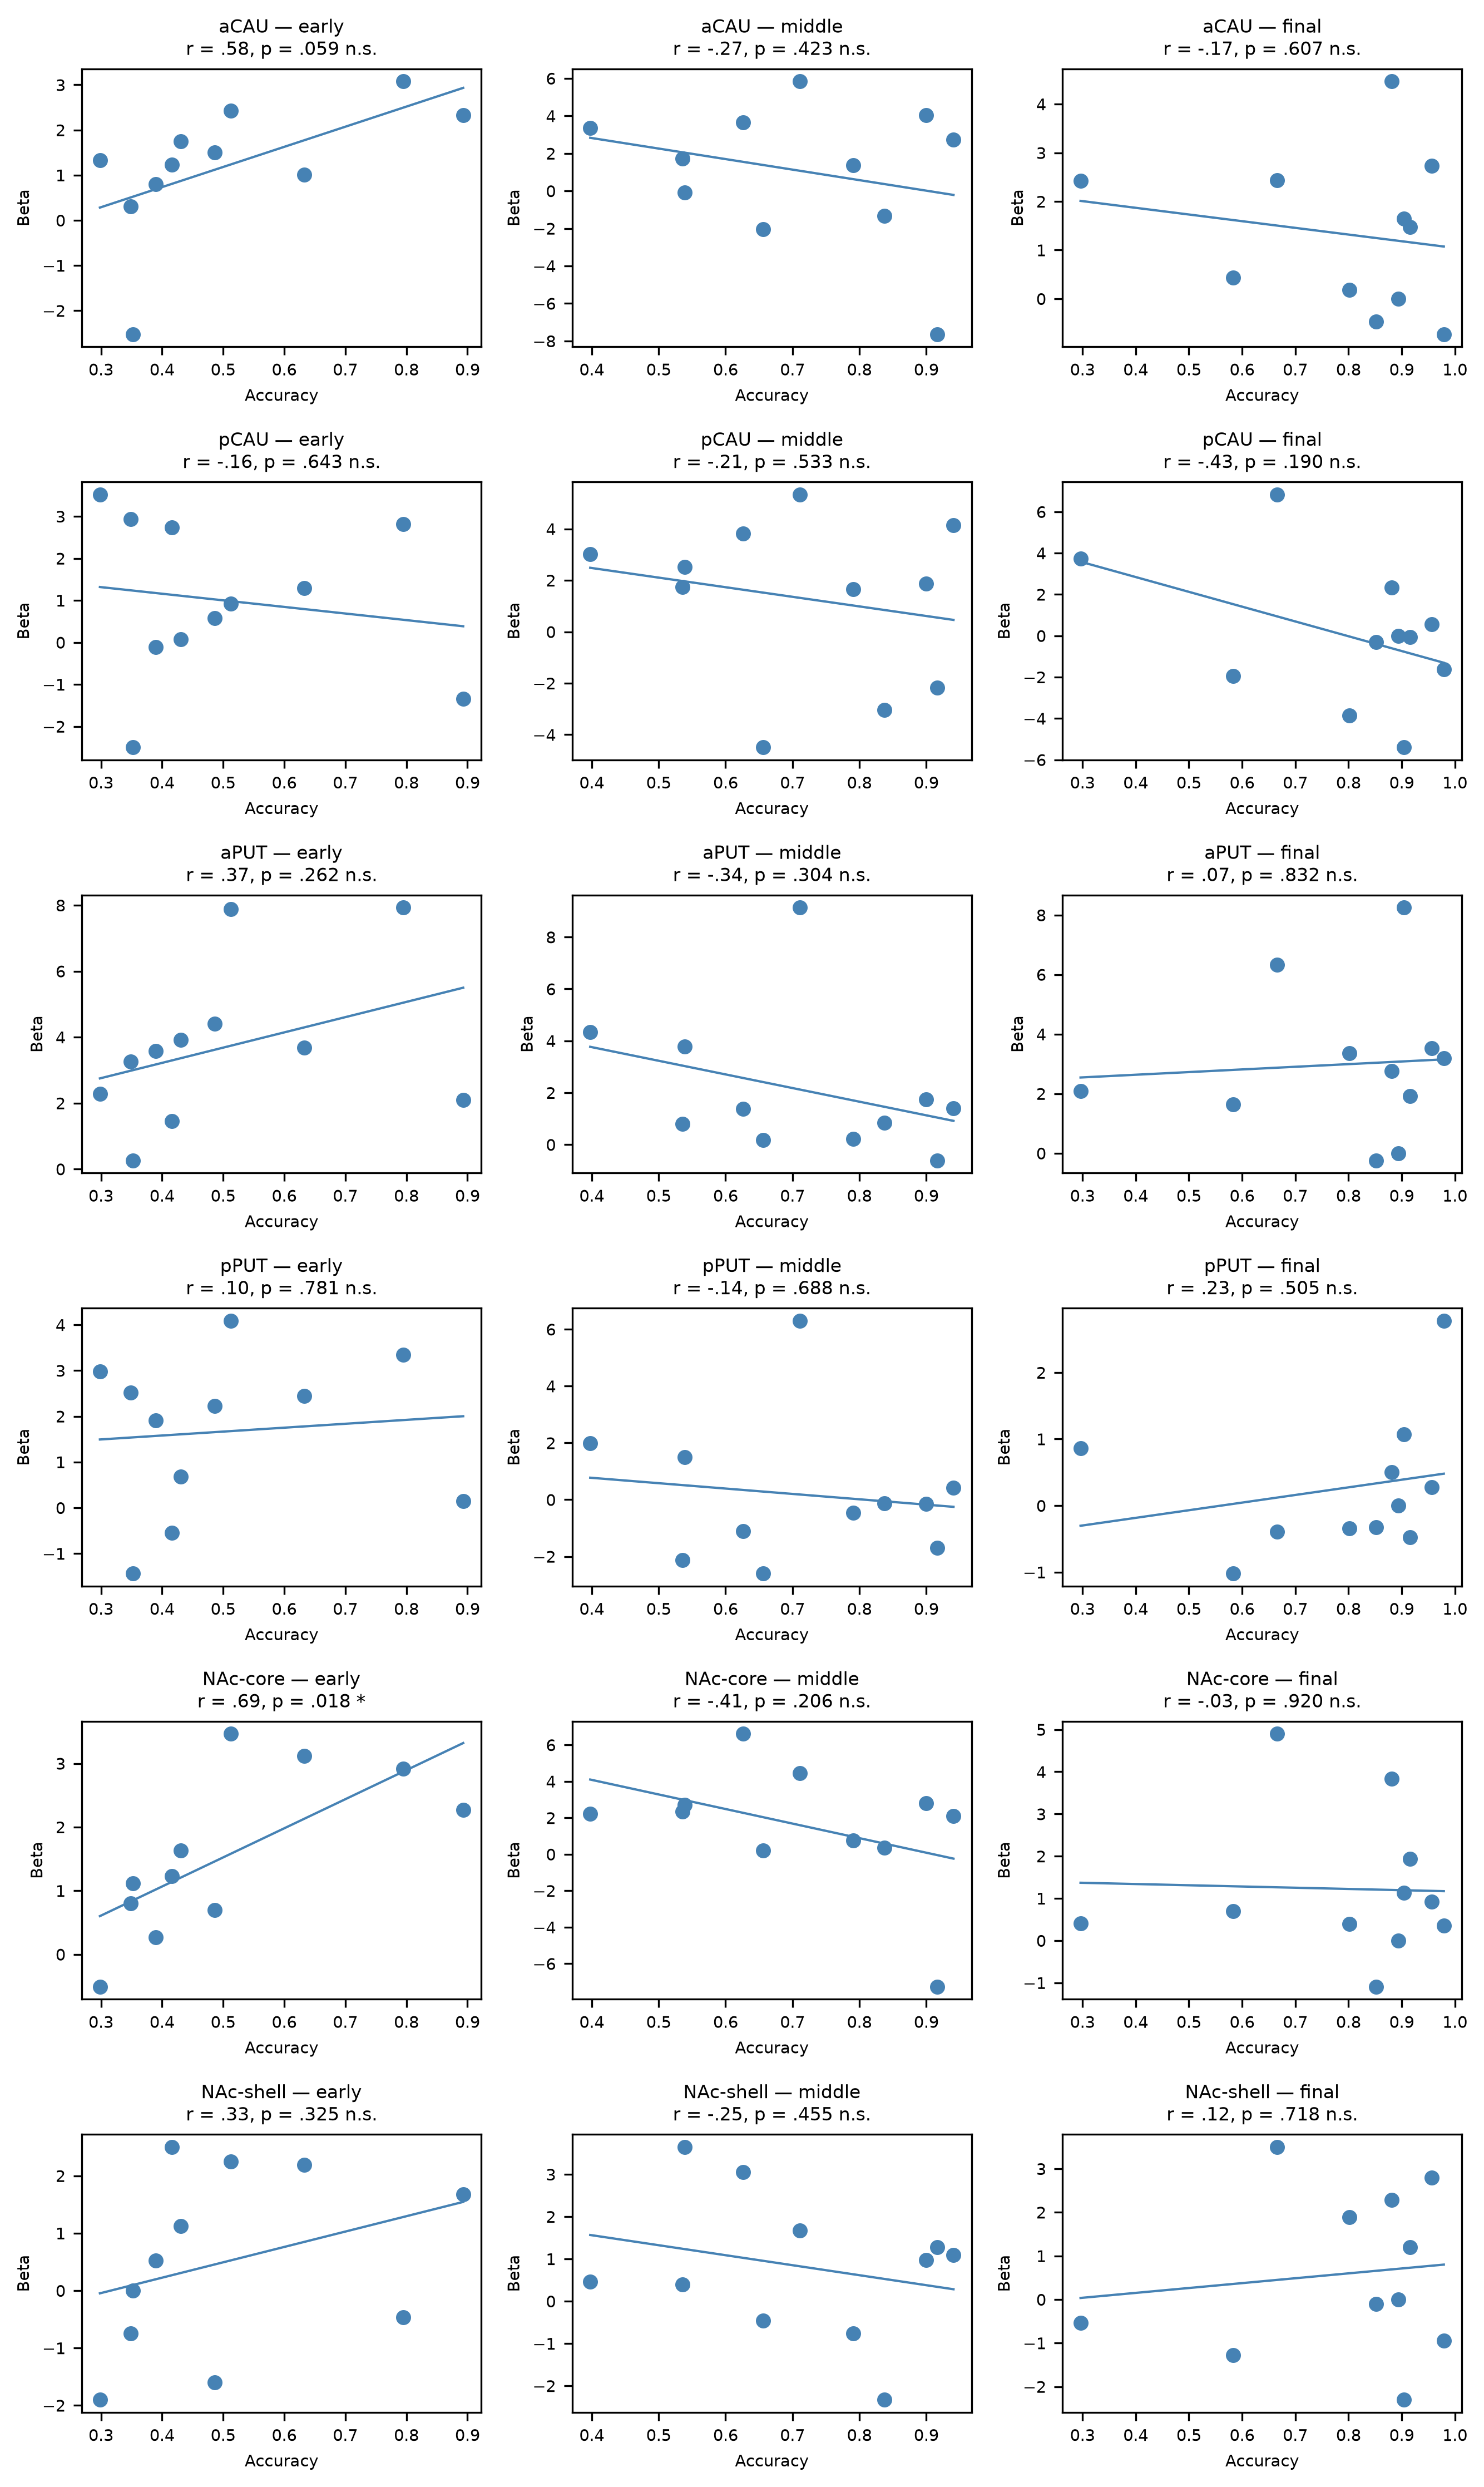

In [50]:
rois = behav_corr_df['roi'].unique()
stages = ['early', 'middle', 'final']

fig, axes = plt.subplots(len(rois), 3, figsize=(9, len(rois) * 2.5), dpi=300, sharex=False, sharey=False)

for ri, roi in enumerate(plot_order): # rois):
    for si, stage in enumerate(stages):
        ax = axes[ri, si]
        sub_df = roi_behav_df[(roi_behav_df['region'] == roi) & 
                              (roi_behav_df['learning_stage'] == stage)]
        
        ax.scatter(sub_df['accuracy'], sub_df['beta'], s=30, color='steelblue', zorder=3)
        
        # regression line
        m, b = np.polyfit(sub_df['accuracy'], sub_df['beta'], 1)
        x_range = np.linspace(sub_df['accuracy'].min(), sub_df['accuracy'].max(), 100)
        ax.plot(x_range, m * x_range + b, color='steelblue', linewidth=1)
        
        # stat annotation
        row = behav_corr_df[(behav_corr_df['roi'] == roi) & 
                            (behav_corr_df['learning_stage'] == stage)].iloc[0]
        p_str = '*' if row['p'] < 0.05 else 'n.s.'
        ax.set_title(f"{roi} — {stage}\n{row['stat_str']} {p_str}", fontsize=8)
        ax.set_xlabel('Accuracy', fontsize=7)
        ax.set_ylabel('Beta', fontsize=7)
        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig(os.path.join(fig_out_dir, f'brain-behav-corr_contrast-{contrast_label}_network-{network_name}_corr-plots.svg'))

NAc-core early: r = .69, p = .018 *
NAc-core middle: r = -.41, p = .206 n.s.
NAc-core final: r = -.03, p = .920 n.s.
NAc-shell early: r = .33, p = .325 n.s.
NAc-shell middle: r = -.25, p = .455 n.s.
NAc-shell final: r = .12, p = .718 n.s.
aCAU early: r = .58, p = .059 n.s.
aCAU middle: r = -.27, p = .423 n.s.
aCAU final: r = -.17, p = .607 n.s.
aPUT early: r = .37, p = .262 n.s.
aPUT middle: r = -.34, p = .304 n.s.
aPUT final: r = .07, p = .832 n.s.
pCAU early: r = -.16, p = .643 n.s.
pCAU middle: r = -.21, p = .533 n.s.
pCAU final: r = -.43, p = .190 n.s.
pPUT early: r = .10, p = .781 n.s.
pPUT middle: r = -.14, p = .688 n.s.
pPUT final: r = .23, p = .505 n.s.


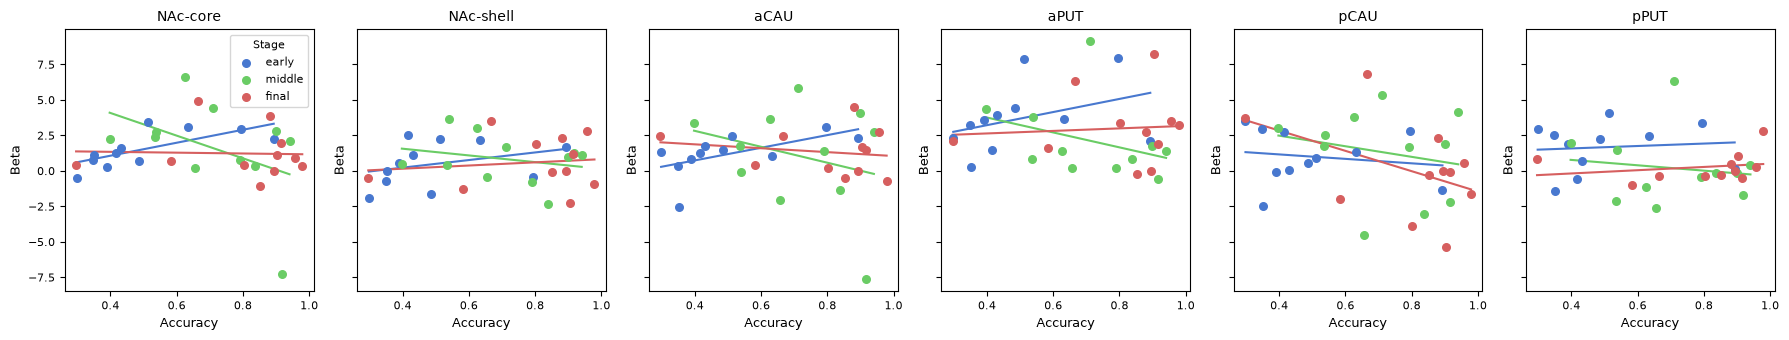

In [51]:
stage_colors = {'early': '#4878CF', 'middle': '#6ACC65', 'final': '#D65F5F'}
stages = ['early', 'middle', 'final']
rois = behav_corr_df['roi'].unique()

fig, axes = plt.subplots(1, len(rois), figsize=(3 * len(rois), 3.5), dpi=100, sharey=True)
if len(rois) == 1:
    axes = [axes]

for ri, roi in enumerate(rois):
    ax = axes[ri]
    for stage in stages:
        color = stage_colors[stage]
        sub_df = roi_behav_df[(roi_behav_df['region'] == roi) &
                              (roi_behav_df['learning_stage'] == stage)]

        ax.scatter(sub_df['accuracy'], sub_df['beta'], s=30,
                   color=color, label=stage, zorder=3)

        m, b = np.polyfit(sub_df['accuracy'], sub_df['beta'], 1)
        x_range = np.linspace(sub_df['accuracy'].min(), sub_df['accuracy'].max(), 100)
        ax.plot(x_range, m * x_range + b, color=color, linewidth=1.5)

        # stat annotation per stage
        row = behav_corr_df[(behav_corr_df['roi'] == roi) &
                            (behav_corr_df['learning_stage'] == stage)].iloc[0]
        p_str = '*' if row['p'] < 0.05 else 'n.s.'
        print(f"{roi} {stage}: {row['stat_str']} {p_str}")

    ax.set_title(roi, fontsize=10)
    ax.set_xlabel('Accuracy', fontsize=9)
    ax.set_ylabel('Beta', fontsize=9)
    ax.tick_params(labelsize=8)

axes[0].legend(title='Stage', fontsize=8, title_fontsize=8)
plt.tight_layout()


### omnibus ANOVA stats

In [52]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import AnovaRM
import pingouin as pg
import sys; sys.path.insert(0, '..')
from stats_fmt import export_anova, export_posthoc, export_ttests, export_pg_anova

stats_out_dir = os.path.join(deriv_dir, 'stats_tables')
os.makedirs(stats_out_dir, exist_ok=True)
fig_out_dir = os.path.join(os.getcwd(), 'figures')
os.makedirs(fig_out_dir, exist_ok=True)


In [53]:
non_mandarin_df.head()

,participant_id,participant_group,region,beta,region_hemi,hemisphere,learning_stage,Axis
0,sub-FLT02,non-Mandarin,aCAU,-0.2102,aCAU-lh,lh,early,Rostral
1,sub-FLT04,non-Mandarin,aCAU,-1.9723,aCAU-lh,lh,early,Rostral
2,sub-FLT06,non-Mandarin,aCAU,-3.8047,aCAU-lh,lh,early,Rostral
3,sub-FLT09,non-Mandarin,aCAU,2.6634,aCAU-lh,lh,early,Rostral
4,sub-FLT11,non-Mandarin,aCAU,1.1982,aCAU-lh,lh,early,Rostral


In [54]:
non_mandarin_df.participant_id.unique()

<StringArray>
['sub-FLT02', 'sub-FLT04', 'sub-FLT06', 'sub-FLT09', 'sub-FLT11', 'sub-FLT12',
 'sub-FLT13', 'sub-FLT14', 'sub-FLT25', 'sub-FLT28', 'sub-FLT30']
Length: 11, dtype: str

#### Mixed-Effects ANOVA with Hemisphere, Axis, and Learning Stage

In [55]:
# Mixed-Effects ANOVA with Hemisphere, Axis, and Interaction
aov = AnovaRM(non_mandarin_df, 
              aggregate_func='mean',
              depvar='beta', 
              subject='participant_id', 
              within=['hemisphere', 'learning_stage','Axis', ]).fit()

# Display results
print('network:', network_name)
print('contrast:', contrast_label)
aov.summary()

network: tian-S2
contrast: sound


,F Value,Num DF,Den DF,Pr > F
hemisphere,0.1740,1.0000,10.0000,0.6854
learning_stage,0.4133,2.0000,20.0000,0.6670
Axis,7.0854,2.0000,20.0000,0.0047
hemisphere:learning_stage,0.4887,2.0000,20.0000,0.6206
hemisphere:Axis,4.2538,2.0000,20.0000,0.0289
learning_stage:Axis,1.4121,4.0000,40.0000,0.2475
hemisphere:learning_stage:Axis,1.5268,4.0000,40.0000,0.2128


In [56]:
export_anova(aov, f'{contrast_label}_{network_name}_hemisphere_learning-stage_axis', stats_out_dir)

,source,F,df_num,df_den,p,stat_str
0,hemisphere,0.17,1.0000,10.0000,p = .685,"F(1, 10) = 0.17, p = .685"
1,learning_stage,0.41,2.0000,20.0000,p = .667,"F(2, 20) = 0.41, p = .667"
2,Axis,7.09,2.0000,20.0000,p = .005,"F(2, 20) = 7.09, p = .005"
3,hemisphere:learning_stage,0.49,2.0000,20.0000,p = .621,"F(2, 20) = 0.49, p = .621"
4,hemisphere:Axis,4.25,2.0000,20.0000,p = .029,"F(2, 20) = 4.25, p = .029"
5,learning_stage:Axis,1.41,4.0000,40.0000,p = .248,"F(4, 40) = 1.41, p = .248"
6,hemisphere:learning_stage:Axis,1.53,4.0000,40.0000,p = .213,"F(4, 40) = 1.53, p = .213"


In [57]:
# GG-corrected bilateral replication (learning_stage x Axis)
bilateral_df = (non_mandarin_df
                .groupby(['participant_id', 'Axis', 'learning_stage'], as_index=False)['beta']
                .mean())
aov_pg = pg.rm_anova(data=bilateral_df, dv='beta',
                     within=['learning_stage', 'Axis'],
                     subject='participant_id',
                     detailed=True)
eta_col = 'np2' if 'np2' in aov_pg.columns else 'ng2'
print(aov_pg[['Source', 'F', 'ddof1', 'ddof2', 'p_unc', 'p_GG_corr', eta_col]])
export_pg_anova(aov_pg, f'{contrast_label}_{network_name}_learning-stage_axis_bilateral', stats_out_dir)

                  Source      F  ddof1  ddof2  p_unc  p_GG_corr    ng2
0         learning_stage 0.4133      2     20 0.6670     0.6379 0.0146
1                   Axis 7.0854      2     20 0.0047     0.0085 0.0818
2  learning_stage * Axis 1.4121      4     40 0.2475     0.2679 0.0199


/ix1/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.14/site-packages/pingouin/distribution.py:514: UserWarning: Epsilon values might be innaccurate in two-way repeated measures design where each  factor has more than 2 levels. Please  double-check your results.
  warnings.warn(


,source,df_num,df_den,F,p_unc,p_GG_corr,eta_p2,stat_str
0,learning_stage,2,20,0.41,p = .667,p = .638,0.01,"F(2, 20) = 0.41, p = .638"
1,Axis,2,20,7.09,p = .005,p = .008,0.08,"F(2, 20) = 7.09, p = .008"
2,learning_stage * Axis,4,40,1.41,p = .248,p = .268,0.02,"F(4, 40) = 1.41, p = .268"


In [58]:
aov_pg

,Source,SS,ddof1,ddof2,MS,F,p_unc,p_GG_corr,ng2,eps
0,learning_stage,5.2865,2,20,2.6433,0.4133,0.6670,0.6379,0.0146,0.8602
1,Axis,31.7944,2,20,15.8972,7.0854,0.0047,0.0085,0.0818,0.8172
2,learning_stage * Axis,7.2379,4,40,1.8095,1.4121,0.2475,0.2679,0.0199,0.3869


In [59]:
# pairwise by Axis

# Pairwise comparisons for region with FDR correction
pairwise_by_region = pg.pairwise_tests(data=non_mandarin_df,
                             dv='beta', 
                             within=['hemisphere','Axis', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_region.columns)

# Display key columns (without 'effsize' and 'CIs' if missing)
print("\nPost-hoc Pairwise Comparisons:")
#print(pairwise_by_region)
#pairwise_by_region[['Contrast', 'learning_stage', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]  # Keep only available columns

pd.set_option('display.max_rows', None)

pairwise_interaction = pairwise_by_region[pairwise_by_region.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p_unc'] < 0.05]
pairwise_interaction[['Contrast', 'hemisphere','A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]

Available columns: Index(['Contrast', 'hemisphere', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='str')

Post-hoc Pairwise Comparisons:


,Contrast,hemisphere,A,B,T,dof,p_unc,p_corr,BF10
0,hemisphere * Axis,lh,Caudal,Rostral,-2.9558,10.0000,0.0144,0.0383,4.519
1,hemisphere * Axis,lh,Caudal,Ventral,0.4142,10.0000,0.6875,0.6875,0.32
2,hemisphere * Axis,lh,Rostral,Ventral,2.7895,10.0000,0.0191,0.0383,3.602
3,hemisphere * Axis,rh,Caudal,Rostral,-5.4283,10.0000,0.0003,0.0017,115.632
4,hemisphere * Axis,rh,Caudal,Ventral,-1.6719,10.0000,0.1255,0.1506,0.867
5,hemisphere * Axis,rh,Rostral,Ventral,2.1571,10.0000,0.0564,0.0846,1.559


In [60]:
export_posthoc(pairwise_by_region, f'{contrast_label}_{network_name}_hemisphere_axis', stats_out_dir)

,Contrast,hemisphere,A,B,t,df,p,p_fdr,stat_str,stat_str_fdr
0,hemisphere,-,lh,rh,-0.42,10.0000,p = .685,p = nan,"t(10) = -0.42, p = .685","t(10) = -0.42, q = nan"
1,Axis,-,Caudal,Rostral,-4.81,10.0000,p < .001,p = .002,"t(10) = -4.81, p < .001","t(10) = -4.81, q = .002"
2,Axis,-,Caudal,Ventral,-0.70,10.0000,p = .497,p = .497,"t(10) = -0.70, p = .497","t(10) = -0.70, q = .497"
3,Axis,-,Rostral,Ventral,2.67,10.0000,p = .023,p = .035,"t(10) = 2.67, p = .023","t(10) = 2.67, q = .035"
4,hemisphere * Axis,lh,Caudal,Rostral,-2.96,10.0000,p = .014,p = .038,"t(10) = -2.96, p = .014","t(10) = -2.96, q = .038"
5,hemisphere * Axis,lh,Caudal,Ventral,0.41,10.0000,p = .687,p = .687,"t(10) = 0.41, p = .687","t(10) = 0.41, q = .687"
6,hemisphere * Axis,lh,Rostral,Ventral,2.79,10.0000,p = .019,p = .038,"t(10) = 2.79, p = .019","t(10) = 2.79, q = .038"
7,hemisphere * Axis,rh,Caudal,Rostral,-5.43,10.0000,p < .001,p = .002,"t(10) = -5.43, p < .001","t(10) = -5.43, q = .002"
8,hemisphere * Axis,rh,Caudal,Ventral,-1.67,10.0000,p = .125,p = .151,"t(10) = -1.67, p = .125","t(10) = -1.67, q = .151"
9,hemisphere * Axis,rh,Rostral,Ventral,2.16,10.0000,p = .056,p = .085,"t(10) = 2.16, p = .056","t(10) = 2.16, q = .085"


In [61]:
# pairwise by Axis

# Pairwise comparisons for region with FDR correction
pairwise_by_region = pg.pairwise_tests(data=non_mandarin_df,
                             dv='beta', 
                             within=['Axis', 'hemisphere',],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_region.columns)

# Display key columns (without 'effsize' and 'CIs' if missing)
print("\nPost-hoc Pairwise Comparisons:")
#print(pairwise_by_region)
#pairwise_by_region[['Contrast', 'learning_stage', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]  # Keep only available columns

pd.set_option('display.max_rows', None)

pairwise_interaction = pairwise_by_region[pairwise_by_region.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p_unc'] < 0.05]
pairwise_interaction[['Contrast', 'Axis', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]

Available columns: Index(['Contrast', 'Axis', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='str')

Post-hoc Pairwise Comparisons:


,Contrast,Axis,A,B,T,dof,p_unc,p_corr,BF10
0,Axis * hemisphere,Caudal,lh,rh,1.2810,10.0000,0.2291,0.3437,0.575
1,Axis * hemisphere,Rostral,lh,rh,-0.6081,10.0000,0.5566,0.5566,0.348
2,Axis * hemisphere,Ventral,lh,rh,-2.2636,10.0000,0.0471,0.1412,1.788


In [62]:
export_posthoc(pairwise_by_region, f'{contrast_label}_{network_name}_axis_hemisphere', stats_out_dir)

,Contrast,A,B,t,df,p,p_fdr,stat_str,stat_str_fdr
0,Axis,Caudal,Rostral,-4.81,10.0000,p < .001,p = .002,"t(10) = -4.81, p < .001","t(10) = -4.81, q = .002"
1,Axis,Caudal,Ventral,-0.70,10.0000,p = .497,p = .497,"t(10) = -0.70, p = .497","t(10) = -0.70, q = .497"
2,Axis,Rostral,Ventral,2.67,10.0000,p = .023,p = .035,"t(10) = 2.67, p = .023","t(10) = 2.67, q = .035"
3,hemisphere,lh,rh,-0.42,10.0000,p = .685,p = nan,"t(10) = -0.42, p = .685","t(10) = -0.42, q = nan"
4,Axis * hemisphere,lh,rh,1.28,10.0000,p = .229,p = .344,"t(10) = 1.28, p = .229","t(10) = 1.28, q = .344"
5,Axis * hemisphere,lh,rh,-0.61,10.0000,p = .557,p = .557,"t(10) = -0.61, p = .557","t(10) = -0.61, q = .557"
6,Axis * hemisphere,lh,rh,-2.26,10.0000,p = .047,p = .141,"t(10) = -2.26, p = .047","t(10) = -2.26, q = .141"


In [63]:
# pairwise by region, no learning stage

# Pairwise comparisons for region with FDR correction
pairwise_by_region_only = pg.pairwise_tests(data=non_mandarin_df,
                             dv='beta', 
                             within=['Axis', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_region_only.columns)

# Display key columns (without 'effsize' and 'CIs' if missing)
print("\nPost-hoc Pairwise Comparisons:")
#print(pairwise_by_region_only)
#pairwise_by_region_only = pairwise_by_region_only[pairwise_by_region_only['p_unc'] < 0.05]
pairwise_by_region_only#[['Contrast', 'Contrast', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]  # Keep only available columns


Available columns: Index(['Contrast', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof', 'alternative',
       'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='str')

Post-hoc Pairwise Comparisons:


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,hedges
0,Axis,Caudal,Rostral,True,True,-4.8081,10.0000,two-sided,0.0007,0.0021,fdr,53.719,-0.8234
1,Axis,Caudal,Ventral,True,True,-0.7047,10.0000,two-sided,0.4971,0.4971,fdr,0.367,-0.2117
2,Axis,Rostral,Ventral,True,True,2.6720,10.0000,two-sided,0.0234,0.0351,fdr,3.072,0.7705


In [64]:
export_posthoc(pairwise_by_region_only, f'{contrast_label}_{network_name}_axis', stats_out_dir)

,Contrast,A,B,t,df,p,p_fdr,stat_str,stat_str_fdr
0,Axis,Caudal,Rostral,-4.81,10.0000,p < .001,p = .002,"t(10) = -4.81, p < .001","t(10) = -4.81, q = .002"
1,Axis,Caudal,Ventral,-0.70,10.0000,p = .497,p = .497,"t(10) = -0.70, p = .497","t(10) = -0.70, q = .497"
2,Axis,Rostral,Ventral,2.67,10.0000,p = .023,p = .035,"t(10) = 2.67, p = .023","t(10) = 2.67, q = .035"


#### Mixed-Effects ANOVA with Hemisphere, Region, and Learning Stage

In [65]:
# Mixed-Effects ANOVA with Hemisphere, Region, and Interaction
aov = AnovaRM(non_mandarin_df, 
              aggregate_func='mean',
              depvar='beta', 
              subject='participant_id', 
              within=['hemisphere', 'learning_stage','region', ]).fit()

# Display results
print('network:', network_name)
print('contrast:', contrast_label)
aov.summary()

network: tian-S2
contrast: sound


,F Value,Num DF,Den DF,Pr > F
hemisphere,0.1740,1.0000,10.0000,0.6854
learning_stage,0.4133,2.0000,20.0000,0.6670
region,6.1408,5.0000,50.0000,0.0002
hemisphere:learning_stage,0.4887,2.0000,20.0000,0.6206
hemisphere:region,1.9390,5.0000,50.0000,0.1044
learning_stage:region,1.1409,10.0000,100.0000,0.3400
hemisphere:learning_stage:region,1.0048,10.0000,100.0000,0.4448


In [66]:
export_anova(aov, f'{contrast_label}_{network_name}_hemisphere_learning-stage_region', stats_out_dir)

,source,F,df_num,df_den,p,stat_str
0,hemisphere,0.17,1.0000,10.0000,p = .685,"F(1, 10) = 0.17, p = .685"
1,learning_stage,0.41,2.0000,20.0000,p = .667,"F(2, 20) = 0.41, p = .667"
2,region,6.14,5.0000,50.0000,p < .001,"F(5, 50) = 6.14, p < .001"
3,hemisphere:learning_stage,0.49,2.0000,20.0000,p = .621,"F(2, 20) = 0.49, p = .621"
4,hemisphere:region,1.94,5.0000,50.0000,p = .104,"F(5, 50) = 1.94, p = .104"
5,learning_stage:region,1.14,10.0000,100.0000,p = .340,"F(10, 100) = 1.14, p = .340"
6,hemisphere:learning_stage:region,1.00,10.0000,100.0000,p = .445,"F(10, 100) = 1.00, p = .445"


In [67]:
# GG-corrected bilateral replication (learning_stage x region)
bilateral_df = (non_mandarin_df
                .groupby(['participant_id', 'region', 'learning_stage'], as_index=False)['beta']
                .mean())
aov_pg = pg.rm_anova(data=bilateral_df, dv='beta',
                     within=['learning_stage', 'region'],
                     subject='participant_id',
                     detailed=True)
eta_col = 'np2' if 'np2' in aov_pg.columns else 'ng2'
print(aov_pg[['Source', 'F', 'ddof1', 'ddof2', 'p_unc', 'p_GG_corr', eta_col]])
export_pg_anova(aov_pg, f'{contrast_label}_{network_name}_learning-stage_region_bilateral', stats_out_dir)

                    Source      F  ddof1  ddof2  p_unc  p_GG_corr    ng2
0           learning_stage 0.4133      2     20 0.6670     0.6379 0.0105
1                   region 6.1408      5     50 0.0002     0.0026 0.1113
2  learning_stage * region 1.1409     10    100 0.3400     0.3451 0.0299


/ix1/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.14/site-packages/pingouin/distribution.py:514: UserWarning: Epsilon values might be innaccurate in two-way repeated measures design where each  factor has more than 2 levels. Please  double-check your results.
  warnings.warn(


,source,df_num,df_den,F,p_unc,p_GG_corr,eta_p2,stat_str
0,learning_stage,2,20,0.41,p = .667,p = .638,0.01,"F(2, 20) = 0.41, p = .638"
1,region,5,50,6.14,p < .001,p = .003,0.11,"F(5, 50) = 6.14, p = .003"
2,learning_stage * region,10,100,1.14,p = .340,p = .345,0.03,"F(10, 100) = 1.14, p = .345"


In [68]:
# Pairwise comparisons for region with FDR correction
pairwise_by_learning_stage = pg.pairwise_tests(data=non_mandarin_df,
                             dv='beta', 
                             within=['hemisphere','region', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_learning_stage.columns)

# Display key columns (without 'effsize' and 'CIs' if missing)
print("\nPost-hoc Pairwise Comparisons:")
#print(pairwise_by_learning_stage)
#pairwise_by_learning_stage[['Contrast', 'learning_stage', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]  # Keep only available columns

pd.set_option('display.max_rows', None)

pairwise_interaction = pairwise_by_learning_stage[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
pairwise_interaction = pairwise_interaction[pairwise_interaction['p_corr'] < 0.05].reset_index()
pairwise_interaction[['Contrast', 'hemisphere', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]

Available columns: Index(['Contrast', 'hemisphere', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='str')

Post-hoc Pairwise Comparisons:


,Contrast,hemisphere,A,B,T,dof,p_unc,p_corr,BF10
0,hemisphere * region,lh,NAc-core,aPUT,-4.8315,10.0000,0.0007,0.0052,55.333
1,hemisphere * region,lh,NAc-shell,aPUT,-4.1604,10.0000,0.0019,0.0117,23.179
2,hemisphere * region,lh,aCAU,aPUT,-4.8547,10.0000,0.0007,0.0052,56.981
3,hemisphere * region,lh,aPUT,pPUT,6.0099,10.0000,0.0001,0.0020,228.948
4,hemisphere * region,rh,NAc-shell,aPUT,-3.7787,10.0000,0.0036,0.0135,13.901
5,hemisphere * region,rh,aCAU,aPUT,-3.8604,10.0000,0.0032,0.0135,15.521
6,hemisphere * region,rh,aPUT,pCAU,3.9960,10.0000,0.0025,0.0127,18.62
7,hemisphere * region,rh,aPUT,pPUT,7.1291,10.0000,0.0000,0.0010,773.911


In [69]:
export_posthoc(pairwise_by_learning_stage, f'{contrast_label}_{network_name}_hemisphere_region', stats_out_dir)

,Contrast,hemisphere,A,B,t,df,p,p_fdr,stat_str,stat_str_fdr
0,hemisphere,-,lh,rh,-0.42,10.0000,p = .685,p = nan,"t(10) = -0.42, p = .685","t(10) = -0.42, q = nan"
1,region,-,NAc-core,NAc-shell,2.00,10.0000,p = .074,p = .185,"t(10) = 2.00, p = .074","t(10) = 2.00, q = .185"
2,region,-,NAc-core,aCAU,0.75,10.0000,p = .468,p = .585,"t(10) = 0.75, p = .468","t(10) = 0.75, q = .585"
3,region,-,NAc-core,aPUT,-4.09,10.0000,p = .002,p = .008,"t(10) = -4.09, p = .002","t(10) = -4.09, q = .008"
4,region,-,NAc-core,pCAU,1.27,10.0000,p = .234,p = .418,"t(10) = 1.27, p = .234","t(10) = 1.27, q = .418"
5,region,-,NAc-core,pPUT,1.45,10.0000,p = .177,p = .380,"t(10) = 1.45, p = .177","t(10) = 1.45, q = .380"
6,region,-,NAc-shell,aCAU,-1.01,10.0000,p = .335,p = .474,"t(10) = -1.01, p = .335","t(10) = -1.01, q = .474"
7,region,-,NAc-shell,aPUT,-4.15,10.0000,p = .002,p = .008,"t(10) = -4.15, p = .002","t(10) = -4.15, q = .008"
8,region,-,NAc-shell,pCAU,-0.21,10.0000,p = .837,p = .916,"t(10) = -0.21, p = .837","t(10) = -0.21, q = .916"
9,region,-,NAc-shell,pPUT,-0.11,10.0000,p = .916,p = .916,"t(10) = -0.11, p = .916","t(10) = -0.11, q = .916"


In [70]:
# Pairwise comparisons for region with FDR correction
pairwise_by_learning_stage = pg.pairwise_tests(data=non_mandarin_df,
                             dv='beta', 
                             within=['region', 'hemisphere',],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_learning_stage.columns)

# Display key columns (without 'effsize' and 'CIs' if missing)
print("\nPost-hoc Pairwise Comparisons:")
#print(pairwise_by_learning_stage)
#pairwise_by_learning_stage[['Contrast', 'learning_stage', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]  # Keep only available columns

pd.set_option('display.max_rows', None)

pairwise_interaction = pairwise_by_learning_stage[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p_corr'] < 0.05].reset_index()
pairwise_interaction[['Contrast', 'region', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]

Available columns: Index(['Contrast', 'region', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='str')

Post-hoc Pairwise Comparisons:


,Contrast,region,A,B,T,dof,p_unc,p_corr,BF10
0,region * hemisphere,NAc-core,lh,rh,-1.8719,10.0000,0.0907,0.2667,1.095
1,region * hemisphere,NAc-shell,lh,rh,-1.6339,10.0000,0.1333,0.2667,0.83
2,region * hemisphere,aCAU,lh,rh,-1.2367,10.0000,0.2445,0.3667,0.552
3,region * hemisphere,aPUT,lh,rh,0.7988,10.0000,0.4430,0.5316,0.389
4,region * hemisphere,pCAU,lh,rh,0.3178,10.0000,0.7572,0.7572,0.311
5,region * hemisphere,pPUT,lh,rh,2.2299,10.0000,0.0498,0.2667,1.711


In [71]:
export_posthoc(pairwise_by_learning_stage, f'{contrast_label}_{network_name}_region_hemisphere', stats_out_dir)

,Contrast,region,A,B,t,df,p,p_fdr,stat_str,stat_str_fdr
0,region,-,NAc-core,NAc-shell,2.00,10.0000,p = .074,p = .185,"t(10) = 2.00, p = .074","t(10) = 2.00, q = .185"
1,region,-,NAc-core,aCAU,0.75,10.0000,p = .468,p = .585,"t(10) = 0.75, p = .468","t(10) = 0.75, q = .585"
2,region,-,NAc-core,aPUT,-4.09,10.0000,p = .002,p = .008,"t(10) = -4.09, p = .002","t(10) = -4.09, q = .008"
3,region,-,NAc-core,pCAU,1.27,10.0000,p = .234,p = .418,"t(10) = 1.27, p = .234","t(10) = 1.27, q = .418"
4,region,-,NAc-core,pPUT,1.45,10.0000,p = .177,p = .380,"t(10) = 1.45, p = .177","t(10) = 1.45, q = .380"
5,region,-,NAc-shell,aCAU,-1.01,10.0000,p = .335,p = .474,"t(10) = -1.01, p = .335","t(10) = -1.01, q = .474"
6,region,-,NAc-shell,aPUT,-4.15,10.0000,p = .002,p = .008,"t(10) = -4.15, p = .002","t(10) = -4.15, q = .008"
7,region,-,NAc-shell,pCAU,-0.21,10.0000,p = .837,p = .916,"t(10) = -0.21, p = .837","t(10) = -0.21, q = .916"
8,region,-,NAc-shell,pPUT,-0.11,10.0000,p = .916,p = .916,"t(10) = -0.11, p = .916","t(10) = -0.11, q = .916"
9,region,-,aCAU,aPUT,-5.40,10.0000,p < .001,p = .002,"t(10) = -5.40, p < .001","t(10) = -5.40, q = .002"


In [72]:
# pairwise by region, no learning stage

# Pairwise comparisons for region with FDR correction
pairwise_by_region_only = pg.pairwise_tests(data=non_mandarin_df,
                             dv='beta', 
                             within=['region', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_region_only.columns)

# Display key columns (without 'effsize' and 'CIs' if missing)
print("\nPost-hoc Pairwise Comparisons:")
#print(pairwise_by_region_only)
pairwise_by_region_only = pairwise_by_region_only[pairwise_by_region_only['p_unc'] < 0.05]
pairwise_by_region_only[['Contrast', 'Contrast', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]  # Keep only available columns


Available columns: Index(['Contrast', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof', 'alternative',
       'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='str')

Post-hoc Pairwise Comparisons:


,Contrast,Contrast,A,B,T,dof,p_unc,p_corr,BF10
2,region,region,NAc-core,aPUT,-4.0861,10.0000,0.0022,0.0082,21.001
6,region,region,NAc-shell,aPUT,-4.1493,10.0000,0.0020,0.0082,22.842
9,region,region,aCAU,aPUT,-5.4047,10.0000,0.0003,0.0022,112.397
12,region,region,aPUT,pCAU,3.3657,10.0000,0.0072,0.0215,7.922
13,region,region,aPUT,pPUT,8.7600,10.0000,0.0000,0.0001,3718.628


In [73]:
export_posthoc(pairwise_by_region_only, f'{contrast_label}_{network_name}_region', stats_out_dir)

,Contrast,A,B,t,df,p,p_fdr,stat_str,stat_str_fdr
2,region,NAc-core,aPUT,-4.09,10.0000,p = .002,p = .008,"t(10) = -4.09, p = .002","t(10) = -4.09, q = .008"
6,region,NAc-shell,aPUT,-4.15,10.0000,p = .002,p = .008,"t(10) = -4.15, p = .002","t(10) = -4.15, q = .008"
9,region,aCAU,aPUT,-5.40,10.0000,p < .001,p = .002,"t(10) = -5.40, p < .001","t(10) = -5.40, q = .002"
12,region,aPUT,pCAU,3.37,10.0000,p = .007,p = .022,"t(10) = 3.37, p = .007","t(10) = 3.37, q = .022"
13,region,aPUT,pPUT,8.76,10.0000,p < .001,p < .001,"t(10) = 8.76, p < .001","t(10) = 8.76, q < .001"


In [74]:
# pairwise by region, no learning stage

# Pairwise comparisons for region with FDR correction
pairwise_by_region_only = pg.pairwise_tests(data=non_mandarin_df,
                             dv='beta', 
                             within=['learning_stage', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_region_only.columns)

# Display key columns (without 'effsize' and 'CIs' if missing)
print("\nPost-hoc Pairwise Comparisons:")
#print(pairwise_by_region_only)
#pairwise_by_region_only = pairwise_by_region_only[pairwise_by_region_only['p_unc'] < 0.05]
pairwise_by_region_only[['Contrast', 'Contrast', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]  # Keep only available columns


Available columns: Index(['Contrast', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof', 'alternative',
       'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='str')

Post-hoc Pairwise Comparisons:


,Contrast,Contrast,A,B,T,dof,p_unc,p_corr,BF10
0,learning_stage,learning_stage,early,final,1.0200,10.0000,0.3318,0.8556,0.457
1,learning_stage,learning_stage,early,middle,0.5867,10.0000,0.5704,0.8556,0.345
2,learning_stage,learning_stage,final,middle,-0.1750,10.0000,0.8646,0.8646,0.301


In [75]:
export_posthoc(pairwise_by_region_only, f'{contrast_label}_{network_name}_learning-stage', stats_out_dir)

,Contrast,A,B,t,df,p,p_fdr,stat_str,stat_str_fdr
0,learning_stage,early,final,1.02,10.0000,p = .332,p = .856,"t(10) = 1.02, p = .332","t(10) = 1.02, q = .856"
1,learning_stage,early,middle,0.59,10.0000,p = .570,p = .856,"t(10) = 0.59, p = .570","t(10) = 0.59, q = .856"
2,learning_stage,final,middle,-0.18,10.0000,p = .865,p = .865,"t(10) = -0.18, p = .865","t(10) = -0.18, q = .865"


### Collapse (average) over non-significant factors

In [76]:
roi_df_collapsed = roi_df_long.groupby(["participant_id", "region", 'learning_stage'], 
                                       as_index=False).agg({"beta": "mean"})


In [77]:
# Collect results
results = []

for region, data in roi_df_collapsed.groupby("region"):
    t_stat, p_val = ttest_1samp(data["beta"], 0)
    results.append({
        "region": region,
        "t_stat": t_stat,
        "p_val": p_val
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Apply FDR correction
results_df["p_val_fdr"] = multipletests(results_df["p_val"], method="fdr_bh")[1]

# Print or export the table
results_df

# Optional: export
# results_df.to_csv("roi_stats.csv", index=False)
# results_df.to_excel("roi_stats.xlsx", index=False)


,region,t_stat,p_val,p_val_fdr
0,NAc-core,3.6428,0.0009,0.0028
1,NAc-shell,2.2132,0.0341,0.0511
2,aCAU,2.8430,0.0077,0.0154
3,aPUT,6.5704,0.0000,0.0000
4,pCAU,1.5500,0.1310,0.1310
5,pPUT,2.1123,0.0426,0.0511


In [78]:
_export = results_df.rename(columns={'t_stat': 't', 'p_val': 'p'}).copy()
_export['df'] = len(sub_list_nman) - 1
export_ttests(_export.to_dict('records'), f'{contrast_label}_{network_name}_baseline_by_region', stats_out_dir)

,region,t,p,p_val_fdr,df,p_fdr,stat_str,stat_str_fdr
0,NAc-core,3.64,p < .001,0.0028,10,p = .003,"t(10) = 3.64, p < .001","t(10) = 3.64, q = .003"
1,NAc-shell,2.21,p = .034,0.0511,10,p = .051,"t(10) = 2.21, p = .034","t(10) = 2.21, q = .051"
2,aCAU,2.84,p = .008,0.0154,10,p = .015,"t(10) = 2.84, p = .008","t(10) = 2.84, q = .015"
3,aPUT,6.57,p < .001,0.0000,10,p < .001,"t(10) = 6.57, p < .001","t(10) = 6.57, q < .001"
4,pCAU,1.55,p = .131,0.1310,10,p = .131,"t(10) = 1.55, p = .131","t(10) = 1.55, q = .131"
5,pPUT,2.11,p = .043,0.0511,10,p = .051,"t(10) = 2.11, p = .043","t(10) = 2.11, q = .051"


### Make 3D plots

In [79]:

roi_df_collapsed = roi_df_long.groupby(["participant_id", "region_hemi"], 
                                       as_index=False).agg({"beta": "mean"})

# Collect p-values
p_values = []
t_stats = []
comparisons = []

for region, data in roi_df_collapsed.groupby(["region_hemi"]):
    t_stat, p_val = ttest_1samp(data["beta"], 0)
    p_values.append(p_val)
    comparisons.append((region[0], t_stat))
    t_stats.append(t_stat)

# Apply FDR correction
_, p_corrected, _, _ = multipletests(p_values, method='fdr_bh')

# Print corrected results
for (region, t_stat), p_val_corr in zip(comparisons, p_corrected):
    print(f"Region: {region}, t = {t_stat:.2f}; corrected p = {p_val_corr:.4f}")


Region: NAc-core-lh, t = 2.22; corrected p = 0.0869
Region: NAc-core-rh, t = 4.31; corrected p = 0.0062
Region: NAc-shell-lh, t = 1.15; corrected p = 0.3700
Region: NAc-shell-rh, t = 2.52; corrected p = 0.0725
Region: aCAU-lh, t = 1.49; corrected p = 0.2490
Region: aCAU-rh, t = 3.14; corrected p = 0.0317
Region: aPUT-lh, t = 6.48; corrected p = 0.0005
Region: aPUT-rh, t = 6.38; corrected p = 0.0005
Region: pCAU-lh, t = 0.96; corrected p = 0.3917
Region: pCAU-rh, t = 1.05; corrected p = 0.3840
Region: pPUT-lh, t = 2.34; corrected p = 0.0825
Region: pPUT-rh, t = 0.77; corrected p = 0.4586


In [80]:

_records = [{'region_hemi': c[0], 't': c[1], 'df': len(sub_list_nman) - 1, 'p': p}
            for c, p in zip(comparisons, p_values)]
export_ttests(_records, f'{contrast_label}_{network_name}_baseline_by_region_hemi', stats_out_dir)

,region_hemi,t,df,p,p_fdr,stat_str,stat_str_fdr
0,NAc-core-lh,2.22,10,p = .051,p = .087,"t(10) = 2.22, p = .051","t(10) = 2.22, q = .087"
1,NAc-core-rh,4.31,10,p = .002,p = .006,"t(10) = 4.31, p = .002","t(10) = 4.31, q = .006"
2,NAc-shell-lh,1.15,10,p = .277,p = .370,"t(10) = 1.15, p = .277","t(10) = 1.15, q = .370"
3,NAc-shell-rh,2.52,10,p = .030,p = .073,"t(10) = 2.52, p = .030","t(10) = 2.52, q = .073"
4,aCAU-lh,1.49,10,p = .166,p = .249,"t(10) = 1.49, p = .166","t(10) = 1.49, q = .249"
5,aCAU-rh,3.14,10,p = .011,p = .032,"t(10) = 3.14, p = .011","t(10) = 3.14, q = .032"
6,aPUT-lh,6.48,10,p < .001,p < .001,"t(10) = 6.48, p < .001","t(10) = 6.48, q < .001"
7,aPUT-rh,6.38,10,p < .001,p < .001,"t(10) = 6.38, p < .001","t(10) = 6.38, q < .001"
8,pCAU-lh,0.96,10,p = .359,p = .392,"t(10) = 0.96, p = .359","t(10) = 0.96, q = .392"
9,pCAU-rh,1.05,10,p = .320,p = .384,"t(10) = 1.05, p = .320","t(10) = 1.05, q = .384"


### Striatal ROI plot (t-statistic)

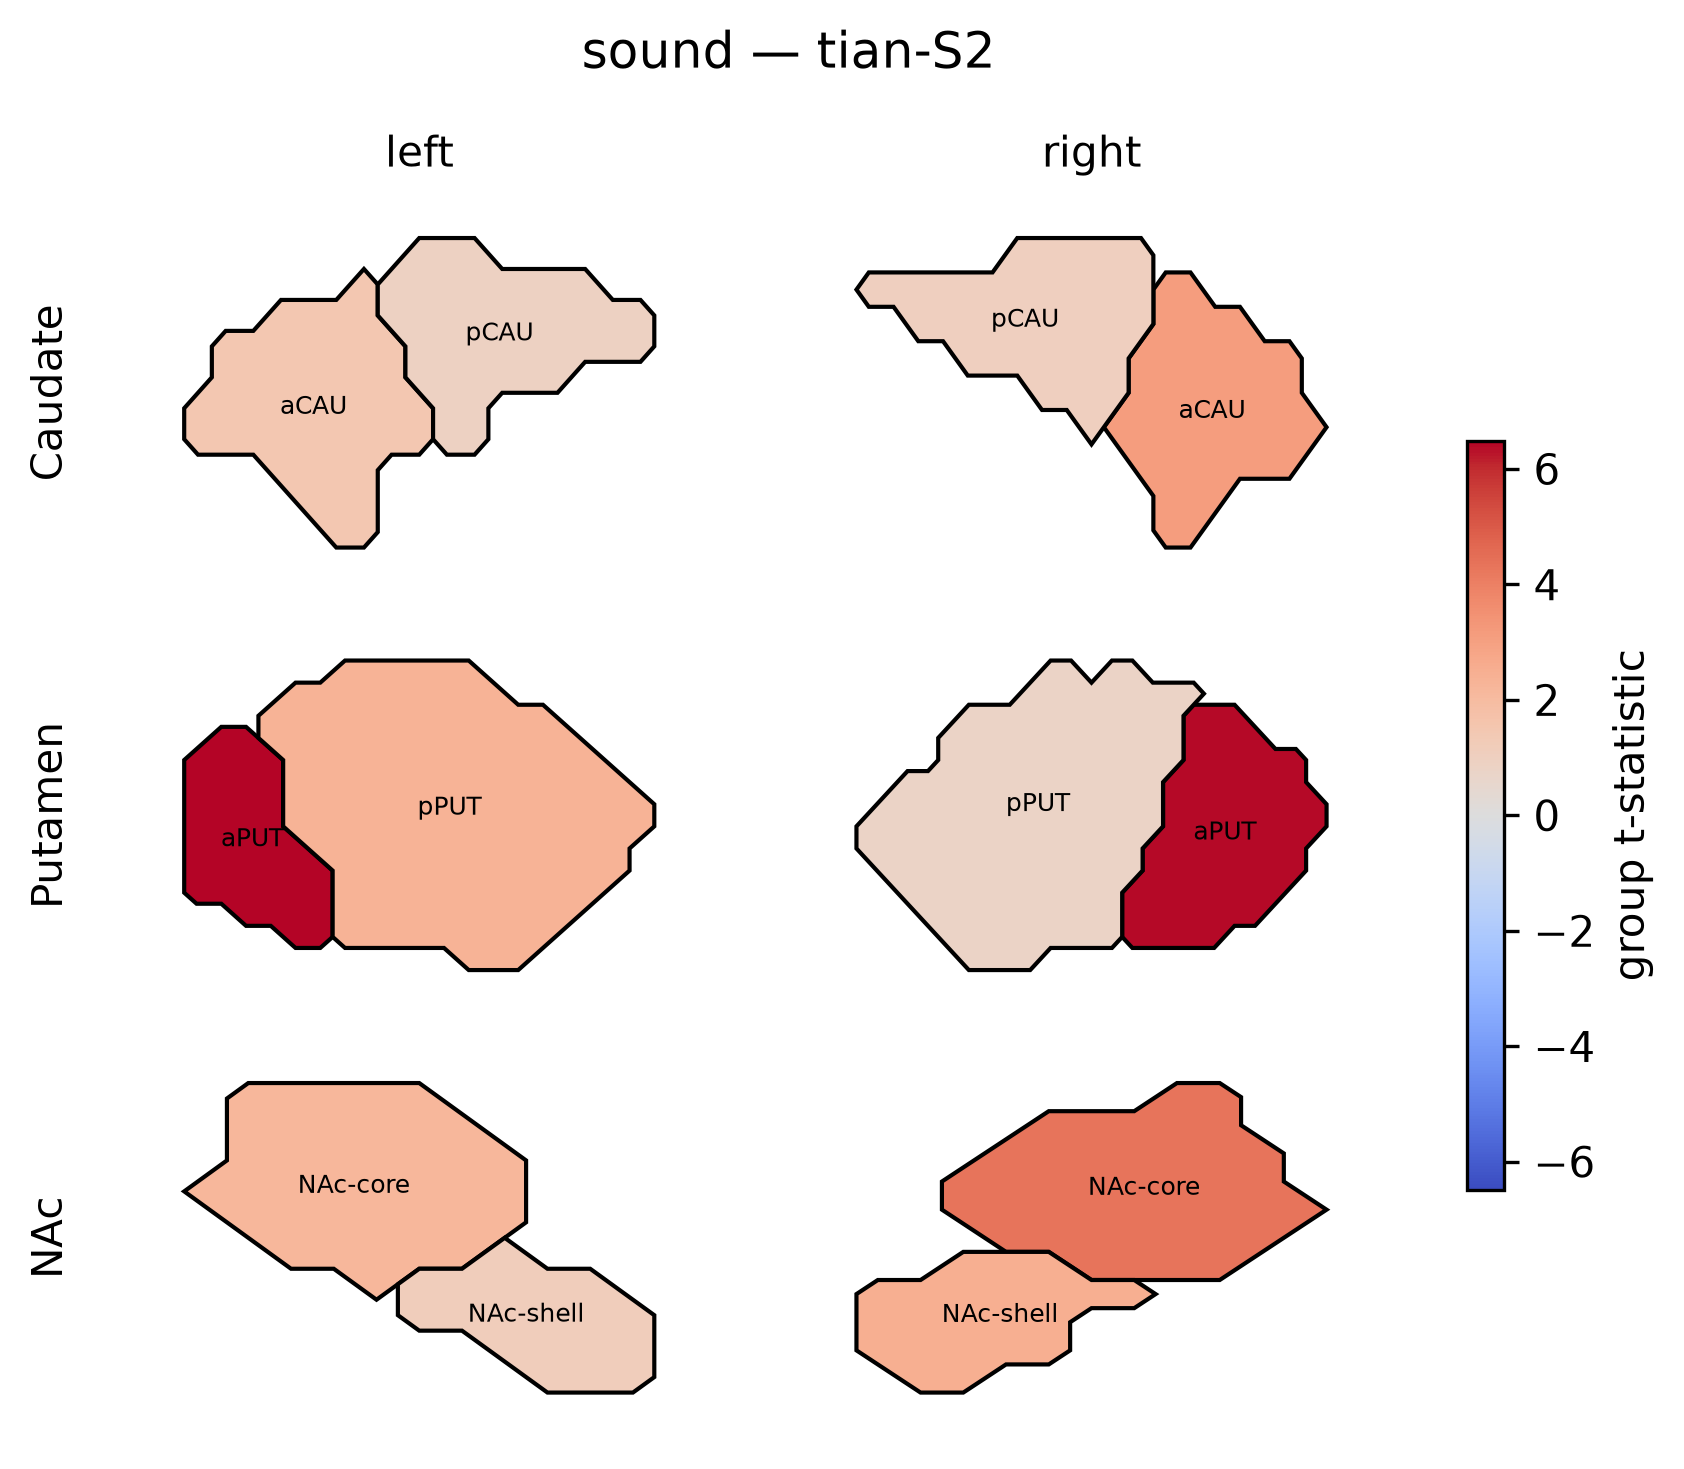

In [81]:
structure_groups = {
    'Caudate': ['aCAU', 'pCAU'],
    'Putamen': ['aPUT', 'pPUT'],
    'NAc': ['NAc-core', 'NAc-shell'],
}
stat_dict = {c[0]: c[1] for c in comparisons}
mask_path_dict = build_mask_path_dict(list(stat_dict.keys()), masks_dir, network_name, space_label)

fig = plot_striatal_roi_stat(stat_dict, mask_path_dict, structure_groups, title=f'{contrast_label} — {network_name}')
fig.savefig(os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_striatal-tstat.svg'))
fig.savefig(os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_striatal-tstat.png'))


### Striatal ROI plot (t-statistic) — yabplot alternative

In [82]:
# Optional alternative: yabplot 3D rendering of the same stat_dict, run via a
# separate cluster conda env ("yabplot", /bgfs/bchandrasekaran/krs228/software/miniconda3/envs/yabplot/bin/python)
# since this notebook's kernel doesn't have yabplot installed. See
# 05_masking/build_yabplot_tian_s2_atlas.py for building the atlas this
# depends on. The next cell runs in that separate environment via %%script;
# this cell just writes it the inputs it needs as JSON since the two
# environments can't share Python objects directly.
import json

yabplot_handoff_path = '/tmp/_yabplot_handoff.json'
yabplot_out_png = os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_striatal-tstat_yabplot.png')

with open(yabplot_handoff_path, 'w') as f:
    json.dump({
        'stat_dict': stat_dict,
        'atlas_dir': os.path.join(os.getcwd(), '..', '05_masking', 'yabplot_atlases', 'tian_S2'),
        'out_png': yabplot_out_png,
        'title': f'{contrast_label} — {network_name}',
    }, f)


In [83]:
%%script /bgfs/bchandrasekaran/krs228/software/miniconda3/envs/yabplot/bin/python
import json, sys
with open('/tmp/_yabplot_handoff.json') as f:
    params = json.load(f)

sys.path.insert(0, '..')
from striatal_yabplot import plot_striatal_roi_stat_yabplot

fig = plot_striatal_roi_stat_yabplot(params['stat_dict'], atlas_dir=params['atlas_dir'],
                                      title=params['title'])
fig.savefig(params['out_png'])
print('saved', params['out_png'])


Couldn't find program: '/bgfs/bchandrasekaran/krs228/software/miniconda3/envs/yabplot/bin/python'


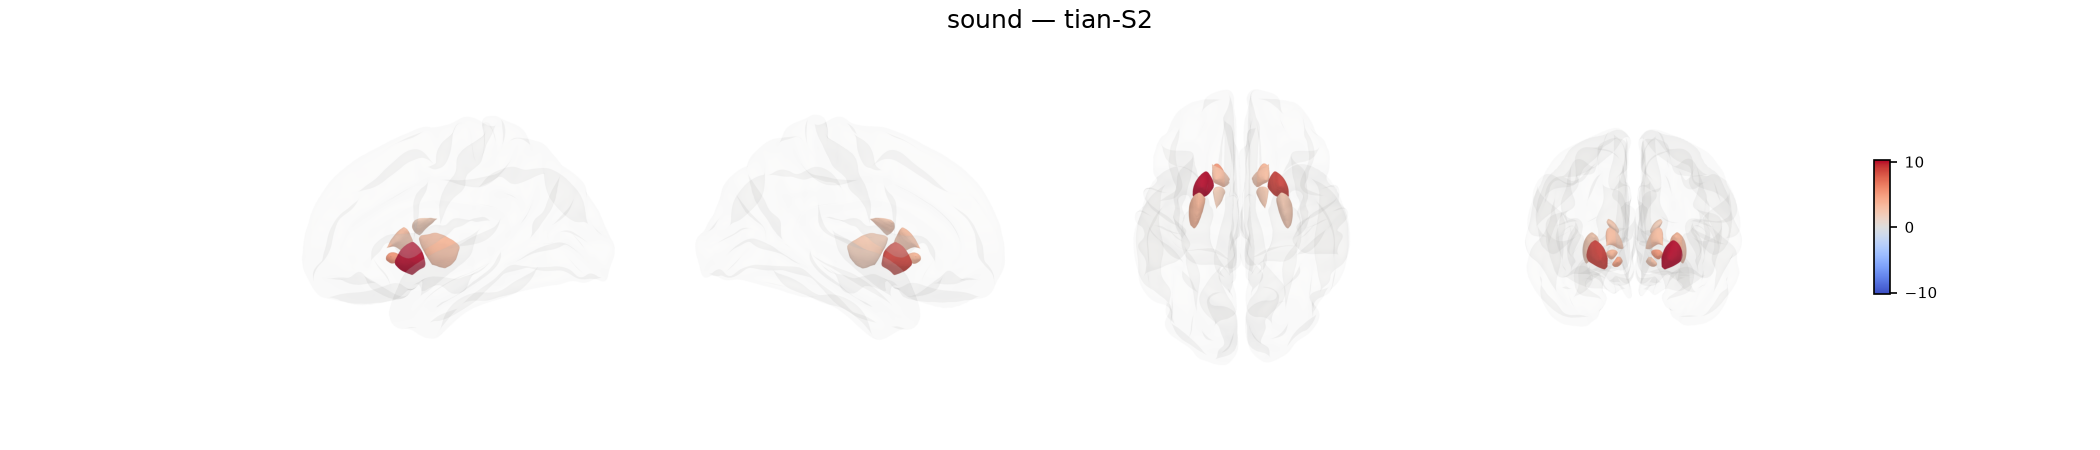

In [84]:
from IPython.display import Image
Image(filename=yabplot_out_png)


### Striatal ROI plot (t-statistic, final vs. early)

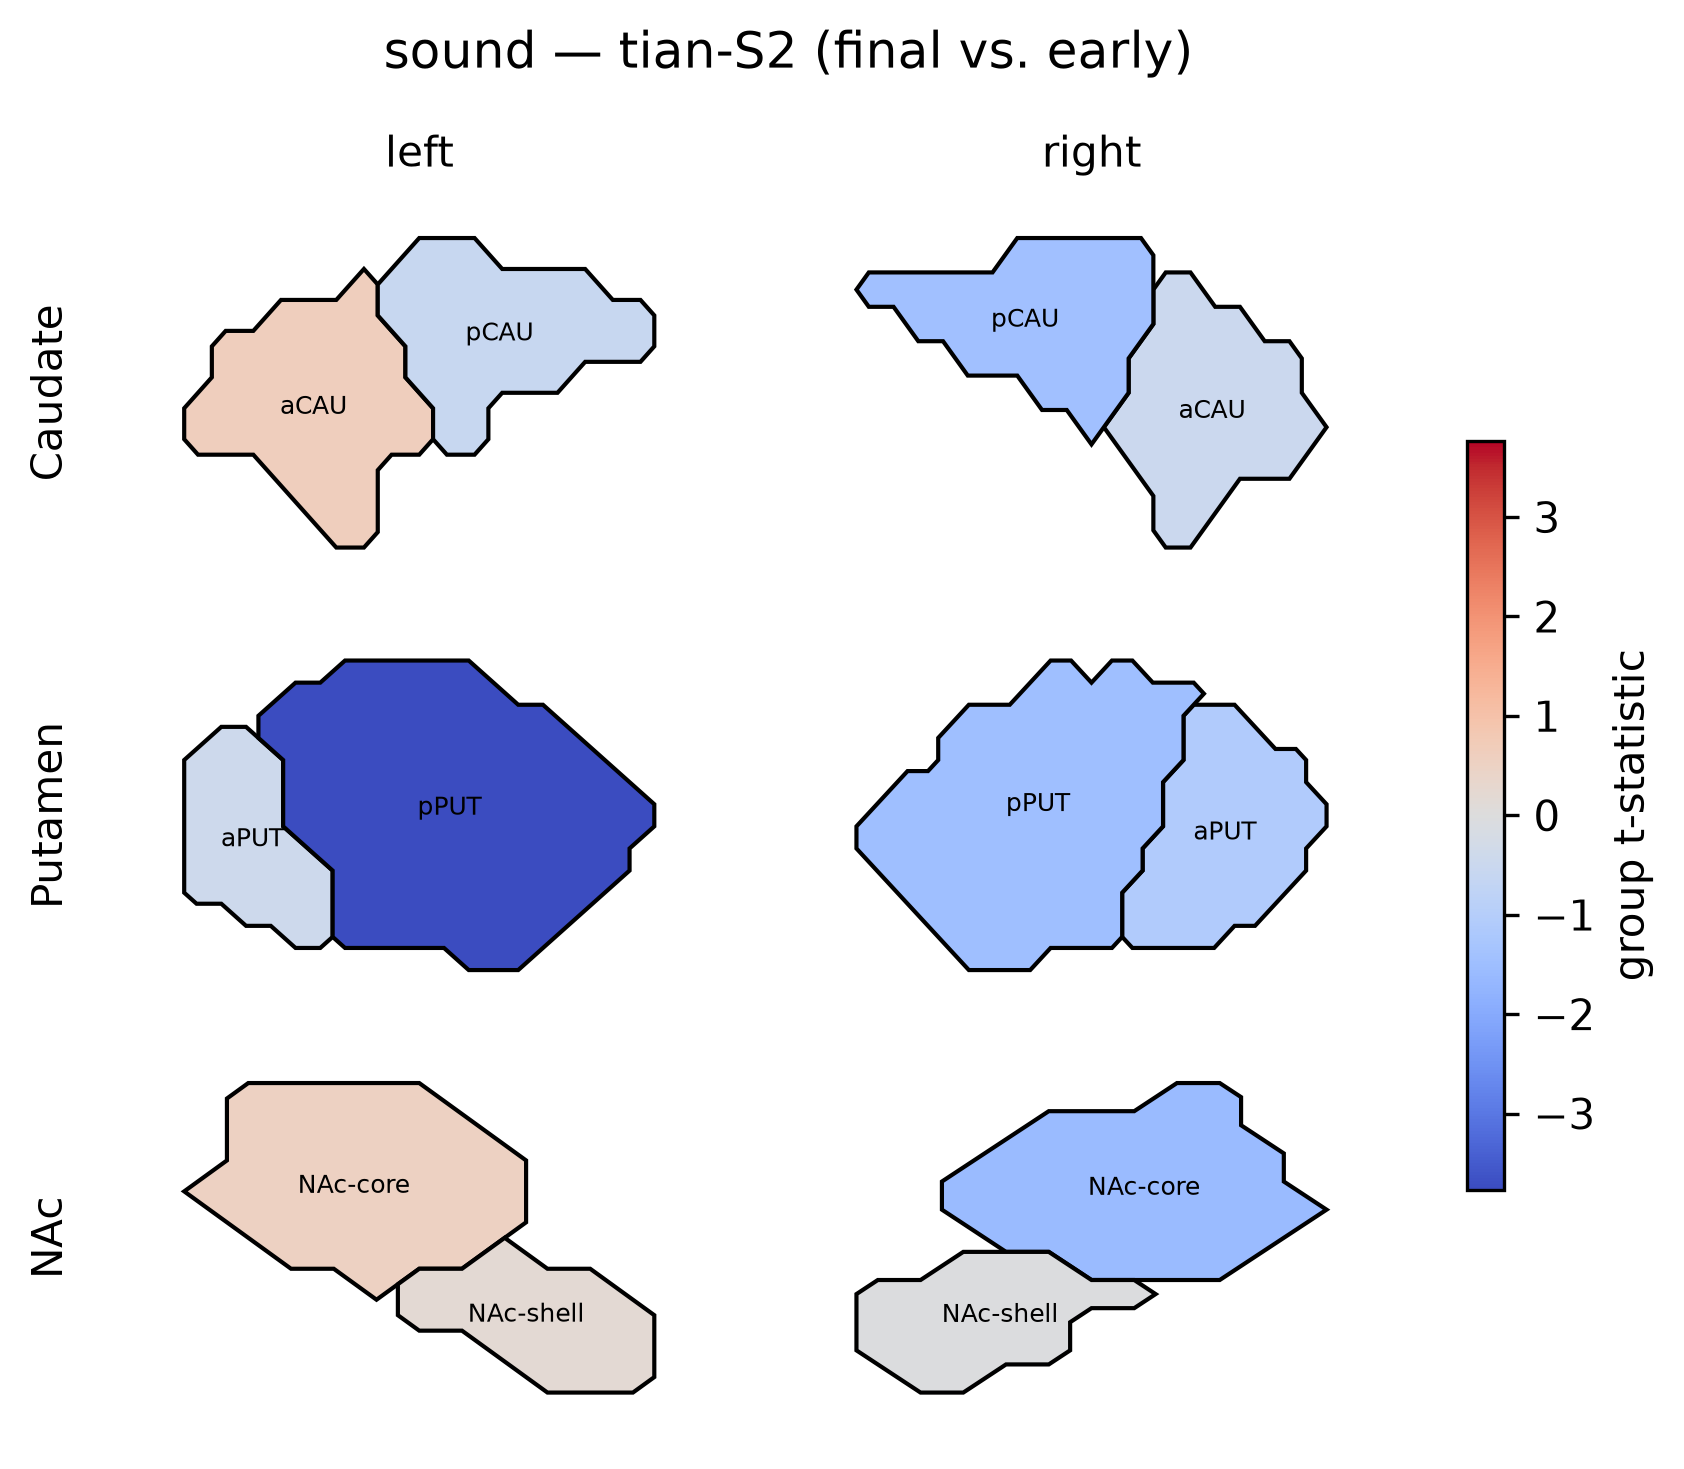

In [85]:
# Learning-stage difference (final vs. early)
_diff_df = (non_mandarin_df[non_mandarin_df['learning_stage'].isin(['early', 'final'])]
            .groupby(['participant_id', 'region_hemi', 'learning_stage'], as_index=False)['beta'].mean()
            .pivot(index=['participant_id', 'region_hemi'], columns='learning_stage', values='beta')
            .dropna()
            .reset_index())

diff_stat_dict = {}
for region_hemi, data in _diff_df.groupby('region_hemi'):
    t_stat, _ = ttest_rel(data['final'], data['early'])
    diff_stat_dict[region_hemi] = t_stat

structure_groups = {
    'Caudate': ['aCAU', 'pCAU'],
    'Putamen': ['aPUT', 'pPUT'],
    'NAc': ['NAc-core', 'NAc-shell'],
}
mask_path_dict_diff = build_mask_path_dict(list(diff_stat_dict.keys()), masks_dir, network_name, space_label)
fig_diff = plot_striatal_roi_stat(diff_stat_dict, mask_path_dict_diff, structure_groups,
                                   title=f'{contrast_label} — {network_name} (final vs. early)')
fig_diff.savefig(os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_striatal-tstat_diff-final-early.svg'))
fig_diff.savefig(os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_striatal-tstat_diff-final-early.png'))


### Striatal ROI plot (t-statistic, final vs. early) — yabplot alternative

In [86]:
# Optional alternative: yabplot 3D rendering of diff_stat_dict (final vs.
# early), run via the separate cluster conda env ("yabplot",
# /bgfs/bchandrasekaran/krs228/software/miniconda3/envs/yabplot/bin/python)
# since this notebook's kernel doesn't have yabplot installed.
import json

yabplot_handoff_path_diff = '/tmp/_yabplot_handoff_diff.json'
yabplot_out_png_diff = os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_striatal-tstat_diff-final-early_yabplot.png')

with open(yabplot_handoff_path_diff, 'w') as f:
    json.dump({
        'stat_dict': diff_stat_dict,
        'atlas_dir': os.path.join(os.getcwd(), '..', '05_masking', 'yabplot_atlases', 'tian_S2'),
        'out_png': yabplot_out_png_diff,
        'title': f'{contrast_label} — {network_name} (final vs. early)',
    }, f)


In [87]:
%%script /bgfs/bchandrasekaran/krs228/software/miniconda3/envs/yabplot/bin/python
import json, sys
with open('/tmp/_yabplot_handoff_diff.json') as f:
    params = json.load(f)

sys.path.insert(0, '..')
from striatal_yabplot import plot_striatal_roi_stat_yabplot

fig = plot_striatal_roi_stat_yabplot(params['stat_dict'], atlas_dir=params['atlas_dir'],
                                      title=params['title'])
fig.savefig(params['out_png'])
print('saved', params['out_png'])


Couldn't find program: '/bgfs/bchandrasekaran/krs228/software/miniconda3/envs/yabplot/bin/python'


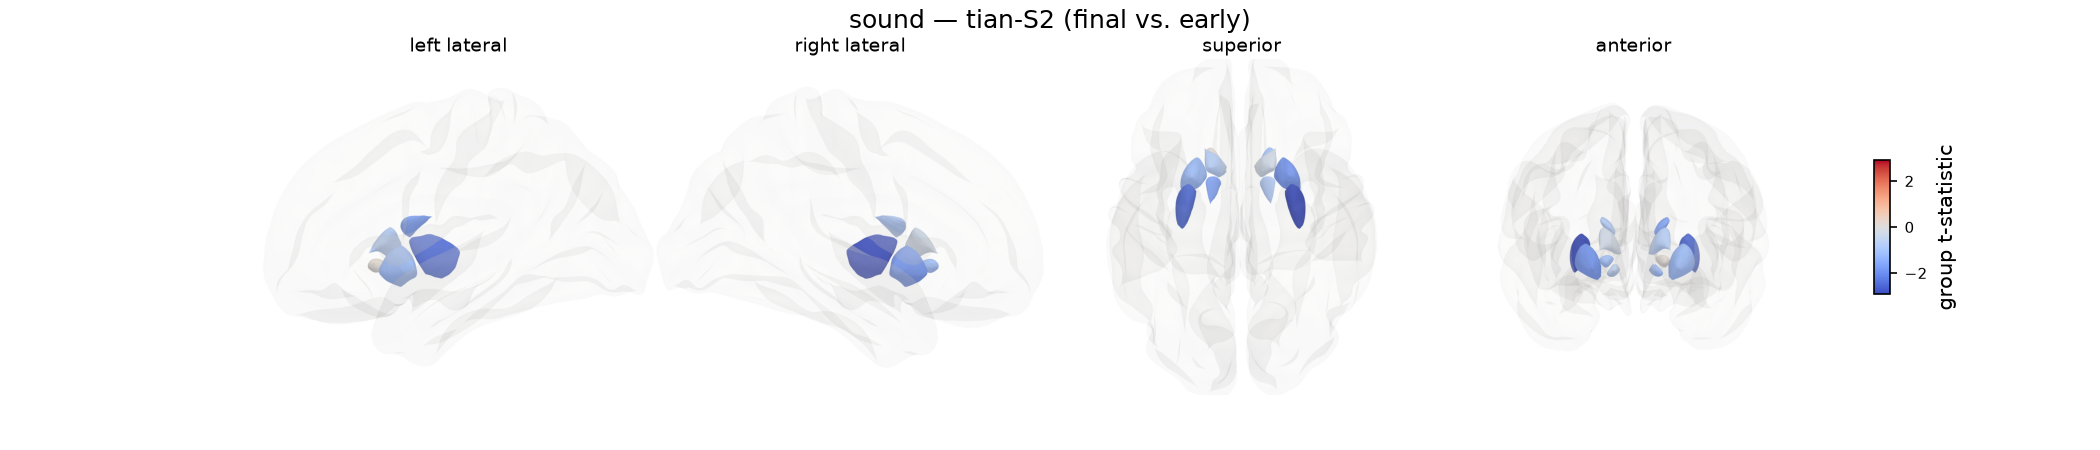

In [88]:
from IPython.display import Image
Image(filename=yabplot_out_png_diff)


In [89]:
'''
region_list = region_dict[network_name]

mask_dict = dict(zip(mask_path_list, 
                     range(1,len(mask_path_list)+1)))

stat_dict = dict(zip(range(1,len(t_stats)+1), 
                     t_stats))

from matplotlib import cm

# Load NIfTI files into a list
nifti_files = mask_path_list

# Define a colormap
colormap = cm.get_cmap('coolwarm')

# Define the list of values for color plotting
color_values = t_stats  # Adjust these values as needed
'''

"\nregion_list = region_dict[network_name]\n\nmask_dict = dict(zip(mask_path_list, \n                     range(1,len(mask_path_list)+1)))\n\nstat_dict = dict(zip(range(1,len(t_stats)+1), \n                     t_stats))\n\nfrom matplotlib import cm\n\n# Load NIfTI files into a list\nnifti_files = mask_path_list\n\n# Define a colormap\ncolormap = cm.get_cmap('coolwarm')\n\n# Define the list of values for color plotting\ncolor_values = t_stats  # Adjust these values as needed\n"

In [90]:
'''
import plotly.graph_objs as go
from plotly.subplots import make_subplots
from matplotlib import cm
from skimage import measure
from scipy.ndimage import gaussian_filter
from IPython.display import clear_output

# Load NIfTI files into a list
nifti_files = mask_path_list

# Define a colormap
colormap = cm.get_cmap('Reds') # 'coolwarm'

# Define the list of values for color plotting
color_values = t_stats  # Adjust these values as needed

# Create a list to hold the data for each segmentation
segmentations = []

# Loop through each NIfTI file and extract segmentation data
for nifti_file in nifti_files:
    nifti_data = nib.load(nifti_file)
    segmentation = nifti_data.get_fdata()
    segmentations.append(segmentation)

# Combine all segmentations into a single binary mask
combined_segmentation = np.any(segmentations, axis=0)

# Upsample the voxel data to a higher resolution grid
upsampled_segmentation = np.repeat(np.repeat(np.repeat(combined_segmentation, 2, axis=0), 2, axis=1), 2, axis=2)

# Smooth the upsampled voxel data with a Gaussian filter
smoothed_segmentation = gaussian_filter(upsampled_segmentation, sigma=1)

# Extract the surface mesh of the smoothed segmented region with adjusted level
vertices, faces, _, _ = measure.marching_cubes(smoothed_segmentation, level=smoothed_segmentation.mean())

# Translate vertices closer to the origin
center = vertices.mean(axis=0)
vertices -= center

# Create a subplot for the 3D plot with a larger size
fig = make_subplots(rows=1, cols=1, specs=[[{'type': 'mesh3d'}]], print_grid=False)

# Loop through each segmentation and add its surface plot to the subplot
for i, segmentation in enumerate(segmentations):
    # Upsample the voxel data to a higher resolution grid
    upsampled_segmentation = np.repeat(np.repeat(np.repeat(segmentation, 2, axis=0), 2, axis=1), 2, axis=2)
    
    # Smooth the upsampled voxel data with a Gaussian filter
    smoothed_segmentation = gaussian_filter(upsampled_segmentation, sigma=1)
    
    # Extract the surface mesh of the smoothed segmented region with adjusted level
    vertices, faces, _, _ = measure.marching_cubes(smoothed_segmentation, level=smoothed_segmentation.mean())
    
    vertices -= center
    
    # Map the color value to the colormap
    colormap_value = (color_values[i] - min(color_values)) / (max(color_values) - min(color_values))
    color = colormap(colormap_value)
    
    # Add the surface plot to the subplot
    fig.add_trace(go.Mesh3d(
        x=vertices[:, 0],
        y=vertices[:, 1],
        z=vertices[:, 2],
        i=faces[:, 0],
        j=faces[:, 1],
        k=faces[:, 2],
        color=f'rgb({int(color[0]*255)}, {int(color[1]*255)}, {int(color[2]*255)})',
        opacity=1,
        name= region_list[i] # f'Segmentation {i+1}'
    ))

# Set starting camera angle
camera = dict(
    up=dict(x=0, y=0, z=1),
    center=dict(x=0, y=0, z=0),
    eye=dict(x=-1.25, y=1.25, z=1.25)
)

# Update layout for the 3D plot to set a larger size and transparent background
fig.update_layout(
    scene=dict(
        xaxis=dict(title=None, showbackground=False, linecolor='rgba(0,0,0,0)', 
                   showgrid=False, showticklabels=False),
        yaxis=dict(title=None, showbackground=False, linecolor='rgba(0,0,0,0)', 
                   showgrid=False, showticklabels=False),
        zaxis=dict(title=None, showbackground=False, linecolor='rgba(0,0,0,0)', 
                   showgrid=False, showticklabels=False),
        bgcolor='rgba(0,0,0,0)',  # Set background color to transparent
        camera=camera  # Set starting camera angle
    ),
    #title=f'All participants contrast-{contrast_label}',
    width=800,  # Set width of the plot
    height=600,  # Set height of the plot
)

# Show the interactive plot
fig.show()

# Save the interactive plot as an SVG file
fig.write_image(f'out-figure_group-all_contrast-{contrast_label}_network-{network_name}-rcv_surface.svg')
clear_output() # very large – clear it after using
'''

"\nimport plotly.graph_objs as go\nfrom plotly.subplots import make_subplots\nfrom matplotlib import cm\nfrom skimage import measure\nfrom scipy.ndimage import gaussian_filter\nfrom IPython.display import clear_output\n\n# Load NIfTI files into a list\nnifti_files = mask_path_list\n\n# Define a colormap\ncolormap = cm.get_cmap('Reds') # 'coolwarm'\n\n# Define the list of values for color plotting\ncolor_values = t_stats  # Adjust these values as needed\n\n# Create a list to hold the data for each segmentation\nsegmentations = []\n\n# Loop through each NIfTI file and extract segmentation data\nfor nifti_file in nifti_files:\n    nifti_data = nib.load(nifti_file)\n    segmentation = nifti_data.get_fdata()\n    segmentations.append(segmentation)\n\n# Combine all segmentations into a single binary mask\ncombined_segmentation = np.any(segmentations, axis=0)\n\n# Upsample the voxel data to a higher resolution grid\nupsampled_segmentation = np.repeat(np.repeat(np.repeat(combined_segmentation,

In [91]:
'''
a = np.array([[min(color_values), max(color_values)]])
plt.figure(figsize=(5, 0.5), dpi=300)
img = plt.imshow(a, cmap=colormap)
plt.gca().set_visible(False)
cax = plt.axes([0.1, 0.2, 0.8, 0.6])
#cbar = plt.colorbar(orientation="horizontal", cax=cax, label='group t-statistic')
plt.colorbar(orientation="horizontal", cax=cax, label='group t-statistic')
#cbar.ax.get_yaxis().labelpad = 15
plt.savefig(os.path.join(fig_out_dir, f"out-figure_group-all_contrast-{contrast_label}_network-{network_name}-rcv_colorbar.svg"))
'''

'\na = np.array([[min(color_values), max(color_values)]])\nplt.figure(figsize=(5, 0.5), dpi=300)\nimg = plt.imshow(a, cmap=colormap)\nplt.gca().set_visible(False)\ncax = plt.axes([0.1, 0.2, 0.8, 0.6])\n#cbar = plt.colorbar(orientation="horizontal", cax=cax, label=\'group t-statistic\')\nplt.colorbar(orientation="horizontal", cax=cax, label=\'group t-statistic\')\n#cbar.ax.get_yaxis().labelpad = 15\nplt.savefig(os.path.join(fig_out_dir, f"out-figure_group-all_contrast-{contrast_label}_network-{network_name}-rcv_colorbar.svg"))\n'

#### plot ROIs for methods

In [92]:
'''
import plotly.graph_objs as go
from plotly.subplots import make_subplots
from matplotlib import cm
from skimage import measure
from scipy.ndimage import gaussian_filter
from IPython.display import clear_output

# Load NIfTI files into a list
nifti_files = mask_path_list

# Define a colormap

import plotly.express as px
import random

# Define the list of values for color plotting
palette = px.colors.qualitative.Set3
random_colors = random.sample(palette, k=len(mask_path_list))

# Create a list to hold the data for each segmentation
segmentations = []

# Loop through each NIfTI file and extract segmentation data
for nifti_file in nifti_files:
    nifti_data = nib.load(nifti_file)
    segmentation = nifti_data.get_fdata()
    segmentations.append(segmentation)

# Combine all segmentations into a single binary mask
combined_segmentation = np.any(segmentations, axis=0)

# Upsample the voxel data to a higher resolution grid
upsampled_segmentation = np.repeat(np.repeat(np.repeat(combined_segmentation, 2, axis=0), 2, axis=1), 2, axis=2)

# Smooth the upsampled voxel data with a Gaussian filter
smoothed_segmentation = gaussian_filter(upsampled_segmentation, sigma=1)

# Extract the surface mesh of the smoothed segmented region with adjusted level
vertices, faces, _, _ = measure.marching_cubes(smoothed_segmentation, level=smoothed_segmentation.mean())

# Translate vertices closer to the origin
center = vertices.mean(axis=0)
vertices -= center

# Create a subplot for the 3D plot with a larger size
fig = make_subplots(rows=1, cols=1, specs=[[{'type': 'mesh3d'}]], print_grid=False)

# Loop through each segmentation and add its surface plot to the subplot
for i, segmentation in enumerate(segmentations):
    # Upsample the voxel data to a higher resolution grid
    upsampled_segmentation = np.repeat(np.repeat(np.repeat(segmentation, 2, axis=0), 2, axis=1), 2, axis=2)
    
    # Smooth the upsampled voxel data with a Gaussian filter
    smoothed_segmentation = gaussian_filter(upsampled_segmentation, sigma=1)
    
    # Extract the surface mesh of the smoothed segmented region with adjusted level
    vertices, faces, _, _ = measure.marching_cubes(smoothed_segmentation, level=smoothed_segmentation.mean())
    
    vertices -= center
    
    # Compute centroid for labeling
    centroid = vertices.mean(axis=0)

    # Add text label
    fig.add_trace(go.Scatter3d(
        x=[centroid[0]],
        y=[centroid[1]],
        z=[centroid[2]],
        mode='text',
        text=[region_list[i]],
        textfont=dict(
            size=14,
            color=random_colors[i]  # match ROI color
        ),
        showlegend=False
    ))


    # Add the surface plot to the subplot
    fig.add_trace(go.Mesh3d(
        x=vertices[:, 0],
        y=vertices[:, 1],
        z=vertices[:, 2],
        i=faces[:, 0],
        j=faces[:, 1],
        k=faces[:, 2],
        color=random_colors[i],
        opacity=1,
        name= region_list[i] # f'Segmentation {i+1}'
    ))

# Set starting camera angle
camera = dict(
    up=dict(x=0, y=0, z=1),
    center=dict(x=0, y=0, z=0),
    eye=dict(x=-1.25, y=1.25, z=1.25)
)

# Update layout for the 3D plot to set a larger size and transparent background
fig.update_layout(
    scene=dict(
        xaxis=dict(title=None, showbackground=False, linecolor='rgba(0,0,0,0)', 
                   showgrid=False, showticklabels=False),
        yaxis=dict(title=None, showbackground=False, linecolor='rgba(0,0,0,0)', 
                   showgrid=False, showticklabels=False),
        zaxis=dict(title=None, showbackground=False, linecolor='rgba(0,0,0,0)', 
                   showgrid=False, showticklabels=False),
        bgcolor='rgba(0,0,0,0)',  # Set background color to transparent
        camera=camera  # Set starting camera angle
    ),
    #title=f'All participants contrast-{contrast_label}',
    width=1200,  # Set width of the plot
    height=1200,  # Set height of the plot
)

# Show the interactive plot
fig.update_layout(showlegend=True)

fig.show()

# Save the interactive plot as an SVG file
fig.write_image(f'out-figure_group-all_network-{network_name}-rcv_surface.svg')
clear_output() # very large – clear it after using
'''

"\nimport plotly.graph_objs as go\nfrom plotly.subplots import make_subplots\nfrom matplotlib import cm\nfrom skimage import measure\nfrom scipy.ndimage import gaussian_filter\nfrom IPython.display import clear_output\n\n# Load NIfTI files into a list\nnifti_files = mask_path_list\n\n# Define a colormap\n\nimport plotly.express as px\nimport random\n\n# Define the list of values for color plotting\npalette = px.colors.qualitative.Set3\nrandom_colors = random.sample(palette, k=len(mask_path_list))\n\n# Create a list to hold the data for each segmentation\nsegmentations = []\n\n# Loop through each NIfTI file and extract segmentation data\nfor nifti_file in nifti_files:\n    nifti_data = nib.load(nifti_file)\n    segmentation = nifti_data.get_fdata()\n    segmentations.append(segmentation)\n\n# Combine all segmentations into a single binary mask\ncombined_segmentation = np.any(segmentations, axis=0)\n\n# Upsample the voxel data to a higher resolution grid\nupsampled_segmentation = np.repe

## `contrast-sound` for cortical network

In [93]:
# get the beta map for the contrast of interest for each subject
network_name = network_list[0]
contrast_label = contrast_list[0]
event_type = contrast_event_type[contrast_label]
print('network_name:', network_name)
print('contrast_label:', contrast_label)

statmap_earlythird_dict = {}
for sub_id in sub_list_nman:
    statmap_earlythird_dict[sub_id] = sorted(glob(l1_dir+f'/{sub_id}_space-{space_label}/early_event-{event_type}/{sub_id}/*{contrast_label}_stat-effect_statmap.nii.gz'))[0]
    
statmap_middlethird_dict = {}
for sub_id in sub_list_nman:
    statmap_middlethird_dict[sub_id] = sorted(glob(l1_dir+f'/{sub_id}_space-{space_label}/middle_event-{event_type}/{sub_id}/*{contrast_label}_stat-effect_statmap.nii.gz'))[0]
    
statmap_latethird_dict = {}
for sub_id in sub_list_nman:
    statmap_latethird_dict[sub_id] = sorted(glob(l1_dir+f'/{sub_id}_space-{space_label}/final_event-{event_type}/{sub_id}/*{contrast_label}_stat-effect_statmap.nii.gz'))[0]

network_name: auditory
contrast_label: sound


In [94]:
# define filepath for saving (once) or loading (afterward)
out_fname = f'univariate-results_network-{network_name}_contrast-{contrast_label}.tsv'
combined_roi_df_fpath = os.path.join(group_out_dir, out_fname)

In [95]:
# mask the stat maps per learning stage by region - ONLY RUN ONCE
'''
print(f'masking {contrast_label} stat maps for the {network_name} network')

print(f'creating dictionary for early learning stage')
roi_earlythird_mean_dict, mask_path_list = mask_stat_maps(region_dict[network_name], 
                                               statmap_earlythird_dict, 
                                               masks_dir, 
                                               network_name,
                                               space_label)

print(f'creating dictionary for middle learning stage')
roi_middlethird_mean_dict, mask_path_list = mask_stat_maps(region_dict[network_name], 
                                               statmap_middlethird_dict, 
                                               masks_dir, 
                                               network_name,
                                               space_label)

print(f'creating dictionary for final learning stage')
roi_latethird_mean_dict, mask_path_list = mask_stat_maps(region_dict[network_name], 
                                               statmap_latethird_dict, 
                                               masks_dir, 
                                               network_name,
                                               space_label)

# add `learning_stage` column and combine into single dataframe
roi_earlythird_df_long = make_stats_df(roi_earlythird_mean_dict, participants_nman_df, network_name)
roi_earlythird_df_long['learning_stage'] = 'early'
roi_middlethird_df_long = make_stats_df(roi_middlethird_mean_dict, participants_nman_df, network_name)
roi_middlethird_df_long['learning_stage'] = 'middle'
roi_latethird_df_long = make_stats_df(roi_latethird_mean_dict, participants_nman_df, network_name)
roi_latethird_df_long['learning_stage'] = 'final'

# combine into a single long dataframe
roi_df_long = pd.concat([roi_earlythird_df_long, roi_middlethird_df_long, roi_latethird_df_long],)

# save the DataFrame for easier access
roi_df_long.to_csv(combined_roi_df_fpath, sep='\t', index=False)
'''

"\nprint(f'masking {contrast_label} stat maps for the {network_name} network')\n\nprint(f'creating dictionary for early learning stage')\nroi_earlythird_mean_dict, mask_path_list = mask_stat_maps(region_dict[network_name], \n                                               statmap_earlythird_dict, \n                                               masks_dir, \n                                               network_name,\n                                               space_label)\n\nprint(f'creating dictionary for middle learning stage')\nroi_middlethird_mean_dict, mask_path_list = mask_stat_maps(region_dict[network_name], \n                                               statmap_middlethird_dict, \n                                               masks_dir, \n                                               network_name,\n                                               space_label)\n\nprint(f'creating dictionary for final learning stage')\nroi_latethird_mean_dict, mask_path_list = mask_stat_map

In [96]:
# load the DataFrame if already exists
roi_df_long = pd.read_csv(combined_roi_df_fpath, sep='\t')

# create a bilateral-averaged dataframe (for across-contrast analysis)
sound_cortex_df = bilateral_mean(roi_df_long)


In [97]:
roi_df_long.participant_id.unique()

<StringArray>
['sub-FLT02', 'sub-FLT04', 'sub-FLT06', 'sub-FLT09', 'sub-FLT11', 'sub-FLT12',
 'sub-FLT13', 'sub-FLT14', 'sub-FLT25', 'sub-FLT28', 'sub-FLT30']
Length: 11, dtype: str

In [98]:
roi_df_long.region.unique()

<StringArray>
['HG', 'PT', 'PP', 'STGp', 'STGa', 'ParsOp', 'ParsTri']
Length: 7, dtype: str

In [99]:
non_mandarin_df = roi_df_long

In [100]:
# right now, requires separate dictionaries per learning stage
# could be re-written to take roi_df_long or similar
'''fig = plot_roi_slices_avg([roi_earlythird_mean_dict, roi_middlethird_mean_dict, roi_latethird_mean_dict],
                          mask_path_list, 'dseg', space_label)
'''

"fig = plot_roi_slices_avg([roi_earlythird_mean_dict, roi_middlethird_mean_dict, roi_latethird_mean_dict],\n                          mask_path_list, 'dseg', space_label)\n"

In [101]:
plot_order = ['HG', 'PT', 'PP', 'STGp', 'STGa', 'ParsOp', 'ParsTri', ]

/scratch/slurm-10971702/ipykernel_1708492/276266010.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')


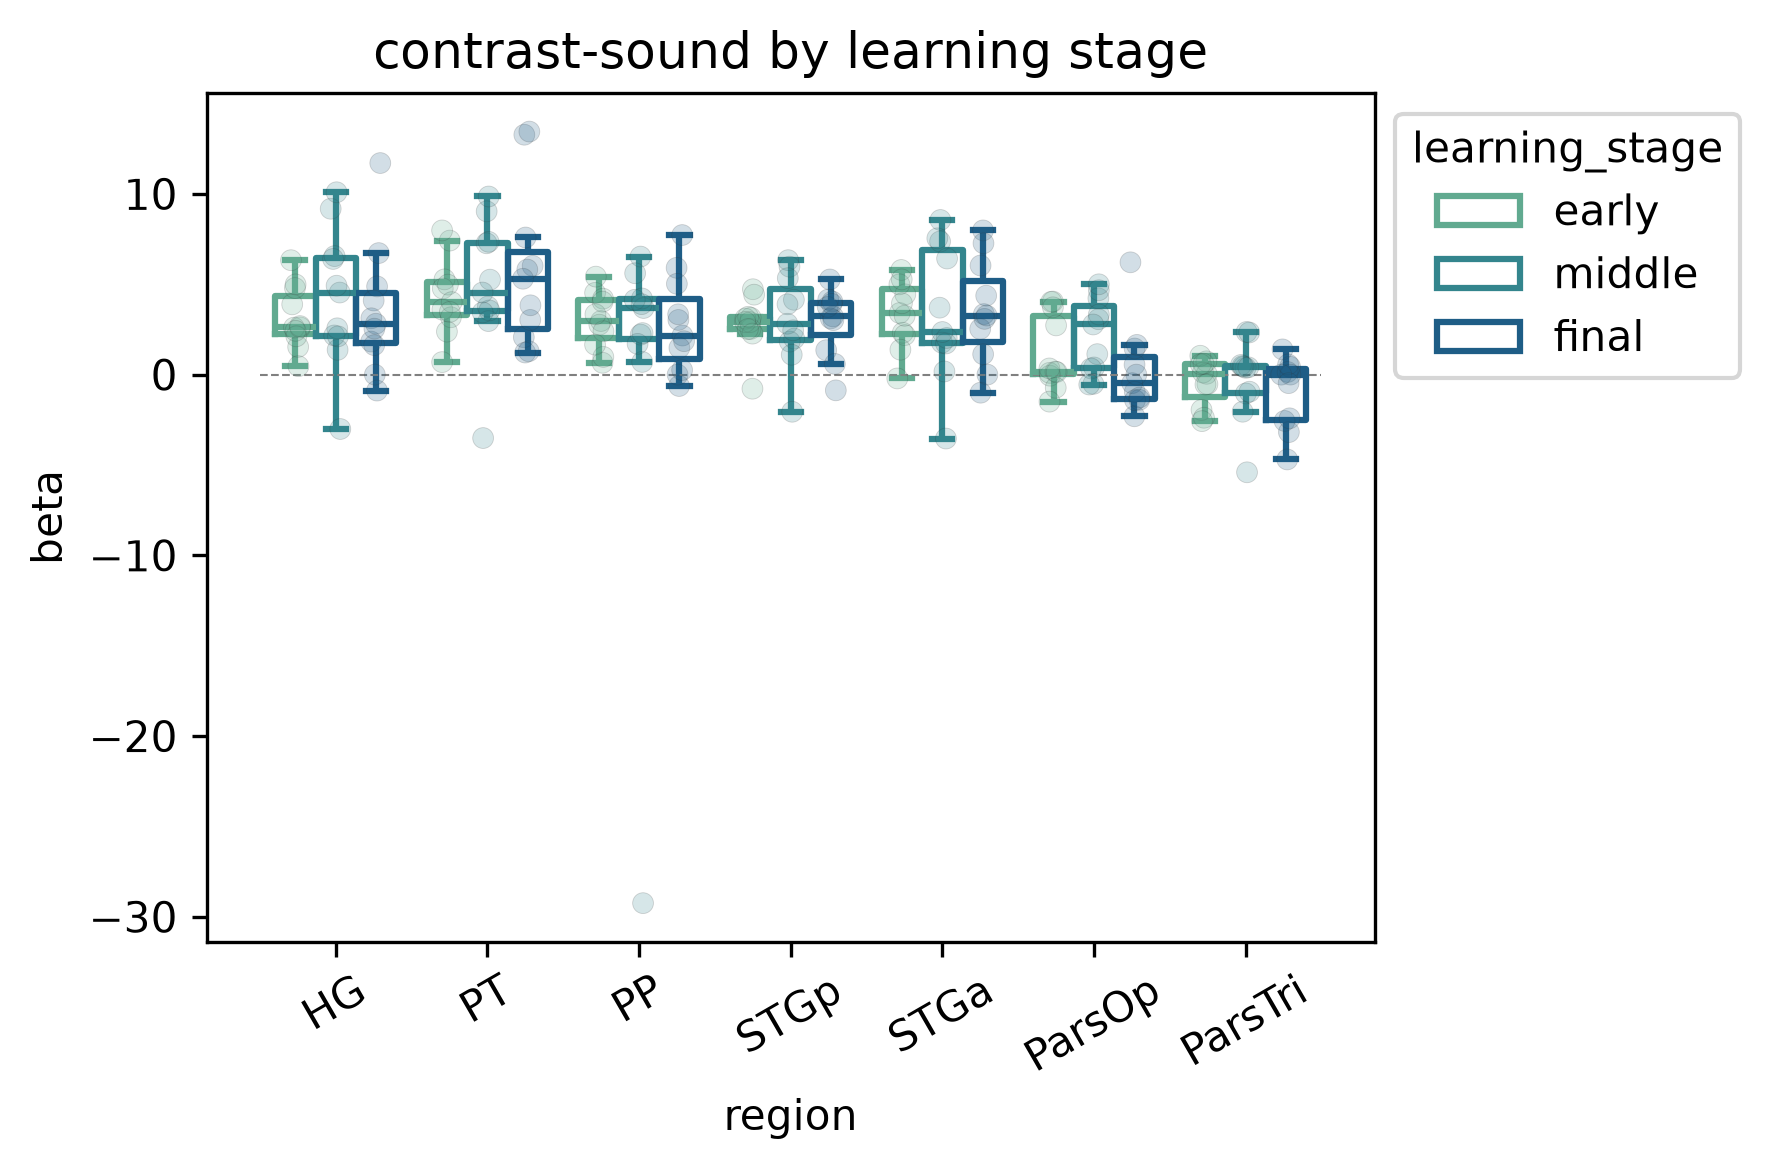

In [102]:
fig, ax = plt.subplots(1, 1, figsize=(6,4), dpi=300)

roi_df_collapsed = roi_df_long.groupby(["participant_id", "region", 'learning_stage'], 
                                       as_index=False).agg({"beta": "mean"})

sns.boxplot(data=roi_df_collapsed, 
              x='region', y='beta', 
              hue='learning_stage', hue_order=['early', 'middle', 'final'],
              order=plot_order,
              palette='crest',
              fliersize = 0,            
              linewidth=1.5,
              fill=False,
              #legend=None,
              ax=ax);
sns.stripplot(data=roi_df_collapsed, 
              x='region', y='beta', 
              hue='learning_stage', hue_order=['early', 'middle', 'final'],
              order=plot_order,
              palette='crest',
              dodge=True,
              linewidth=0.2,
              alpha=.2,
              legend=None,
              ax=ax);


xmin, xmax = ax.get_xlim()
ax.hlines(y=0, xmin=xmin, xmax=xmax, color='0.5', linestyle='--', linewidth=0.5)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title(f'contrast-{contrast_label} by learning stage');
#ax.set_ylim([-5, 5])

fig.tight_layout()

fig.savefig(os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_boxplot-stage.svg'))
fig.savefig(os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_boxplot-stage.png'))

/scratch/slurm-10971702/ipykernel_1708492/3292222178.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')


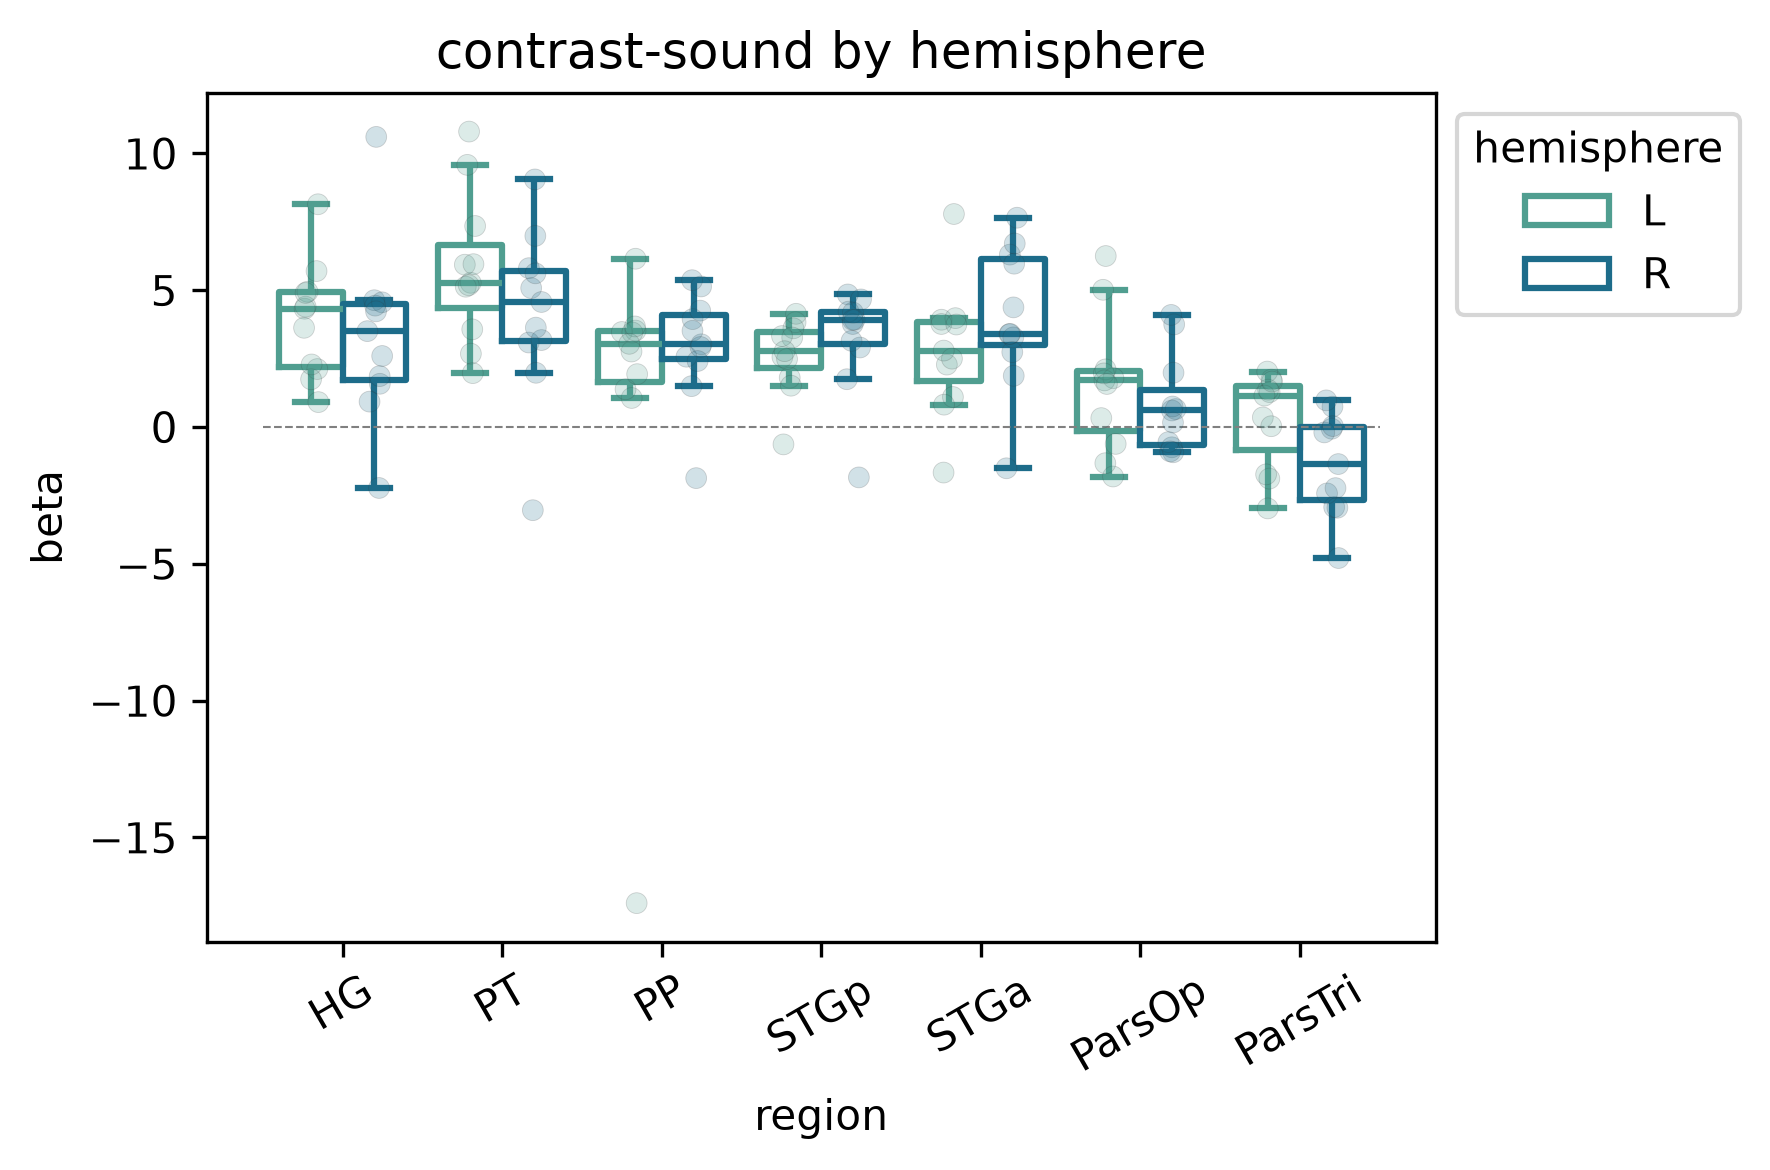

In [103]:
fig, ax = plt.subplots(1, 1, figsize=(6,4), dpi=300)

roi_df_collapsed = roi_df_long.groupby(["participant_id", "region", 'hemisphere'], 
                                       as_index=False).agg({"beta": "mean"})

sns.boxplot(data=roi_df_collapsed, 
              x='region', y='beta', 
              hue='hemisphere', #hue_order=['early', 'middle', 'final'],
              order=plot_order,
              palette='crest',
              fliersize = 0,            
              linewidth=1.5,
              fill=False,
              #legend=None,
              ax=ax);
sns.stripplot(data=roi_df_collapsed, 
              x='region', y='beta', 
              hue='hemisphere', #hue_order=['early', 'middle', 'final'],
              order=plot_order,
              palette='crest',
              dodge=True,
              linewidth=0.2,
              alpha=.2,
              legend=None,
              ax=ax);


xmin, xmax = ax.get_xlim()
ax.hlines(y=0, xmin=xmin, xmax=xmax, color='0.5', linestyle='--', linewidth=0.5)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title(f'contrast-{contrast_label} by hemisphere');
#ax.set_ylim([-5, 5])

fig.tight_layout()

fig.savefig(os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_boxplot-hemisphere.svg'))
fig.savefig(os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_boxplot-hemisphere.png'))

### Brain-behavior correlations

In [104]:
# map runs to learning stages matching your thirds
stage_map = {'run-01': 'early', 'run-02': 'early',
             'run-03': 'middle', 'run-04': 'middle',
             'run-05': 'final', 'run-06': 'final'}

acc_df['learning_stage'] = acc_df['run'].map(stage_map)
acc_stage_df = acc_df.groupby(['participant_id', 'learning_stage'])['accuracy'].mean().reset_index()

In [105]:
# merge into roi_df_long — assumes participant_id and learning_stage columns exist in both
roi_df_bilateral = (roi_df_long.groupby(['participant_id', 'region', 'learning_stage'], as_index=False)['beta'].mean())
roi_behav_df = roi_df_bilateral.merge(acc_stage_df, on=['participant_id', 'learning_stage'])

# verify
roi_behav_df.groupby(['region', 'learning_stage']).size().unique()  # should be array([12])


array([11])

In [106]:
roi_behav_df.columns

Index(['participant_id', 'region', 'learning_stage', 'beta', 'accuracy'], dtype='str')

In [107]:
roi_behav_df.participant_id.unique()

<StringArray>
['sub-FLT02', 'sub-FLT04', 'sub-FLT06', 'sub-FLT09', 'sub-FLT11', 'sub-FLT12',
 'sub-FLT13', 'sub-FLT14', 'sub-FLT25', 'sub-FLT28', 'sub-FLT30']
Length: 11, dtype: str

In [108]:
results = []
for stage in ['early', 'middle', 'final']:
    stage_df = roi_behav_df[roi_behav_df['learning_stage'] == stage]
    for roi in plot_order: # stage_df['region'].unique():
        sub_df = stage_df[stage_df['region'] == roi]
        r = pg.corr(sub_df['accuracy'], sub_df['beta'], method='pearson')
        results.append({
            'roi': roi,
            'learning_stage': stage,
            'r': r['r'].values[0],
            'p': r['p_val'].values[0],
            'n': r['n'].values[0],
            'stat_str': stat_str('r', r['r'].values[0], r['p_val'].values[0])
        })

behav_corr_df = pd.DataFrame(results)

In [109]:
behav_corr_df

,roi,learning_stage,r,p,n,stat_str
0,HG,early,0.2013,0.5528,11,"r = .20, p = .553"
1,PT,early,-0.0292,0.9321,11,"r = -.03, p = .932"
2,PP,early,0.1304,0.7023,11,"r = .13, p = .702"
3,STGp,early,-0.2571,0.4453,11,"r = -.26, p = .445"
4,STGa,early,-0.3459,0.2974,11,"r = -.35, p = .297"
5,ParsOp,early,0.1616,0.6349,11,"r = .16, p = .635"
6,ParsTri,early,0.1958,0.5640,11,"r = .20, p = .564"
7,HG,middle,-0.3033,0.3645,11,"r = -.30, p = .365"
8,PT,middle,-0.5813,0.0607,11,"r = -.58, p = .061"
9,PP,middle,-0.4249,0.1927,11,"r = -.42, p = .193"


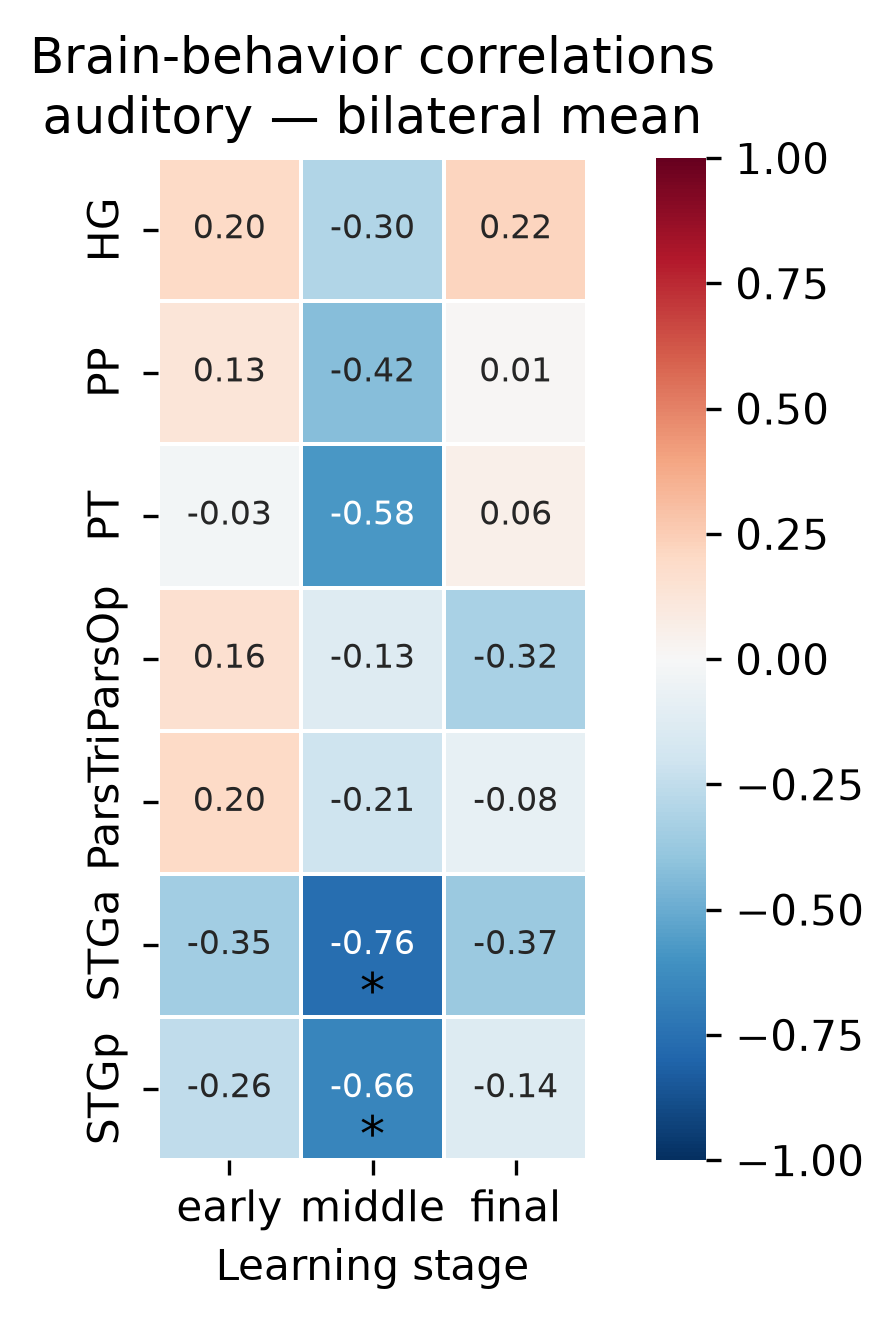

In [110]:
# pivot to ROI × stage matrix
r_matrix = behav_corr_df.pivot(index='roi', columns='learning_stage', values='r')[['early', 'middle', 'final']]
p_matrix = behav_corr_df.pivot(index='roi', columns='learning_stage', values='p')[['early', 'middle', 'final']]

fig, ax = plt.subplots(figsize=(5, len(r_matrix) * 0.5 + 1), dpi=300)
sns.heatmap(r_matrix, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, annot=True, fmt='.2f', annot_kws={'size': 8},
            square=True)

# mark significant cells with an asterisk
for i, roi in enumerate(r_matrix.index):
    for j, stage in enumerate(['early', 'middle', 'final']):
        p = p_matrix.loc[roi, stage]
        if p < 0.05:
            ax.text(j + 0.5, i + 0.85, '*', ha='center', va='center',
                    fontsize=12, color='black')

ax.set_title(f'Brain-behavior correlations\n{network_name} — bilateral mean')
ax.set_ylabel('')
ax.set_xlabel('Learning stage')
plt.tight_layout()
plt.savefig(os.path.join(fig_out_dir, f'brain-behav-corr_contrast-{contrast_label}_network-{network_name}_heatmap.svg'))

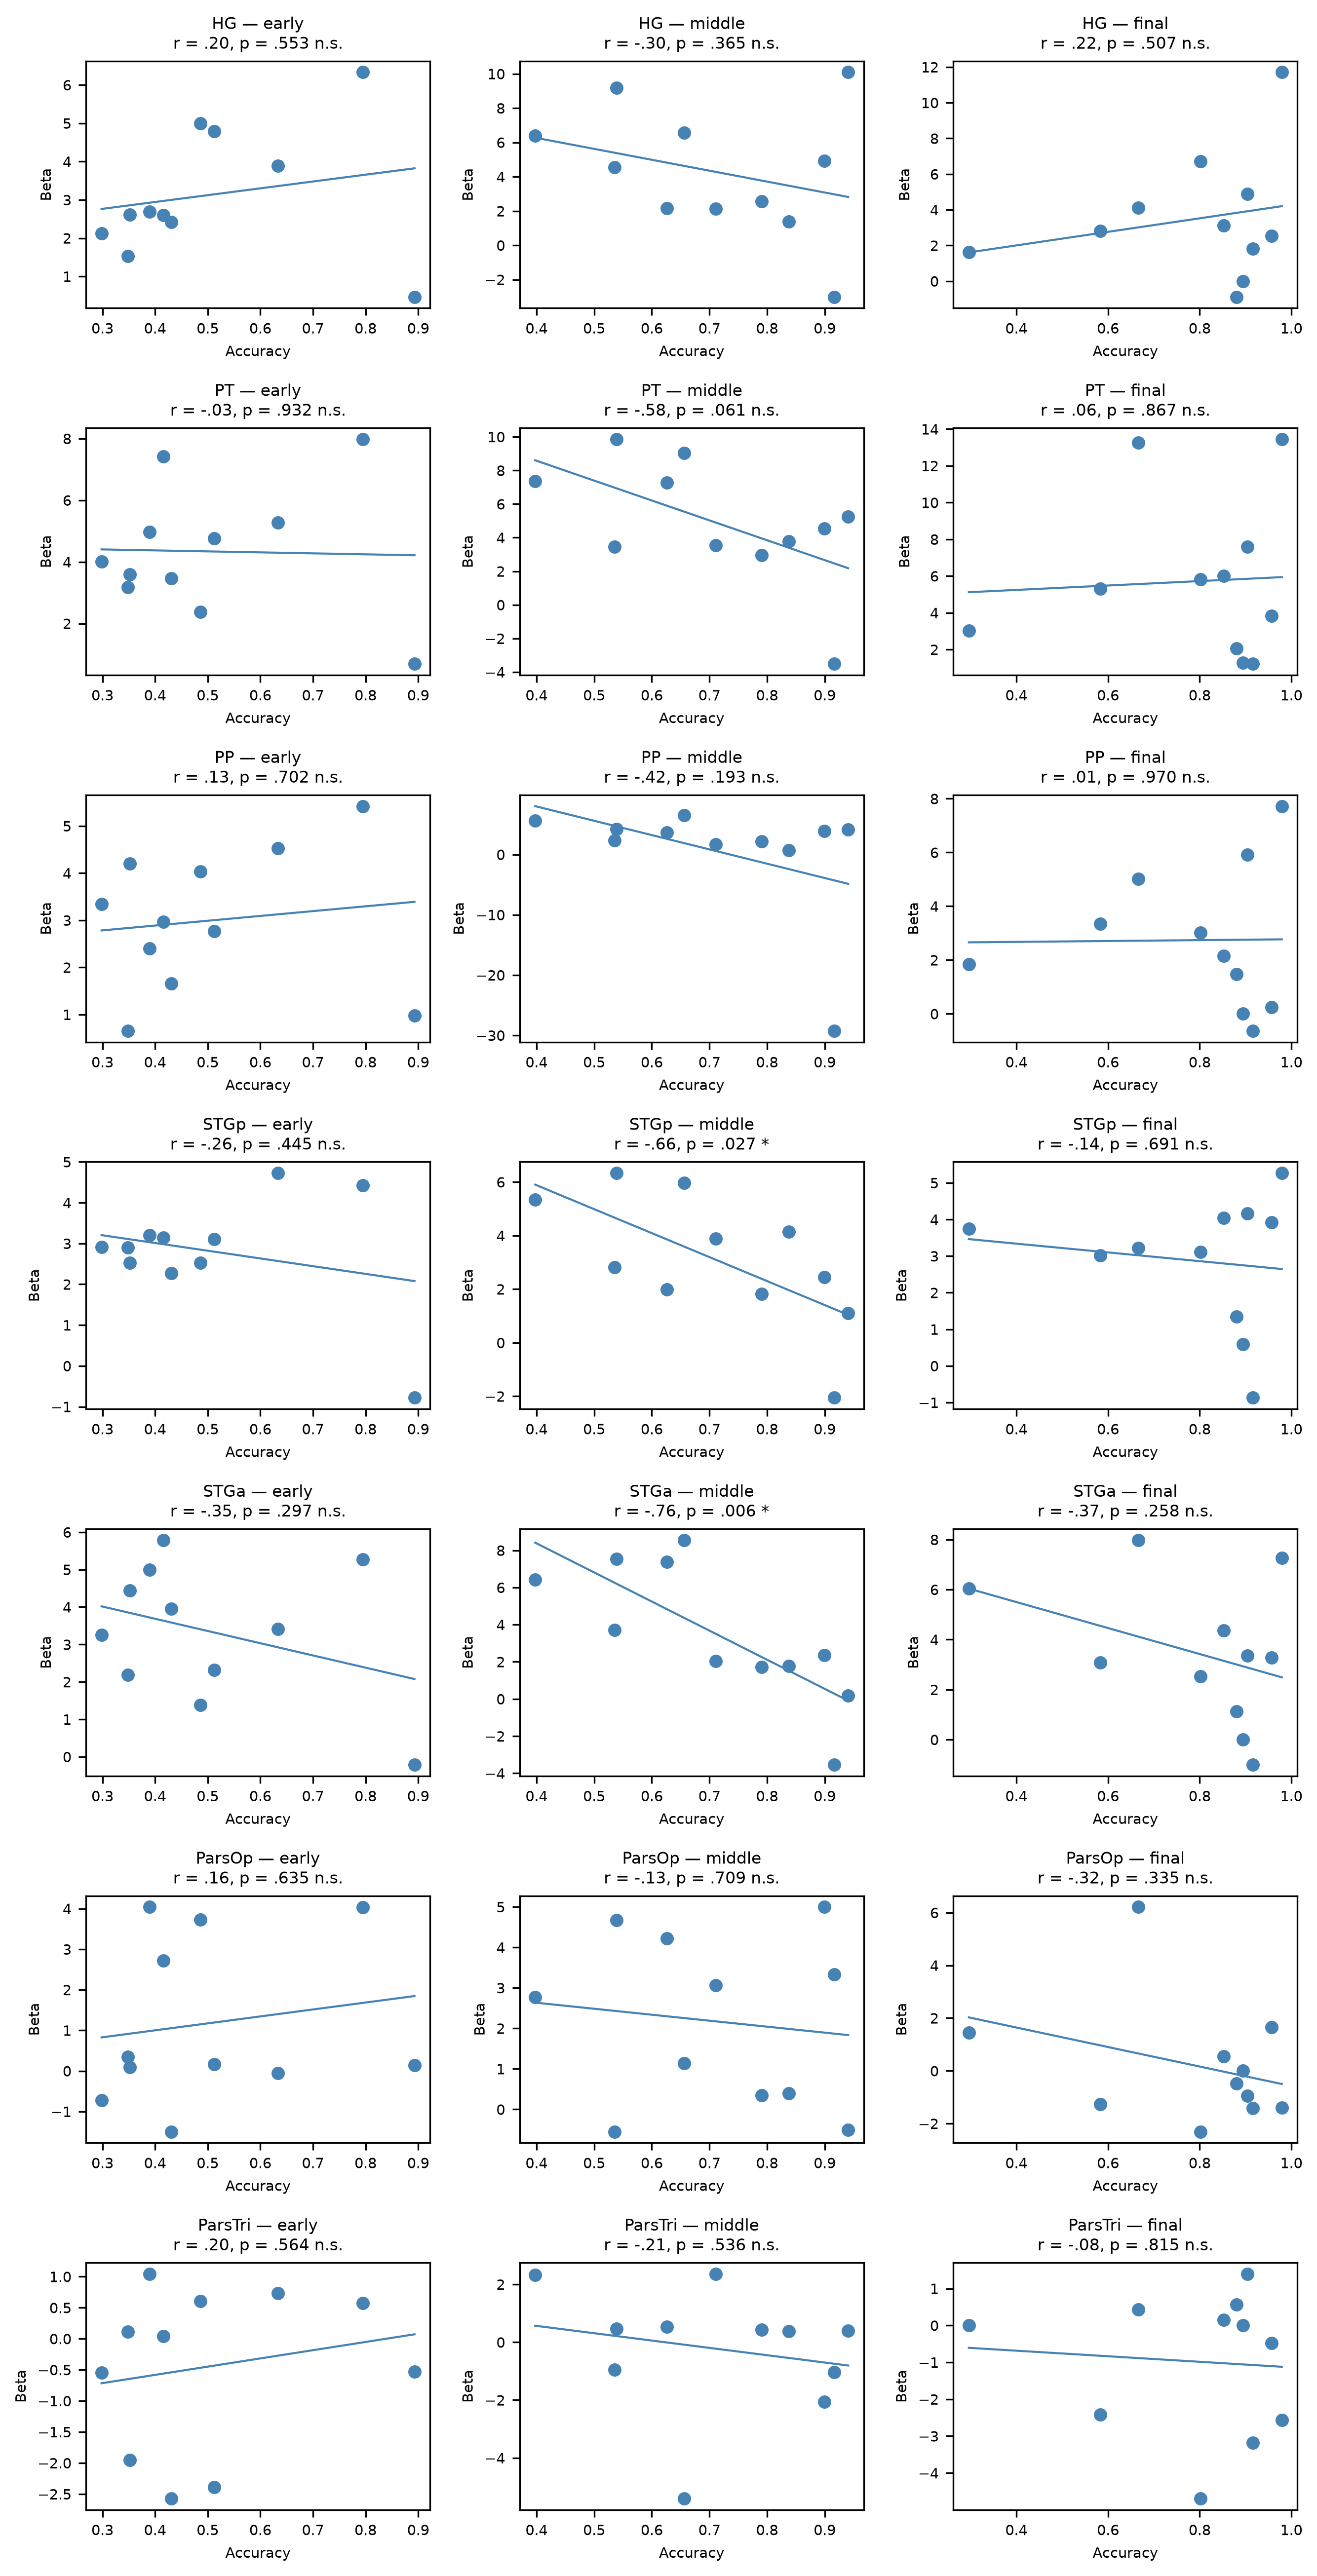

In [111]:
rois = behav_corr_df['roi'].unique()
stages = ['early', 'middle', 'final']

fig, axes = plt.subplots(len(rois), 3, figsize=(9, len(rois) * 2.5), dpi=300, sharex=False, sharey=False)

for ri, roi in enumerate(plot_order): # rois):
    for si, stage in enumerate(stages):
        ax = axes[ri, si]
        sub_df = roi_behav_df[(roi_behav_df['region'] == roi) & 
                              (roi_behav_df['learning_stage'] == stage)]
        
        ax.scatter(sub_df['accuracy'], sub_df['beta'], s=30, color='steelblue', zorder=3)
        
        # regression line
        m, b = np.polyfit(sub_df['accuracy'], sub_df['beta'], 1)
        x_range = np.linspace(sub_df['accuracy'].min(), sub_df['accuracy'].max(), 100)
        ax.plot(x_range, m * x_range + b, color='steelblue', linewidth=1)
        
        # stat annotation
        row = behav_corr_df[(behav_corr_df['roi'] == roi) & 
                            (behav_corr_df['learning_stage'] == stage)].iloc[0]
        p_str = '*' if row['p'] < 0.05 else 'n.s.'
        ax.set_title(f"{roi} — {stage}\n{row['stat_str']} {p_str}", fontsize=8)
        ax.set_xlabel('Accuracy', fontsize=7)
        ax.set_ylabel('Beta', fontsize=7)
        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig(os.path.join(fig_out_dir, f'brain-behav-corr_contrast-{contrast_label}_network-{network_name}_corr-plots.svg'))

HG early: r = .20, p = .553 n.s.
HG middle: r = -.30, p = .365 n.s.
HG final: r = .22, p = .507 n.s.
PT early: r = -.03, p = .932 n.s.
PT middle: r = -.58, p = .061 n.s.
PT final: r = .06, p = .867 n.s.
PP early: r = .13, p = .702 n.s.
PP middle: r = -.42, p = .193 n.s.
PP final: r = .01, p = .970 n.s.
STGp early: r = -.26, p = .445 n.s.
STGp middle: r = -.66, p = .027 *
STGp final: r = -.14, p = .691 n.s.
STGa early: r = -.35, p = .297 n.s.
STGa middle: r = -.76, p = .006 *
STGa final: r = -.37, p = .258 n.s.
ParsOp early: r = .16, p = .635 n.s.
ParsOp middle: r = -.13, p = .709 n.s.
ParsOp final: r = -.32, p = .335 n.s.
ParsTri early: r = .20, p = .564 n.s.
ParsTri middle: r = -.21, p = .536 n.s.
ParsTri final: r = -.08, p = .815 n.s.


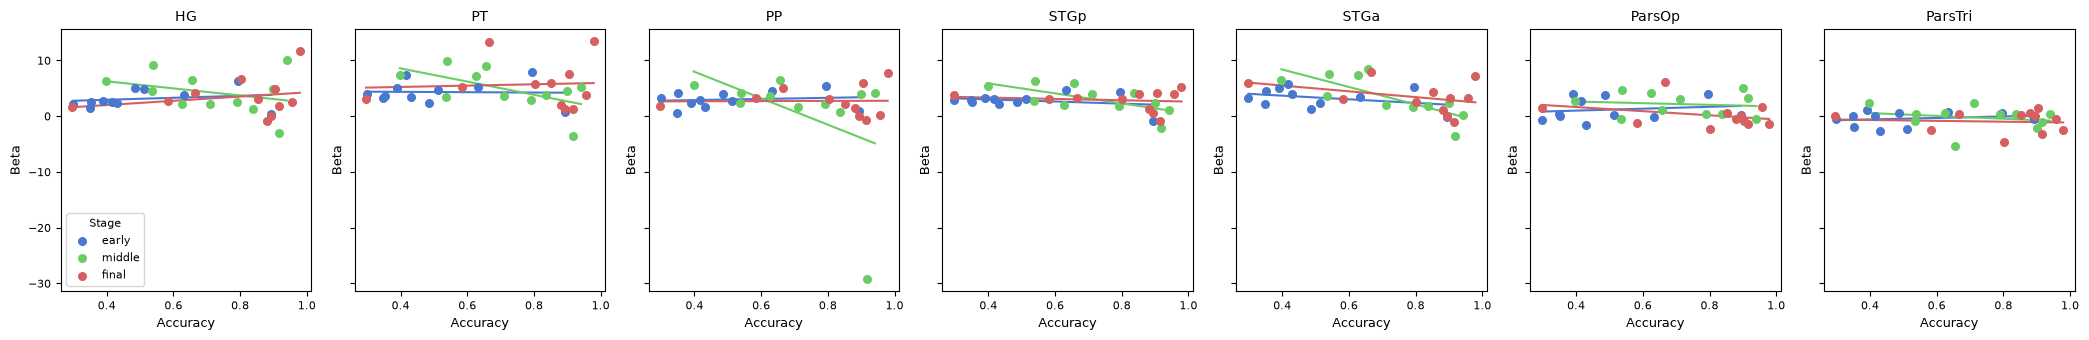

In [112]:
stage_colors = {'early': '#4878CF', 'middle': '#6ACC65', 'final': '#D65F5F'}
stages = ['early', 'middle', 'final']
rois = behav_corr_df['roi'].unique()

fig, axes = plt.subplots(1, len(rois), figsize=(3 * len(rois), 3.5), dpi=100, sharey=True)
if len(rois) == 1:
    axes = [axes]

for ri, roi in enumerate(plot_order): # rois):
    ax = axes[ri]
    for stage in stages:
        color = stage_colors[stage]
        sub_df = roi_behav_df[(roi_behav_df['region'] == roi) &
                              (roi_behav_df['learning_stage'] == stage)]

        ax.scatter(sub_df['accuracy'], sub_df['beta'], s=30,
                   color=color, label=stage, zorder=3)

        m, b = np.polyfit(sub_df['accuracy'], sub_df['beta'], 1)
        x_range = np.linspace(sub_df['accuracy'].min(), sub_df['accuracy'].max(), 100)
        ax.plot(x_range, m * x_range + b, color=color, linewidth=1.5)

        # stat annotation per stage
        row = behav_corr_df[(behav_corr_df['roi'] == roi) &
                            (behav_corr_df['learning_stage'] == stage)].iloc[0]
        p_str = '*' if row['p'] < 0.05 else 'n.s.'
        print(f"{roi} {stage}: {row['stat_str']} {p_str}")

    ax.set_title(roi, fontsize=10)
    ax.set_xlabel('Accuracy', fontsize=9)
    ax.set_ylabel('Beta', fontsize=9)
    ax.tick_params(labelsize=8)

axes[0].legend(title='Stage', fontsize=8, title_fontsize=8)
plt.tight_layout()


### omnibus ANOVA stats

In [113]:
# Mixed-Effects ANOVA with Hemisphere, Region, and Interaction
aov = AnovaRM(non_mandarin_df, 
              aggregate_func='mean',
              depvar='beta', 
              subject='participant_id', 
              within=['hemisphere', 'learning_stage','region', ]).fit()

# Display results
print('network:', network_name)
print('contrast:', contrast_label)
print(aov)


network: auditory
contrast: sound
                             Anova
                                 F Value  Num DF  Den DF  Pr > F
----------------------------------------------------------------
hemisphere                        0.1629  1.0000  10.0000 0.6950
learning_stage                    0.0134  2.0000  20.0000 0.9867
region                           10.8156  6.0000  60.0000 0.0000
hemisphere:learning_stage         1.1710  2.0000  20.0000 0.3304
hemisphere:region                 3.0399  6.0000  60.0000 0.0116
learning_stage:region             1.2132 12.0000 120.0000 0.2818
hemisphere:learning_stage:region  1.2065 12.0000 120.0000 0.2864



In [114]:
export_anova(aov, f'{contrast_label}_{network_name}_hemisphere_learning-stage_region', stats_out_dir)

,source,F,df_num,df_den,p,stat_str
0,hemisphere,0.16,1.0000,10.0000,p = .695,"F(1, 10) = 0.16, p = .695"
1,learning_stage,0.01,2.0000,20.0000,p = .987,"F(2, 20) = 0.01, p = .987"
2,region,10.82,6.0000,60.0000,p < .001,"F(6, 60) = 10.82, p < .001"
3,hemisphere:learning_stage,1.17,2.0000,20.0000,p = .330,"F(2, 20) = 1.17, p = .330"
4,hemisphere:region,3.04,6.0000,60.0000,p = .012,"F(6, 60) = 3.04, p = .012"
5,learning_stage:region,1.21,12.0000,120.0000,p = .282,"F(12, 120) = 1.21, p = .282"
6,hemisphere:learning_stage:region,1.21,12.0000,120.0000,p = .286,"F(12, 120) = 1.21, p = .286"


In [115]:
# GG-corrected bilateral replication (learning_stage x region)
bilateral_df = (non_mandarin_df
                .groupby(['participant_id', 'region', 'learning_stage'], as_index=False)['beta']
                .mean())
aov_pg = pg.rm_anova(data=bilateral_df, dv='beta',
                     within=['learning_stage', 'region'],
                     subject='participant_id',
                     detailed=True)
eta_col = 'np2' if 'np2' in aov_pg.columns else 'ng2'
print(aov_pg[['Source', 'F', 'ddof1', 'ddof2', 'p_unc', 'p_GG_corr', eta_col]])
export_pg_anova(aov_pg, f'{contrast_label}_{network_name}_learning-stage_region_bilateral', stats_out_dir)

                    Source       F  ddof1  ddof2  p_unc  p_GG_corr    ng2
0           learning_stage  0.0134      2     20 0.9867     0.9512 0.0002
1                   region 10.8156      6     60 0.0000     0.0002 0.2164
2  learning_stage * region  1.2132     12    120 0.2818     0.3142 0.0344


/ix1/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.14/site-packages/pingouin/distribution.py:514: UserWarning: Epsilon values might be innaccurate in two-way repeated measures design where each  factor has more than 2 levels. Please  double-check your results.
  warnings.warn(


,source,df_num,df_den,F,p_unc,p_GG_corr,eta_p2,stat_str
0,learning_stage,2,20,0.01,p = .987,p = .951,0.00,"F(2, 20) = 0.01, p = .951"
1,region,6,60,10.82,p < .001,p < .001,0.22,"F(6, 60) = 10.82, p < .001"
2,learning_stage * region,12,120,1.21,p = .282,p = .314,0.03,"F(12, 120) = 1.21, p = .314"


In [116]:
aov.summary().tables[0]

,F Value,Num DF,Den DF,Pr > F
hemisphere,0.1629,1.0000,10.0000,0.6950
learning_stage,0.0134,2.0000,20.0000,0.9867
region,10.8156,6.0000,60.0000,0.0000
hemisphere:learning_stage,1.1710,2.0000,20.0000,0.3304
hemisphere:region,3.0399,6.0000,60.0000,0.0116
learning_stage:region,1.2132,12.0000,120.0000,0.2818
hemisphere:learning_stage:region,1.2065,12.0000,120.0000,0.2864


In [117]:
import pingouin as pg

# Pairwise comparisons for region with FDR correction
pairwise_by_learning_stage = pg.pairwise_tests(data=non_mandarin_df,
                             dv='beta', 
                             within=['hemisphere','region', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_learning_stage.columns)

# Display key columns (without 'effsize' and 'CIs' if missing)
print("\nPost-hoc Pairwise Comparisons:")
#print(pairwise_by_learning_stage)
#pairwise_by_learning_stage[['Contrast', 'learning_stage', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]  # Keep only available columns

pd.set_option('display.max_rows', None)

pairwise_interaction = pairwise_by_learning_stage[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
pairwise_interaction = pairwise_interaction[pairwise_interaction['p_corr'] < 0.05].reset_index()
pairwise_interaction[['Contrast', 'hemisphere', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]

Available columns: Index(['Contrast', 'hemisphere', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='str')

Post-hoc Pairwise Comparisons:


,Contrast,hemisphere,A,B,T,dof,p_unc,p_corr,BF10
0,hemisphere * region,L,HG,PT,-3.6188,10.0000,0.0047,0.0144,11.19
1,hemisphere * region,L,HG,ParsOp,3.0706,10.0000,0.0118,0.0292,5.287
2,hemisphere * region,L,HG,ParsTri,5.7198,10.0000,0.0002,0.0027,163.568
3,hemisphere * region,L,PP,PT,-2.9749,10.0000,0.0139,0.0325,4.638
4,hemisphere * region,L,PT,ParsOp,5.0070,10.0000,0.0005,0.0038,68.987
5,hemisphere * region,L,PT,ParsTri,7.4896,10.0000,0.0000,0.0009,1116.815
6,hemisphere * region,L,PT,STGa,4.3989,10.0000,0.0013,0.0056,31.724
7,hemisphere * region,L,PT,STGp,4.5148,10.0000,0.0011,0.0056,36.887
8,hemisphere * region,L,ParsTri,STGa,-3.6598,10.0000,0.0044,0.0144,11.831
9,hemisphere * region,L,ParsTri,STGp,-4.4141,10.0000,0.0013,0.0056,32.362


In [118]:
# pairwise by region

# Pairwise comparisons for region with FDR correction
pairwise_by_region = pg.pairwise_tests(data=non_mandarin_df,
                             dv='beta', 
                             within=['region', 'hemisphere',],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_region.columns)

# Display key columns (without 'effsize' and 'CIs' if missing)
print("\nPost-hoc Pairwise Comparisons:")
#print(pairwise_by_region)
#pairwise_by_region[['Contrast', 'learning_stage', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]  # Keep only available columns

pd.set_option('display.max_rows', None)

pairwise_interaction = pairwise_by_region[pairwise_by_region.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p_unc'] < 0.05]
pairwise_interaction[['Contrast', 'region', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]

Available columns: Index(['Contrast', 'region', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='str')

Post-hoc Pairwise Comparisons:


,Contrast,region,A,B,T,dof,p_unc,p_corr,BF10
0,region * hemisphere,HG,L,R,0.8103,10.0000,0.4366,0.4366,0.392
1,region * hemisphere,PP,L,R,-1.2842,10.0000,0.2280,0.3192,0.577
2,region * hemisphere,PT,L,R,2.5441,10.0000,0.0292,0.1179,2.587
3,region * hemisphere,ParsOp,L,R,0.9516,10.0000,0.3637,0.4243,0.434
4,region * hemisphere,ParsTri,L,R,2.2742,10.0000,0.0462,0.1179,1.812
5,region * hemisphere,STGa,L,R,-2.2218,10.0000,0.0505,0.1179,1.694
6,region * hemisphere,STGp,L,R,-1.5935,10.0000,0.1421,0.2488,0.794


In [119]:
export_posthoc(pairwise_by_region, f'{contrast_label}_{network_name}_region_hemisphere', stats_out_dir)

,Contrast,region,A,B,t,df,p,p_fdr,stat_str,stat_str_fdr
0,region,-,HG,PP,1.75,10.0000,p = .112,p = .156,"t(10) = 1.75, p = .112","t(10) = 1.75, q = .156"
1,region,-,HG,PT,-2.25,10.0000,p = .048,p = .078,"t(10) = -2.25, p = .048","t(10) = -2.25, q = .078"
2,region,-,HG,ParsOp,2.70,10.0000,p = .022,p = .043,"t(10) = 2.70, p = .022","t(10) = 2.70, q = .043"
3,region,-,HG,ParsTri,4.87,10.0000,p < .001,p = .003,"t(10) = 4.87, p < .001","t(10) = 4.87, q = .003"
4,region,-,HG,STGa,0.28,10.0000,p = .785,p = .785,"t(10) = 0.28, p = .785","t(10) = 0.28, q = .785"
5,region,-,HG,STGp,1.19,10.0000,p = .262,p = .324,"t(10) = 1.19, p = .262","t(10) = 1.19, q = .324"
6,region,-,PP,PT,-3.96,10.0000,p = .003,p = .009,"t(10) = -3.96, p = .003","t(10) = -3.96, q = .009"
7,region,-,PP,ParsOp,0.70,10.0000,p = .497,p = .522,"t(10) = 0.70, p = .497","t(10) = 0.70, q = .522"
8,region,-,PP,ParsTri,2.18,10.0000,p = .054,p = .081,"t(10) = 2.18, p = .054","t(10) = 2.18, q = .081"
9,region,-,PP,STGa,-1.69,10.0000,p = .123,p = .161,"t(10) = -1.69, p = .123","t(10) = -1.69, q = .161"


In [120]:

# Pairwise comparisons for region with FDR correction
pairwise_by_learning_stage = pg.pairwise_tests(data=non_mandarin_df,
                             dv='beta', 
                             within=['hemisphere','learning_stage', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_learning_stage.columns)

# Display key columns (without 'effsize' and 'CIs' if missing)
print("\nPost-hoc Pairwise Comparisons:")
#print(pairwise_by_learning_stage)
#pairwise_by_learning_stage[['Contrast', 'learning_stage', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]  # Keep only available columns

pd.set_option('display.max_rows', None)

pairwise_interaction = pairwise_by_learning_stage[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p_corr'] < 0.05].reset_index()
pairwise_interaction[['Contrast', 'hemisphere', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]

Available columns: Index(['Contrast', 'hemisphere', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='str')

Post-hoc Pairwise Comparisons:


,Contrast,hemisphere,A,B,T,dof,p_unc,p_corr,BF10
0,hemisphere * learning_stage,L,early,final,0.4905,10.0000,0.6343,0.8672,0.33
1,hemisphere * learning_stage,L,early,middle,0.3651,10.0000,0.7226,0.8672,0.315
2,hemisphere * learning_stage,L,final,middle,0.1468,10.0000,0.8862,0.8862,0.3
3,hemisphere * learning_stage,R,early,final,-0.5260,10.0000,0.6104,0.8672,0.335
4,hemisphere * learning_stage,R,early,middle,-1.0930,10.0000,0.3000,0.8672,0.486
5,hemisphere * learning_stage,R,final,middle,-0.4106,10.0000,0.6900,0.8672,0.32


In [121]:
export_posthoc(pairwise_by_learning_stage, f'{contrast_label}_{network_name}_hemisphere_learning-stage', stats_out_dir)

,Contrast,hemisphere,A,B,t,df,p,p_fdr,stat_str,stat_str_fdr
0,hemisphere,-,L,R,0.40,10.0000,p = .695,p = nan,"t(10) = 0.40, p = .695","t(10) = 0.40, q = nan"
1,learning_stage,-,early,final,-0.04,10.0000,p = .967,p = .967,"t(10) = -0.04, p = .967","t(10) = -0.04, q = .967"
2,learning_stage,-,early,middle,-0.14,10.0000,p = .888,p = .967,"t(10) = -0.14, p = .888","t(10) = -0.14, q = .967"
3,learning_stage,-,final,middle,-0.10,10.0000,p = .921,p = .967,"t(10) = -0.10, p = .921","t(10) = -0.10, q = .967"
4,hemisphere * learning_stage,L,early,final,0.49,10.0000,p = .634,p = .867,"t(10) = 0.49, p = .634","t(10) = 0.49, q = .867"
5,hemisphere * learning_stage,L,early,middle,0.37,10.0000,p = .723,p = .867,"t(10) = 0.37, p = .723","t(10) = 0.37, q = .867"
6,hemisphere * learning_stage,L,final,middle,0.15,10.0000,p = .886,p = .886,"t(10) = 0.15, p = .886","t(10) = 0.15, q = .886"
7,hemisphere * learning_stage,R,early,final,-0.53,10.0000,p = .610,p = .867,"t(10) = -0.53, p = .610","t(10) = -0.53, q = .867"
8,hemisphere * learning_stage,R,early,middle,-1.09,10.0000,p = .300,p = .867,"t(10) = -1.09, p = .300","t(10) = -1.09, q = .867"
9,hemisphere * learning_stage,R,final,middle,-0.41,10.0000,p = .690,p = .867,"t(10) = -0.41, p = .690","t(10) = -0.41, q = .867"


In [122]:

# Pairwise comparisons for region with FDR correction
pairwise_by_learning_stage = pg.pairwise_tests(data=non_mandarin_df,
                             dv='beta', 
                             within=['learning_stage','hemisphere', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_learning_stage.columns)

# Display key columns (without 'effsize' and 'CIs' if missing)
print("\nPost-hoc Pairwise Comparisons:")
#print(pairwise_by_learning_stage)
#pairwise_by_learning_stage[['Contrast', 'learning_stage', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]  # Keep only available columns

pd.set_option('display.max_rows', None)

pairwise_interaction = pairwise_by_learning_stage[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p_corr'] < 0.05].reset_index()
pairwise_interaction[['Contrast', 'learning_stage', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]

Available columns: Index(['Contrast', 'learning_stage', 'A', 'B', 'Paired', 'Parametric', 'T',
       'dof', 'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='str')

Post-hoc Pairwise Comparisons:


,Contrast,learning_stage,A,B,T,dof,p_unc,p_corr,BF10
0,learning_stage * hemisphere,early,L,R,1.6942,10.0000,0.1211,0.3633,0.889
1,learning_stage * hemisphere,final,L,R,0.3679,10.0000,0.7206,0.7206,0.315
2,learning_stage * hemisphere,middle,L,R,-0.5398,10.0000,0.6011,0.7206,0.337


In [123]:
export_posthoc(pairwise_by_learning_stage, f'{contrast_label}_{network_name}_learning-stage_hemisphere', stats_out_dir)

,Contrast,learning_stage,A,B,t,df,p,p_fdr,stat_str,stat_str_fdr
0,learning_stage,-,early,final,-0.04,10.0000,p = .967,p = .967,"t(10) = -0.04, p = .967","t(10) = -0.04, q = .967"
1,learning_stage,-,early,middle,-0.14,10.0000,p = .888,p = .967,"t(10) = -0.14, p = .888","t(10) = -0.14, q = .967"
2,learning_stage,-,final,middle,-0.10,10.0000,p = .921,p = .967,"t(10) = -0.10, p = .921","t(10) = -0.10, q = .967"
3,hemisphere,-,L,R,0.40,10.0000,p = .695,p = nan,"t(10) = 0.40, p = .695","t(10) = 0.40, q = nan"
4,learning_stage * hemisphere,early,L,R,1.69,10.0000,p = .121,p = .363,"t(10) = 1.69, p = .121","t(10) = 1.69, q = .363"
5,learning_stage * hemisphere,final,L,R,0.37,10.0000,p = .721,p = .721,"t(10) = 0.37, p = .721","t(10) = 0.37, q = .721"
6,learning_stage * hemisphere,middle,L,R,-0.54,10.0000,p = .601,p = .721,"t(10) = -0.54, p = .601","t(10) = -0.54, q = .721"


In [124]:
# pairwise by region, no learning stage

# Pairwise comparisons for region with FDR correction
pairwise_by_region_only = pg.pairwise_tests(data=non_mandarin_df,
                             dv='beta', 
                             within=['region', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_region_only.columns)

# Display key columns (without 'effsize' and 'CIs' if missing)
print("\nPost-hoc Pairwise Comparisons:")
#print(pairwise_by_region_only)
pairwise_by_region_only = pairwise_by_region_only[pairwise_by_region_only['p_unc'] < 0.05]
pairwise_by_region_only[['Contrast', 'Contrast', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]  # Keep only available columns


Available columns: Index(['Contrast', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof', 'alternative',
       'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='str')

Post-hoc Pairwise Comparisons:


,Contrast,Contrast,A,B,T,dof,p_unc,p_corr,BF10
1,region,region,HG,PT,-2.2513,10.0000,0.0481,0.0777,1.759
2,region,region,HG,ParsOp,2.7003,10.0000,0.0223,0.0426,3.192
3,region,region,HG,ParsTri,4.8742,10.0000,0.0006,0.0034,58.397
6,region,region,PP,PT,-3.9639,10.0000,0.0027,0.0093,17.837
11,region,region,PT,ParsOp,4.5924,10.0000,0.0010,0.0042,40.777
12,region,region,PT,ParsTri,6.6476,10.0000,0.0001,0.0006,465.288
13,region,region,PT,STGa,3.7291,10.0000,0.0039,0.0117,12.997
14,region,region,PT,STGp,3.3813,10.0000,0.0070,0.0163,8.093
15,region,region,ParsOp,ParsTri,3.5288,10.0000,0.0055,0.0143,9.899
16,region,region,ParsOp,STGa,-3.1570,10.0000,0.0102,0.0214,5.951


In [125]:
export_posthoc(pairwise_by_region_only, f'{contrast_label}_{network_name}_region', stats_out_dir)

,Contrast,A,B,t,df,p,p_fdr,stat_str,stat_str_fdr
1,region,HG,PT,-2.25,10.0000,p = .048,p = .078,"t(10) = -2.25, p = .048","t(10) = -2.25, q = .078"
2,region,HG,ParsOp,2.70,10.0000,p = .022,p = .043,"t(10) = 2.70, p = .022","t(10) = 2.70, q = .043"
3,region,HG,ParsTri,4.87,10.0000,p < .001,p = .003,"t(10) = 4.87, p < .001","t(10) = 4.87, q = .003"
6,region,PP,PT,-3.96,10.0000,p = .003,p = .009,"t(10) = -3.96, p = .003","t(10) = -3.96, q = .009"
11,region,PT,ParsOp,4.59,10.0000,p < .001,p = .004,"t(10) = 4.59, p < .001","t(10) = 4.59, q = .004"
12,region,PT,ParsTri,6.65,10.0000,p < .001,p < .001,"t(10) = 6.65, p < .001","t(10) = 6.65, q < .001"
13,region,PT,STGa,3.73,10.0000,p = .004,p = .012,"t(10) = 3.73, p = .004","t(10) = 3.73, q = .012"
14,region,PT,STGp,3.38,10.0000,p = .007,p = .016,"t(10) = 3.38, p = .007","t(10) = 3.38, q = .016"
15,region,ParsOp,ParsTri,3.53,10.0000,p = .005,p = .014,"t(10) = 3.53, p = .005","t(10) = 3.53, q = .014"
16,region,ParsOp,STGa,-3.16,10.0000,p = .010,p = .021,"t(10) = -3.16, p = .010","t(10) = -3.16, q = .021"


### Collapse (average) over non-significant factors

In [126]:
roi_df_collapsed = roi_df_long.groupby(["participant_id", "region", 'hemisphere'], 
                                       as_index=False).agg({"beta": "mean"})


In [127]:
roi_df_collapsed.head()

,participant_id,region,hemisphere,beta
0,sub-FLT02,HG,L,2.1212
1,sub-FLT02,HG,R,4.6377
2,sub-FLT02,PP,L,3.4752
3,sub-FLT02,PP,R,3.9464
4,sub-FLT02,PT,L,5.2730


In [128]:
# Collect results
results = []

for (region, hemi), data in roi_df_collapsed.groupby(["region", "hemisphere"]):
    t_stat, p_val = ttest_1samp(data["beta"], 0)
    results.append({
        "region": region,
        "hemisphere": hemi,
        "t_stat": t_stat,
        "p_val": p_val
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Apply FDR correction
results_df["p_val_fdr"] = multipletests(results_df["p_val"], method="fdr_bh")[1]

# Print or export the table
results_df

# Optional: export
# results_df.to_csv("roi_stats.csv", index=False)
# results_df.to_excel("roi_stats.xlsx", index=False)


,region,hemisphere,t_stat,p_val,p_val_fdr
0,HG,L,6.2571,0.0001,0.0004
1,HG,R,3.4917,0.0058,0.0090
2,PP,L,0.6245,0.5463,0.5883
3,PP,R,4.9835,0.0006,0.0013
4,PT,L,7.1190,0.0000,0.0004
5,PT,R,4.4578,0.0012,0.0024
6,ParsOp,L,2.0863,0.0635,0.0808
7,ParsOp,R,1.5176,0.1601,0.1868
8,ParsTri,L,0.5325,0.6060,0.6060
9,ParsTri,R,-2.4972,0.0316,0.0442


In [129]:
_export = results_df.rename(columns={'t_stat': 't', 'p_val': 'p'}).copy()
_export['df'] = len(sub_list_nman) - 1
export_ttests(_export.to_dict('records'), f'{contrast_label}_{network_name}_baseline_by_region_hemi', stats_out_dir)

,region,hemisphere,t,p,p_val_fdr,df,p_fdr,stat_str,stat_str_fdr
0,HG,L,6.26,p < .001,0.0004,10,p < .001,"t(10) = 6.26, p < .001","t(10) = 6.26, q < .001"
1,HG,R,3.49,p = .006,0.0090,10,p = .009,"t(10) = 3.49, p = .006","t(10) = 3.49, q = .009"
2,PP,L,0.62,p = .546,0.5883,10,p = .588,"t(10) = 0.62, p = .546","t(10) = 0.62, q = .588"
3,PP,R,4.98,p < .001,0.0013,10,p = .001,"t(10) = 4.98, p < .001","t(10) = 4.98, q = .001"
4,PT,L,7.12,p < .001,0.0004,10,p < .001,"t(10) = 7.12, p < .001","t(10) = 7.12, q < .001"
5,PT,R,4.46,p = .001,0.0024,10,p = .002,"t(10) = 4.46, p = .001","t(10) = 4.46, q = .002"
6,ParsOp,L,2.09,p = .064,0.0808,10,p = .081,"t(10) = 2.09, p = .064","t(10) = 2.09, q = .081"
7,ParsOp,R,1.52,p = .160,0.1868,10,p = .187,"t(10) = 1.52, p = .160","t(10) = 1.52, q = .187"
8,ParsTri,L,0.53,p = .606,0.6060,10,p = .606,"t(10) = 0.53, p = .606","t(10) = 0.53, q = .606"
9,ParsTri,R,-2.50,p = .032,0.0442,10,p = .044,"t(10) = -2.50, p = .032","t(10) = -2.50, q = .044"


In [130]:
# Collect results
results = []

for region, data in roi_df_collapsed.groupby("region"):
    t_stat, p_val = ttest_1samp(data["beta"], 0)
    results.append({
        "region": region,
        "t_stat": t_stat,
        "p_val": p_val
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Apply FDR correction
results_df["p_val_fdr"] = multipletests(results_df["p_val"], method="fdr_bh")[1]

# Print or export the table
results_df

# Optional: export
# results_df.to_csv("roi_stats.csv", index=False)
# results_df.to_excel("roi_stats.xlsx", index=False)


,region,t_stat,p_val,p_val_fdr
0,HG,6.4649,0.0000,0.0000
1,PP,2.0997,0.0480,0.0560
2,PT,7.9076,0.0000,0.0000
3,ParsOp,2.6020,0.0166,0.0233
4,ParsTri,-1.3429,0.1937,0.1937
5,STGa,6.4001,0.0000,0.0000
6,STGp,8.3738,0.0000,0.0000


In [131]:
_export = results_df.rename(columns={'t_stat': 't', 'p_val': 'p'}).copy()
_export['df'] = len(sub_list_nman) - 1
export_ttests(_export.to_dict('records'), f'{contrast_label}_{network_name}_baseline_by_region', stats_out_dir)

,region,t,p,p_val_fdr,df,p_fdr,stat_str,stat_str_fdr
0,HG,6.46,p < .001,0.0000,10,p < .001,"t(10) = 6.46, p < .001","t(10) = 6.46, q < .001"
1,PP,2.10,p = .048,0.0560,10,p = .056,"t(10) = 2.10, p = .048","t(10) = 2.10, q = .056"
2,PT,7.91,p < .001,0.0000,10,p < .001,"t(10) = 7.91, p < .001","t(10) = 7.91, q < .001"
3,ParsOp,2.60,p = .017,0.0233,10,p = .023,"t(10) = 2.60, p = .017","t(10) = 2.60, q = .023"
4,ParsTri,-1.34,p = .194,0.1937,10,p = .194,"t(10) = -1.34, p = .194","t(10) = -1.34, q = .194"
5,STGa,6.40,p < .001,0.0000,10,p < .001,"t(10) = 6.40, p < .001","t(10) = 6.40, q < .001"
6,STGp,8.37,p < .001,0.0000,10,p < .001,"t(10) = 8.37, p < .001","t(10) = 8.37, q < .001"


In [132]:
# Collect p-values
p_values = []
t_stats = []
comparisons = []

for region_stage, data in roi_df_collapsed.groupby(["region",'hemisphere']):
    #print(region_stage)
    t_stat, p_val = ttest_1samp(data["beta"], 0)
    p_values.append(p_val)
    comparisons.append((region_stage[0], region_stage[1], t_stat))
    t_stats.append(t_stat)

# Apply FDR correction
_, p_corrected, _, _ = multipletests(p_values, method='fdr_bh')

# Print corrected results
for (region, hemisphere, t_stat), p_val_corr in zip(comparisons, p_corrected):
    print(f"Region: {region}, stage: {hemisphere}, t = {t_stat:.2f}; corrected p = {p_val_corr:.4f}")


Region: HG, stage: L, t = 6.26; corrected p = 0.0004
Region: HG, stage: R, t = 3.49; corrected p = 0.0090
Region: PP, stage: L, t = 0.62; corrected p = 0.5883
Region: PP, stage: R, t = 4.98; corrected p = 0.0013
Region: PT, stage: L, t = 7.12; corrected p = 0.0004
Region: PT, stage: R, t = 4.46; corrected p = 0.0024
Region: ParsOp, stage: L, t = 2.09; corrected p = 0.0808
Region: ParsOp, stage: R, t = 1.52; corrected p = 0.1868
Region: ParsTri, stage: L, t = 0.53; corrected p = 0.6060
Region: ParsTri, stage: R, t = -2.50; corrected p = 0.0442
Region: STGa, stage: L, t = 3.94; corrected p = 0.0049
Region: STGa, stage: R, t = 5.12; corrected p = 0.0013
Region: STGp, stage: L, t = 6.41; corrected p = 0.0004
Region: STGp, stage: R, t = 5.66; corrected p = 0.0007


In [133]:
_records = [{'region': c[0], 'hemisphere': c[1], 't': c[2], 'df': len(sub_list_nman) - 1, 'p': p}
            for c, p in zip(comparisons, p_values)]
export_ttests(_records, f'{contrast_label}_{network_name}_baseline_by_region_hemi', stats_out_dir)

,region,hemisphere,t,df,p,p_fdr,stat_str,stat_str_fdr
0,HG,L,6.26,10,p < .001,p < .001,"t(10) = 6.26, p < .001","t(10) = 6.26, q < .001"
1,HG,R,3.49,10,p = .006,p = .009,"t(10) = 3.49, p = .006","t(10) = 3.49, q = .009"
2,PP,L,0.62,10,p = .546,p = .588,"t(10) = 0.62, p = .546","t(10) = 0.62, q = .588"
3,PP,R,4.98,10,p < .001,p = .001,"t(10) = 4.98, p < .001","t(10) = 4.98, q = .001"
4,PT,L,7.12,10,p < .001,p < .001,"t(10) = 7.12, p < .001","t(10) = 7.12, q < .001"
5,PT,R,4.46,10,p = .001,p = .002,"t(10) = 4.46, p = .001","t(10) = 4.46, q = .002"
6,ParsOp,L,2.09,10,p = .064,p = .081,"t(10) = 2.09, p = .064","t(10) = 2.09, q = .081"
7,ParsOp,R,1.52,10,p = .160,p = .187,"t(10) = 1.52, p = .160","t(10) = 1.52, q = .187"
8,ParsTri,L,0.53,10,p = .606,p = .606,"t(10) = 0.53, p = .606","t(10) = 0.53, q = .606"
9,ParsTri,R,-2.50,10,p = .032,p = .044,"t(10) = -2.50, p = .032","t(10) = -2.50, q = .044"


### Cortical surface plot (t-statistic, by hemisphere)

[fetch_surf_fsaverage] Dataset directory found: /ihome/bchandrasekaran/krs228/nilearn_data/fsaverage


/ix1/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.14/site-packages/nilearn/surface/surface.py:1215: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/ix1/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.14/site-packages/nilearn/surface/surface.py:1215: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/ix1/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.14/site-packages/nilearn/surface/surface.py:1215: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/ix1/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.14/site-packages/nilearn/surface/surface.py:1215: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/ix1/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.14/site-packages/nilearn/surface/surface.py:1215: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/ix1/

ValueError: Vertices in parcellation do not form region.

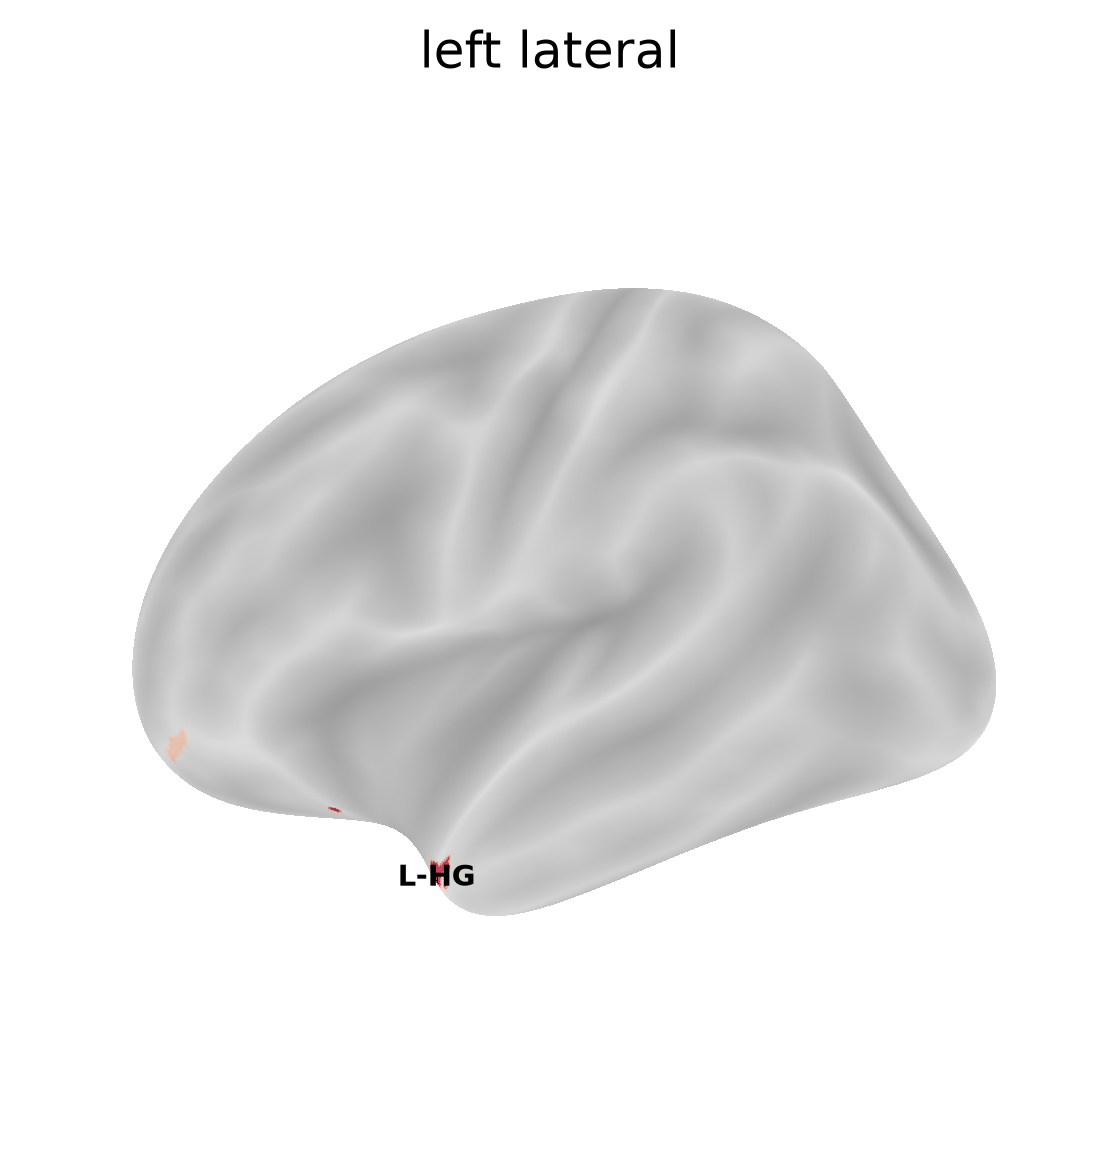

In [134]:
stat_dict = {f"{hemi}-{region}": t for (region, hemi, t) in comparisons}
mask_path_dict = build_mask_path_dict(list(stat_dict.keys()), masks_dir, network_name, space_label)

surface_views = ('lateral',) if network_name == 'auditory' else ('lateral', 'medial')
fig = plot_roi_surface_stat(stat_dict, mask_path_dict, title=f'{contrast_label} — {network_name}', views=surface_views)
#fig.savefig(os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_surface-tstat.svg'))
fig.savefig(os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_surface-tstat.png'))


### Cortical surface plot (t-statistic, final vs. early)

[fetch_surf_fsaverage] Dataset directory found: /ihome/bchandrasekaran/krs228/nilearn_data/fsaverage


/ix1/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.14/site-packages/nilearn/surface/surface.py:1215: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/ix1/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.14/site-packages/nilearn/surface/surface.py:1215: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/ix1/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.14/site-packages/nilearn/surface/surface.py:1215: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/ix1/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.14/site-packages/nilearn/surface/surface.py:1215: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/ix1/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.14/site-packages/nilearn/surface/surface.py:1215: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/ix1/

ValueError: Vertices in parcellation do not form region.

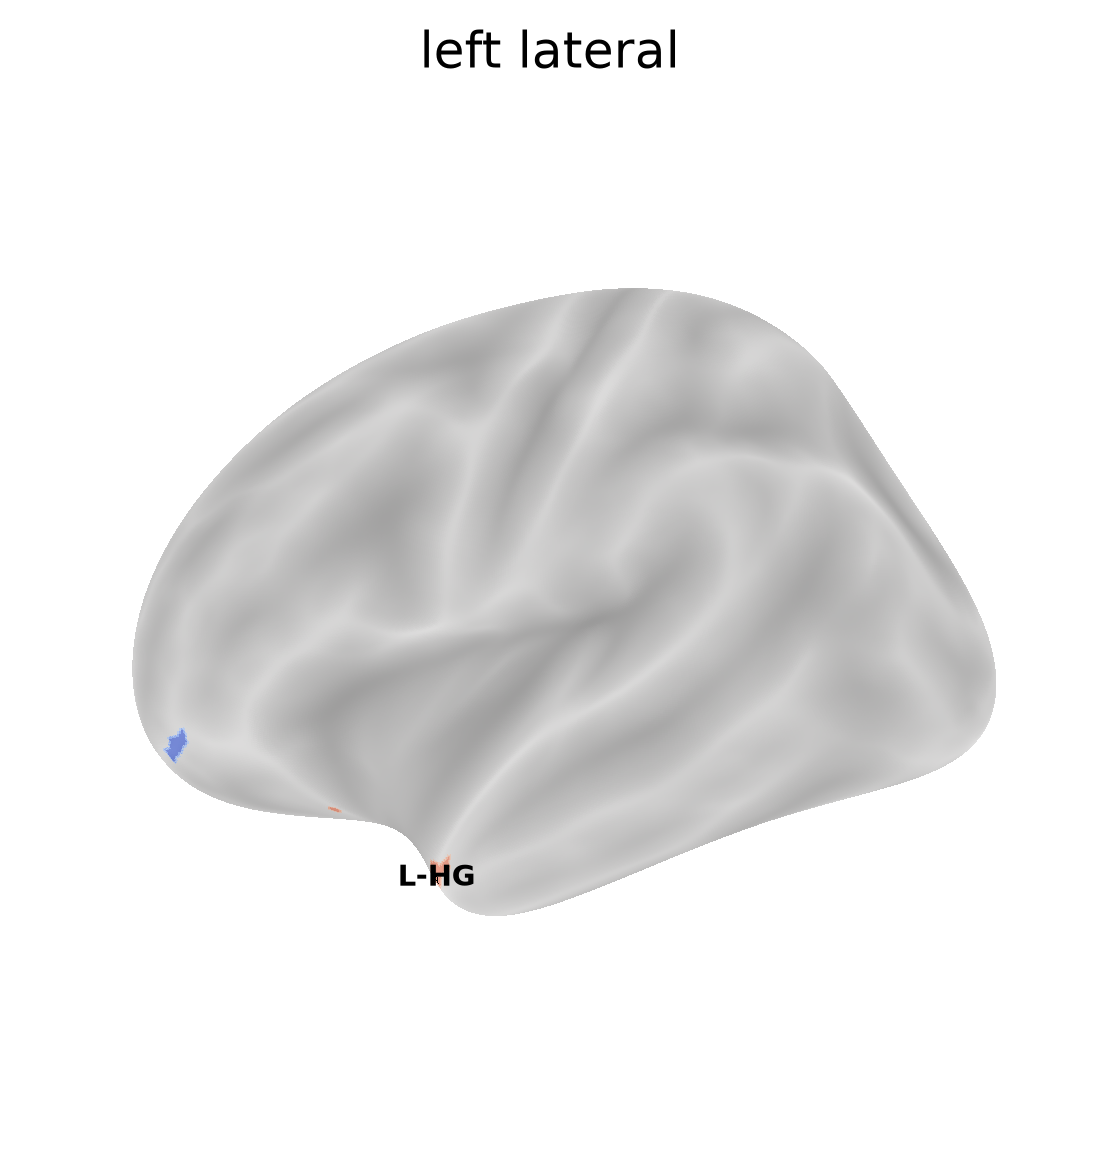

In [135]:
# Learning-stage difference (final vs. early)
_diff_df = (non_mandarin_df[non_mandarin_df['learning_stage'].isin(['early', 'final'])]
            .groupby(['participant_id', 'region_hemi', 'learning_stage'], as_index=False)['beta'].mean()
            .pivot(index=['participant_id', 'region_hemi'], columns='learning_stage', values='beta')
            .dropna()
            .reset_index())

diff_stat_dict = {}
for region_hemi, data in _diff_df.groupby('region_hemi'):
    t_stat, _ = ttest_rel(data['final'], data['early'])
    diff_stat_dict[region_hemi] = t_stat

mask_path_dict_diff = build_mask_path_dict(list(diff_stat_dict.keys()), masks_dir, network_name, space_label)
surface_views_diff = ('lateral',) if network_name == 'auditory' else ('lateral', 'medial')
fig_diff = plot_roi_surface_stat(diff_stat_dict, mask_path_dict_diff,
                                  title=f'{contrast_label} — {network_name} (final vs. early)',
                                  views=surface_views_diff)
#fig_diff.savefig(os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_surface-tstat_diff-final-early.svg'))
fig_diff.savefig(os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_surface-tstat_diff-final-early.png'))


In [136]:
# Collect p-values
p_values = []
t_stats = []
comparisons = []

for region, data in roi_df_collapsed.groupby(["region"]):
    t_stat, p_val = ttest_1samp(data["beta"], 0)
    p_values.append(p_val)
    comparisons.append((region[0], t_stat))
    t_stats.append(t_stat)

# Apply FDR correction
_, p_corrected, _, _ = multipletests(p_values, method='fdr_bh')

# Print corrected results
for (region, t_stat), p_val_corr in zip(comparisons, p_corrected):
    print(f"Region: {region}, t = {t_stat:.2f}; corrected p = {p_val_corr:.4f}")


Region: HG, t = 6.46; corrected p = 0.0000
Region: PP, t = 2.10; corrected p = 0.0560
Region: PT, t = 7.91; corrected p = 0.0000
Region: ParsOp, t = 2.60; corrected p = 0.0233
Region: ParsTri, t = -1.34; corrected p = 0.1937
Region: STGa, t = 6.40; corrected p = 0.0000
Region: STGp, t = 8.37; corrected p = 0.0000


In [137]:
_records = [{'region': c[0], 't': c[1], 'df': len(sub_list_nman) - 1, 'p': p}
            for c, p in zip(comparisons, p_values)]
export_ttests(_records, f'{contrast_label}_{network_name}_baseline_by_region', stats_out_dir)

,region,t,df,p,p_fdr,stat_str,stat_str_fdr
0,HG,6.46,10,p < .001,p < .001,"t(10) = 6.46, p < .001","t(10) = 6.46, q < .001"
1,PP,2.10,10,p = .048,p = .056,"t(10) = 2.10, p = .048","t(10) = 2.10, q = .056"
2,PT,7.91,10,p < .001,p < .001,"t(10) = 7.91, p < .001","t(10) = 7.91, q < .001"
3,ParsOp,2.60,10,p = .017,p = .023,"t(10) = 2.60, p = .017","t(10) = 2.60, q = .023"
4,ParsTri,-1.34,10,p = .194,p = .194,"t(10) = -1.34, p = .194","t(10) = -1.34, q = .194"
5,STGa,6.40,10,p < .001,p < .001,"t(10) = 6.40, p < .001","t(10) = 6.40, q < .001"
6,STGp,8.37,10,p < .001,p < .001,"t(10) = 8.37, p < .001","t(10) = 8.37, q < .001"


## `contrast-sound` for prefrontal cortical network

In [143]:
# get the beta map for the contrast of interest for each subject
network_name = network_list[3]
contrast_label = contrast_list[0]
event_type = contrast_event_type[contrast_label]
print('network_name:', network_name)
print('contrast_label:', contrast_label)

statmap_earlythird_dict = {}
for sub_id in sub_list_nman:
    statmap_earlythird_dict[sub_id] = sorted(glob(l1_dir+f'/{sub_id}_space-{space_label}/early_event-{event_type}/{sub_id}/*{contrast_label}_stat-effect_statmap.nii.gz'))[0]
    
statmap_middlethird_dict = {}
for sub_id in sub_list_nman:
    statmap_middlethird_dict[sub_id] = sorted(glob(l1_dir+f'/{sub_id}_space-{space_label}/middle_event-{event_type}/{sub_id}/*{contrast_label}_stat-effect_statmap.nii.gz'))[0]
    
statmap_latethird_dict = {}
for sub_id in sub_list_nman:
    statmap_latethird_dict[sub_id] = sorted(glob(l1_dir+f'/{sub_id}_space-{space_label}/final_event-{event_type}/{sub_id}/*{contrast_label}_stat-effect_statmap.nii.gz'))[0]

network_name: pfc
contrast_label: sound


In [144]:
# define filepath for saving (once) or loading (afterward)
out_fname = f'univariate-results_network-{network_name}_contrast-{contrast_label}.tsv'
combined_roi_df_fpath = os.path.join(group_out_dir, out_fname)

In [145]:
# mask the stat maps per learning stage by region - ONLY RUN ONCE

print(f'masking {contrast_label} stat maps for the {network_name} network')

print(f'creating dictionary for early learning stage')
roi_earlythird_mean_dict, mask_path_list = mask_stat_maps(region_dict[network_name], 
                                               statmap_earlythird_dict, 
                                               masks_dir, 
                                               network_name,
                                               space_label)

print(f'creating dictionary for middle learning stage')
roi_middlethird_mean_dict, mask_path_list = mask_stat_maps(region_dict[network_name], 
                                               statmap_middlethird_dict, 
                                               masks_dir, 
                                               network_name,
                                               space_label)

print(f'creating dictionary for final learning stage')
roi_latethird_mean_dict, mask_path_list = mask_stat_maps(region_dict[network_name], 
                                               statmap_latethird_dict, 
                                               masks_dir, 
                                               network_name,
                                               space_label)

# add `learning_stage` column and combine into single dataframe
roi_earlythird_df_long = make_stats_df(roi_earlythird_mean_dict, participants_nman_df, network_name)
roi_earlythird_df_long['learning_stage'] = 'early'
roi_middlethird_df_long = make_stats_df(roi_middlethird_mean_dict, participants_nman_df, network_name)
roi_middlethird_df_long['learning_stage'] = 'middle'
roi_latethird_df_long = make_stats_df(roi_latethird_mean_dict, participants_nman_df, network_name)
roi_latethird_df_long['learning_stage'] = 'final'

# combine into a single long dataframe
roi_df_long = pd.concat([roi_earlythird_df_long, roi_middlethird_df_long, roi_latethird_df_long],)

# save the DataFrame for easier access
roi_df_long.to_csv(combined_roi_df_fpath, sep='\t', index=False)


masking sound stat maps for the pfc network
creating dictionary for early learning stage
L-FP


IndexError: list index out of range

In [ ]:
# load the DataFrame if already exists
roi_df_long = pd.read_csv(combined_roi_df_fpath, sep='\t')

# create a bilateral-averaged dataframe (for across-contrast analysis)
sound_pfc_df = bilateral_mean(roi_df_long)


In [141]:
roi_df_long.columns

Index(['participant_id', 'participant_group', 'region', 'beta', 'region_hemi',
       'hemisphere', 'learning_stage'],
      dtype='str')

In [ ]:
roi_df_long.participant_id.unique()

In [ ]:
roi_df_long.region.unique()

In [ ]:
roi_df_long.region_hemi.unique()

In [ ]:
non_mandarin_df = roi_df_long

In [ ]:
plot_order = ['ACC', 'PCG', 'OFC', 'FP', 'FO', 'FMC', 
              'SFG', 'MFG', 'IFGt', 'IFGo', 'PreCG']

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6,4), dpi=300)

roi_df_collapsed = roi_df_long.groupby(["participant_id", "region", 'learning_stage'], 
                                       as_index=False).agg({"beta": "mean"})

sns.boxplot(data=roi_df_collapsed, 
              x='region', y='beta', 
              hue='learning_stage', hue_order=['early', 'middle', 'final'],
              order=plot_order,
              palette='crest',
              fliersize = 0,            
              linewidth=1.5,
              fill=False,
              #legend=None,
              ax=ax);
sns.stripplot(data=roi_df_collapsed, 
              x='region', y='beta', 
              hue='learning_stage', hue_order=['early', 'middle', 'final'],
              order=plot_order,
              palette='crest',
              dodge=True,
              linewidth=0.2,
              alpha=.2,
              legend=None,
              ax=ax);


xmin, xmax = ax.get_xlim()
ax.hlines(y=0, xmin=xmin, xmax=xmax, color='0.5', linestyle='--', linewidth=0.5)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title(f'contrast-{contrast_label} by learning stage');
#ax.set_ylim([-5, 5])

fig.tight_layout()

fig.savefig(os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_boxplot-stage.svg'))
fig.savefig(os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_boxplot-stage.png'))

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6,4), dpi=300)

roi_df_collapsed = roi_df_long.groupby(["participant_id", "region", 'hemisphere'], 
                                       as_index=False).agg({"beta": "mean"})

sns.boxplot(data=roi_df_collapsed, 
              x='region', y='beta', 
              hue='hemisphere', #hue_order=['early', 'middle', 'final'],
              order=plot_order,
              palette='crest',
              fliersize = 0,            
              linewidth=1.5,
              fill=False,
              #legend=None,
              ax=ax);
sns.stripplot(data=roi_df_collapsed, 
              x='region', y='beta', 
              hue='hemisphere', #hue_order=['early', 'middle', 'final'],
              order=plot_order,
              palette='crest',
              dodge=True,
              linewidth=0.2,
              alpha=.2,
              legend=None,
              ax=ax);


xmin, xmax = ax.get_xlim()
ax.hlines(y=0, xmin=xmin, xmax=xmax, color='0.5', linestyle='--', linewidth=0.5)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title(f'contrast-{contrast_label} by hemisphere');
#ax.set_ylim([-5, 5])

fig.tight_layout()

fig.savefig(os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_boxplot-hemisphere.svg'))
fig.savefig(os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_boxplot-hemisphere.png'))

### Brain-behavior correlations

In [ ]:
# map runs to learning stages matching your thirds
stage_map = {'run-01': 'early', 'run-02': 'early',
             'run-03': 'middle', 'run-04': 'middle',
             'run-05': 'final', 'run-06': 'final'}

acc_df['learning_stage'] = acc_df['run'].map(stage_map)
acc_stage_df = acc_df.groupby(['participant_id', 'learning_stage'])['accuracy'].mean().reset_index()

In [ ]:
# merge into roi_df_long — assumes participant_id and learning_stage columns exist in both
roi_df_bilateral = (roi_df_long.groupby(['participant_id', 'region', 'learning_stage'], as_index=False)['beta'].mean())
roi_behav_df = roi_df_bilateral.merge(acc_stage_df, on=['participant_id', 'learning_stage'])

# verify
roi_behav_df.groupby(['region', 'learning_stage']).size().unique()  # should be array([12])


In [ ]:
roi_behav_df.columns

In [ ]:
roi_behav_df.participant_id.unique()

In [ ]:
results = []
for stage in ['early', 'middle', 'final']:
    stage_df = roi_behav_df[roi_behav_df['learning_stage'] == stage]
    for roi in plot_order: # stage_df['region'].unique():
        sub_df = stage_df[stage_df['region'] == roi]
        r = pg.corr(sub_df['accuracy'], sub_df['beta'], method='pearson')
        results.append({
            'roi': roi,
            'learning_stage': stage,
            'r': r['r'].values[0],
            'p': r['p_val'].values[0],
            'n': r['n'].values[0],
            'stat_str': stat_str('r', r['r'].values[0], r['p_val'].values[0])
        })

behav_corr_df = pd.DataFrame(results)

In [ ]:
behav_corr_df

In [ ]:
# pivot to ROI × stage matrix
r_matrix = behav_corr_df.pivot(index='roi', columns='learning_stage', values='r')[['early', 'middle', 'final']]
p_matrix = behav_corr_df.pivot(index='roi', columns='learning_stage', values='p')[['early', 'middle', 'final']]

fig, ax = plt.subplots(figsize=(5, len(r_matrix) * 0.5 + 1), dpi=100)
sns.heatmap(r_matrix, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, annot=True, fmt='.2f', annot_kws={'size': 8},
            square=True)

# mark significant cells with an asterisk
for i, roi in enumerate(r_matrix.index):
    for j, stage in enumerate(['early', 'middle', 'final']):
        p = p_matrix.loc[roi, stage]
        if p < 0.05:
            ax.text(j + 0.5, i + 0.85, '*', ha='center', va='center',
                    fontsize=12, color='black')

ax.set_title(f'Brain-behavior correlations\n{network_name} — bilateral mean')
ax.set_ylabel('')
ax.set_xlabel('Learning stage')
plt.tight_layout()
plt.savefig(os.path.join(fig_out_dir, f'brain-behav-corr_contrast-{contrast_label}_network-{network_name}_heatmap.svg'))

In [ ]:
rois = behav_corr_df['roi'].unique()
stages = ['early', 'middle', 'final']

fig, axes = plt.subplots(len(rois), 3, figsize=(9, len(rois) * 2.5), dpi=300, sharex=False, sharey=False)

for ri, roi in enumerate(plot_order): # rois):
    for si, stage in enumerate(stages):
        ax = axes[ri, si]
        sub_df = roi_behav_df[(roi_behav_df['region'] == roi) & 
                              (roi_behav_df['learning_stage'] == stage)]
        
        ax.scatter(sub_df['accuracy'], sub_df['beta'], s=30, color='steelblue', zorder=3)
        
        # regression line
        m, b = np.polyfit(sub_df['accuracy'], sub_df['beta'], 1)
        x_range = np.linspace(sub_df['accuracy'].min(), sub_df['accuracy'].max(), 100)
        ax.plot(x_range, m * x_range + b, color='steelblue', linewidth=1)
        
        # stat annotation
        row = behav_corr_df[(behav_corr_df['roi'] == roi) & 
                            (behav_corr_df['learning_stage'] == stage)].iloc[0]
        p_str = '*' if row['p'] < 0.05 else 'n.s.'
        ax.set_title(f"{roi} — {stage}\n{row['stat_str']} {p_str}", fontsize=8)
        ax.set_xlabel('Accuracy', fontsize=7)
        ax.set_ylabel('Beta', fontsize=7)
        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig(os.path.join(fig_out_dir, f'brain-behav-corr_contrast-{contrast_label}_network-{network_name}_corr-plots.svg'))

In [ ]:
stage_colors = {'early': '#4878CF', 'middle': '#6ACC65', 'final': '#D65F5F'}
stages = ['early', 'middle', 'final']
rois = behav_corr_df['roi'].unique()

fig, axes = plt.subplots(1, len(rois), figsize=(3 * len(rois), 3.5), dpi=100, sharey=True)
if len(rois) == 1:
    axes = [axes]

for ri, roi in enumerate(plot_order): # rois):
    ax = axes[ri]
    for stage in stages:
        color = stage_colors[stage]
        sub_df = roi_behav_df[(roi_behav_df['region'] == roi) &
                              (roi_behav_df['learning_stage'] == stage)]

        ax.scatter(sub_df['accuracy'], sub_df['beta'], s=30,
                   color=color, label=stage, zorder=3)

        m, b = np.polyfit(sub_df['accuracy'], sub_df['beta'], 1)
        x_range = np.linspace(sub_df['accuracy'].min(), sub_df['accuracy'].max(), 100)
        ax.plot(x_range, m * x_range + b, color=color, linewidth=1.5)

        # stat annotation per stage
        row = behav_corr_df[(behav_corr_df['roi'] == roi) &
                            (behav_corr_df['learning_stage'] == stage)].iloc[0]
        p_str = '*' if row['p'] < 0.05 else 'n.s.'
        print(f"{roi} {stage}: {row['stat_str']} {p_str}")

    ax.set_title(roi, fontsize=10)
    ax.set_xlabel('Accuracy', fontsize=9)
    ax.set_ylabel('Beta', fontsize=9)
    ax.tick_params(labelsize=8)

axes[0].legend(title='Stage', fontsize=8, title_fontsize=8)
plt.tight_layout()


### omnibus ANOVA stats

In [ ]:
# Mixed-Effects ANOVA with Hemisphere, Region, and Interaction
aov = AnovaRM(non_mandarin_df, 
              aggregate_func='mean',
              depvar='beta', 
              subject='participant_id', 
              within=['hemisphere', 'learning_stage','region', ]).fit()

# Display results
print('network:', network_name)
print('contrast:', contrast_label)
print(aov)

stats_out_dir = os.path.join(deriv_dir, 'stats_tables')


In [ ]:
export_anova(aov, f'{contrast_label}_{network_name}_hemisphere_learning-stage_region', stats_out_dir)

In [ ]:
# GG-corrected bilateral replication (learning_stage x region)
bilateral_df = (non_mandarin_df
                .groupby(['participant_id', 'region', 'learning_stage'], as_index=False)['beta']
                .mean())
aov_pg = pg.rm_anova(data=bilateral_df, dv='beta',
                     within=['learning_stage', 'region'],
                     subject='participant_id',
                     detailed=True)
eta_col = 'np2' if 'np2' in aov_pg.columns else 'ng2'
print(aov_pg[['Source', 'F', 'ddof1', 'ddof2', 'p_unc', 'p_GG_corr', eta_col]])
export_pg_anova(aov_pg, f'{contrast_label}_{network_name}_learning-stage_region_bilateral', stats_out_dir)

In [ ]:
import pingouin as pg

# Pairwise comparisons for region with FDR correction
pairwise_by_learning_stage = pg.pairwise_tests(data=non_mandarin_df,
                             dv='beta', 
                             within=['hemisphere','region', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_learning_stage.columns)

# Display key columns (without 'effsize' and 'CIs' if missing)
print("\nPost-hoc Pairwise Comparisons:")
#print(pairwise_by_learning_stage)
#pairwise_by_learning_stage[['Contrast', 'learning_stage', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]  # Keep only available columns

pd.set_option('display.max_rows', None)

pairwise_interaction = pairwise_by_learning_stage[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
pairwise_interaction = pairwise_interaction[pairwise_interaction['p_corr'] < 0.05].reset_index()
pairwise_interaction[['Contrast', 'hemisphere', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]

In [ ]:
# pairwise by region

# Pairwise comparisons for region with FDR correction
pairwise_by_region = pg.pairwise_tests(data=non_mandarin_df,
                             dv='beta', 
                             within=['region', 'hemisphere',],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_region.columns)

# Display key columns (without 'effsize' and 'CIs' if missing)
print("\nPost-hoc Pairwise Comparisons:")
#print(pairwise_by_region)
#pairwise_by_region[['Contrast', 'learning_stage', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]  # Keep only available columns

pd.set_option('display.max_rows', None)

pairwise_interaction = pairwise_by_region[pairwise_by_region.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p_unc'] < 0.05]
pairwise_interaction[['Contrast', 'region', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]

In [ ]:
export_posthoc(pairwise_by_region, f'{contrast_label}_{network_name}_region_hemisphere', stats_out_dir)

In [ ]:

# Pairwise comparisons for region with FDR correction
pairwise_by_learning_stage = pg.pairwise_tests(data=non_mandarin_df,
                             dv='beta', 
                             within=['hemisphere','learning_stage', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_learning_stage.columns)

# Display key columns (without 'effsize' and 'CIs' if missing)
print("\nPost-hoc Pairwise Comparisons:")
#print(pairwise_by_learning_stage)
#pairwise_by_learning_stage[['Contrast', 'learning_stage', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]  # Keep only available columns

pd.set_option('display.max_rows', None)

pairwise_interaction = pairwise_by_learning_stage[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p_corr'] < 0.05].reset_index()
pairwise_interaction[['Contrast', 'hemisphere', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]

In [ ]:
export_posthoc(pairwise_by_learning_stage, f'{contrast_label}_{network_name}_hemisphere_learning-stage', stats_out_dir)

In [ ]:

# Pairwise comparisons for region with FDR correction
pairwise_by_learning_stage = pg.pairwise_tests(data=non_mandarin_df,
                             dv='beta', 
                             within=['learning_stage','hemisphere', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_learning_stage.columns)

# Display key columns (without 'effsize' and 'CIs' if missing)
print("\nPost-hoc Pairwise Comparisons:")
#print(pairwise_by_learning_stage)
#pairwise_by_learning_stage[['Contrast', 'learning_stage', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]  # Keep only available columns

pd.set_option('display.max_rows', None)

pairwise_interaction = pairwise_by_learning_stage[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p_corr'] < 0.05].reset_index()
pairwise_interaction[['Contrast', 'learning_stage', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]

In [ ]:
export_posthoc(pairwise_by_learning_stage, f'{contrast_label}_{network_name}_learning-stage_hemisphere', stats_out_dir)

In [ ]:
# pairwise by region, no learning stage

# Pairwise comparisons for region with FDR correction
pairwise_by_region_only = pg.pairwise_tests(data=non_mandarin_df,
                             dv='beta', 
                             within=['region', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_region_only.columns)

# Display key columns (without 'effsize' and 'CIs' if missing)
print("\nPost-hoc Pairwise Comparisons:")
#print(pairwise_by_region_only)
pairwise_by_region_only = pairwise_by_region_only[pairwise_by_region_only['p_unc'] < 0.05]
pairwise_by_region_only[['Contrast', 'Contrast', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]  # Keep only available columns


In [ ]:
export_posthoc(pairwise_by_region_only, f'{contrast_label}_{network_name}_region', stats_out_dir)

### Collapse (average) over non-significant factors

In [ ]:
roi_df_collapsed = roi_df_long.groupby(["participant_id", "region", 'hemisphere'], 
                                       as_index=False).agg({"beta": "mean"})


In [ ]:
roi_df_collapsed.head()

In [ ]:
# Collect results
results = []

for (region, hemi), data in roi_df_collapsed.groupby(["region", "hemisphere"]):
    t_stat, p_val = ttest_1samp(data["beta"], 0)
    results.append({
        "region": region,
        "hemisphere": hemi,
        "t_stat": t_stat,
        "p_val": p_val
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Apply FDR correction
results_df["p_val_fdr"] = multipletests(results_df["p_val"], method="fdr_bh")[1]

# Print or export the table
results_df

# Optional: export
# results_df.to_csv("roi_stats.csv", index=False)
# results_df.to_excel("roi_stats.xlsx", index=False)


In [ ]:
_export = results_df.rename(columns={'t_stat': 't', 'p_val': 'p'}).copy()
_export['df'] = len(sub_list_nman) - 1
export_ttests(_export.to_dict('records'), f'{contrast_label}_{network_name}_baseline_by_region_hemi', stats_out_dir)

In [ ]:
# Collect results
results = []

for region, data in roi_df_collapsed.groupby("region"):
    t_stat, p_val = ttest_1samp(data["beta"], 0)
    results.append({
        "region": region,
        "t_stat": t_stat,
        "p_val": p_val
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Apply FDR correction
results_df["p_val_fdr"] = multipletests(results_df["p_val"], method="fdr_bh")[1]

# Print or export the table
results_df

# Optional: export
# results_df.to_csv("roi_stats.csv", index=False)
# results_df.to_excel("roi_stats.xlsx", index=False)


In [ ]:
_export = results_df.rename(columns={'t_stat': 't', 'p_val': 'p'}).copy()
_export['df'] = len(sub_list_nman) - 1
export_ttests(_export.to_dict('records'), f'{contrast_label}_{network_name}_baseline_by_region', stats_out_dir)

In [ ]:
# Collect p-values
p_values = []
t_stats = []
comparisons = []

for region_stage, data in roi_df_collapsed.groupby(["region",'hemisphere']):
    #print(region_stage)
    t_stat, p_val = ttest_1samp(data["beta"], 0)
    p_values.append(p_val)
    comparisons.append((region_stage[0], region_stage[1], t_stat))
    t_stats.append(t_stat)

# Apply FDR correction
_, p_corrected, _, _ = multipletests(p_values, method='fdr_bh')

# Print corrected results
for (region, hemisphere, t_stat), p_val_corr in zip(comparisons, p_corrected):
    print(f"Region: {region}, hemisphere: {hemisphere}, t = {t_stat:.2f}; corrected p = {p_val_corr:.4f}")


In [ ]:
_records = [{'region': c[0], 'hemisphere': c[1], 't': c[2], 'df': len(sub_list_nman) - 1, 'p': p}
            for c, p in zip(comparisons, p_values)]
export_ttests(_records, f'{contrast_label}_{network_name}_baseline_by_region_hemi', stats_out_dir)

### Cortical surface plot (t-statistic, by hemisphere)

In [ ]:
stat_dict = {f"{hemi}-{region}": t for (region, hemi, t) in comparisons}
mask_path_dict = build_mask_path_dict(list(stat_dict.keys()), masks_dir, network_name, space_label)

surface_views = ('lateral',) if network_name == 'auditory' else ('lateral', 'medial')
fig = plot_roi_surface_stat(stat_dict, mask_path_dict, title=f'{contrast_label} — {network_name}', views=surface_views)
#fig.savefig(os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_surface-tstat.svg'))
fig.savefig(os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_surface-tstat.png'))


### Cortical surface plot (t-statistic, final vs. early)

In [ ]:
# Learning-stage difference (final vs. early)
_diff_df = (non_mandarin_df[non_mandarin_df['learning_stage'].isin(['early', 'final'])]
            .groupby(['participant_id', 'region_hemi', 'learning_stage'], as_index=False)['beta'].mean()
            .pivot(index=['participant_id', 'region_hemi'], columns='learning_stage', values='beta')
            .dropna()
            .reset_index())

diff_stat_dict = {}
for region_hemi, data in _diff_df.groupby('region_hemi'):
    t_stat, _ = ttest_rel(data['final'], data['early'])
    diff_stat_dict[region_hemi] = t_stat

mask_path_dict_diff = build_mask_path_dict(list(diff_stat_dict.keys()), masks_dir, network_name, space_label)
surface_views_diff = ('lateral',) if network_name == 'auditory' else ('lateral', 'medial')
fig_diff = plot_roi_surface_stat(diff_stat_dict, mask_path_dict_diff,
                                  title=f'{contrast_label} — {network_name} (final vs. early)',
                                  views=surface_views_diff)
#fig_diff.savefig(os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_surface-tstat_diff-final-early.svg'))
fig_diff.savefig(os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_surface-tstat_diff-final-early.png'))


In [ ]:
# Collect p-values
p_values = []
t_stats = []
comparisons = []

for region, data in roi_df_collapsed.groupby(["region"]):
    t_stat, p_val = ttest_1samp(data["beta"], 0)
    p_values.append(p_val)
    comparisons.append((region[0], t_stat))
    t_stats.append(t_stat)

# Apply FDR correction
_, p_corrected, _, _ = multipletests(p_values, method='fdr_bh')

# Print corrected results
for (region, t_stat), p_val_corr in zip(comparisons, p_corrected):
    print(f"Region: {region}, t = {t_stat:.2f}; corrected p = {p_val_corr:.4f}")


In [ ]:
_records = [{'region': c[0], 't': c[1], 'df': len(sub_list_nman) - 1, 'p': p}
            for c, p in zip(comparisons, p_values)]
export_ttests(_records, f'{contrast_label}_{network_name}_baseline_by_region', stats_out_dir)

## `contrast-fb` for striatal network

In [147]:
# get the beta map for the contrast of interest for each subject
network_name = network_list[1]
contrast_label = contrast_list[2]
event_type = contrast_event_type[contrast_label]
print('network_name:', network_name)
print('contrast_label:', contrast_label)

statmap_earlythird_dict = {}
for sub_id in sub_list_nman:
    statmap_earlythird_dict[sub_id] = sorted(glob(l1_dir+f'/{sub_id}_space-{space_label}/early_event-{event_type}/{sub_id}/*{contrast_label}_stat-effect_statmap.nii.gz'))[0]
    
statmap_middlethird_dict = {}
for sub_id in sub_list_nman:
    statmap_middlethird_dict[sub_id] = sorted(glob(l1_dir+f'/{sub_id}_space-{space_label}/middle_event-{event_type}/{sub_id}/*{contrast_label}_stat-effect_statmap.nii.gz'))[0]
    
statmap_latethird_dict = {}
for sub_id in sub_list_nman:
    statmap_latethird_dict[sub_id] = sorted(glob(l1_dir+f'/{sub_id}_space-{space_label}/final_event-{event_type}/{sub_id}/*{contrast_label}_stat-effect_statmap.nii.gz'))[0]

network_name: tian-S2
contrast_label: fbcorrectvswrong


In [148]:
# define filepath for saving (once) or loading (afterward)
out_fname = f'univariate-results_network-{network_name}_contrast-{contrast_label}.tsv'
combined_roi_df_fpath = os.path.join(group_out_dir, out_fname)

In [149]:
# mask the stat maps per learning stage by region - ONLY RUN ONCE

print(f'masking {contrast_label} stat maps for the {network_name} network')

print(f'creating dictionary for early learning stage')
roi_earlythird_mean_dict, mask_path_list = mask_stat_maps(region_dict[network_name], 
                                               statmap_earlythird_dict, 
                                               masks_dir, 
                                               network_name,
                                               space_label)

print(f'creating dictionary for middle learning stage')
roi_middlethird_mean_dict, mask_path_list = mask_stat_maps(region_dict[network_name], 
                                               statmap_middlethird_dict, 
                                               masks_dir, 
                                               network_name,
                                               space_label)

print(f'creating dictionary for final learning stage')
roi_latethird_mean_dict, mask_path_list = mask_stat_maps(region_dict[network_name], 
                                               statmap_latethird_dict, 
                                               masks_dir, 
                                               network_name,
                                               space_label)

# add `learning_stage` column and combine into single dataframe
roi_earlythird_df_long = make_stats_df(roi_earlythird_mean_dict, participants_nman_df, network_name)
roi_earlythird_df_long['learning_stage'] = 'early'
roi_middlethird_df_long = make_stats_df(roi_middlethird_mean_dict, participants_nman_df, network_name)
roi_middlethird_df_long['learning_stage'] = 'middle'
roi_latethird_df_long = make_stats_df(roi_latethird_mean_dict, participants_nman_df, network_name)
roi_latethird_df_long['learning_stage'] = 'final'

# combine into a single long dataframe
roi_df_long = pd.concat([roi_earlythird_df_long, roi_middlethird_df_long, roi_latethird_df_long],)

# had to manually fix these for some reason TBD - 6/6/26
roi_df_long['hemisphere'] = roi_df_long.region_hemi.str[-2:]
roi_df_long['region'] = roi_df_long.region_hemi.str[:-3]

# save the DataFrame for easier access
roi_df_long.to_csv(combined_roi_df_fpath, sep='\t', index=False)


masking fbcorrectvswrong stat maps for the tian-S2 network
creating dictionary for early learning stage
aCAU-lh
/ix1/bchandrasekaran/krs228/data/FLT/data_denoised/derivatives/nilearn/masks/sub-FLT02/space-T1w/masks-tian-S2/sub-FLT02_space-T1w_mask-aCAU-lh.nii.gz
/ix1/bchandrasekaran/krs228/data/FLT/data_denoised/derivatives/nilearn/masks/sub-FLT04/space-T1w/masks-tian-S2/sub-FLT04_space-T1w_mask-aCAU-lh.nii.gz
/ix1/bchandrasekaran/krs228/data/FLT/data_denoised/derivatives/nilearn/masks/sub-FLT06/space-T1w/masks-tian-S2/sub-FLT06_space-T1w_mask-aCAU-lh.nii.gz
/ix1/bchandrasekaran/krs228/data/FLT/data_denoised/derivatives/nilearn/masks/sub-FLT09/space-T1w/masks-tian-S2/sub-FLT09_space-T1w_mask-aCAU-lh.nii.gz
/ix1/bchandrasekaran/krs228/data/FLT/data_denoised/derivatives/nilearn/masks/sub-FLT11/space-T1w/masks-tian-S2/sub-FLT11_space-T1w_mask-aCAU-lh.nii.gz
/ix1/bchandrasekaran/krs228/data/FLT/data_denoised/derivatives/nilearn/masks/sub-FLT12/space-T1w/masks-tian-S2/sub-FLT12_space-T1w_ma

In [150]:
# load the DataFrame if already exists
roi_df_long = pd.read_csv(combined_roi_df_fpath, sep='\t')

# create a bilateral-averaged dataframe (for across-contrast analysis)
feedback_striatum_df = bilateral_mean(roi_df_long)


In [151]:
roi_df_long.participant_id.unique()

<StringArray>
['sub-FLT02', 'sub-FLT04', 'sub-FLT06', 'sub-FLT09', 'sub-FLT11', 'sub-FLT12',
 'sub-FLT13', 'sub-FLT14', 'sub-FLT25', 'sub-FLT28', 'sub-FLT30']
Length: 11, dtype: str

In [152]:
roi_df_long.region.unique()

<StringArray>
['aCAU', 'pCAU', 'aPUT', 'pPUT', 'NAc-shell', 'NAc-core']
Length: 6, dtype: str

In [153]:
non_mandarin_df = roi_df_long.copy()

# create a new column based on rostral–caudal axis
non_mandarin_df['Axis'] = ''

if network_name == 'tian-S3':
    non_mandarin_df.loc[(non_mandarin_df['region']=='pCAU'),   'Axis'] = 'Caudal'
    non_mandarin_df.loc[(non_mandarin_df['region']=='PUT-VP'), 'Axis'] = 'Caudal'
    non_mandarin_df.loc[(non_mandarin_df['region']=='PUT-DP'), 'Axis'] = 'Caudal'

    non_mandarin_df.loc[non_mandarin_df['region']=='CAU-DA', 'Axis'] = 'Rostral'
    non_mandarin_df.loc[non_mandarin_df['region']=='CAU-VA', 'Axis'] = 'Rostral'
    non_mandarin_df.loc[non_mandarin_df['region']=='CAU-DP', 'Axis'] = 'Rostral'
    non_mandarin_df.loc[non_mandarin_df['region']=='CAU-VP', 'Axis'] = 'Rostral'

    non_mandarin_df.loc[non_mandarin_df['region']=='PUT-VA', 'Axis'] = 'Rostral'
    non_mandarin_df.loc[non_mandarin_df['region']=='PUT-DA', 'Axis'] = 'Rostral'

    non_mandarin_df.loc[non_mandarin_df['region']=='NAc-shell', 'Axis'] = 'Ventral'
    non_mandarin_df.loc[non_mandarin_df['region']=='NAc-core', 'Axis'] = 'Ventral'

elif network_name == 'tian-S2':
    non_mandarin_df.loc[(non_mandarin_df['region']=='pCAU'), 'Axis'] = 'Caudal'
    non_mandarin_df.loc[(non_mandarin_df['region']=='pPUT'), 'Axis'] = 'Caudal'    
    
    non_mandarin_df.loc[(non_mandarin_df['region']=='aCAU'), 'Axis'] = 'Rostral'
    non_mandarin_df.loc[(non_mandarin_df['region']=='aPUT'), 'Axis'] = 'Rostral'    

    non_mandarin_df.loc[non_mandarin_df['region']=='NAc-shell', 'Axis'] = 'Ventral'
    non_mandarin_df.loc[non_mandarin_df['region']=='NAc-core', 'Axis'] = 'Ventral'

non_mandarin_df.head()

,participant_id,participant_group,region,beta,region_hemi,hemisphere,learning_stage,Axis
0,sub-FLT02,non-Mandarin,aCAU,-1.3907,aCAU-lh,lh,early,Rostral
1,sub-FLT04,non-Mandarin,aCAU,0.1185,aCAU-lh,lh,early,Rostral
2,sub-FLT06,non-Mandarin,aCAU,0.4464,aCAU-lh,lh,early,Rostral
3,sub-FLT09,non-Mandarin,aCAU,-0.5741,aCAU-lh,lh,early,Rostral
4,sub-FLT11,non-Mandarin,aCAU,0.6971,aCAU-lh,lh,early,Rostral


In [154]:
# right now, requires separate dictionaries per learning stage
# could be re-written to take roi_df_long or similar
'''
roi_mean_dict_list = [roi_earlythird_mean_dict, roi_middlethird_mean_dict, roi_latethird_mean_dict]
fig = plot_roi_slices_avg(roi_mean_dict_list, mask_path_list, network_name, space_label)
'''

'\nroi_mean_dict_list = [roi_earlythird_mean_dict, roi_middlethird_mean_dict, roi_latethird_mean_dict]\nfig = plot_roi_slices_avg(roi_mean_dict_list, mask_path_list, network_name, space_label)\n'

In [155]:
# right now, requires separate dictionaries per learning stage
# could be re-written to take roi_df_long or similar
'''
plot_roi_slices_diff(roi_earlythird_mean_dict, roi_latethird_mean_dict, mask_path_list, network_name, space_label)
'''

'\nplot_roi_slices_diff(roi_earlythird_mean_dict, roi_latethird_mean_dict, mask_path_list, network_name, space_label)\n'

In [156]:
plot_order = ['aCAU', 'pCAU', 'aPUT', 'pPUT', 'NAc-core', 'NAc-shell', ]

/scratch/slurm-10971702/ipykernel_1708492/4213364461.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')


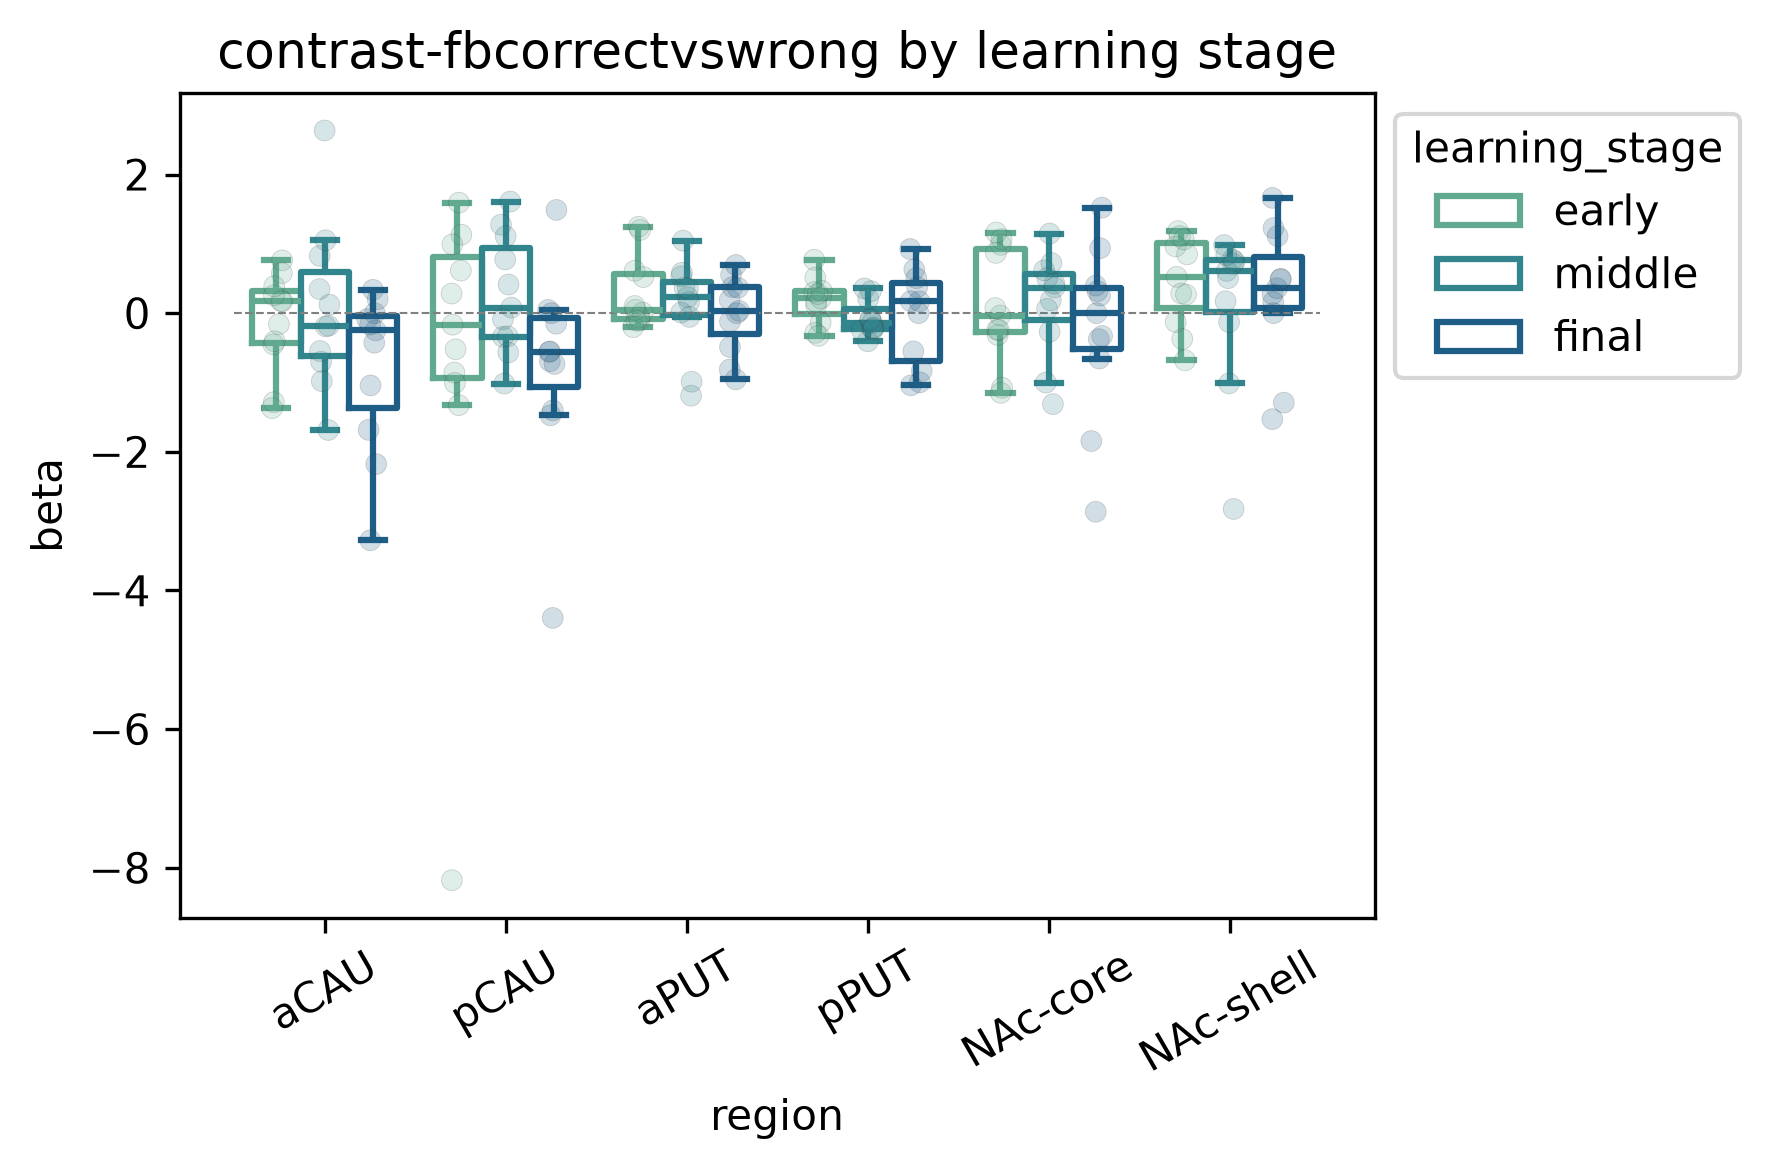

In [157]:
fig, ax = plt.subplots(1, 1, figsize=(6,4), dpi=300)

roi_df_collapsed = roi_df_long.groupby(["participant_id", "region", 'learning_stage'], 
                                       as_index=False).agg({"beta": "mean"})

sns.boxplot(data=roi_df_collapsed, 
              x='region', y='beta', 
              hue='learning_stage', hue_order=['early', 'middle', 'final'],
              order=plot_order,
              palette='crest',
              fliersize = 0,            
              linewidth=1.5,
              fill=False,
              #legend=None,
              ax=ax);
sns.stripplot(data=roi_df_collapsed, 
              x='region', y='beta', 
              hue='learning_stage', hue_order=['early', 'middle', 'final'],
              order=plot_order,
              palette='crest',
              dodge=True,
              linewidth=0.2,
              alpha=.2,
              legend=None,
              ax=ax);


xmin, xmax = ax.get_xlim()
ax.hlines(y=0, xmin=xmin, xmax=xmax, color='0.5', linestyle='--', linewidth=0.5)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title(f'contrast-{contrast_label} by learning stage');
#ax.set_ylim([-5, 5])

fig.tight_layout()
fig.savefig(os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_boxplot-stage.svg'))
fig.savefig(os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_boxplot-stage.png'))

/scratch/slurm-10971702/ipykernel_1708492/10840328.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')


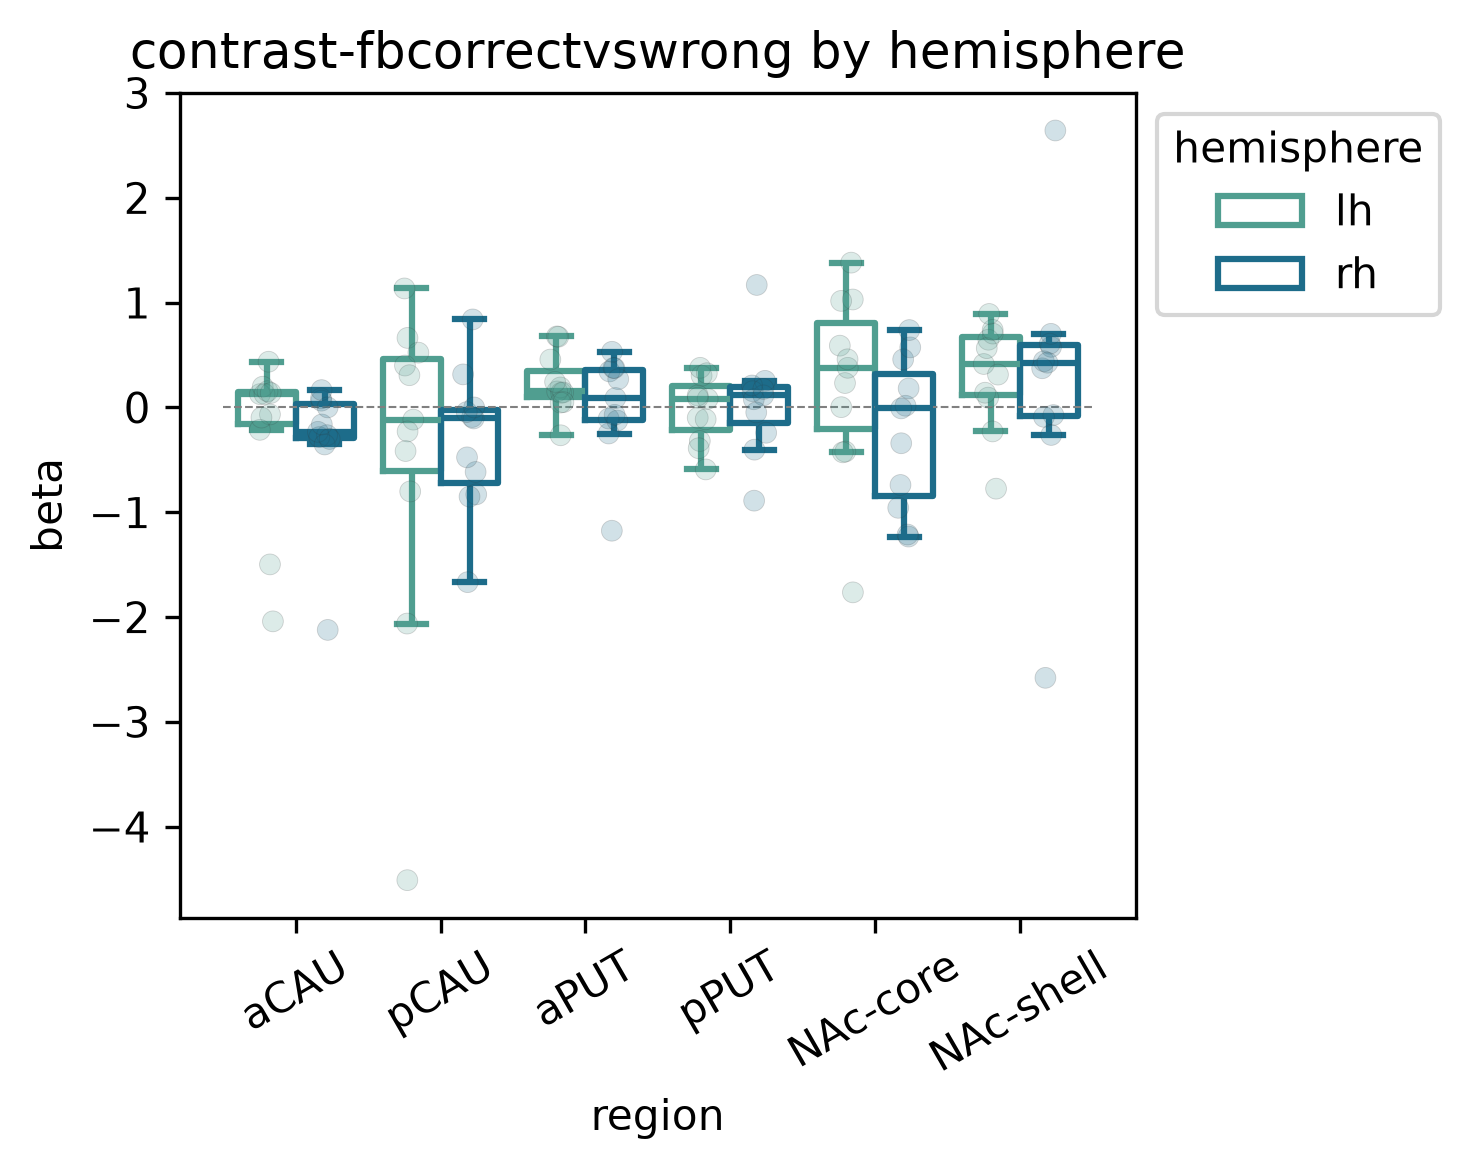

In [158]:
fig, ax = plt.subplots(1, 1, figsize=(5,4), dpi=300)

roi_df_collapsed = roi_df_long.groupby(["participant_id", "region", 'hemisphere'], 
                                       as_index=False).agg({"beta": "mean"})

sns.boxplot(data=roi_df_collapsed, 
              x='region', y='beta', 
              hue='hemisphere', #hue_order=['early', 'middle', 'final'],
              order=plot_order,
              palette='crest',
              fliersize = 0,            
              linewidth=1.5,
              fill=False,
              #legend=None,
              ax=ax);
sns.stripplot(data=roi_df_collapsed, 
              x='region', y='beta', 
              hue='hemisphere', #hue_order=['early', 'middle', 'final'],
              order=plot_order,
              palette='crest',
              dodge=True,
              linewidth=0.2,
              alpha=.2,
              legend=None,
              ax=ax);


xmin, xmax = ax.get_xlim()
ax.hlines(y=0, xmin=xmin, xmax=xmax, color='0.5', linestyle='--', linewidth=0.5)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title(f'contrast-{contrast_label} by hemisphere');
#ax.set_ylim([-5, 5])

fig.tight_layout()

fig.savefig(os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_boxplot-hemisphere.svg'))
fig.savefig(os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_boxplot-hemisphere.png'))

### Brain-behavior correlations

In [159]:
# map runs to learning stages matching your thirds
stage_map = {'run-01': 'early', 'run-02': 'early',
             'run-03': 'middle', 'run-04': 'middle',
             'run-05': 'final', 'run-06': 'final'}

acc_df['learning_stage'] = acc_df['run'].map(stage_map)
acc_stage_df = acc_df.groupby(['participant_id', 'learning_stage'])['accuracy'].mean().reset_index()

In [160]:
# merge into roi_df_long — assumes participant_id and learning_stage columns exist in both
roi_df_bilateral = (roi_df_long.groupby(['participant_id', 'region', 'learning_stage'], as_index=False)['beta'].mean())
roi_behav_df = roi_df_bilateral.merge(acc_stage_df, on=['participant_id', 'learning_stage'])

# verify
roi_behav_df.groupby(['region', 'learning_stage']).size().unique()  # should be array([12])


array([11])

In [161]:
roi_behav_df.columns

Index(['participant_id', 'region', 'learning_stage', 'beta', 'accuracy'], dtype='str')

In [162]:
roi_behav_df.participant_id.unique()

<StringArray>
['sub-FLT02', 'sub-FLT04', 'sub-FLT06', 'sub-FLT09', 'sub-FLT11', 'sub-FLT12',
 'sub-FLT13', 'sub-FLT14', 'sub-FLT25', 'sub-FLT28', 'sub-FLT30']
Length: 11, dtype: str

In [163]:
results = []
for stage in ['early', 'middle', 'final']:
    stage_df = roi_behav_df[roi_behav_df['learning_stage'] == stage]
    for roi in stage_df['region'].unique():
        sub_df = stage_df[stage_df['region'] == roi]
        r = pg.corr(sub_df['accuracy'], sub_df['beta'], method='pearson')
        results.append({
            'roi': roi,
            'learning_stage': stage,
            'r': r['r'].values[0],
            'p': r['p_val'].values[0],
            'n': r['n'].values[0],
            'stat_str': stat_str('r', r['r'].values[0], r['p_val'].values[0])
        })

behav_corr_df = pd.DataFrame(results)

In [164]:
behav_corr_df

,roi,learning_stage,r,p,n,stat_str
0,NAc-core,early,-0.4449,0.1704,11,"r = -.44, p = .170"
1,NAc-shell,early,-0.2817,0.4013,11,"r = -.28, p = .401"
2,aCAU,early,-0.7239,0.0118,11,"r = -.72, p = .012"
3,aPUT,early,-0.2368,0.4832,11,"r = -.24, p = .483"
4,pCAU,early,-0.7872,0.0040,11,"r = -.79, p = .004"
5,pPUT,early,0.2705,0.4211,11,"r = .27, p = .421"
6,NAc-core,middle,0.0657,0.8477,11,"r = .07, p = .848"
7,NAc-shell,middle,-0.2624,0.4358,11,"r = -.26, p = .436"
8,aCAU,middle,0.1534,0.6524,11,"r = .15, p = .652"
9,aPUT,middle,-0.0577,0.8661,11,"r = -.06, p = .866"


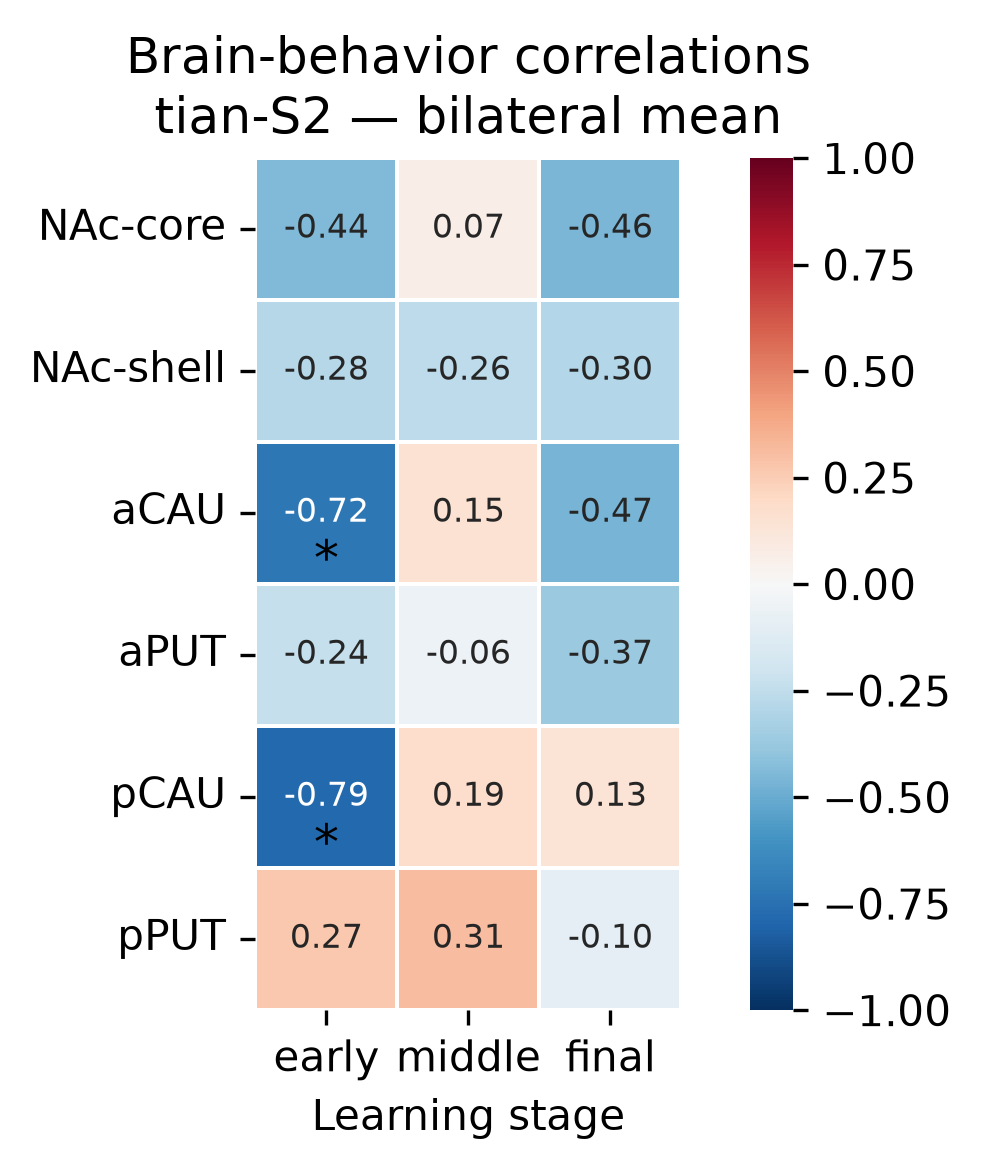

In [165]:
# pivot to ROI × stage matrix
r_matrix = behav_corr_df.pivot(index='roi', columns='learning_stage', values='r')[['early', 'middle', 'final']]
p_matrix = behav_corr_df.pivot(index='roi', columns='learning_stage', values='p')[['early', 'middle', 'final']]

fig, ax = plt.subplots(figsize=(5, len(r_matrix) * 0.5 + 1), dpi=300)
sns.heatmap(r_matrix, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, annot=True, fmt='.2f', annot_kws={'size': 8},
            square=True)

# mark significant cells with an asterisk
for i, roi in enumerate(r_matrix.index):
    for j, stage in enumerate(['early', 'middle', 'final']):
        p = p_matrix.loc[roi, stage]
        if p < 0.05:
            ax.text(j + 0.5, i + 0.85, '*', ha='center', va='center',
                    fontsize=12, color='black')

ax.set_title(f'Brain-behavior correlations\n{network_name} — bilateral mean')
ax.set_ylabel('')
ax.set_xlabel('Learning stage')
plt.tight_layout()
plt.savefig(os.path.join(fig_out_dir, f'brain-behav-corr_contrast-{contrast_label}_network-{network_name}_heatmap.svg'))

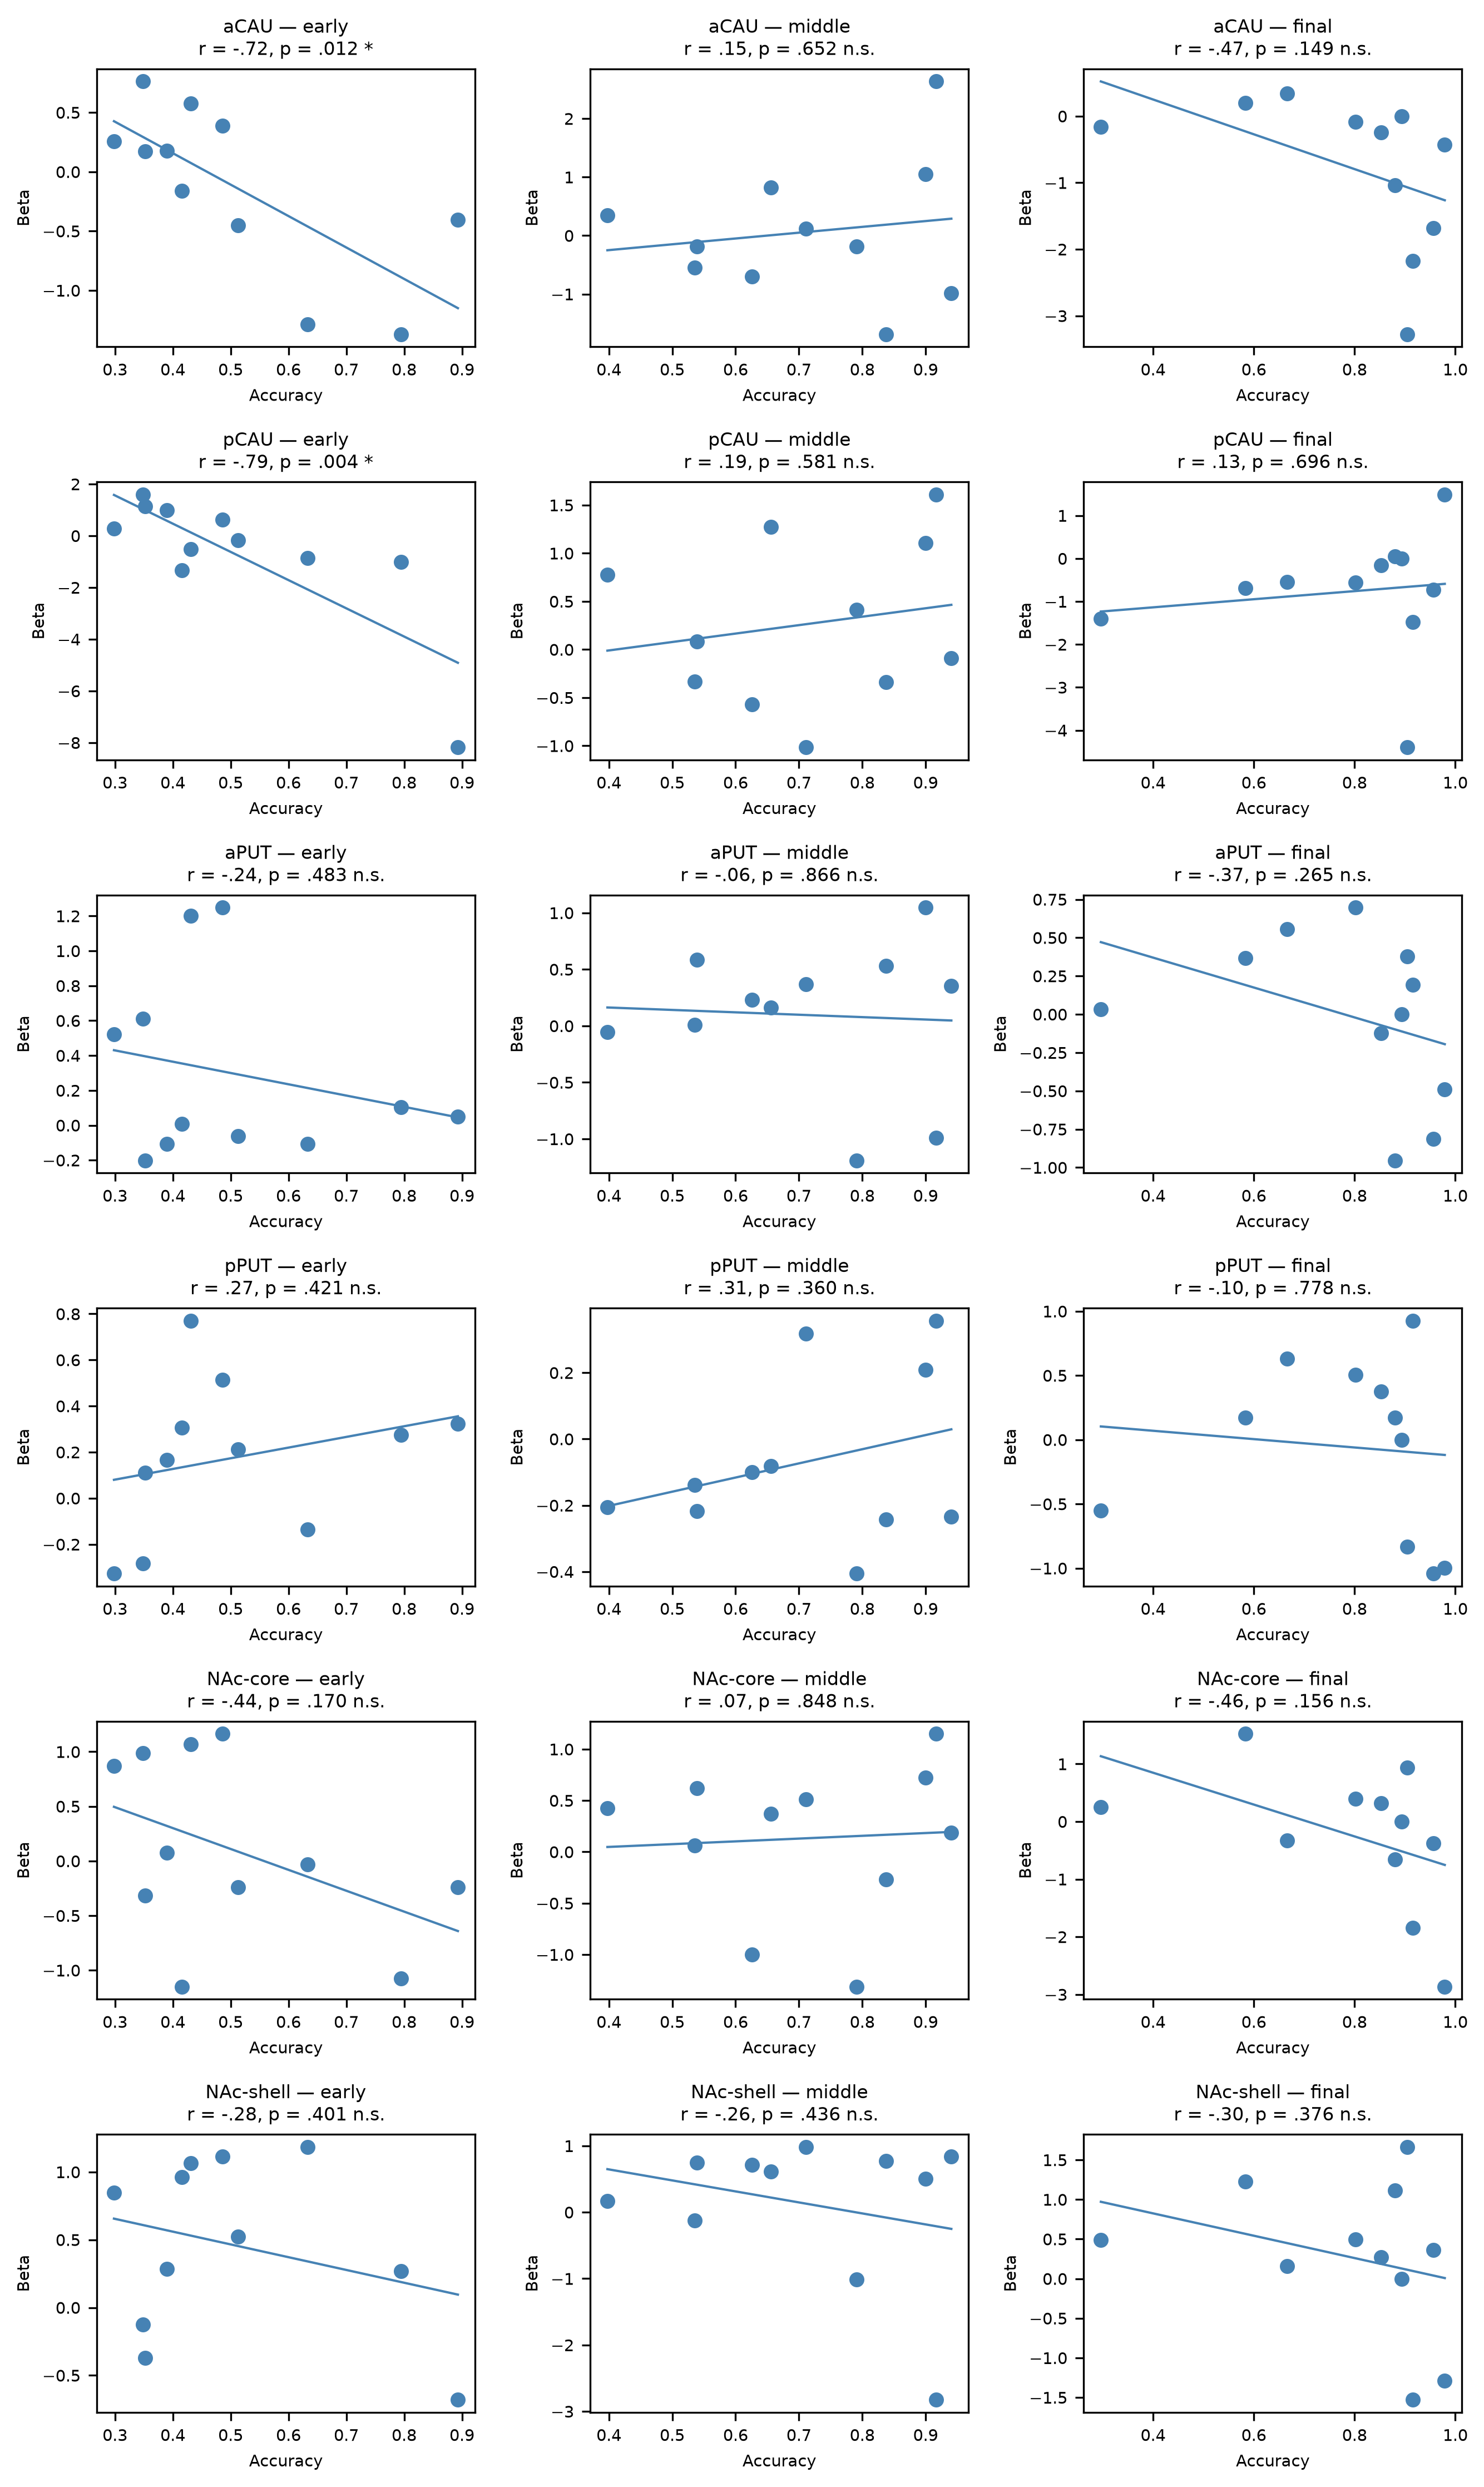

In [166]:
rois = behav_corr_df['roi'].unique()
stages = ['early', 'middle', 'final']

fig, axes = plt.subplots(len(rois), 3, figsize=(9, len(rois) * 2.5), dpi=300, sharex=False, sharey=False)

for ri, roi in enumerate(plot_order): # rois):
    for si, stage in enumerate(stages):
        ax = axes[ri, si]
        sub_df = roi_behav_df[(roi_behav_df['region'] == roi) & 
                              (roi_behav_df['learning_stage'] == stage)]
        
        ax.scatter(sub_df['accuracy'], sub_df['beta'], s=30, color='steelblue', zorder=3)
        
        # regression line
        m, b = np.polyfit(sub_df['accuracy'], sub_df['beta'], 1)
        x_range = np.linspace(sub_df['accuracy'].min(), sub_df['accuracy'].max(), 100)
        ax.plot(x_range, m * x_range + b, color='steelblue', linewidth=1)
        
        # stat annotation
        row = behav_corr_df[(behav_corr_df['roi'] == roi) & 
                            (behav_corr_df['learning_stage'] == stage)].iloc[0]
        p_str = '*' if row['p'] < 0.05 else 'n.s.'
        ax.set_title(f"{roi} — {stage}\n{row['stat_str']} {p_str}", fontsize=8)
        ax.set_xlabel('Accuracy', fontsize=7)
        ax.set_ylabel('Beta', fontsize=7)
        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig(os.path.join(fig_out_dir, f'brain-behav-corr_contrast-{contrast_label}_network-{network_name}_corr-plots.svg'))

NAc-core early: r = -.44, p = .170 n.s.
NAc-core middle: r = .07, p = .848 n.s.
NAc-core final: r = -.46, p = .156 n.s.
NAc-shell early: r = -.28, p = .401 n.s.
NAc-shell middle: r = -.26, p = .436 n.s.
NAc-shell final: r = -.30, p = .376 n.s.
aCAU early: r = -.72, p = .012 *
aCAU middle: r = .15, p = .652 n.s.
aCAU final: r = -.47, p = .149 n.s.
aPUT early: r = -.24, p = .483 n.s.
aPUT middle: r = -.06, p = .866 n.s.
aPUT final: r = -.37, p = .265 n.s.
pCAU early: r = -.79, p = .004 *
pCAU middle: r = .19, p = .581 n.s.
pCAU final: r = .13, p = .696 n.s.
pPUT early: r = .27, p = .421 n.s.
pPUT middle: r = .31, p = .360 n.s.
pPUT final: r = -.10, p = .778 n.s.


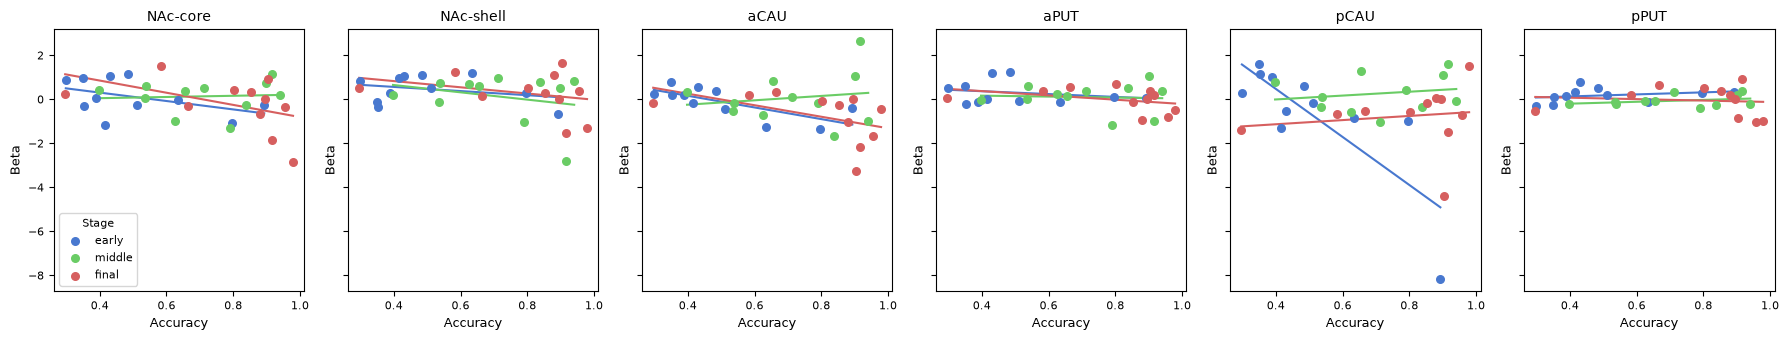

In [167]:
stage_colors = {'early': '#4878CF', 'middle': '#6ACC65', 'final': '#D65F5F'}
stages = ['early', 'middle', 'final']
rois = behav_corr_df['roi'].unique()

fig, axes = plt.subplots(1, len(rois), figsize=(3 * len(rois), 3.5), dpi=100, sharey=True)
if len(rois) == 1:
    axes = [axes]

for ri, roi in enumerate(rois):
    ax = axes[ri]
    for stage in stages:
        color = stage_colors[stage]
        sub_df = roi_behav_df[(roi_behav_df['region'] == roi) &
                              (roi_behav_df['learning_stage'] == stage)]

        ax.scatter(sub_df['accuracy'], sub_df['beta'], s=30,
                   color=color, label=stage, zorder=3)

        m, b = np.polyfit(sub_df['accuracy'], sub_df['beta'], 1)
        x_range = np.linspace(sub_df['accuracy'].min(), sub_df['accuracy'].max(), 100)
        ax.plot(x_range, m * x_range + b, color=color, linewidth=1.5)

        # stat annotation per stage
        row = behav_corr_df[(behav_corr_df['roi'] == roi) &
                            (behav_corr_df['learning_stage'] == stage)].iloc[0]
        p_str = '*' if row['p'] < 0.05 else 'n.s.'
        print(f"{roi} {stage}: {row['stat_str']} {p_str}")

    ax.set_title(roi, fontsize=10)
    ax.set_xlabel('Accuracy', fontsize=9)
    ax.set_ylabel('Beta', fontsize=9)
    ax.tick_params(labelsize=8)

axes[0].legend(title='Stage', fontsize=8, title_fontsize=8)
plt.tight_layout()


### omnibus ANOVA stats

In [168]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import AnovaRM
import pingouin as pg

stats_out_dir = os.path.join(deriv_dir, 'stats_tables')


In [169]:
non_mandarin_df.head()

,participant_id,participant_group,region,beta,region_hemi,hemisphere,learning_stage,Axis
0,sub-FLT02,non-Mandarin,aCAU,-1.3907,aCAU-lh,lh,early,Rostral
1,sub-FLT04,non-Mandarin,aCAU,0.1185,aCAU-lh,lh,early,Rostral
2,sub-FLT06,non-Mandarin,aCAU,0.4464,aCAU-lh,lh,early,Rostral
3,sub-FLT09,non-Mandarin,aCAU,-0.5741,aCAU-lh,lh,early,Rostral
4,sub-FLT11,non-Mandarin,aCAU,0.6971,aCAU-lh,lh,early,Rostral


In [170]:
non_mandarin_df.participant_id.unique()

<StringArray>
['sub-FLT02', 'sub-FLT04', 'sub-FLT06', 'sub-FLT09', 'sub-FLT11', 'sub-FLT12',
 'sub-FLT13', 'sub-FLT14', 'sub-FLT25', 'sub-FLT28', 'sub-FLT30']
Length: 11, dtype: str

In [171]:
# Mixed-Effects ANOVA with Hemisphere, Region, and Interaction
aov = AnovaRM(non_mandarin_df, 
              aggregate_func='mean',
              depvar='beta', 
              subject='participant_id', 
              within=['hemisphere', 'learning_stage','region', ]).fit()

# Display results
print('network:', network_name)
print('contrast:', contrast_label)
aov.summary()

network: tian-S2
contrast: fbcorrectvswrong


,F Value,Num DF,Den DF,Pr > F
hemisphere,1.9496,1.0000,10.0000,0.1928
learning_stage,1.7831,2.0000,20.0000,0.1938
region,1.8575,5.0000,50.0000,0.1187
hemisphere:learning_stage,1.0358,2.0000,20.0000,0.3732
hemisphere:region,0.5675,5.0000,50.0000,0.7244
learning_stage:region,0.9585,10.0000,100.0000,0.4843
hemisphere:learning_stage:region,1.1024,10.0000,100.0000,0.3678


In [172]:
export_anova(aov, f'{contrast_label}_{network_name}_hemisphere_learning-stage_region', stats_out_dir)

,source,F,df_num,df_den,p,stat_str
0,hemisphere,1.95,1.0000,10.0000,p = .193,"F(1, 10) = 1.95, p = .193"
1,learning_stage,1.78,2.0000,20.0000,p = .194,"F(2, 20) = 1.78, p = .194"
2,region,1.86,5.0000,50.0000,p = .119,"F(5, 50) = 1.86, p = .119"
3,hemisphere:learning_stage,1.04,2.0000,20.0000,p = .373,"F(2, 20) = 1.04, p = .373"
4,hemisphere:region,0.57,5.0000,50.0000,p = .724,"F(5, 50) = 0.57, p = .724"
5,learning_stage:region,0.96,10.0000,100.0000,p = .484,"F(10, 100) = 0.96, p = .484"
6,hemisphere:learning_stage:region,1.10,10.0000,100.0000,p = .368,"F(10, 100) = 1.10, p = .368"


In [173]:
# GG-corrected bilateral replication (learning_stage x region)
bilateral_df = (non_mandarin_df
                .groupby(['participant_id', 'region', 'learning_stage'], as_index=False)['beta']
                .mean())
aov_pg = pg.rm_anova(data=bilateral_df, dv='beta',
                     within=['learning_stage', 'region'],
                     subject='participant_id',
                     detailed=True)
eta_col = 'np2' if 'np2' in aov_pg.columns else 'ng2'
print(aov_pg[['Source', 'F', 'ddof1', 'ddof2', 'p_unc', 'p_GG_corr', eta_col]])
export_pg_anova(aov_pg, f'{contrast_label}_{network_name}_learning-stage_region_bilateral', stats_out_dir)

                    Source      F  ddof1  ddof2  p_unc  p_GG_corr    ng2
0           learning_stage 1.7831      2     20 0.1938     0.1961 0.0247
1                   region 1.8575      5     50 0.1187     0.1656 0.0498
2  learning_stage * region 0.9585     10    100 0.4843     0.3948 0.0426


/ix1/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.14/site-packages/pingouin/distribution.py:514: UserWarning: Epsilon values might be innaccurate in two-way repeated measures design where each  factor has more than 2 levels. Please  double-check your results.
  warnings.warn(


,source,df_num,df_den,F,p_unc,p_GG_corr,eta_p2,stat_str
0,learning_stage,2,20,1.78,p = .194,p = .196,0.02,"F(2, 20) = 1.78, p = .196"
1,region,5,50,1.86,p = .119,p = .166,0.05,"F(5, 50) = 1.86, p = .166"
2,learning_stage * region,10,100,0.96,p = .484,p = .395,0.04,"F(10, 100) = 0.96, p = .395"


In [174]:
import pingouin as pg

# Pairwise comparisons for region with FDR correction
pairwise_by_learning_stage = pg.pairwise_tests(data=non_mandarin_df,
                             dv='beta', 
                             within=['learning_stage','region', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_learning_stage.columns)

# Display key columns (without 'effsize' and 'CIs' if missing)
print("\nPost-hoc Pairwise Comparisons:")
#print(pairwise_by_learning_stage)
#pairwise_by_learning_stage[['Contrast', 'learning_stage', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]  # Keep only available columns

pd.set_option('display.max_rows', None)

pairwise_interaction = pairwise_by_learning_stage[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
pairwise_interaction = pairwise_interaction[pairwise_interaction['p_unc'] < 0.05].reset_index()
pairwise_interaction[['Contrast', 'learning_stage', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]

Available columns: Index(['Contrast', 'learning_stage', 'A', 'B', 'Paired', 'Parametric', 'T',
       'dof', 'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='str')

Post-hoc Pairwise Comparisons:


,Contrast,learning_stage,A,B,T,dof,p_unc,p_corr,BF10
0,learning_stage * region,early,aCAU,aPUT,-2.3570,10.0000,0.0402,0.5688,2.019
1,learning_stage * region,final,NAc-core,NAc-shell,-2.5734,10.0000,0.0277,0.5688,2.691


In [175]:
# pairwise by region

# Pairwise comparisons for region with FDR correction
pairwise_by_region = pg.pairwise_tests(data=non_mandarin_df,
                             dv='beta', 
                             within=['region', 'learning_stage',],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_region.columns)

# Display key columns (without 'effsize' and 'CIs' if missing)
print("\nPost-hoc Pairwise Comparisons:")
#print(pairwise_by_region)
#pairwise_by_region[['Contrast', 'learning_stage', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]  # Keep only available columns

pd.set_option('display.max_rows', None)

pairwise_interaction = pairwise_by_region[pairwise_by_region.Contrast.str.contains(' * ')].reset_index()
pairwise_interaction = pairwise_interaction[pairwise_interaction['p_unc'] < 0.05]
pairwise_interaction[['Contrast', 'region', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]

Available columns: Index(['Contrast', 'region', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='str')

Post-hoc Pairwise Comparisons:


,Contrast,region,A,B,T,dof,p_unc,p_corr,BF10


In [176]:
export_posthoc(pairwise_by_region, f'{contrast_label}_{network_name}_region_learning-stage', stats_out_dir)

,Contrast,region,A,B,t,df,p,p_fdr,stat_str,stat_str_fdr
0,region,-,NAc-core,NAc-shell,-1.25,10.0000,p = .239,p = .473,"t(10) = -1.25, p = .239","t(10) = -1.25, q = .473"
1,region,-,NAc-core,aCAU,1.15,10.0000,p = .278,p = .473,"t(10) = 1.15, p = .278","t(10) = 1.15, q = .473"
2,region,-,NAc-core,aPUT,-0.78,10.0000,p = .453,p = .522,"t(10) = -0.78, p = .453","t(10) = -0.78, q = .522"
3,region,-,NAc-core,pCAU,1.13,10.0000,p = .284,p = .473,"t(10) = 1.13, p = .284","t(10) = 1.13, q = .473"
4,region,-,NAc-core,pPUT,-0.09,10.0000,p = .933,p = .933,"t(10) = -0.09, p = .933","t(10) = -0.09, q = .933"
5,region,-,NAc-shell,aCAU,1.62,10.0000,p = .136,p = .409,"t(10) = 1.62, p = .136","t(10) = 1.62, q = .409"
6,region,-,NAc-shell,aPUT,0.89,10.0000,p = .392,p = .522,"t(10) = 0.89, p = .392","t(10) = 0.89, q = .522"
7,region,-,NAc-shell,pCAU,2.24,10.0000,p = .049,p = .409,"t(10) = 2.24, p = .049","t(10) = 2.24, q = .409"
8,region,-,NAc-shell,pPUT,0.95,10.0000,p = .367,p = .522,"t(10) = 0.95, p = .367","t(10) = 0.95, q = .522"
9,region,-,aCAU,aPUT,-1.81,10.0000,p = .100,p = .409,"t(10) = -1.81, p = .100","t(10) = -1.81, q = .409"


In [177]:
# pairwise by region, no learning stage

# Pairwise comparisons for region with FDR correction
pairwise_by_region_only = pg.pairwise_tests(data=non_mandarin_df,
                             dv='beta', 
                             within=['region', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_region_only.columns)

# Display key columns (without 'effsize' and 'CIs' if missing)
print("\nPost-hoc Pairwise Comparisons:")
#print(pairwise_by_region_only)
pairwise_by_region_only = pairwise_by_region_only[pairwise_by_region_only['p_unc'] < 0.05]
pairwise_by_region_only[['Contrast', 'Contrast', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]  # Keep only available columns


Available columns: Index(['Contrast', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof', 'alternative',
       'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='str')

Post-hoc Pairwise Comparisons:


,Contrast,Contrast,A,B,T,dof,p_unc,p_corr,BF10
7,region,region,NAc-shell,pCAU,2.2429,10.0000,0.0488,0.4088,1.74


In [178]:
export_posthoc(pairwise_by_region_only, f'{contrast_label}_{network_name}_region', stats_out_dir)

,Contrast,A,B,t,df,p,p_fdr,stat_str,stat_str_fdr
7,region,NAc-shell,pCAU,2.24,10.0000,p = .049,p = .409,"t(10) = 2.24, p = .049","t(10) = 2.24, q = .409"


### Collapse (average) over non-significant factors

In [179]:
roi_df_collapsed = roi_df_long.groupby(["participant_id", "region", 'learning_stage'], 
                                       as_index=False).agg({"beta": "mean"})


In [180]:
# Collect results
results = []

for region, data in roi_df_collapsed.groupby("region"):
    t_stat, p_val = ttest_1samp(data["beta"], 0)
    results.append({
        "region": region,
        "t_stat": t_stat,
        "p_val": p_val
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Apply FDR correction
results_df["p_val_fdr"] = multipletests(results_df["p_val"], method="fdr_bh")[1]

# Print or export the table
results_df

# Optional: export
# results_df.to_csv("roi_stats.csv", index=False)
# results_df.to_excel("roi_stats.xlsx", index=False)


,region,t_stat,p_val,p_val_fdr
0,NAc-core,-0.0121,0.9904,0.9904
1,NAc-shell,1.7842,0.0839,0.3374
2,aCAU,-1.5117,0.1404,0.3374
3,aPUT,1.2606,0.2166,0.3374
4,pCAU,-1.2374,0.2249,0.3374
5,pPUT,0.2058,0.8382,0.9904


In [181]:
_export = results_df.rename(columns={'t_stat': 't', 'p_val': 'p'}).copy()
_export['df'] = len(sub_list_nman) - 1
export_ttests(_export.to_dict('records'), f'{contrast_label}_{network_name}_baseline_by_region', stats_out_dir)

,region,t,p,p_val_fdr,df,p_fdr,stat_str,stat_str_fdr
0,NAc-core,-0.01,p = .990,0.9904,10,p = .990,"t(10) = -0.01, p = .990","t(10) = -0.01, q = .990"
1,NAc-shell,1.78,p = .084,0.3374,10,p = .337,"t(10) = 1.78, p = .084","t(10) = 1.78, q = .337"
2,aCAU,-1.51,p = .140,0.3374,10,p = .337,"t(10) = -1.51, p = .140","t(10) = -1.51, q = .337"
3,aPUT,1.26,p = .217,0.3374,10,p = .337,"t(10) = 1.26, p = .217","t(10) = 1.26, q = .337"
4,pCAU,-1.24,p = .225,0.3374,10,p = .337,"t(10) = -1.24, p = .225","t(10) = -1.24, q = .337"
5,pPUT,0.21,p = .838,0.9904,10,p = .990,"t(10) = 0.21, p = .838","t(10) = 0.21, q = .990"


In [182]:
# Collect results
results = []

for (region, stage), data in roi_df_collapsed.groupby(["region", "learning_stage"]):
    t_stat, p_val = ttest_1samp(data["beta"], 0)
    results.append({
        "region": region,
        "learning_stage": stage,
        "t_stat": t_stat,
        "p_val": p_val
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Apply FDR correction
results_df["p_val_fdr"] = multipletests(results_df["p_val"], method="fdr_bh")[1]

stage_order = ["early", "middle", "final"]

results_df["learning_stage"] = pd.Categorical(
    results_df["learning_stage"],
    categories=stage_order,
    ordered=True
)

# Now sort
results_df = results_df.sort_values(["learning_stage", "region"])


# Print or export the table
results_df

# Optional: export
# results_df.to_csv("roi_stats.csv", index=False)
# results_df.to_excel("roi_stats.xlsx", index=False)


,region,learning_stage,t_stat,p_val,p_val_fdr
0,NAc-core,early,0.4049,0.6941,0.8653
3,NAc-shell,early,2.3813,0.0385,0.3943
6,aCAU,early,-0.5718,0.5801,0.8653
9,aPUT,early,1.8744,0.0904,0.3943
12,pCAU,early,-0.8421,0.4194,0.8388
15,pPUT,early,1.7710,0.1070,0.3943
2,NAc-core,middle,0.5981,0.5631,0.8653
5,NAc-shell,middle,0.3673,0.7211,0.8653
8,aCAU,middle,0.1821,0.8592,0.9097
11,aPUT,middle,0.4820,0.6402,0.8653


In [183]:
_export = results_df.rename(columns={'t_stat': 't', 'p_val': 'p'}).copy()
_export['df'] = len(sub_list_nman) - 1
export_ttests(_export.to_dict('records'), f'{contrast_label}_{network_name}_baseline_by_region_stage', stats_out_dir)

,region,learning_stage,t,p,p_val_fdr,df,p_fdr,stat_str,stat_str_fdr
0,NAc-core,early,0.40,p = .694,0.8653,10,p = .865,"t(10) = 0.40, p = .694","t(10) = 0.40, q = .865"
1,NAc-shell,early,2.38,p = .039,0.3943,10,p = .394,"t(10) = 2.38, p = .039","t(10) = 2.38, q = .394"
2,aCAU,early,-0.57,p = .580,0.8653,10,p = .865,"t(10) = -0.57, p = .580","t(10) = -0.57, q = .865"
3,aPUT,early,1.87,p = .090,0.3943,10,p = .394,"t(10) = 1.87, p = .090","t(10) = 1.87, q = .394"
4,pCAU,early,-0.84,p = .419,0.8388,10,p = .839,"t(10) = -0.84, p = .419","t(10) = -0.84, q = .839"
5,pPUT,early,1.77,p = .107,0.3943,10,p = .394,"t(10) = 1.77, p = .107","t(10) = 1.77, q = .394"
6,NAc-core,middle,0.60,p = .563,0.8653,10,p = .865,"t(10) = 0.60, p = .563","t(10) = 0.60, q = .865"
7,NAc-shell,middle,0.37,p = .721,0.8653,10,p = .865,"t(10) = 0.37, p = .721","t(10) = 0.37, q = .865"
8,aCAU,middle,0.18,p = .859,0.9097,10,p = .910,"t(10) = 0.18, p = .859","t(10) = 0.18, q = .910"
9,aPUT,middle,0.48,p = .640,0.8653,10,p = .865,"t(10) = 0.48, p = .640","t(10) = 0.48, q = .865"


In [184]:
from statsmodels.stats.multitest import multipletests
from scipy.stats import ttest_1samp


# Collect p-values
p_values = []
t_stats = []
comparisons = []

for region_stage, data in roi_df_collapsed.groupby(['learning_stage', "region",]):
    #print(region_stage)
    t_stat, p_val = ttest_1samp(data["beta"], 0)
    p_values.append(p_val)
    comparisons.append((region_stage[0], region_stage[1], t_stat))
    t_stats.append(t_stat)

# Apply FDR correction
_, p_corrected, _, _ = multipletests(p_values, method='fdr_bh')

# Print corrected results
for (region, stage, t_stat), p_val_corr in zip(comparisons, p_corrected):
    print(f"Region: {region}, stage: {stage}, t = {t_stat:.2f}; corrected p = {p_val_corr:.4f}")


Region: early, stage: NAc-core, t = 0.40; corrected p = 0.8653
Region: early, stage: NAc-shell, t = 2.38; corrected p = 0.3943
Region: early, stage: aCAU, t = -0.57; corrected p = 0.8653
Region: early, stage: aPUT, t = 1.87; corrected p = 0.3943
Region: early, stage: pCAU, t = -0.84; corrected p = 0.8388
Region: early, stage: pPUT, t = 1.77; corrected p = 0.3943
Region: final, stage: NAc-core, t = -0.65; corrected p = 0.8653
Region: final, stage: NAc-shell, t = 0.92; corrected p = 0.8388
Region: final, stage: aCAU, t = -2.25; corrected p = 0.3943
Region: final, stage: aPUT, t = -0.09; corrected p = 0.9332
Region: final, stage: pCAU, t = -1.76; corrected p = 0.3943
Region: final, stage: pPUT, t = -0.28; corrected p = 0.8833
Region: middle, stage: NAc-core, t = 0.60; corrected p = 0.8653
Region: middle, stage: NAc-shell, t = 0.37; corrected p = 0.8653
Region: middle, stage: aCAU, t = 0.18; corrected p = 0.9097
Region: middle, stage: aPUT, t = 0.48; corrected p = 0.8653
Region: middle, st

In [185]:
# Compare early vs. final
results = []

for region, data in roi_df_collapsed.groupby("region"):

    # Extract paired early/final beta values
    early = data.loc[data.learning_stage == "early", "beta"].values
    final = data.loc[data.learning_stage == "final", "beta"].values
    
    t_stat, p_val = ttest_rel(final, early)
    results.append({
        "region": region,
        "t_stat": t_stat,
        "p_val": p_val
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Apply FDR correction
results_df["p_val_fdr"] = multipletests(results_df["p_val"], method="fdr_bh")[1]

stage_order = ["early", "middle", "final"]

'''
results_df["learning_stage"] = pd.Categorical(
    results_df["learning_stage"],
    categories=stage_order,
    ordered=True
)
'''

# Now sort
results_df = results_df.sort_values(["region"])


# Print or export the table
results_df

# Optional: export
# results_df.to_csv("roi_stats.csv", index=False)
# results_df.to_excel("roi_stats.xlsx", index=False)


,region,t_stat,p_val,p_val_fdr
0,NAc-core,-1.0075,0.3374,0.5061
1,NAc-shell,-0.7958,0.4447,0.5336
2,aCAU,-2.0163,0.0714,0.4285
3,aPUT,-1.1483,0.2776,0.5061
4,pCAU,-0.1087,0.9156,0.9156
5,pPUT,-1.0767,0.3069,0.5061


In [186]:
_export = results_df.rename(columns={'t_stat': 't', 'p_val': 'p'}).copy()
_export['df'] = len(sub_list_nman) - 1
export_ttests(_export.to_dict('records'), f'{contrast_label}_{network_name}_early_vs_final', stats_out_dir)

,region,t,p,p_val_fdr,df,p_fdr,stat_str,stat_str_fdr
0,NAc-core,-1.01,p = .337,0.5061,10,p = .506,"t(10) = -1.01, p = .337","t(10) = -1.01, q = .506"
1,NAc-shell,-0.80,p = .445,0.5336,10,p = .534,"t(10) = -0.80, p = .445","t(10) = -0.80, q = .534"
2,aCAU,-2.02,p = .071,0.4285,10,p = .429,"t(10) = -2.02, p = .071","t(10) = -2.02, q = .429"
3,aPUT,-1.15,p = .278,0.5061,10,p = .506,"t(10) = -1.15, p = .278","t(10) = -1.15, q = .506"
4,pCAU,-0.11,p = .916,0.9156,10,p = .916,"t(10) = -0.11, p = .916","t(10) = -0.11, q = .916"
5,pPUT,-1.08,p = .307,0.5061,10,p = .506,"t(10) = -1.08, p = .307","t(10) = -1.08, q = .506"


In [187]:
# Compare early vs. final
roi_df_collapsed = roi_df_long.groupby(["participant_id", "region", 'learning_stage'], 
                                       as_index=False).agg({"beta": "mean"})

# Collect p-values
p_values = []
t_stats = []
comparisons = []

for region_stage, data in roi_df_collapsed.groupby(["region"]):
    t_stat, p_val = ttest_rel(data[data.learning_stage=='final']['beta'], 
                              data[data.learning_stage=='early']['beta'])
    p_values.append(p_val)
    comparisons.append((region_stage[0], t_stat))
    t_stats.append(t_stat)

# Apply FDR correction
_, p_corrected, _, _ = multipletests(p_values, method='fdr_bh')

# Print corrected results
for (region, t_stat), p_val_corr in zip(comparisons, p_corrected):
    print(f"Region: {region}, final vs. early stage, t = {t_stat:.2f} ; corrected p = {p_val_corr:.4f}")



Region: NAc-core, final vs. early stage, t = -1.01 ; corrected p = 0.5061
Region: NAc-shell, final vs. early stage, t = -0.80 ; corrected p = 0.5336
Region: aCAU, final vs. early stage, t = -2.02 ; corrected p = 0.4285
Region: aPUT, final vs. early stage, t = -1.15 ; corrected p = 0.5061
Region: pCAU, final vs. early stage, t = -0.11 ; corrected p = 0.9156
Region: pPUT, final vs. early stage, t = -1.08 ; corrected p = 0.5061


In [188]:
_records = [{'region': c[0], 't': c[1], 'df': len(sub_list_nman) - 1, 'p': p}
            for c, p in zip(comparisons, p_values)]
export_ttests(_records, f'{contrast_label}_{network_name}_early_vs_final', stats_out_dir)

,region,t,df,p,p_fdr,stat_str,stat_str_fdr
0,NAc-core,-1.01,10,p = .337,p = .506,"t(10) = -1.01, p = .337","t(10) = -1.01, q = .506"
1,NAc-shell,-0.80,10,p = .445,p = .534,"t(10) = -0.80, p = .445","t(10) = -0.80, q = .534"
2,aCAU,-2.02,10,p = .071,p = .429,"t(10) = -2.02, p = .071","t(10) = -2.02, q = .429"
3,aPUT,-1.15,10,p = .278,p = .506,"t(10) = -1.15, p = .278","t(10) = -1.15, q = .506"
4,pCAU,-0.11,10,p = .916,p = .916,"t(10) = -0.11, p = .916","t(10) = -0.11, q = .916"
5,pPUT,-1.08,10,p = .307,p = .506,"t(10) = -1.08, p = .307","t(10) = -1.08, q = .506"


In [189]:
# Collapse/ignore learning stage
roi_df_collapsed_stage = roi_df_long.groupby(["participant_id", "region"], 
                                       as_index=False).agg({"beta": "mean"})

# Collect p-values
p_values = []
t_stats = []
comparisons = []

for region, data in roi_df_collapsed_stage.groupby(["region"]):
    t_stat, p_val = ttest_1samp(data["beta"], 0)
    p_values.append(p_val)
    comparisons.append((region[0], t_stat))
    t_stats.append(t_stat)

# Apply FDR correction
_, p_corrected, _, _ = multipletests(p_values, method='fdr_bh')

# Print corrected results
for (region, t_stat), p_val_corr in zip(comparisons, p_corrected):
    print(f"Region: {region}, t = {t_stat:.2f}; corrected p = {p_val_corr:.4f}")


Region: NAc-core, t = -0.01; corrected p = 0.9919
Region: NAc-shell, t = 1.27; corrected p = 0.3586
Region: aCAU, t = -1.37; corrected p = 0.3586
Region: aPUT, t = 1.66; corrected p = 0.3586
Region: pCAU, t = -1.25; corrected p = 0.3586
Region: pPUT, t = 0.19; corrected p = 0.9919


In [190]:
_records = [{'region': c[0], 't': c[1], 'df': len(sub_list_nman) - 1, 'p': p}
            for c, p in zip(comparisons, p_values)]
export_ttests(_records, f'{contrast_label}_{network_name}_baseline_collapsed', stats_out_dir)

,region,t,df,p,p_fdr,stat_str,stat_str_fdr
0,NAc-core,-0.01,10,p = .992,p = .992,"t(10) = -0.01, p = .992","t(10) = -0.01, q = .992"
1,NAc-shell,1.27,10,p = .232,p = .359,"t(10) = 1.27, p = .232","t(10) = 1.27, q = .359"
2,aCAU,-1.37,10,p = .199,p = .359,"t(10) = -1.37, p = .199","t(10) = -1.37, q = .359"
3,aPUT,1.66,10,p = .129,p = .359,"t(10) = 1.66, p = .129","t(10) = 1.66, q = .359"
4,pCAU,-1.25,10,p = .239,p = .359,"t(10) = -1.25, p = .239","t(10) = -1.25, q = .359"
5,pPUT,0.19,10,p = .856,p = .992,"t(10) = 0.19, p = .856","t(10) = 0.19, q = .992"


### Make 3D plots

In [191]:
roi_df_collapsed = roi_df_long.groupby(["participant_id", "region_hemi"], 
                                       as_index=False).agg({"beta": "mean"})

# Collect p-values
p_values = []
t_stats = []
comparisons = []

for region, data in roi_df_collapsed.groupby(["region_hemi"]):
    t_stat, p_val = ttest_1samp(data["beta"], 0)
    p_values.append(p_val)
    comparisons.append((region[0], t_stat))
    t_stats.append(t_stat)

# Apply FDR correction
_, p_corrected, _, _ = multipletests(p_values, method='fdr_bh')

# Print corrected results
for (region, t_stat), p_val_corr in zip(comparisons, p_corrected):
    print(f"Region: {region}, t = {t_stat:.2f}; corrected p = {p_val_corr:.4f}")


Region: NAc-core-lh, t = 0.85; corrected p = 0.6202
Region: NAc-core-rh, t = -1.06; corrected p = 0.6115
Region: NAc-shell-lh, t = 2.15; corrected p = 0.3398
Region: NAc-shell-rh, t = 0.69; corrected p = 0.6763
Region: aCAU-lh, t = -1.06; corrected p = 0.6115
Region: aCAU-rh, t = -1.63; corrected p = 0.4328
Region: aPUT-lh, t = 2.71; corrected p = 0.2646
Region: aPUT-rh, t = 0.17; corrected p = 0.8705
Region: pCAU-lh, t = -0.97; corrected p = 0.6115
Region: pCAU-rh, t = -1.58; corrected p = 0.4328
Region: pPUT-lh, t = -0.20; corrected p = 0.8705
Region: pPUT-rh, t = 0.35; corrected p = 0.8705


### Striatal ROI plot (t-statistic)

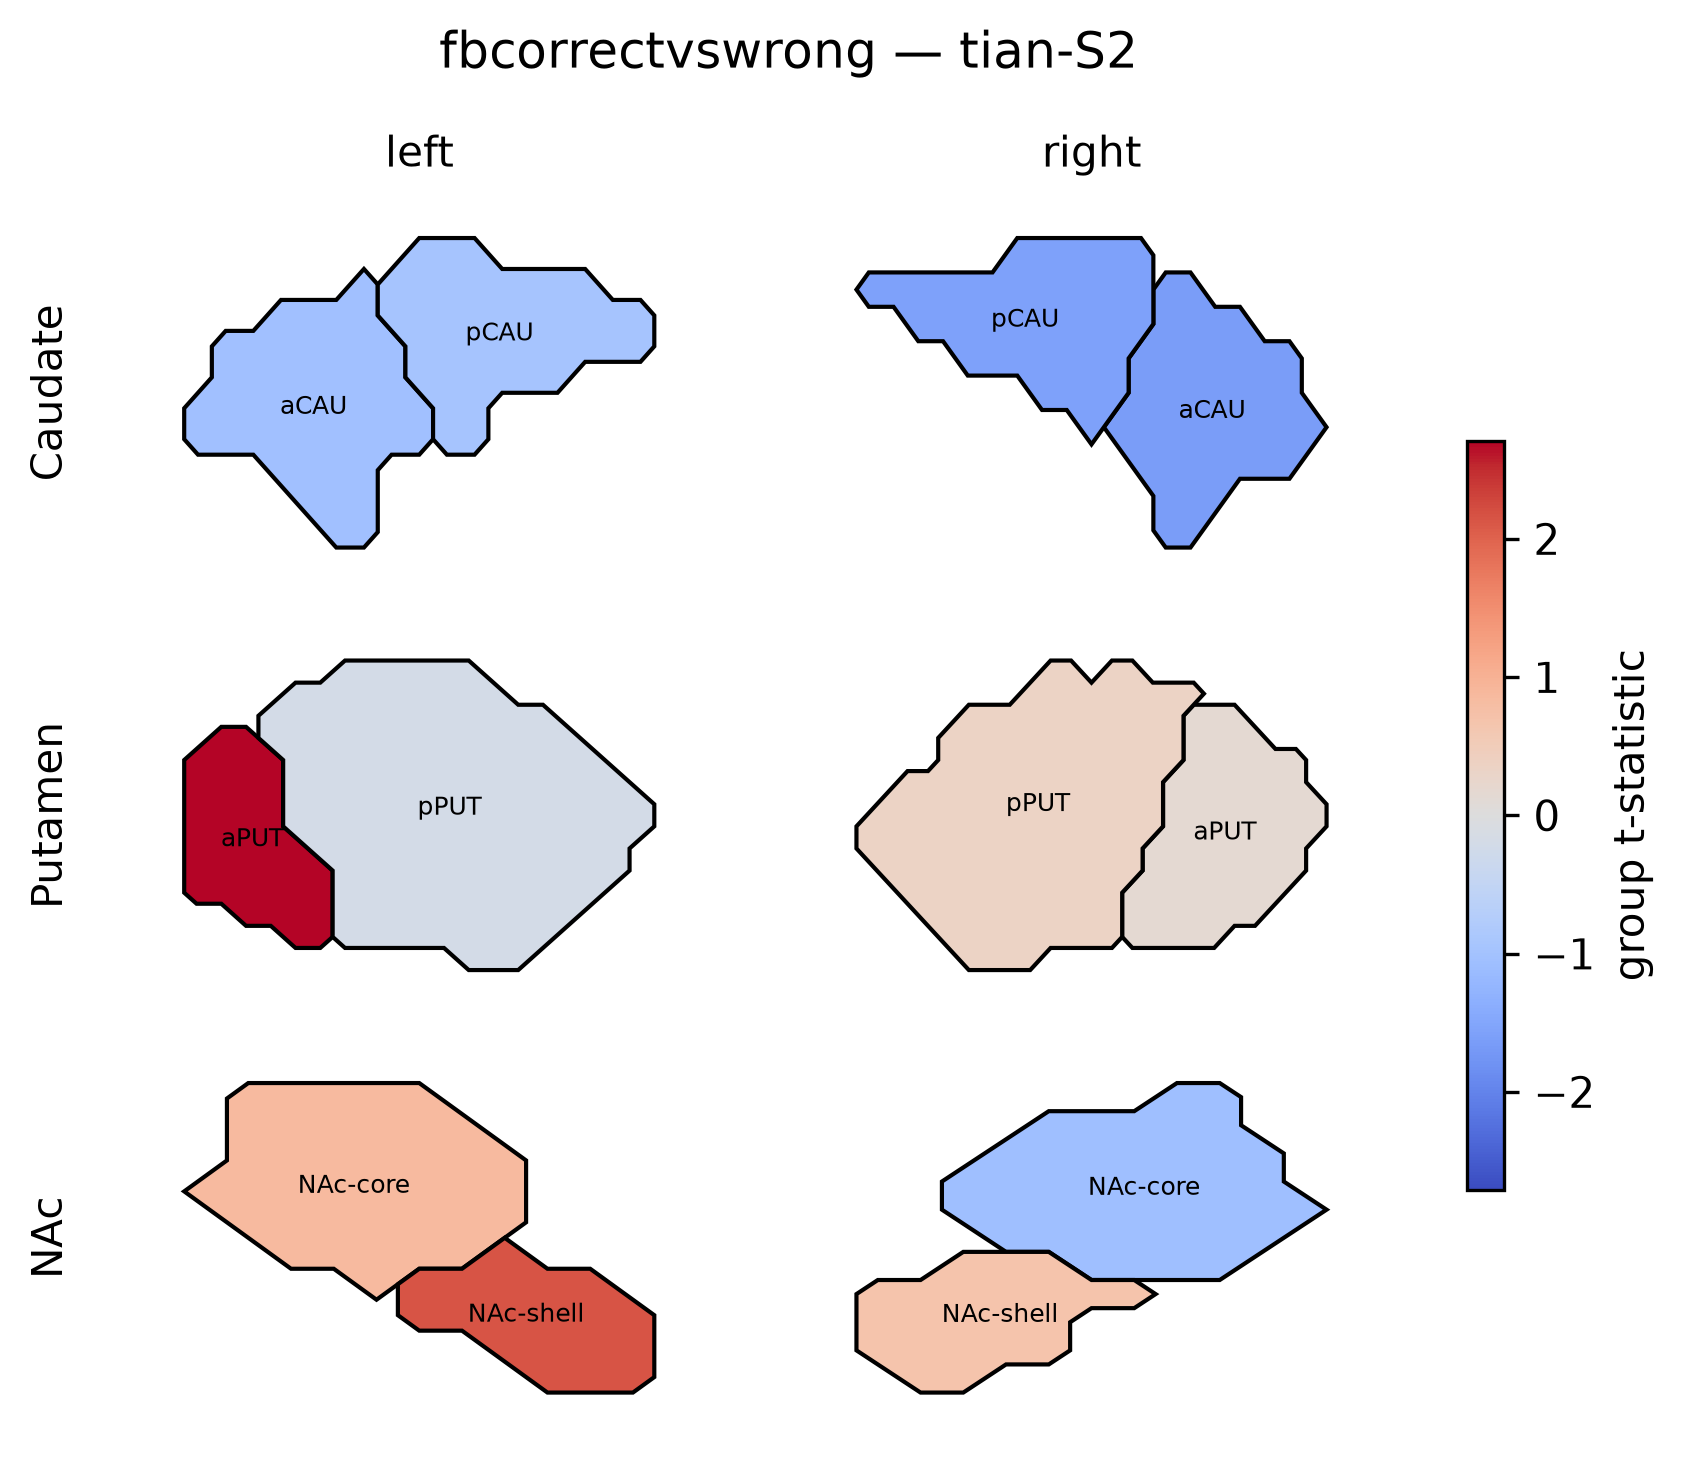

In [192]:
structure_groups = {
    'Caudate': ['aCAU', 'pCAU'],
    'Putamen': ['aPUT', 'pPUT'],
    'NAc': ['NAc-core', 'NAc-shell'],
}
stat_dict = {c[0]: c[1] for c in comparisons}
mask_path_dict = build_mask_path_dict(list(stat_dict.keys()), masks_dir, network_name, space_label)

fig = plot_striatal_roi_stat(stat_dict, mask_path_dict, structure_groups, title=f'{contrast_label} — {network_name}')
fig.savefig(os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_striatal-tstat.svg'))
fig.savefig(os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_striatal-tstat.png'))


### Striatal ROI plot (t-statistic) — yabplot alternative

In [193]:
# Optional alternative: yabplot 3D rendering of the same stat_dict, run via a
# separate cluster conda env ("yabplot", /bgfs/bchandrasekaran/krs228/software/miniconda3/envs/yabplot/bin/python)
# since this notebook's kernel doesn't have yabplot installed. See
# 05_masking/build_yabplot_tian_s2_atlas.py for building the atlas this
# depends on. The next cell runs in that separate environment via %%script;
# this cell just writes it the inputs it needs as JSON since the two
# environments can't share Python objects directly.
import json

yabplot_handoff_path = '/tmp/_yabplot_handoff.json'
yabplot_out_png = os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_striatal-tstat_yabplot.png')

with open(yabplot_handoff_path, 'w') as f:
    json.dump({
        'stat_dict': stat_dict,
        'atlas_dir': os.path.join(os.getcwd(), '..', '05_masking', 'yabplot_atlases', 'tian_S2'),
        'out_png': yabplot_out_png,
        'title': f'{contrast_label} — {network_name}',
    }, f)


In [196]:
%%script /ix1/bchandrasekaran/krs228/software/miniconda3/envs/yabplot/bin/python
import json, sys
with open('/tmp/_yabplot_handoff.json') as f:
    params = json.load(f)

sys.path.insert(0, '..')
from striatal_yabplot import plot_striatal_roi_stat_yabplot

fig = plot_striatal_roi_stat_yabplot(params['stat_dict'], atlas_dir=params['atlas_dir'],
                                      title=params['title'])
fig.savefig(params['out_png'])
print('saved', params['out_png'])


Traceback (most recent call last):
  File "<stdin>", line 6, in <module>
  File "/ihome/bchandrasekaran/krs228/software/auditory_striatal_learning/06_univariate/../striatal_yabplot.py", line 5, in <module>
    import yabplot as yab
ModuleNotFoundError: No module named 'yabplot'


CalledProcessError: Command 'b"import json, sys\nwith open('/tmp/_yabplot_handoff.json') as f:\n    params = json.load(f)\n\nsys.path.insert(0, '..')\nfrom striatal_yabplot import plot_striatal_roi_stat_yabplot\n\nfig = plot_striatal_roi_stat_yabplot(params['stat_dict'], atlas_dir=params['atlas_dir'],\n                                      title=params['title'])\nfig.savefig(params['out_png'])\nprint('saved', params['out_png'])\n"' returned non-zero exit status 1.

In [ ]:
from IPython.display import Image
Image(filename=yabplot_out_png)


### Striatal ROI plot (t-statistic, final vs. early)

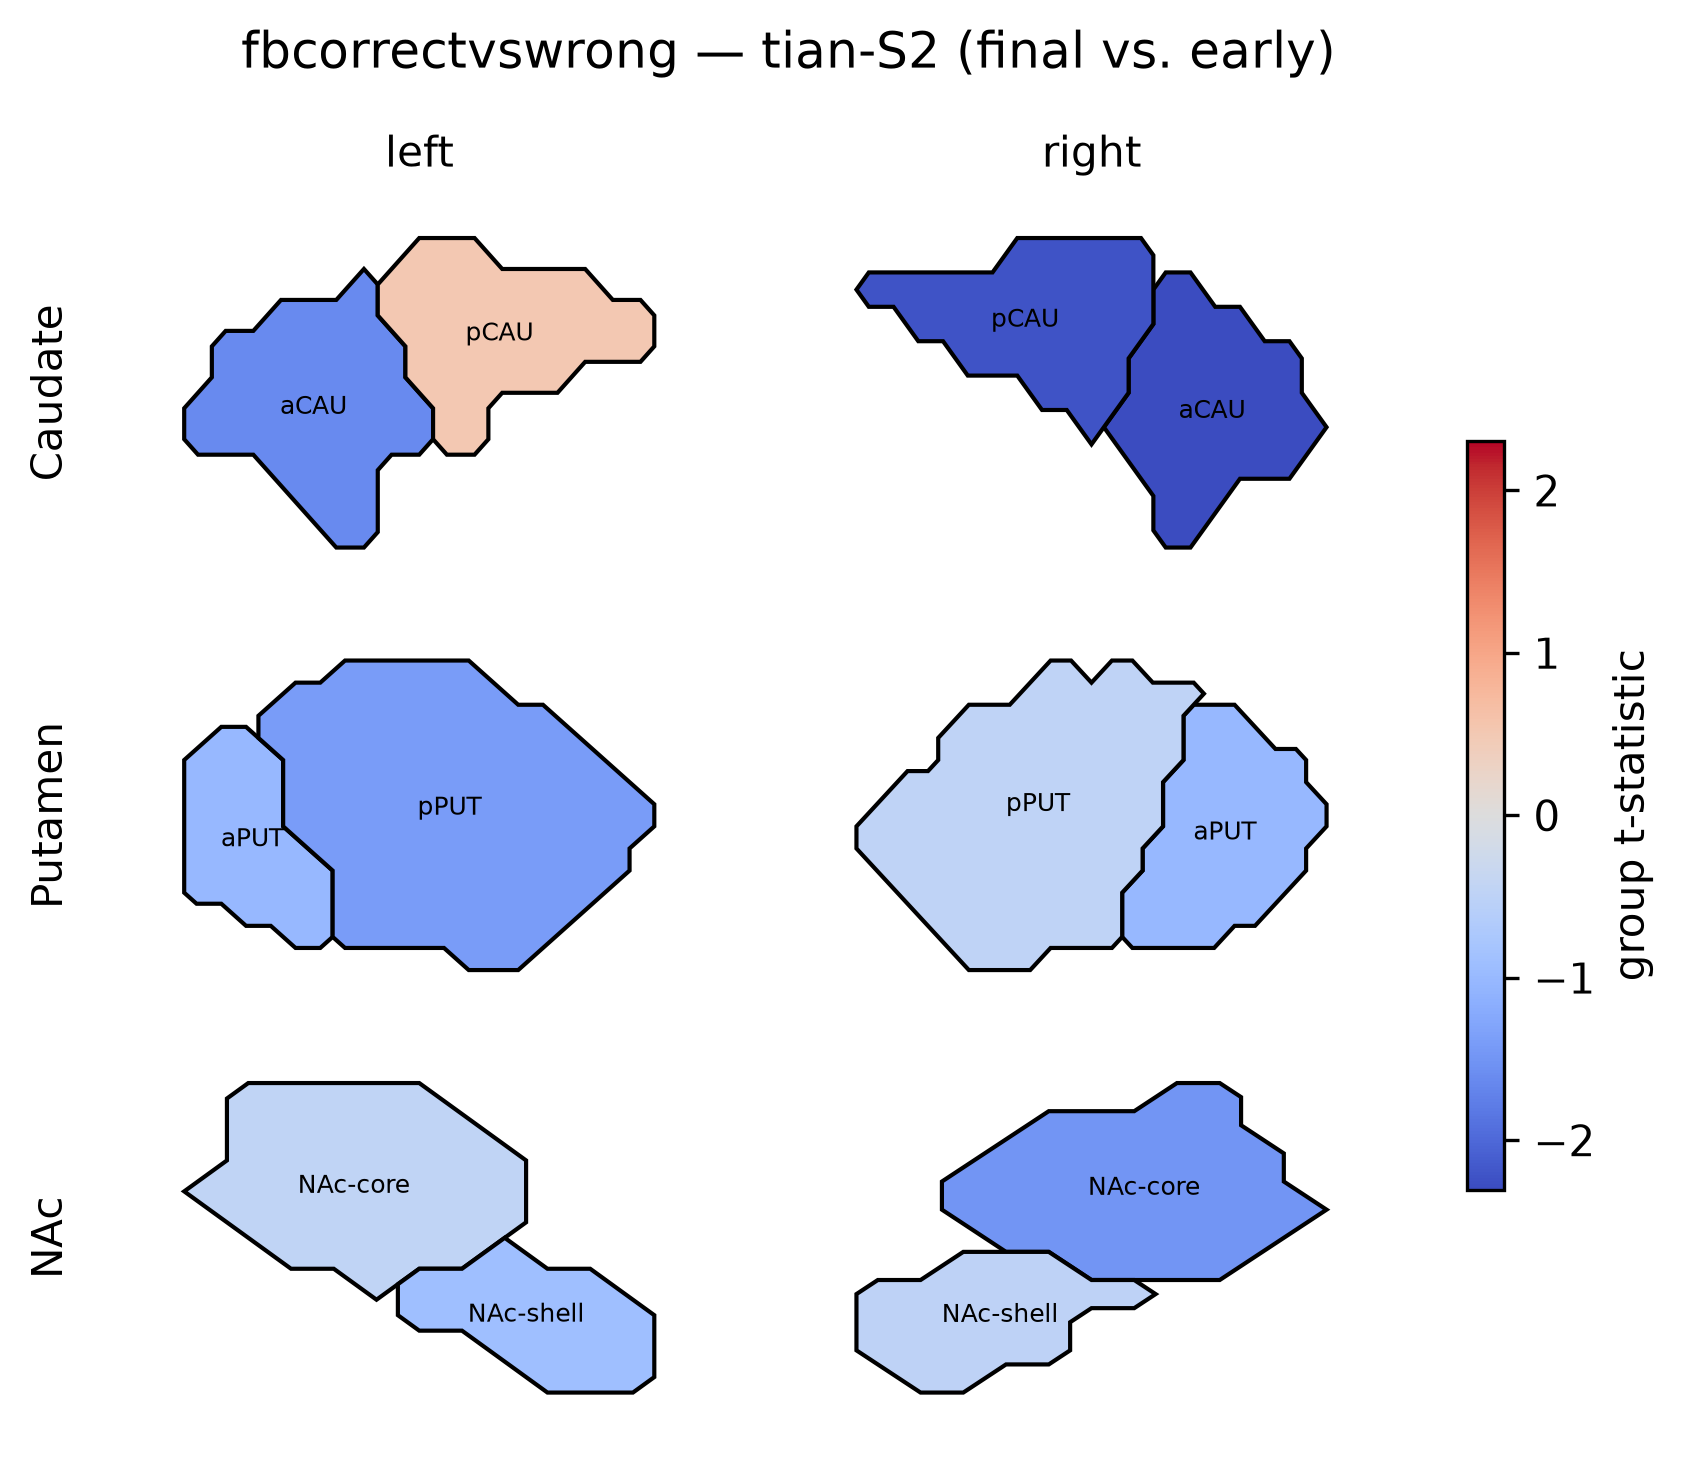

In [197]:
# Learning-stage difference (final vs. early)
_diff_df = (non_mandarin_df[non_mandarin_df['learning_stage'].isin(['early', 'final'])]
            .groupby(['participant_id', 'region_hemi', 'learning_stage'], as_index=False)['beta'].mean()
            .pivot(index=['participant_id', 'region_hemi'], columns='learning_stage', values='beta')
            .dropna()
            .reset_index())

diff_stat_dict = {}
for region_hemi, data in _diff_df.groupby('region_hemi'):
    t_stat, _ = ttest_rel(data['final'], data['early'])
    diff_stat_dict[region_hemi] = t_stat

structure_groups = {
    'Caudate': ['aCAU', 'pCAU'],
    'Putamen': ['aPUT', 'pPUT'],
    'NAc': ['NAc-core', 'NAc-shell'],
}
mask_path_dict_diff = build_mask_path_dict(list(diff_stat_dict.keys()), masks_dir, network_name, space_label)
fig_diff = plot_striatal_roi_stat(diff_stat_dict, mask_path_dict_diff, structure_groups,
                                   title=f'{contrast_label} — {network_name} (final vs. early)')
fig_diff.savefig(os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_striatal-tstat_diff-final-early.svg'))
fig_diff.savefig(os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_striatal-tstat_diff-final-early.png'))


### Striatal ROI plot (t-statistic, final vs. early) — yabplot alternative

In [ ]:
# Optional alternative: yabplot 3D rendering of diff_stat_dict (final vs.
# early), run via the separate cluster conda env ("yabplot",
# /bgfs/bchandrasekaran/krs228/software/miniconda3/envs/yabplot/bin/python)
# since this notebook's kernel doesn't have yabplot installed.
import json

yabplot_handoff_path_diff = '/tmp/_yabplot_handoff_diff.json'
yabplot_out_png_diff = os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_striatal-tstat_diff-final-early_yabplot.png')

with open(yabplot_handoff_path_diff, 'w') as f:
    json.dump({
        'stat_dict': diff_stat_dict,
        'atlas_dir': os.path.join(os.getcwd(), '..', '05_masking', 'yabplot_atlases', 'tian_S2'),
        'out_png': yabplot_out_png_diff,
        'title': f'{contrast_label} — {network_name} (final vs. early)',
    }, f)


In [ ]:
%%script /bgfs/bchandrasekaran/krs228/software/miniconda3/envs/yabplot/bin/python
import json, sys
with open('/tmp/_yabplot_handoff_diff.json') as f:
    params = json.load(f)

sys.path.insert(0, '..')
from striatal_yabplot import plot_striatal_roi_stat_yabplot

fig = plot_striatal_roi_stat_yabplot(params['stat_dict'], atlas_dir=params['atlas_dir'],
                                      title=params['title'])
fig.savefig(params['out_png'])
print('saved', params['out_png'])


In [ ]:
from IPython.display import Image
Image(filename=yabplot_out_png_diff)


## `contrast-fb` for cortical network

In [199]:
# get the beta map for the contrast of interest for each subject
network_name = network_list[0]
contrast_label = contrast_list[2]
event_type = contrast_event_type[contrast_label]
print('network_name:', network_name)
print('contrast_label:', contrast_label)

statmap_earlythird_dict = {}
for sub_id in sub_list_nman:
    statmap_earlythird_dict[sub_id] = sorted(glob(l1_dir+f'/{sub_id}_space-{space_label}/early_event-{event_type}/{sub_id}/*{contrast_label}_stat-effect_statmap.nii.gz'))[0]
    
statmap_middlethird_dict = {}
for sub_id in sub_list_nman:
    statmap_middlethird_dict[sub_id] = sorted(glob(l1_dir+f'/{sub_id}_space-{space_label}/middle_event-{event_type}/{sub_id}/*{contrast_label}_stat-effect_statmap.nii.gz'))[0]
    
statmap_latethird_dict = {}
for sub_id in sub_list_nman:
    statmap_latethird_dict[sub_id] = sorted(glob(l1_dir+f'/{sub_id}_space-{space_label}/final_event-{event_type}/{sub_id}/*{contrast_label}_stat-effect_statmap.nii.gz'))[0]

network_name: auditory
contrast_label: fbcorrectvswrong


In [200]:
# define filepath for saving (once) or loading (afterward)
out_fname = f'univariate-results_network-{network_name}_contrast-{contrast_label}.tsv'
combined_roi_df_fpath = os.path.join(group_out_dir, out_fname)

In [201]:
# mask the stat maps per learning stage by region - ONLY RUN ONCE

print(f'masking {contrast_label} stat maps for the {network_name} network')

print(f'creating dictionary for early learning stage')
roi_earlythird_mean_dict, mask_path_list = mask_stat_maps(region_dict[network_name], 
                                               statmap_earlythird_dict, 
                                               masks_dir, 
                                               network_name,
                                               space_label)

print(f'creating dictionary for middle learning stage')
roi_middlethird_mean_dict, mask_path_list = mask_stat_maps(region_dict[network_name], 
                                               statmap_middlethird_dict, 
                                               masks_dir, 
                                               network_name,
                                               space_label)

print(f'creating dictionary for final learning stage')
roi_latethird_mean_dict, mask_path_list = mask_stat_maps(region_dict[network_name], 
                                               statmap_latethird_dict, 
                                               masks_dir, 
                                               network_name,
                                               space_label)

# add `learning_stage` column and combine into single dataframe
roi_earlythird_df_long = make_stats_df(roi_earlythird_mean_dict, participants_nman_df, network_name)
roi_earlythird_df_long['learning_stage'] = 'early'
roi_middlethird_df_long = make_stats_df(roi_middlethird_mean_dict, participants_nman_df, network_name)
roi_middlethird_df_long['learning_stage'] = 'middle'
roi_latethird_df_long = make_stats_df(roi_latethird_mean_dict, participants_nman_df, network_name)
roi_latethird_df_long['learning_stage'] = 'final'

# combine into a single long dataframe
roi_df_long = pd.concat([roi_earlythird_df_long, roi_middlethird_df_long, roi_latethird_df_long],)

# save the DataFrame for easier access
roi_df_long.to_csv(combined_roi_df_fpath, sep='\t', index=False)


masking fbcorrectvswrong stat maps for the auditory network
creating dictionary for early learning stage
L-HG
/ix1/bchandrasekaran/krs228/data/FLT/data_denoised/derivatives/nilearn/masks/sub-FLT02/space-T1w/masks-dseg/sub-FLT02_space-T1w_mask-L-HG.nii.gz
/ix1/bchandrasekaran/krs228/data/FLT/data_denoised/derivatives/nilearn/masks/sub-FLT04/space-T1w/masks-dseg/sub-FLT04_space-T1w_mask-L-HG.nii.gz
/ix1/bchandrasekaran/krs228/data/FLT/data_denoised/derivatives/nilearn/masks/sub-FLT06/space-T1w/masks-dseg/sub-FLT06_space-T1w_mask-L-HG.nii.gz
/ix1/bchandrasekaran/krs228/data/FLT/data_denoised/derivatives/nilearn/masks/sub-FLT09/space-T1w/masks-dseg/sub-FLT09_space-T1w_mask-L-HG.nii.gz
/ix1/bchandrasekaran/krs228/data/FLT/data_denoised/derivatives/nilearn/masks/sub-FLT11/space-T1w/masks-dseg/sub-FLT11_space-T1w_mask-L-HG.nii.gz
/ix1/bchandrasekaran/krs228/data/FLT/data_denoised/derivatives/nilearn/masks/sub-FLT12/space-T1w/masks-dseg/sub-FLT12_space-T1w_mask-L-HG.nii.gz
/ix1/bchandrasekaran

In [202]:
# load the DataFrame if already exists
roi_df_long = pd.read_csv(combined_roi_df_fpath, sep='\t')

# create a bilateral-averaged dataframe (for across-contrast analysis)
feedback_cortex_df = bilateral_mean(roi_df_long)


In [203]:
roi_df_long.participant_id.unique()

<StringArray>
['sub-FLT02', 'sub-FLT04', 'sub-FLT06', 'sub-FLT09', 'sub-FLT11', 'sub-FLT12',
 'sub-FLT13', 'sub-FLT14', 'sub-FLT25', 'sub-FLT28', 'sub-FLT30']
Length: 11, dtype: str

In [204]:
roi_df_long.region.unique()

<StringArray>
['HG', 'PT', 'PP', 'STGp', 'STGa', 'ParsOp', 'ParsTri']
Length: 7, dtype: str

In [205]:
non_mandarin_df = roi_df_long

In [206]:
plot_order = ['HG', 'PT', 'PP', 'STGp', 'STGa', 'ParsOp', 'ParsTri', ]

/scratch/slurm-10971702/ipykernel_1708492/2201273681.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')


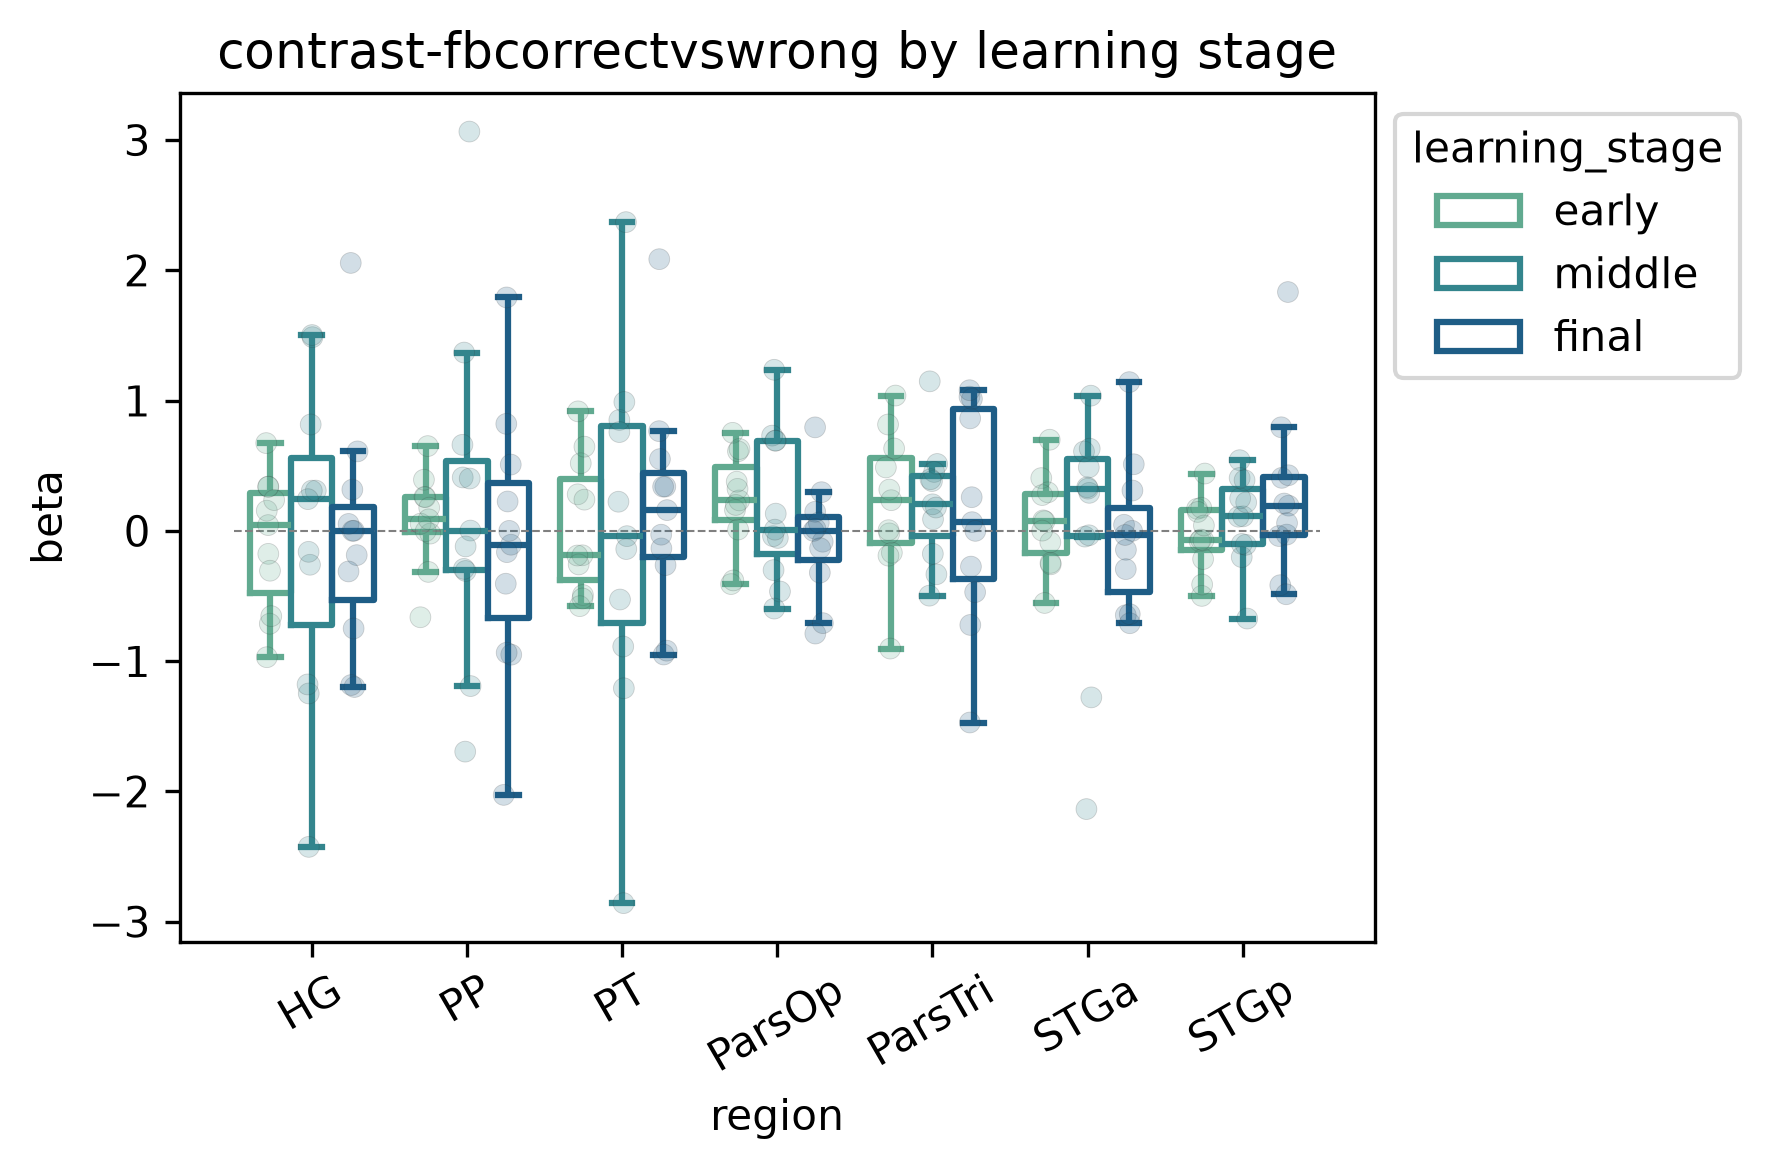

In [207]:
fig, ax = plt.subplots(1, 1, figsize=(6,4), dpi=300)

roi_df_collapsed = roi_df_long.groupby(["participant_id", "region", 'learning_stage'], 
                                       as_index=False).agg({"beta": "mean"})

sns.boxplot(data=roi_df_collapsed, 
              x='region', y='beta', 
              hue='learning_stage', hue_order=['early', 'middle', 'final'],
              palette='crest',
              fliersize = 0,            
              linewidth=1.5,
              fill=False,
              #legend=None,
              ax=ax);
sns.stripplot(data=roi_df_collapsed, 
              x='region', y='beta', 
              hue='learning_stage', hue_order=['early', 'middle', 'final'],
              palette='crest',
              dodge=True,
              linewidth=0.2,
              alpha=.2,
              legend=None,
              ax=ax);


xmin, xmax = ax.get_xlim()
ax.hlines(y=0, xmin=xmin, xmax=xmax, color='0.5', linestyle='--', linewidth=0.5)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title(f'contrast-{contrast_label} by learning stage');
#ax.set_ylim([-5, 5])

fig.tight_layout()

fig.savefig(os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_boxplot-stage.svg'))
fig.savefig(os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_boxplot-stage.png'))

### Brain-behavior correlations

In [208]:
# map runs to learning stages matching your thirds
stage_map = {'run-01': 'early', 'run-02': 'early',
             'run-03': 'middle', 'run-04': 'middle',
             'run-05': 'final', 'run-06': 'final'}

acc_df['learning_stage'] = acc_df['run'].map(stage_map)
acc_stage_df = acc_df.groupby(['participant_id', 'learning_stage'])['accuracy'].mean().reset_index()

In [209]:
# merge into roi_df_long — assumes participant_id and learning_stage columns exist in both
roi_df_bilateral = (roi_df_long.groupby(['participant_id', 'region', 'learning_stage'], as_index=False)['beta'].mean())
roi_behav_df = roi_df_bilateral.merge(acc_stage_df, on=['participant_id', 'learning_stage'])

# verify
roi_behav_df.groupby(['region', 'learning_stage']).size().unique()  # should be array([12])


array([11])

In [210]:
results = []
for stage in ['early', 'middle', 'final']:
    stage_df = roi_behav_df[roi_behav_df['learning_stage'] == stage]
    for roi in plot_order: # stage_df['region'].unique():
        sub_df = stage_df[stage_df['region'] == roi]
        r = pg.corr(sub_df['accuracy'], sub_df['beta'], method='pearson')
        results.append({
            'roi': roi,
            'learning_stage': stage,
            'r': r['r'].values[0],
            'p': r['p_val'].values[0],
            'n': r['n'].values[0],
            'stat_str': stat_str('r', r['r'].values[0], r['p_val'].values[0])
        })

behav_corr_df = pd.DataFrame(results)

In [211]:
behav_corr_df

,roi,learning_stage,r,p,n,stat_str
0,HG,early,0.4001,0.2228,11,"r = .40, p = .223"
1,PT,early,0.6692,0.0243,11,"r = .67, p = .024"
2,PP,early,0.2746,0.4137,11,"r = .27, p = .414"
3,STGp,early,-0.2293,0.4976,11,"r = -.23, p = .498"
4,STGa,early,-0.3546,0.2847,11,"r = -.35, p = .285"
5,ParsOp,early,-0.2839,0.3975,11,"r = -.28, p = .398"
6,ParsTri,early,-0.2295,0.4972,11,"r = -.23, p = .497"
7,HG,middle,-0.3799,0.2491,11,"r = -.38, p = .249"
8,PT,middle,-0.4432,0.1722,11,"r = -.44, p = .172"
9,PP,middle,0.0744,0.8278,11,"r = .07, p = .828"


In [212]:
multipletests(behav_corr_df["p"], method="fdr_bh")

(array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False]),
 array([0.66419811, 0.51080136, 0.6966125 , 0.6966125 , 0.66419811,
        0.6966125 , 0.6966125 , 0.66419811, 0.66419811, 0.82778909,
        0.66419811, 0.66419811, 0.82303556, 0.702818  , 0.66419811,
        0.66419811, 0.82303556, 0.702818  , 0.80459187, 0.6966125 ,
        0.6966125 ]),
 np.float64(0.002439557259668823),
 0.002380952380952381)

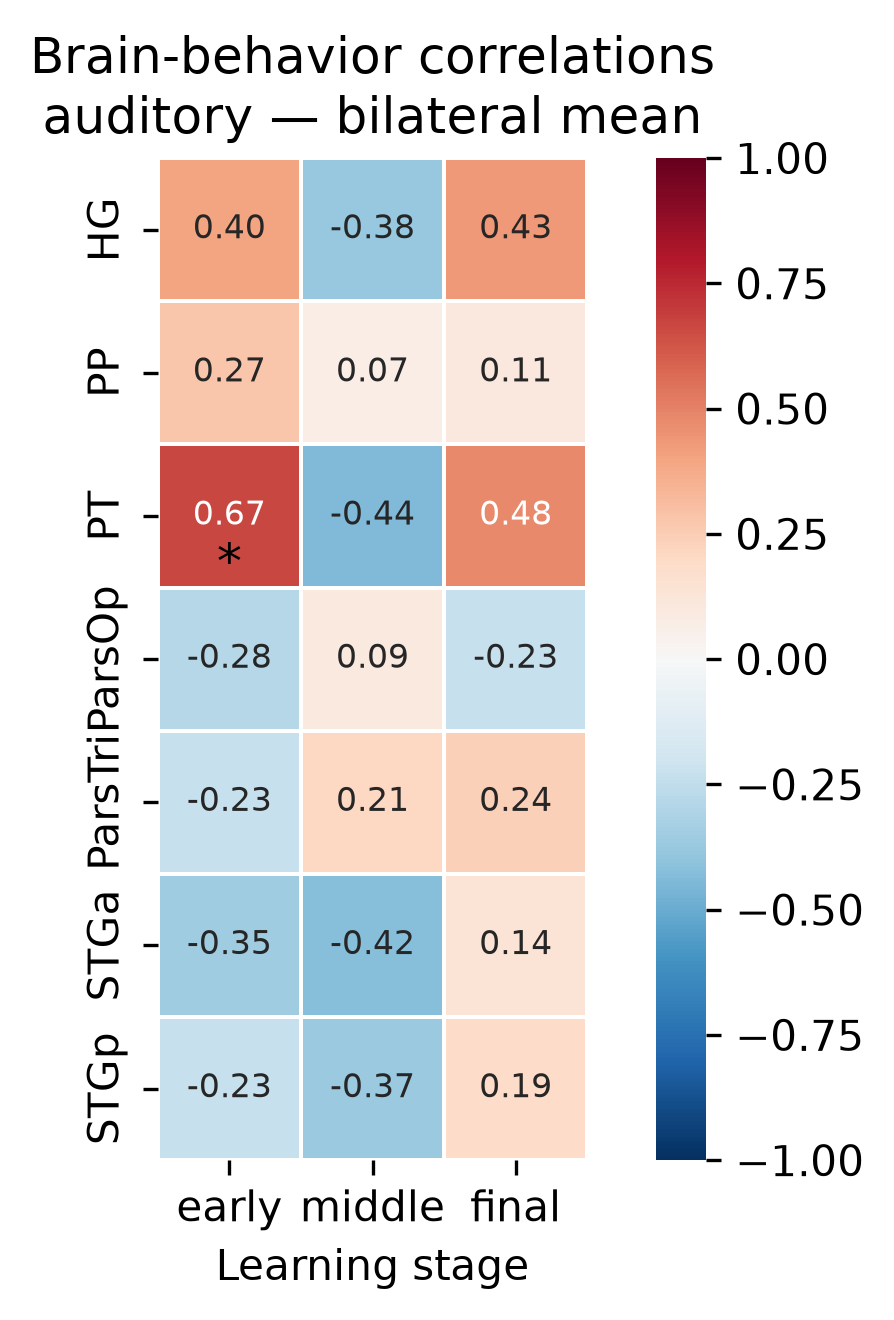

In [213]:
# pivot to ROI × stage matrix
r_matrix = behav_corr_df.pivot(index='roi', columns='learning_stage', values='r')[['early', 'middle', 'final']]
p_matrix = behav_corr_df.pivot(index='roi', columns='learning_stage', values='p')[['early', 'middle', 'final']]

fig, ax = plt.subplots(figsize=(5, len(r_matrix) * 0.5 + 1), dpi=300)
sns.heatmap(r_matrix, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, annot=True, fmt='.2f', annot_kws={'size': 8},
            square=True)

# mark significant cells with an asterisk
for i, roi in enumerate(r_matrix.index):
    for j, stage in enumerate(['early', 'middle', 'final']):
        p = p_matrix.loc[roi, stage]
        if p < 0.05:
            ax.text(j + 0.5, i + 0.85, '*', ha='center', va='center',
                    fontsize=12, color='black')

ax.set_title(f'Brain-behavior correlations\n{network_name} — bilateral mean')
ax.set_ylabel('')
ax.set_xlabel('Learning stage')
plt.tight_layout()
plt.savefig(os.path.join(fig_out_dir, f'brain-behav-corr_contrast-{contrast_label}_network-{network_name}_heatmap.svg'))

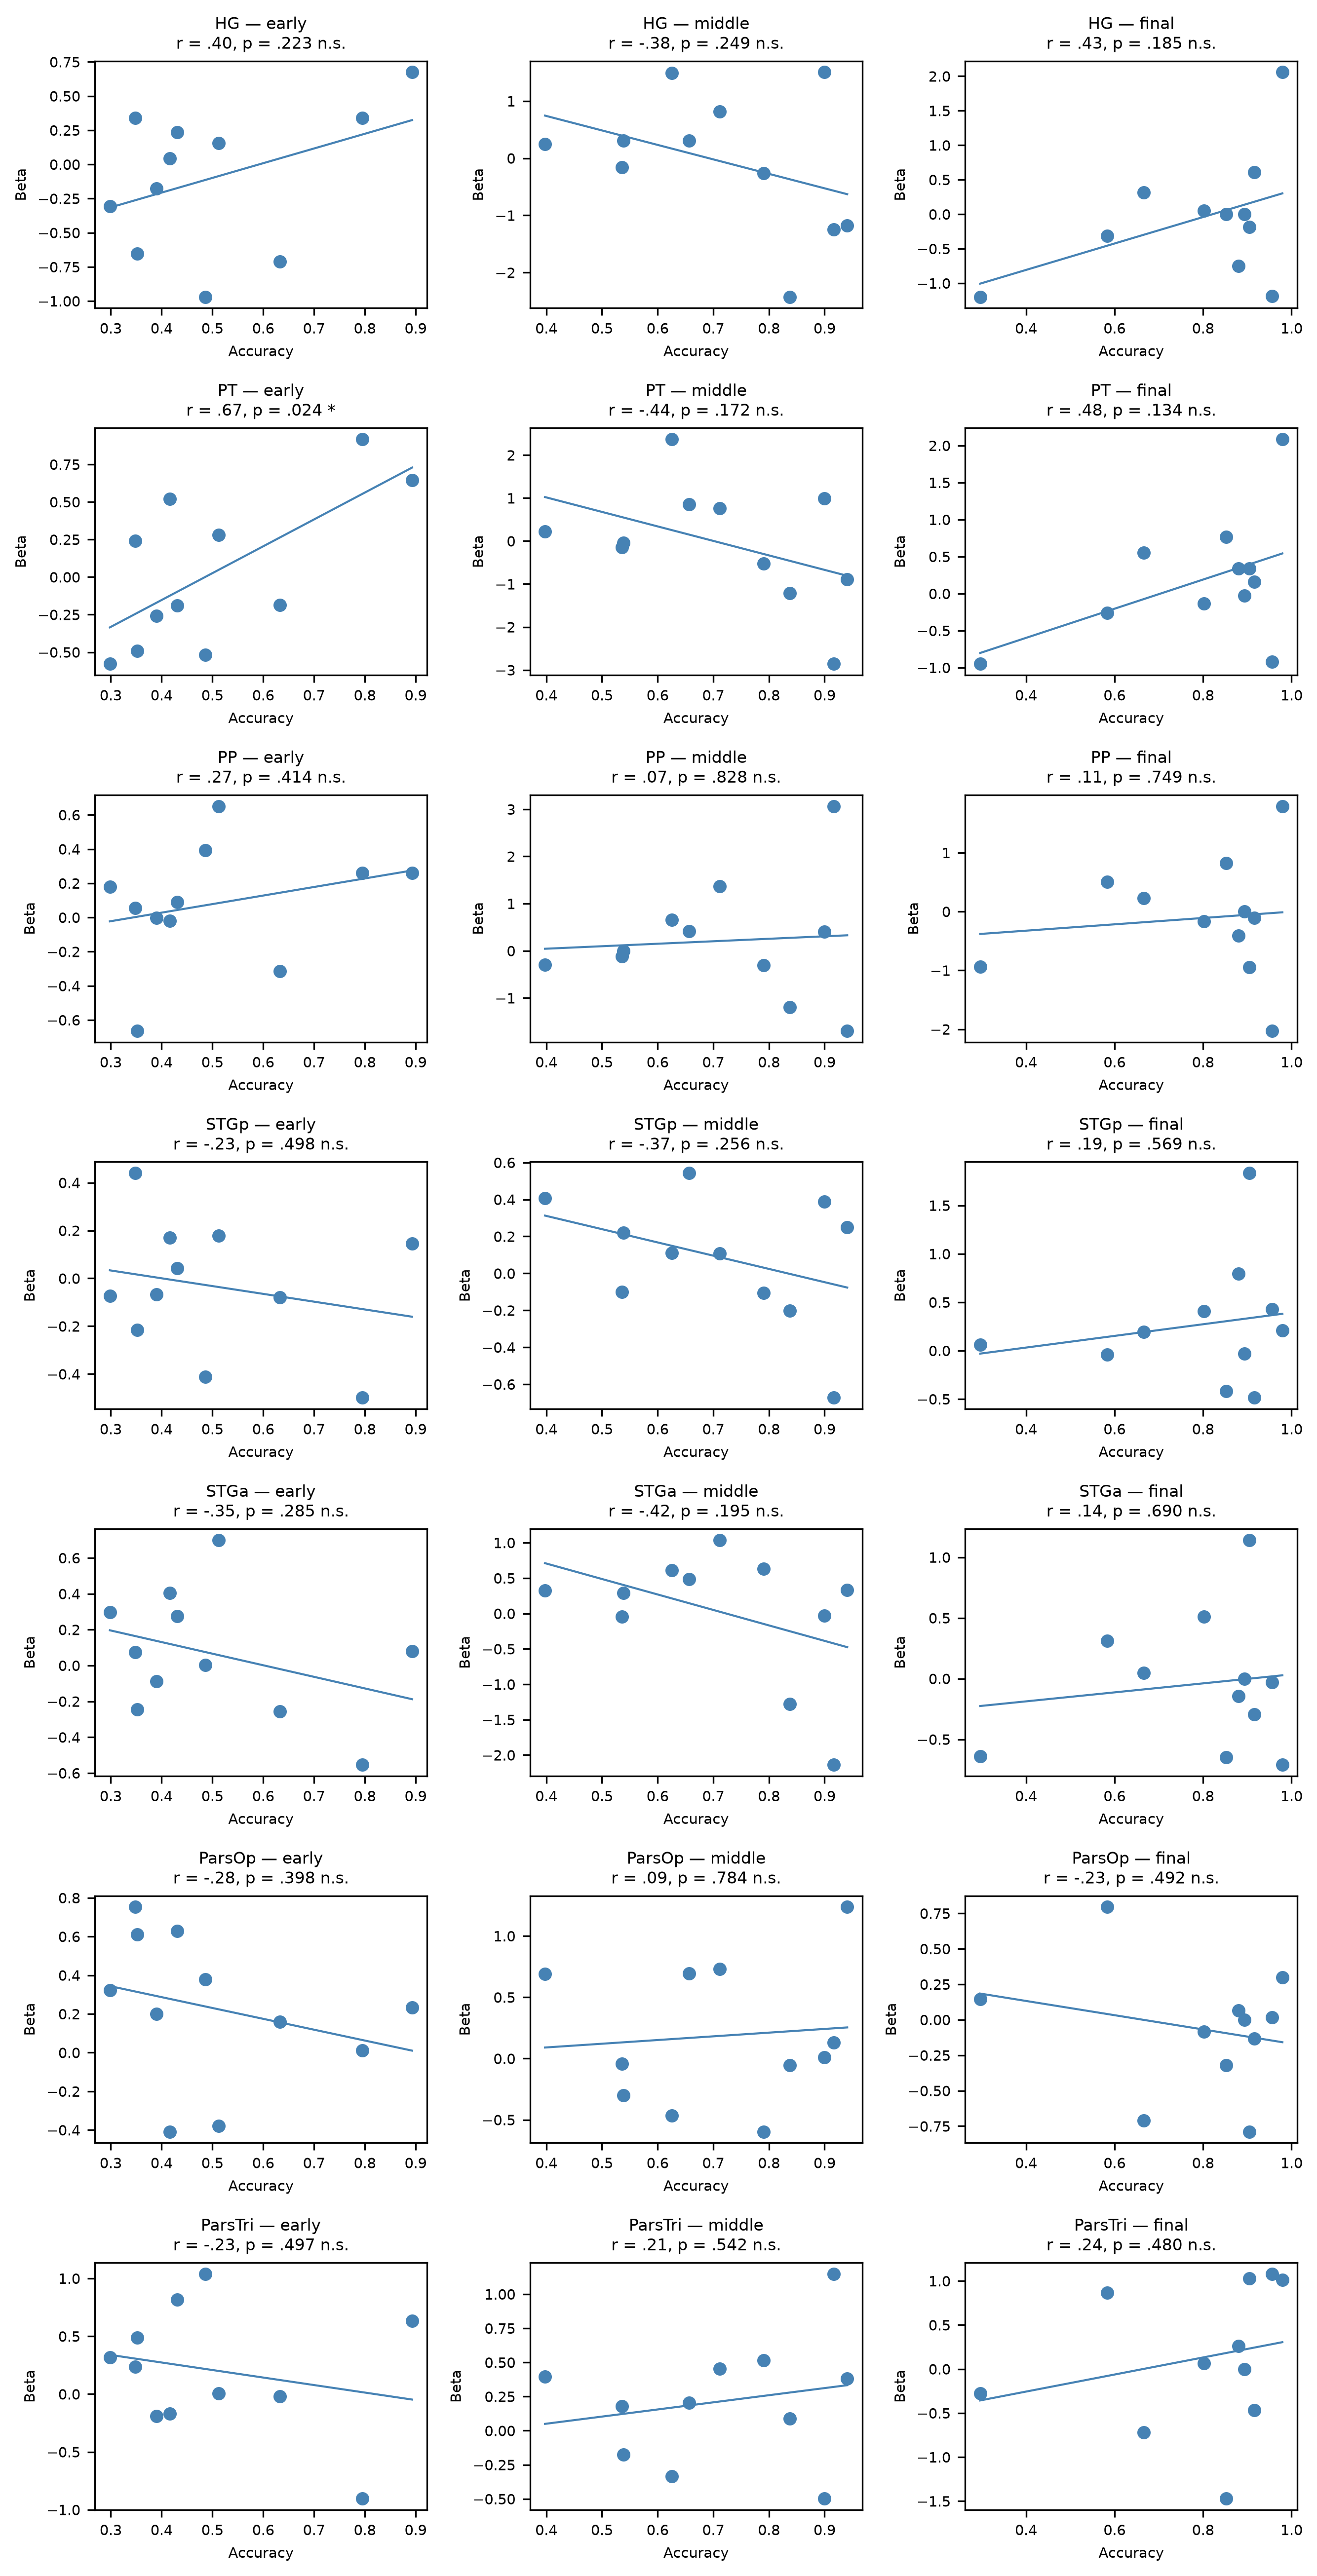

In [214]:
rois = behav_corr_df['roi'].unique()
stages = ['early', 'middle', 'final']

fig, axes = plt.subplots(len(rois), 3, figsize=(9, len(rois) * 2.5), dpi=300, sharex=False, sharey=False)

for ri, roi in enumerate(plot_order): # rois):
    for si, stage in enumerate(stages):
        ax = axes[ri, si]
        sub_df = roi_behav_df[(roi_behav_df['region'] == roi) & 
                              (roi_behav_df['learning_stage'] == stage)]
        
        ax.scatter(sub_df['accuracy'], sub_df['beta'], s=30, color='steelblue', zorder=3)
        
        # regression line
        m, b = np.polyfit(sub_df['accuracy'], sub_df['beta'], 1)
        x_range = np.linspace(sub_df['accuracy'].min(), sub_df['accuracy'].max(), 100)
        ax.plot(x_range, m * x_range + b, color='steelblue', linewidth=1)
        
        # stat annotation
        row = behav_corr_df[(behav_corr_df['roi'] == roi) & 
                            (behav_corr_df['learning_stage'] == stage)].iloc[0]
        p_str = '*' if row['p'] < 0.05 else 'n.s.'
        ax.set_title(f"{roi} — {stage}\n{row['stat_str']} {p_str}", fontsize=8)
        ax.set_xlabel('Accuracy', fontsize=7)
        ax.set_ylabel('Beta', fontsize=7)
        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig(os.path.join(fig_out_dir, f'brain-behav-corr_contrast-{contrast_label}_network-{network_name}_corr-plots.svg'))

HG early: r = .40, p = .223 n.s.
HG middle: r = -.38, p = .249 n.s.
HG final: r = .43, p = .185 n.s.
PT early: r = .67, p = .024 *
PT middle: r = -.44, p = .172 n.s.
PT final: r = .48, p = .134 n.s.
PP early: r = .27, p = .414 n.s.
PP middle: r = .07, p = .828 n.s.
PP final: r = .11, p = .749 n.s.
STGp early: r = -.23, p = .498 n.s.
STGp middle: r = -.37, p = .256 n.s.
STGp final: r = .19, p = .569 n.s.
STGa early: r = -.35, p = .285 n.s.
STGa middle: r = -.42, p = .195 n.s.
STGa final: r = .14, p = .690 n.s.
ParsOp early: r = -.28, p = .398 n.s.
ParsOp middle: r = .09, p = .784 n.s.
ParsOp final: r = -.23, p = .492 n.s.
ParsTri early: r = -.23, p = .497 n.s.
ParsTri middle: r = .21, p = .542 n.s.
ParsTri final: r = .24, p = .480 n.s.


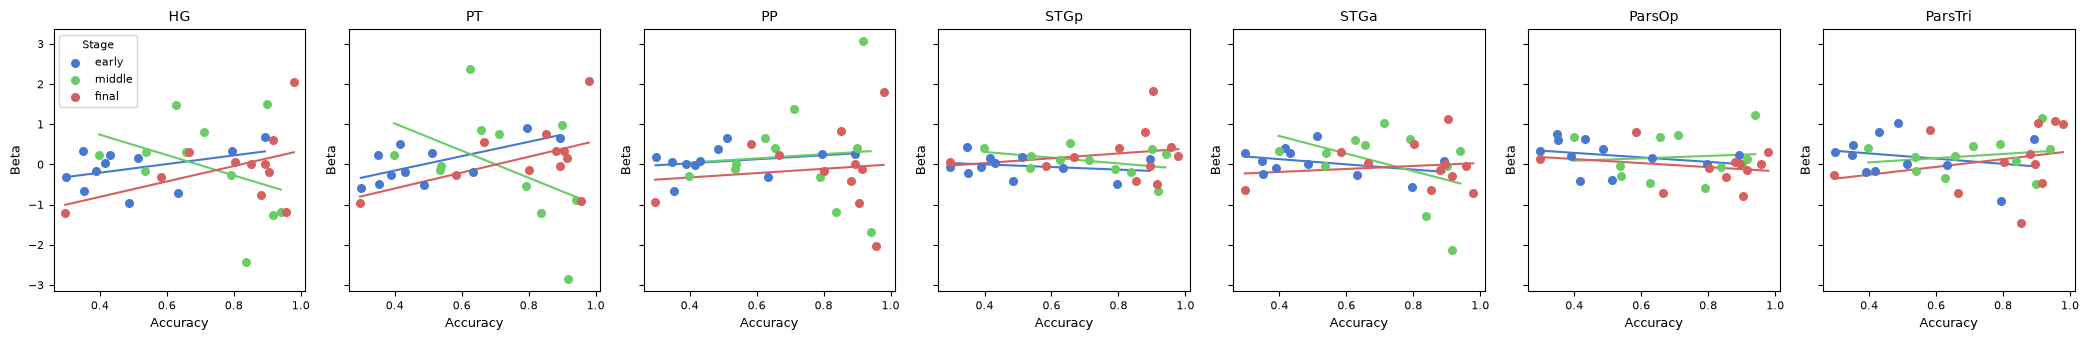

In [215]:
stage_colors = {'early': '#4878CF', 'middle': '#6ACC65', 'final': '#D65F5F'}
stages = ['early', 'middle', 'final']
rois = plot_order # behav_corr_df['roi'].unique()

fig, axes = plt.subplots(1, len(rois), figsize=(3 * len(rois), 3.5), dpi=100, sharey=True)
if len(rois) == 1:
    axes = [axes]

for ri, roi in enumerate(rois):
    ax = axes[ri]
    for stage in stages:
        color = stage_colors[stage]
        sub_df = roi_behav_df[(roi_behav_df['region'] == roi) &
                              (roi_behav_df['learning_stage'] == stage)]

        ax.scatter(sub_df['accuracy'], sub_df['beta'], s=30,
                   color=color, label=stage, zorder=3)

        m, b = np.polyfit(sub_df['accuracy'], sub_df['beta'], 1)
        x_range = np.linspace(sub_df['accuracy'].min(), sub_df['accuracy'].max(), 100)
        ax.plot(x_range, m * x_range + b, color=color, linewidth=1.5)

        # stat annotation per stage
        row = behav_corr_df[(behav_corr_df['roi'] == roi) &
                            (behav_corr_df['learning_stage'] == stage)].iloc[0]
        p_str = '*' if row['p'] < 0.05 else 'n.s.'
        print(f"{roi} {stage}: {row['stat_str']} {p_str}")

    ax.set_title(roi, fontsize=10)
    ax.set_xlabel('Accuracy', fontsize=9)
    ax.set_ylabel('Beta', fontsize=9)
    ax.tick_params(labelsize=8)

axes[0].legend(title='Stage', fontsize=8, title_fontsize=8)
plt.tight_layout()


### omnibus ANOVA stats

In [216]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import AnovaRM

# Mixed-Effects ANOVA with Hemisphere, Region, and Interaction
aov = AnovaRM(non_mandarin_df, 
              aggregate_func='mean',
              depvar='beta', 
              subject='participant_id', 
              within=['hemisphere', 'learning_stage','region', ]).fit()

# Display results
print('network:', network_name)
print('contrast:', contrast_label)
print(aov)


network: auditory
contrast: fbcorrectvswrong
                             Anova
                                 F Value  Num DF  Den DF  Pr > F
----------------------------------------------------------------
hemisphere                        0.1173  1.0000  10.0000 0.7390
learning_stage                    0.0333  2.0000  20.0000 0.9673
region                            0.4358  6.0000  60.0000 0.8521
hemisphere:learning_stage         1.2459  2.0000  20.0000 0.3091
hemisphere:region                 0.8296  6.0000  60.0000 0.5517
learning_stage:region             0.3321 12.0000 120.0000 0.9819
hemisphere:learning_stage:region  0.8326 12.0000 120.0000 0.6168



In [217]:
aov.summary().tables[0]

,F Value,Num DF,Den DF,Pr > F
hemisphere,0.1173,1.0000,10.0000,0.7390
learning_stage,0.0333,2.0000,20.0000,0.9673
region,0.4358,6.0000,60.0000,0.8521
hemisphere:learning_stage,1.2459,2.0000,20.0000,0.3091
hemisphere:region,0.8296,6.0000,60.0000,0.5517
learning_stage:region,0.3321,12.0000,120.0000,0.9819
hemisphere:learning_stage:region,0.8326,12.0000,120.0000,0.6168


In [218]:
# GG-corrected bilateral replication (learning_stage x region)
bilateral_df = (non_mandarin_df
                .groupby(['participant_id', 'region', 'learning_stage'], as_index=False)['beta']
                .mean())
aov_pg = pg.rm_anova(data=bilateral_df, dv='beta',
                     within=['learning_stage', 'region'],
                     subject='participant_id',
                     detailed=True)
eta_col = 'np2' if 'np2' in aov_pg.columns else 'ng2'
print(aov_pg[['Source', 'F', 'ddof1', 'ddof2', 'p_unc', 'p_GG_corr', eta_col]])
export_pg_anova(aov_pg, f'{contrast_label}_{network_name}_learning-stage_region_bilateral', stats_out_dir)

/ix1/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.14/site-packages/pingouin/distribution.py:514: UserWarning: Epsilon values might be innaccurate in two-way repeated measures design where each  factor has more than 2 levels. Please  double-check your results.
  warnings.warn(


                    Source      F  ddof1  ddof2  p_unc  p_GG_corr    ng2
0           learning_stage 0.0333      2     20 0.9673     0.9195 0.0007
1                   region 0.4358      6     60 0.8521     0.7324 0.0105
2  learning_stage * region 0.3321     12    120 0.9819     0.7657 0.0163


,source,df_num,df_den,F,p_unc,p_GG_corr,eta_p2,stat_str
0,learning_stage,2,20,0.03,p = .967,p = .920,0.00,"F(2, 20) = 0.03, p = .920"
1,region,6,60,0.44,p = .852,p = .732,0.01,"F(6, 60) = 0.44, p = .732"
2,learning_stage * region,12,120,0.33,p = .982,p = .766,0.02,"F(12, 120) = 0.33, p = .766"


In [219]:
# pairwise by region, no learning stage

# Pairwise comparisons for region with FDR correction
pairwise_by_region_only = pg.pairwise_tests(data=non_mandarin_df,
                             dv='beta', 
                             within=['learning_stage', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_region_only.columns)

# Display key columns (without 'effsize' and 'CIs' if missing)
print("\nPost-hoc Pairwise Comparisons:")
#print(pairwise_by_region_only)
pairwise_by_region_only[['Contrast', 'Contrast', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]  # Keep only available columns


Available columns: Index(['Contrast', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof', 'alternative',
       'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='str')

Post-hoc Pairwise Comparisons:


,Contrast,Contrast,A,B,T,dof,p_unc,p_corr,BF10
0,learning_stage,learning_stage,early,final,0.1896,10.0000,0.8534,0.9002,0.302
1,learning_stage,learning_stage,early,middle,-0.1287,10.0000,0.9002,0.9002,0.3
2,learning_stage,learning_stage,final,middle,-0.1987,10.0000,0.8464,0.9002,0.303


In [220]:
export_posthoc(pairwise_by_region_only, f'{contrast_label}_{network_name}_learning-stage', stats_out_dir)

,Contrast,A,B,t,df,p,p_fdr,stat_str,stat_str_fdr
0,learning_stage,early,final,0.19,10.0000,p = .853,p = .900,"t(10) = 0.19, p = .853","t(10) = 0.19, q = .900"
1,learning_stage,early,middle,-0.13,10.0000,p = .900,p = .900,"t(10) = -0.13, p = .900","t(10) = -0.13, q = .900"
2,learning_stage,final,middle,-0.20,10.0000,p = .846,p = .900,"t(10) = -0.20, p = .846","t(10) = -0.20, q = .900"


### Collapse (average) over non-significant factors

In [221]:
roi_df_collapsed = roi_df_long.groupby(["participant_id", "region", 'learning_stage'], 
                                       as_index=False).agg({"beta": "mean"})


In [222]:
from statsmodels.stats.multitest import multipletests
from scipy.stats import ttest_1samp


# Collect p-values
p_values = []
t_stats = []
comparisons = []

for region_stage, data in roi_df_collapsed.groupby(["region",'learning_stage']):
    #print(region_stage)
    t_stat, p_val = ttest_1samp(data["beta"], 0)
    p_values.append(p_val)
    comparisons.append((region_stage[0], region_stage[1], t_stat))
    t_stats.append(t_stat)

# Apply FDR correction
_, p_corrected, _, _ = multipletests(p_values, method='fdr_bh')

# Print corrected results
for (region, stage, t_stat), p_val_corr in zip(comparisons, p_corrected):
    print(f"Region: {region}, stage: {stage}, t = {t_stat:.2f}; corrected p = {p_val_corr:.4f}")


Region: HG, stage: early, t = -0.60; corrected p = 0.9430
Region: HG, stage: final, t = -0.20; corrected p = 0.9430
Region: HG, stage: middle, t = -0.15; corrected p = 0.9430
Region: PP, stage: early, t = 0.76; corrected p = 0.9430
Region: PP, stage: final, t = -0.37; corrected p = 0.9430
Region: PP, stage: middle, t = 0.55; corrected p = 0.9430
Region: PT, stage: early, t = 0.22; corrected p = 0.9430
Region: PT, stage: final, t = 0.70; corrected p = 0.9430
Region: PT, stage: middle, t = -0.10; corrected p = 0.9430
Region: ParsOp, stage: early, t = 1.99; corrected p = 0.9430
Region: ParsOp, stage: final, t = -0.49; corrected p = 0.9430
Region: ParsOp, stage: middle, t = 1.06; corrected p = 0.9430
Region: ParsTri, stage: early, t = 1.25; corrected p = 0.9430
Region: ParsTri, stage: final, t = 0.50; corrected p = 0.9430
Region: ParsTri, stage: middle, t = 1.57; corrected p = 0.9430
Region: STGa, stage: early, t = 0.59; corrected p = 0.9430
Region: STGa, stage: final, t = -0.25; corrected

In [223]:
# Collect p-values
p_values = []
t_stats = []
comparisons = []

for region, data in roi_df_collapsed.groupby(["region"]):
    t_stat, p_val = ttest_1samp(data["beta"], 0)
    p_values.append(p_val)
    comparisons.append((region[0], t_stat))
    t_stats.append(t_stat)

# Apply FDR correction
_, p_corrected, _, _ = multipletests(p_values, method='fdr_bh')

# Print corrected results
for (region, t_stat), p_val_corr in zip(comparisons, p_corrected):
    print(f"Region: {region}, t = {t_stat:.2f}; corrected p = {p_val_corr:.4f}")


Region: HG, t = -0.44; corrected p = 0.8562
Region: PP, t = 0.36; corrected p = 0.8562
Region: PT, t = 0.34; corrected p = 0.8562
Region: ParsOp, t = 1.40; corrected p = 0.4243
Region: ParsTri, t = 1.71; corrected p = 0.4243
Region: STGa, t = 0.13; corrected p = 0.9009
Region: STGp, t = 1.36; corrected p = 0.4243


In [224]:
_records = [{'region': c[0], 't': c[1], 'df': len(sub_list_nman) - 1, 'p': p}
            for c, p in zip(comparisons, p_values)]
export_ttests(_records, f'{contrast_label}_{network_name}_baseline_by_region', stats_out_dir)

,region,t,df,p,p_fdr,stat_str,stat_str_fdr
0,HG,-0.44,10,p = .665,p = .856,"t(10) = -0.44, p = .665","t(10) = -0.44, q = .856"
1,PP,0.36,10,p = .719,p = .856,"t(10) = 0.36, p = .719","t(10) = 0.36, q = .856"
2,PT,0.34,10,p = .734,p = .856,"t(10) = 0.34, p = .734","t(10) = 0.34, q = .856"
3,ParsOp,1.40,10,p = .172,p = .424,"t(10) = 1.40, p = .172","t(10) = 1.40, q = .424"
4,ParsTri,1.71,10,p = .098,p = .424,"t(10) = 1.71, p = .098","t(10) = 1.71, q = .424"
5,STGa,0.13,10,p = .901,p = .901,"t(10) = 0.13, p = .901","t(10) = 0.13, q = .901"
6,STGp,1.36,10,p = .182,p = .424,"t(10) = 1.36, p = .182","t(10) = 1.36, q = .424"


### Cortical surface plot (t-statistic, by hemisphere)

In [225]:
roi_df_collapsed_hemi = non_mandarin_df.groupby(["participant_id", "region", "hemisphere"],
                                                 as_index=False).agg({"beta": "mean"})

p_values = []
t_stats = []
comparisons = []
for (region, hemi), data in roi_df_collapsed_hemi.groupby(["region", "hemisphere"]):
    t_stat, p_val = ttest_1samp(data["beta"], 0)
    p_values.append(p_val)
    comparisons.append((region, hemi, t_stat))
    t_stats.append(t_stat)

stat_dict = {f"{hemi}-{region}": t for (region, hemi, t) in comparisons}
mask_path_dict = build_mask_path_dict(list(stat_dict.keys()), masks_dir, network_name, space_label)

surface_views = ('lateral',) if network_name == 'auditory' else ('lateral', 'medial')
fig = plot_roi_surface_stat(stat_dict, mask_path_dict, title=f'{contrast_label} — {network_name}', views=surface_views)
#fig.savefig(os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_surface-tstat.svg'))
fig.savefig(os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_surface-tstat.png'))


NameError: name 'escape' is not defined

### Cortical surface plot (t-statistic, final vs. early)

In [ ]:
# Learning-stage difference (final vs. early)
_diff_df = (non_mandarin_df[non_mandarin_df['learning_stage'].isin(['early', 'final'])]
            .groupby(['participant_id', 'region_hemi', 'learning_stage'], as_index=False)['beta'].mean()
            .pivot(index=['participant_id', 'region_hemi'], columns='learning_stage', values='beta')
            .dropna()
            .reset_index())

diff_stat_dict = {}
for region_hemi, data in _diff_df.groupby('region_hemi'):
    t_stat, _ = ttest_rel(data['final'], data['early'])
    diff_stat_dict[region_hemi] = t_stat

mask_path_dict_diff = build_mask_path_dict(list(diff_stat_dict.keys()), masks_dir, network_name, space_label)
surface_views_diff = ('lateral',) if network_name == 'auditory' else ('lateral', 'medial')
fig_diff = plot_roi_surface_stat(diff_stat_dict, mask_path_dict_diff,
                                  title=f'{contrast_label} — {network_name} (final vs. early)',
                                  views=surface_views_diff)
#fig_diff.savefig(os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_surface-tstat_diff-final-early.svg'))
fig_diff.savefig(os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_surface-tstat_diff-final-early.png'))


In [ ]:
# Collect results
results = []

for region, data in roi_df_collapsed.groupby("region"):
    t_stat, p_val = ttest_1samp(data["beta"], 0)
    results.append({
        "region": region,
        "t_stat": t_stat,
        "p_val": p_val
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Apply FDR correction
results_df["p_val_fdr"] = multipletests(results_df["p_val"], method="fdr_bh")[1]

# Print or export the table
results_df

# Optional: export
# results_df.to_csv("roi_stats.csv", index=False)
# results_df.to_excel("roi_stats.xlsx", index=False)


In [ ]:
_export = results_df.rename(columns={'t_stat': 't', 'p_val': 'p'}).copy()
_export['df'] = len(sub_list_nman) - 1
export_ttests(_export.to_dict('records'), f'{contrast_label}_{network_name}_baseline_by_region', stats_out_dir)

In [ ]:
# Collect results
results = []

for (region, stage), data in roi_df_collapsed.groupby(["region", "learning_stage"]):
    t_stat, p_val = ttest_1samp(data["beta"], 0)
    results.append({
        "region": region,
        "learning_stage": stage,
        "t_stat": t_stat,
        "p_val": p_val
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Apply FDR correction
results_df["p_val_fdr"] = multipletests(results_df["p_val"], method="fdr_bh")[1]

stage_order = ["early", "middle", "final"]

results_df["learning_stage"] = pd.Categorical(
    results_df["learning_stage"],
    categories=stage_order,
    ordered=True
)

# Now sort
results_df = results_df.sort_values(["learning_stage", "region"])


# Print or export the table
results_df

# Optional: export
# results_df.to_csv("roi_stats.csv", index=False)
# results_df.to_excel("roi_stats.xlsx", index=False)


In [ ]:
_export = results_df.rename(columns={'t_stat': 't', 'p_val': 'p'}).copy()
_export['df'] = len(sub_list_nman) - 1
export_ttests(_export.to_dict('records'), f'{contrast_label}_{network_name}_baseline_by_region_stage', stats_out_dir)

## `contrast-feedback` for prefrontal cortical network

In [ ]:
# get the beta map for the contrast of interest for each subject
network_name = network_list[3]
contrast_label = contrast_list[2]
event_type = contrast_event_type[contrast_label]
print('network_name:', network_name)
print('contrast_label:', contrast_label)

statmap_earlythird_dict = {}
for sub_id in sub_list_nman:
    statmap_earlythird_dict[sub_id] = sorted(glob(l1_dir+f'/{sub_id}_space-{space_label}/earlythird_event-{event_type}/{sub_id}/*{contrast_label}_stat-effect_statmap.nii.gz'))[0]
    
statmap_middlethird_dict = {}
for sub_id in sub_list_nman:
    statmap_middlethird_dict[sub_id] = sorted(glob(l1_dir+f'/{sub_id}_space-{space_label}/middlethird_event-{event_type}/{sub_id}/*{contrast_label}_stat-effect_statmap.nii.gz'))[0]
    
statmap_latethird_dict = {}
for sub_id in sub_list_nman:
    statmap_latethird_dict[sub_id] = sorted(glob(l1_dir+f'/{sub_id}_space-{space_label}/latethird_event-{event_type}/{sub_id}/*{contrast_label}_stat-effect_statmap.nii.gz'))[0]

In [ ]:
# define filepath for saving (once) or loading (afterward)
out_fname = f'univariate-results_network-{network_name}_contrast-{contrast_label}.tsv'
combined_roi_df_fpath = os.path.join(group_out_dir, out_fname)

In [ ]:
# mask the stat maps per learning stage by region - ONLY RUN ONCE

print(f'masking {contrast_label} stat maps for the {network_name} network')

print(f'creating dictionary for early learning stage')
roi_earlythird_mean_dict, mask_path_list = mask_stat_maps(region_dict[network_name], 
                                               statmap_earlythird_dict, 
                                               masks_dir, 
                                               network_name,
                                               space_label)

print(f'creating dictionary for middle learning stage')
roi_middlethird_mean_dict, mask_path_list = mask_stat_maps(region_dict[network_name], 
                                               statmap_middlethird_dict, 
                                               masks_dir, 
                                               network_name,
                                               space_label)

print(f'creating dictionary for final learning stage')
roi_latethird_mean_dict, mask_path_list = mask_stat_maps(region_dict[network_name], 
                                               statmap_latethird_dict, 
                                               masks_dir, 
                                               network_name,
                                               space_label)

# add `learning_stage` column and combine into single dataframe
roi_earlythird_df_long = make_stats_df(roi_earlythird_mean_dict, participants_nman_df, network_name)
roi_earlythird_df_long['learning_stage'] = 'early'
roi_middlethird_df_long = make_stats_df(roi_middlethird_mean_dict, participants_nman_df, network_name)
roi_middlethird_df_long['learning_stage'] = 'middle'
roi_latethird_df_long = make_stats_df(roi_latethird_mean_dict, participants_nman_df, network_name)
roi_latethird_df_long['learning_stage'] = 'final'

# combine into a single long dataframe
roi_df_long = pd.concat([roi_earlythird_df_long, roi_middlethird_df_long, roi_latethird_df_long],)

# save the DataFrame for easier access
roi_df_long.to_csv(combined_roi_df_fpath, sep='\t', index=False)


In [ ]:
# load the DataFrame if already exists
roi_df_long = pd.read_csv(combined_roi_df_fpath, sep='\t')

# create a bilateral-averaged dataframe (for across-contrast analysis)
feedback_pfc_df = bilateral_mean(roi_df_long)


In [ ]:
roi_df_long.columns

In [ ]:
roi_df_long.participant_id.unique()

In [ ]:
roi_df_long.region.unique()

In [ ]:
roi_df_long.region_hemi.unique()

In [ ]:
PREFRONTAL_ROIS = ['PCG', 'ACC', 'OFC', 'FMC', 'IFGt', 'IFGo']
mask = roi_df_long['region'].isin(PREFRONTAL_ROIS)
non_mandarin_df = roi_df_long[mask]

In [ ]:
plot_order = PREFRONTAL_ROIS
             #['ACC', 'PCG', 'OFC', 'FP', 'FO', 'FMC', 
             # 'SFG', 'MFG', 'IFGt', 'IFGo', 'PreCG']

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6,4), dpi=300)

roi_df_collapsed = non_mandarin_df.groupby(["participant_id", "region", 'learning_stage'], 
                                       as_index=False).agg({"beta": "mean"})

sns.boxplot(data=roi_df_collapsed, 
              x='region', y='beta', 
              hue='learning_stage', hue_order=['early', 'middle', 'final'],
              order=plot_order,
              palette='crest',
              fliersize = 0,            
              linewidth=1.5,
              fill=False,
              #legend=None,
              ax=ax);
sns.stripplot(data=roi_df_collapsed, 
              x='region', y='beta', 
              hue='learning_stage', hue_order=['early', 'middle', 'final'],
              order=plot_order,
              palette='crest',
              dodge=True,
              linewidth=0.2,
              alpha=.2,
              legend=None,
              ax=ax);


xmin, xmax = ax.get_xlim()
ax.hlines(y=0, xmin=xmin, xmax=xmax, color='0.5', linestyle='--', linewidth=0.5)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title(f'contrast-{contrast_label} by learning stage');
#ax.set_ylim([-5, 5])

fig.tight_layout()

fig.savefig(os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_boxplot-stage.svg'))
fig.savefig(os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_boxplot-stage.png'))

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6,4), dpi=300)

roi_df_collapsed = non_mandarin_df.groupby(["participant_id", "region", 'hemisphere'], 
                                       as_index=False).agg({"beta": "mean"})

sns.boxplot(data=roi_df_collapsed, 
              x='region', y='beta', 
              hue='hemisphere', #hue_order=['early', 'middle', 'final'],
              order=plot_order,
              palette='crest',
              fliersize = 0,            
              linewidth=1.5,
              fill=False,
              #legend=None,
              ax=ax);
sns.stripplot(data=roi_df_collapsed, 
              x='region', y='beta', 
              hue='hemisphere', #hue_order=['early', 'middle', 'final'],
              order=plot_order,
              palette='crest',
              dodge=True,
              linewidth=0.2,
              alpha=.2,
              legend=None,
              ax=ax);


xmin, xmax = ax.get_xlim()
ax.hlines(y=0, xmin=xmin, xmax=xmax, color='0.5', linestyle='--', linewidth=0.5)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title(f'contrast-{contrast_label} by hemisphere');
#ax.set_ylim([-5, 5])

fig.tight_layout()

fig.savefig(os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_boxplot-hemisphere.svg'))
fig.savefig(os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_boxplot-hemisphere.png'))

### Brain-behavior correlations

In [ ]:
# map runs to learning stages matching your thirds
stage_map = {'run-01': 'early', 'run-02': 'early',
             'run-03': 'middle', 'run-04': 'middle',
             'run-05': 'final', 'run-06': 'final'}

acc_df['learning_stage'] = acc_df['run'].map(stage_map)
acc_stage_df = acc_df.groupby(['participant_id', 'learning_stage'])['accuracy'].mean().reset_index()

In [ ]:
# merge into roi_df_long — assumes participant_id and learning_stage columns exist in both
roi_df_bilateral = (roi_df_long.groupby(['participant_id', 'region', 'learning_stage'], as_index=False)['beta'].mean())
roi_behav_df = roi_df_bilateral.merge(acc_stage_df, on=['participant_id', 'learning_stage'])

# verify
roi_behav_df.groupby(['region', 'learning_stage']).size().unique()  # should be array([12])


In [ ]:
roi_behav_df.columns

In [ ]:
roi_behav_df.participant_id.unique()

In [ ]:
results = []
for stage in ['early', 'middle', 'final']:
    stage_df = roi_behav_df[roi_behav_df['learning_stage'] == stage]
    for roi in plot_order: # stage_df['region'].unique():
        sub_df = stage_df[stage_df['region'] == roi]
        r = pg.corr(sub_df['accuracy'], sub_df['beta'], method='pearson')
        results.append({
            'roi': roi,
            'learning_stage': stage,
            'r': r['r'].values[0],
            'p': r['p_val'].values[0],
            'n': r['n'].values[0],
            'stat_str': stat_str('r', r['r'].values[0], r['p_val'].values[0])
        })

behav_corr_df = pd.DataFrame(results)

In [ ]:
behav_corr_df

In [ ]:
# pivot to ROI × stage matrix
r_matrix = behav_corr_df.pivot(index='roi', columns='learning_stage', values='r')[['early', 'middle', 'final']]
p_matrix = behav_corr_df.pivot(index='roi', columns='learning_stage', values='p')[['early', 'middle', 'final']]

fig, ax = plt.subplots(figsize=(5, len(r_matrix) * 0.5 + 1), dpi=100)
sns.heatmap(r_matrix, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, annot=True, fmt='.2f', annot_kws={'size': 8},
            square=True)

# mark significant cells with an asterisk
for i, roi in enumerate(r_matrix.index):
    for j, stage in enumerate(['early', 'middle', 'final']):
        p = p_matrix.loc[roi, stage]
        if p < 0.05:
            ax.text(j + 0.5, i + 0.85, '*', ha='center', va='center',
                    fontsize=12, color='black')

ax.set_title(f'Brain-behavior correlations\n{network_name} — bilateral mean')
ax.set_ylabel('')
ax.set_xlabel('Learning stage')
plt.tight_layout()
plt.savefig(os.path.join(fig_out_dir, f'brain-behav-corr_contrast-{contrast_label}_network-{network_name}_heatmap.svg'))

In [ ]:
rois = behav_corr_df['roi'].unique()
stages = ['early', 'middle', 'final']

fig, axes = plt.subplots(len(rois), 3, figsize=(9, len(rois) * 2.5), dpi=300, sharex=False, sharey=False)

for ri, roi in enumerate(plot_order): # rois):
    for si, stage in enumerate(stages):
        ax = axes[ri, si]
        sub_df = roi_behav_df[(roi_behav_df['region'] == roi) & 
                              (roi_behav_df['learning_stage'] == stage)]
        
        ax.scatter(sub_df['accuracy'], sub_df['beta'], s=30, color='steelblue', zorder=3)
        
        # regression line
        m, b = np.polyfit(sub_df['accuracy'], sub_df['beta'], 1)
        x_range = np.linspace(sub_df['accuracy'].min(), sub_df['accuracy'].max(), 100)
        ax.plot(x_range, m * x_range + b, color='steelblue', linewidth=1)
        
        # stat annotation
        row = behav_corr_df[(behav_corr_df['roi'] == roi) & 
                            (behav_corr_df['learning_stage'] == stage)].iloc[0]
        p_str = '*' if row['p'] < 0.05 else 'n.s.'
        ax.set_title(f"{roi} — {stage}\n{row['stat_str']} {p_str}", fontsize=8)
        ax.set_xlabel('Accuracy', fontsize=7)
        ax.set_ylabel('Beta', fontsize=7)
        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig(os.path.join(fig_out_dir, f'brain-behav-corr_contrast-{contrast_label}_network-{network_name}_corr-plots.svg'))

In [ ]:
stage_colors = {'early': '#4878CF', 'middle': '#6ACC65', 'final': '#D65F5F'}
stages = ['early', 'middle', 'final']
rois = behav_corr_df['roi'].unique()

fig, axes = plt.subplots(1, len(rois), figsize=(3 * len(rois), 3.5), dpi=100, sharey=True)
if len(rois) == 1:
    axes = [axes]

for ri, roi in enumerate(plot_order): # rois):
    ax = axes[ri]
    for stage in stages:
        color = stage_colors[stage]
        sub_df = roi_behav_df[(roi_behav_df['region'] == roi) &
                              (roi_behav_df['learning_stage'] == stage)]

        ax.scatter(sub_df['accuracy'], sub_df['beta'], s=30,
                   color=color, label=stage, zorder=3)

        m, b = np.polyfit(sub_df['accuracy'], sub_df['beta'], 1)
        x_range = np.linspace(sub_df['accuracy'].min(), sub_df['accuracy'].max(), 100)
        ax.plot(x_range, m * x_range + b, color=color, linewidth=1.5)

        # stat annotation per stage
        row = behav_corr_df[(behav_corr_df['roi'] == roi) &
                            (behav_corr_df['learning_stage'] == stage)].iloc[0]
        p_str = '*' if row['p'] < 0.05 else 'n.s.'
        print(f"{roi} {stage}: {row['stat_str']} {p_str}")

    ax.set_title(roi, fontsize=10)
    ax.set_xlabel('Accuracy', fontsize=9)
    ax.set_ylabel('Beta', fontsize=9)
    ax.tick_params(labelsize=8)

axes[0].legend(title='Stage', fontsize=8, title_fontsize=8)
plt.tight_layout()


### omnibus ANOVA stats

In [ ]:
# Mixed-Effects ANOVA with Hemisphere, Region, and Interaction
aov = AnovaRM(non_mandarin_df, 
              aggregate_func='mean',
              depvar='beta', 
              subject='participant_id', 
              within=['hemisphere', 'learning_stage','region', ]).fit()

# Display results
print('network:', network_name)
print('contrast:', contrast_label)
print(aov)

stats_out_dir = os.path.join(deriv_dir, 'stats_tables')


In [ ]:
export_anova(aov, f'{contrast_label}_{network_name}_hemisphere_learning-stage_region', stats_out_dir)

In [ ]:
# GG-corrected bilateral replication (learning_stage x region)
bilateral_df = (non_mandarin_df
                .groupby(['participant_id', 'region', 'learning_stage'], as_index=False)['beta']
                .mean())
aov_pg = pg.rm_anova(data=bilateral_df, dv='beta',
                     within=['learning_stage', 'region'],
                     subject='participant_id',
                     detailed=True)
eta_col = 'np2' if 'np2' in aov_pg.columns else 'ng2'
print(aov_pg[['Source', 'F', 'ddof1', 'ddof2', 'p_unc', 'p_GG_corr', eta_col]])
export_pg_anova(aov_pg, f'{contrast_label}_{network_name}_learning-stage_region_bilateral', stats_out_dir)

In [ ]:
import pingouin as pg

# Pairwise comparisons for region with FDR correction
pairwise_by_learning_stage = pg.pairwise_tests(data=non_mandarin_df,
                             dv='beta', 
                             within=['learning_stage','region', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_learning_stage.columns)

# Display key columns (without 'effsize' and 'CIs' if missing)
print("\nPost-hoc Pairwise Comparisons:")
#print(pairwise_by_learning_stage)
#pairwise_by_learning_stage[['Contrast', 'learning_stage', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]  # Keep only available columns

pd.set_option('display.max_rows', None)

pairwise_interaction = pairwise_by_learning_stage[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
pairwise_interaction = pairwise_interaction[pairwise_interaction['p_unc'] < 0.05].reset_index()
pairwise_interaction[['Contrast', 'learning_stage', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]

In [ ]:
# pairwise by region

# Pairwise comparisons for region with FDR correction
pairwise_by_region = pg.pairwise_tests(data=non_mandarin_df,
                             dv='beta', 
                             within=['region', 'learning_stage',],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_region.columns)

# Display key columns (without 'effsize' and 'CIs' if missing)
print("\nPost-hoc Pairwise Comparisons:")
#print(pairwise_by_region)
#pairwise_by_region[['Contrast', 'learning_stage', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]  # Keep only available columns

pd.set_option('display.max_rows', None)

pairwise_interaction = pairwise_by_region[pairwise_by_region.Contrast.str.contains(' * ')].reset_index()
pairwise_interaction = pairwise_interaction[pairwise_interaction['p_unc'] < 0.05]
pairwise_interaction[['Contrast', 'region', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]

In [ ]:
export_posthoc(pairwise_by_region, f'{contrast_label}_{network_name}_region_learning-stage', stats_out_dir)

In [ ]:
# pairwise by region, no learning stage

# Pairwise comparisons for region with FDR correction
pairwise_by_region_only = pg.pairwise_tests(data=non_mandarin_df,
                             dv='beta', 
                             within=['region', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_region_only.columns)

# Display key columns (without 'effsize' and 'CIs' if missing)
print("\nPost-hoc Pairwise Comparisons:")
#print(pairwise_by_region_only)
#pairwise_by_region_only = pairwise_by_region_only[pairwise_by_region_only['p_unc'] < 0.05]
pairwise_by_region_only[['Contrast', 'Contrast', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]  # Keep only available columns


In [ ]:
export_posthoc(pairwise_by_region_only, f'{contrast_label}_{network_name}_region', stats_out_dir)

In [ ]:
# pairwise by learning stage, no region

# Pairwise comparisons for region with FDR correction
pairwise_by_learning_stage_only = pg.pairwise_tests(data=non_mandarin_df,
                             dv='beta', 
                             within=['learning_stage', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_learning_stage_only.columns)

# Display key columns (without 'effsize' and 'CIs' if missing)
print("\nPost-hoc Pairwise Comparisons:")
#print(pairwise_by_learning_stage_only)
#pairwise_by_learning_stage_only = pairwise_by_learning_stage_only[pairwise_by_learning_stage_only['p_unc'] < 0.05]
pairwise_by_learning_stage_only[['Contrast', 'Contrast', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]  # Keep only available columns


In [ ]:
export_posthoc(pairwise_by_learning_stage_only, f'{contrast_label}_{network_name}_learning-stage', stats_out_dir)

### Collapse (average) over non-significant factors

In [ ]:
roi_df_collapsed = non_mandarin_df.groupby(["participant_id", "region", 'learning_stage'], 
                                       as_index=False).agg({"beta": "mean"})


In [ ]:
roi_df_collapsed.head()

In [ ]:
# Collect results
results = []

for (region, stage), data in roi_df_collapsed.groupby(["region", "learning_stage"]):
    t_stat, p_val = ttest_1samp(data["beta"], 0)
    results.append({
        "region": region,
        "learning_stage": stage,
        "t_stat": t_stat,
        "p_val": p_val
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Apply FDR correction
results_df["p_val_fdr"] = multipletests(results_df["p_val"], method="fdr_bh")[1]

# Optional: export
# results_df.to_csv("roi_stats.csv", index=False)
# results_df.to_excel("roi_stats.xlsx", index=False)


In [ ]:
_export = results_df.rename(columns={'t_stat': 't', 'p_val': 'p'}).copy()
_export['df'] = len(sub_list_nman) - 1
export_ttests(_export.to_dict('records'), f'{contrast_label}_{network_name}_baseline_by_region_learning-stage', stats_out_dir)

In [ ]:
# Collect results
results = []

for region, data in roi_df_collapsed.groupby("region"):
    t_stat, p_val = ttest_1samp(data["beta"], 0)
    results.append({
        "region": region,
        "t_stat": t_stat,
        "p_val": p_val
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Apply FDR correction
results_df["p_val_fdr"] = multipletests(results_df["p_val"], method="fdr_bh")[1]

# Optional: export
# results_df.to_csv("roi_stats.csv", index=False)
# results_df.to_excel("roi_stats.xlsx", index=False)


In [ ]:
_export = results_df.rename(columns={'t_stat': 't', 'p_val': 'p'}).copy()
_export['df'] = len(sub_list_nman) - 1
export_ttests(_export.to_dict('records'), f'{contrast_label}_{network_name}_baseline_by_region', stats_out_dir)

### Cortical surface plot (t-statistic, by hemisphere)

In [ ]:
roi_df_collapsed_hemi = non_mandarin_df.groupby(["participant_id", "region", "hemisphere"],
                                                 as_index=False).agg({"beta": "mean"})

p_values = []
t_stats = []
comparisons = []
for (region, hemi), data in roi_df_collapsed_hemi.groupby(["region", "hemisphere"]):
    t_stat, p_val = ttest_1samp(data["beta"], 0)
    p_values.append(p_val)
    comparisons.append((region, hemi, t_stat))
    t_stats.append(t_stat)

stat_dict = {f"{hemi}-{region}": t for (region, hemi, t) in comparisons}
mask_path_dict = build_mask_path_dict(list(stat_dict.keys()), masks_dir, network_name, space_label)

surface_views = ('lateral',) if network_name == 'auditory' else ('lateral', 'medial')
fig = plot_roi_surface_stat(stat_dict, mask_path_dict, title=f'{contrast_label} — {network_name}', views=surface_views)
#fig.savefig(os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_surface-tstat.svg'))
fig.savefig(os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_surface-tstat.png'))


### Cortical surface plot (t-statistic, final vs. early)

In [ ]:
# Learning-stage difference (final vs. early)
_diff_df = (non_mandarin_df[non_mandarin_df['learning_stage'].isin(['early', 'final'])]
            .groupby(['participant_id', 'region_hemi', 'learning_stage'], as_index=False)['beta'].mean()
            .pivot(index=['participant_id', 'region_hemi'], columns='learning_stage', values='beta')
            .dropna()
            .reset_index())

diff_stat_dict = {}
for region_hemi, data in _diff_df.groupby('region_hemi'):
    t_stat, _ = ttest_rel(data['final'], data['early'])
    diff_stat_dict[region_hemi] = t_stat

mask_path_dict_diff = build_mask_path_dict(list(diff_stat_dict.keys()), masks_dir, network_name, space_label)
surface_views_diff = ('lateral',) if network_name == 'auditory' else ('lateral', 'medial')
fig_diff = plot_roi_surface_stat(diff_stat_dict, mask_path_dict_diff,
                                  title=f'{contrast_label} — {network_name} (final vs. early)',
                                  views=surface_views_diff)
#fig_diff.savefig(os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_surface-tstat_diff-final-early.svg'))
fig_diff.savefig(os.path.join(fig_out_dir, f'network-{network_name}_contrast-{contrast_label}_surface-tstat_diff-final-early.png'))


In [ ]:
# Collect p-values
p_values = []
t_stats = []
comparisons = []

for region_stage, data in roi_df_collapsed.groupby(["region",'learning_stage']):
    #print(region_stage)
    t_stat, p_val = ttest_1samp(data["beta"], 0)
    p_values.append(p_val)
    comparisons.append((region_stage[0], region_stage[1], t_stat))
    t_stats.append(t_stat)

# Apply FDR correction
_, p_corrected, _, _ = multipletests(p_values, method='fdr_bh')

# Print corrected results
for (region, learning_stage, t_stat), p_val_corr in zip(comparisons, p_corrected):
    print(f"Region: {region}, learning_stage: {learning_stage}, t = {t_stat:.2f}; corrected p = {p_val_corr:.4f}")


In [ ]:
_records = [{'region': c[0], 'learning_stage': c[1], 't': c[2], 'df': len(sub_list_nman) - 1, 'p': p}
            for c, p in zip(comparisons, p_values)]
export_ttests(_records, f'{contrast_label}_{network_name}_baseline_by_region_learning-stage', stats_out_dir)

In [ ]:
# Collect p-values
p_values = []
t_stats = []
comparisons = []

for learning_stage, data in roi_df_collapsed.groupby(["learning_stage"]):
    t_stat, p_val = ttest_1samp(data["beta"], 0)
    p_values.append(p_val)
    comparisons.append((learning_stage[0], t_stat))
    t_stats.append(t_stat)

# Apply FDR correction
_, p_corrected, _, _ = multipletests(p_values, method='fdr_bh')

# Print corrected results
for (learning_stage, t_stat), p_val_corr in zip(comparisons, p_corrected):
    print(f"learning_stage: {learning_stage}, t = {t_stat:.2f}; corrected p = {p_val_corr:.4f}")


In [ ]:
_records = [{'learning_stage': c[0], 't': c[1], 'df': len(sub_list_nman) - 1, 'p': p}
            for c, p in zip(comparisons, p_values)]
export_ttests(_records, f'{contrast_label}_{network_name}_baseline_by_region', stats_out_dir)

## Compare contrasts

In [ ]:
sound_striatum_df['event_type'] = 'sound'
sound_striatum_df['network'] = 'striatum'

feedback_striatum_df['event_type'] = 'feedback'
feedback_striatum_df['network'] = 'striatum'

sound_cortex_df['event_type'] = 'sound'
sound_cortex_df['network'] = 'cortex'

feedback_cortex_df['event_type'] = 'feedback'
feedback_cortex_df['network'] = 'cortex'

sound_pfc_df['event_type'] = 'sound'
sound_pfc_df['network'] = 'pfc'

feedback_pfc_df['event_type'] = 'feedback'
feedback_pfc_df['network'] = 'pfc'

all_df = pd.concat([sound_striatum_df, feedback_striatum_df,
                    sound_cortex_df, feedback_cortex_df,
                    sound_pfc_df, feedback_pfc_df,])


In [ ]:
from statsmodels.stats.anova import AnovaRM

results = []
for roi in all_df['region'].unique():
    sub_df = all_df[all_df['region'] == roi]
    
    aov = AnovaRM(data=sub_df, depvar='beta', subject='participant_id',
                  within=['event_type', 'learning_stage']).fit()
    
    table = aov.anova_table
    
    for effect in ['event_type', 'learning_stage', 'event_type:learning_stage']:
        row = table.loc[effect]
        results.append({
            'roi': roi,
            'effect': effect,
            'F': row['F Value'],
            'df_num': row['Num DF'],
            'df_den': row['Den DF'],
            'p': row['Pr > F'],
            'stat_str': stat_str('F', int(row['Num DF']), int(row['Den DF']),
                                 row['F Value'], row['Pr > F'])
        })

interaction_df = pd.DataFrame(results)


In [ ]:
interaction_df.sort_values(by=['effect', 'roi'])

In [ ]:
from statsmodels.stats.multitest import multipletests

for effect, grp in interaction_df.groupby('effect'):
    _, q = multipletests(grp['p'], method='fdr_bh')[:2]
    interaction_df.loc[grp.index, 'q'] = q

interaction_df['stat_str_fdr'] = interaction_df.apply(
    lambda r: stat_str_fdr('F', int(r['df_num']), int(r['df_den']), r['F'], r['p'], r['q']), axis=1)

interaction_df.to_csv(os.path.join(stats_out_dir, 'compare_contrasts_anova.tsv'), 
                      sep='\t', index=False, float_format='%.4f')


In [ ]:
from statsmodels.stats.anova import AnovaRM

pput_df = all_df[all_df['region'] == 'pPUT']

for event in ['sound', 'feedback']:
    sub_df = pput_df[pput_df['event_type'] == event]
    aov = AnovaRM(data=sub_df, depvar='beta', subject='participant_id',
                  within=['learning_stage']).fit()
    print(f'\n--- pPUT {event} ---')
    print(aov.anova_table)


In [ ]:
pput_event_results = []
for event in ['sound', 'feedback']:
    sub_df = pput_df[pput_df['event_type'] == event]
    aov = AnovaRM(data=sub_df, depvar='beta', subject='participant_id',
                  within=['learning_stage']).fit()
    row = aov.anova_table.loc['learning_stage']
    pput_event_results.append({
        'event_type': event,
        'F': row['F Value'], 'df_num': row['Num DF'], 'df_den': row['Den DF'], 'p': row['Pr > F'],
        'stat_str': stat_str('F', int(row['Num DF']), int(row['Den DF']), row['F Value'], row['Pr > F'])
    })
pd.DataFrame(pput_event_results).to_csv(
    os.path.join(stats_out_dir, 'compare_contrasts_pPUT_by_event_anova.tsv'), sep='\t', index=False, float_format='%.4f')


In [ ]:
from statsmodels.stats.anova import AnovaRM

pput_df = all_df[all_df['region'] == 'pPUT']

for learning_stage in ['early', 'middle', 'final']:
    sub_df = pput_df[pput_df['learning_stage'] == learning_stage]
    aov = AnovaRM(data=sub_df, depvar='beta', subject='participant_id',
                  within=['event_type']).fit()
    print(f'\n--- pPUT {learning_stage} ---')
    print(aov.anova_table)

In [ ]:
pput_stage_results = []
for stage in ['early', 'middle', 'final']:
    sub_df = pput_df[pput_df['learning_stage'] == stage]
    aov = AnovaRM(data=sub_df, depvar='beta', subject='participant_id',
                  within=['event_type']).fit()
    row = aov.anova_table.loc['event_type']
    pput_stage_results.append({
        'learning_stage': stage,
        'F': row['F Value'], 'df_num': row['Num DF'], 'df_den': row['Den DF'], 'p': row['Pr > F'],
        'stat_str': stat_str('F', int(row['Num DF']), int(row['Den DF']), row['F Value'], row['Pr > F'])
    })
pd.DataFrame(pput_stage_results).to_csv(
    os.path.join(stats_out_dir, 'compare_contrasts_pPUT_by_stage_anova.tsv'), sep='\t', index=False, float_format='%.4f')


In [ ]:
from scipy.stats import ttest_rel

stage_pairs = [('early', 'middle'), ('middle', 'final'), ('early', 'final')]

for event in ['sound', 'feedback']:
    print(f'\n--- pPUT {event} ---')
    sub_df = pput_df[pput_df['event_type'] == event]
    
    for s1, s2 in stage_pairs:
        vals1 = sub_df[sub_df['learning_stage'] == s1].set_index('participant_id')['beta']
        vals2 = sub_df[sub_df['learning_stage'] == s2].set_index('participant_id')['beta']
        # align by subject
        vals1, vals2 = vals1.align(vals2)
        t, p = ttest_rel(vals1, vals2)
        print(f"  {s1} vs {s2}: {stat_str('t', 11, t, p)}")


In [ ]:
records = []
for event in ['sound', 'feedback']:
    sub_df = pput_df[pput_df['event_type'] == event]
    for s1, s2 in stage_pairs:
        vals1 = sub_df[sub_df['learning_stage'] == s1].set_index('participant_id')['beta']
        vals2 = sub_df[sub_df['learning_stage'] == s2].set_index('participant_id')['beta']
        vals1, vals2 = vals1.align(vals2)
        t, p = ttest_rel(vals1, vals2)
        records.append({'event_type': event, 'stage_A': s1, 'stage_B': s2, 
                        't': t, 'df': 11, 'p': p})
export_ttests(records, 'pPUT_stage_pairs', stats_out_dir)


In [ ]:
from scipy.stats import ttest_1samp

for event in ['sound', 'feedback']:
    print(f'\n--- pPUT {event} ---')
    sub_df = pput_df[pput_df['event_type'] == event]
    
    for learning_stage in ['early', 'middle', 'final']:
        vals1 = sub_df[sub_df['learning_stage'] == learning_stage].set_index('participant_id')['beta']
        t, p = ttest_1samp(vals1, popmean=0)
        print(f"  {event} vs {0}: {stat_str('t', 11, t, p)}")


In [ ]:
records = []
for event in ['sound', 'feedback']:
    sub_df = pput_df[pput_df['event_type'] == event]
    for stage in ['early', 'middle', 'final']:
        vals = sub_df[sub_df['learning_stage'] == stage].set_index('participant_id')['beta']
        t, p = ttest_1samp(vals, popmean=0)
        records.append({'event_type': event, 'learning_stage': stage, 't': t, 'df': 11, 'p': p})
export_ttests(records, 'pPUT_vs_baseline', stats_out_dir)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

pput_df = all_df[all_df['region'] == 'pPUT']

# compute means and SEM across subjects
summary = (pput_df.groupby(['event_type', 'learning_stage'])['beta']
           .agg(['mean', 'sem'])
           .reset_index())

stage_order = ['early', 'middle', 'final']
stage_x = {s: i for i, s in enumerate(stage_order)}
event_colors = {'sound': '#4878CF', 'feedback': '#D65F5F'}

fig, ax = plt.subplots(figsize=(4, 3.5), dpi=300)

for event, grp in summary.groupby('event_type'):
    grp = grp.set_index('learning_stage').loc[stage_order].reset_index()
    x = [stage_x[s] for s in grp['learning_stage']]
    color = event_colors[event]
    
    ax.plot(x, grp['mean'], marker='o', color=color, label=event, linewidth=2)
    ax.fill_between(x,
                    grp['mean'] - grp['sem'],
                    grp['mean'] + grp['sem'],
                    alpha=0.2, color=color)

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['Early', 'Middle', 'Final'])
ax.set_xlabel('Learning stage')
ax.set_ylabel('Univariate GLM beta\n(bilateral mean)')
ax.set_title('pPUT: sound vs. feedback over learning')
ax.legend(title='Event type', fontsize=9, title_fontsize=9)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')

for event, grp in pput_df.groupby('event_type'):
    grp = grp.set_index('learning_stage').loc[stage_order].reset_index() \
             if False else grp  # reorder not needed here
    color = event_colors[event]
    for sub, sdf in grp.groupby('participant_id'):
        sdf = sdf.set_index('learning_stage').reindex(stage_order).reset_index()
        ax.plot([stage_x[s] for s in sdf['learning_stage']],
                sdf['beta'], color=color, alpha=0.15, linewidth=0.8)


plt.tight_layout()
plt.savefig(os.path.join(fig_out_dir, 'interaction_pPUT.svg'))